In [ ]:
# CELL 1 — BUILD INTERACTION WINDOWS (fixed + labeled)
import os, glob, re, gc
import numpy as np, pandas as pd

INPUT_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR   = "/content/drive/MyDrive/thesis/data/INTERACTION_WINDOWS"
WINDOW_S, STRIDE_S, RESAMPLE_T = 5.0, 5.0, 64
SENSORS  = ["openearable", "xsens", "optitrack"]
TIME_COL = {"openearable":"video_time_s", "xsens":"time_s", "optitrack":"video_time_s"}
REF = "openearable"
GROUP_TIERS = ["label_Participant1_Participant2","label_Participant1_Participant3",
               "label_Participant2_Participant3","label_Whole_Group"]
DROP = ("label_","model_ready","source","datetime","alignment","note","take","frame",
        "sampletimefine","timestamp_us","sync","shift","_original","video_time_s","time_s")
os.makedirs(OUT_DIR, exist_ok=True)

def discover(folder):
    gr={}
    for p in glob.glob(os.path.join(folder,"*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(p))
        if m: gr.setdefault(int(m.group(1)),{})[m.group(2)]=p
    return {g:s for g,s in sorted(gr.items()) if all(k in s for k in SENSORS)}

def channel_names(path):
    head=pd.read_csv(path,nrows=2,low_memory=False)
    return [c for c in head.columns if not any(s in c.lower() for s in DROP)]

def load_sensor(path,sensor,wanted):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df[TIME_COL[sensor]],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in wanted:
        if c not in df.columns: df[c]=np.nan
        col=df[c]
        df[c]=col.astype(np.float32) if col.dtype==bool else \
              pd.to_numeric(col.replace({True:1,False:0,"True":1,"False":0}),errors="coerce")
    return df

def xsens_offset(ref,xs):
    g=np.arange(max(ref["t"].min(),5),ref["t"].max()-5,0.2); col="label_Whole_Group"
    def samp(d,times):
        idx=np.clip(np.searchsorted(d["t"].values,times),0,len(d)-1)
        return d[col].fillna("NONE").astype(str).values[idx]
    rs=samp(ref,g); best=(0,-1)
    for off in np.arange(0,220,0.5):
        a=np.mean(rs==samp(xs,g+off))
        if a>best[1]: best=(off,a)
    return best[0]

def win_feats(data,ws,we):
    row={}
    for s in SENSORS:
        d=data[s]; t=d["t"].values
        sl=d.iloc[np.searchsorted(t,ws):np.searchsorted(t,we)]
        row[f"{s}_n"]=len(sl)
        for c in CHANS[s]:
            v=sl[c].values; v=v[~np.isnan(v)]
            if len(v): row[f"{s}_{c}_mean"]=v.mean();row[f"{s}_{c}_std"]=v.std();row[f"{s}_{c}_min"]=v.min();row[f"{s}_{c}_max"]=v.max()
            else:
                for st in ("mean","std","min","max"): row[f"{s}_{c}_{st}"]=np.nan
    grid=np.linspace(ws,we,RESAMPLE_T)
    ten=np.column_stack([np.interp(grid,data[s]["t"].values,data[s][c].values) for (s,c) in ALLCH]).astype(np.float32)
    return row,ten

def build(mode):
    feats,tens,Y,G=[],[],[],[]
    for g,paths in groups.items():
        data={s:load_sensor(paths[s],s,CHANS[s]) for s in SENSORS}
        data["xsens"]["t"]-=xsens_offset(data[REF],data["xsens"])
        lo=max(d["t"].min() for d in data.values()); hi=min(d["t"].max() for d in data.values())
        ref=data[REF]; rt=ref["t"].values
        inter=np.zeros(len(ref),bool)
        for col in GROUP_TIERS:
            if col in ref.columns:
                inter|=ref[col].notna().values & (ref[col].astype(str).str.strip()!="").values
        if mode=="fixed":
            wins=[(ws,ws+WINDOW_S) for ws in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S)]
        else:  # labeled = contiguous runs of constant interaction state
            chg=np.where(np.diff(inter.astype(int))!=0)[0]+1
            b=[0]+list(chg)+[len(ref)]; wins=[]
            for i in range(len(b)-1):
                st,et=rt[b[i]],rt[min(b[i+1],len(rt)-1)]
                if et-st>=0.5 and st>=lo and et<=hi: wins.append((st,et))
        n0=len(Y)
        for ws,we in wins:
            m=(rt>=ws)&(rt<we)
            if m.sum()==0: continue
            lab="interaction" if inter[m].mean()>=0.5 else "non_interaction"
            row,ten=win_feats(data,ws,we); row["group"]=g
            feats.append(row); tens.append(ten); Y.append(lab); G.append(g)
        print(f"  group {g} [{mode}]: {len(Y)-n0} windows")
        del data; gc.collect()
    F=pd.DataFrame(feats); F["label"]=Y
    return F,np.stack(tens),np.array(Y),np.array(G)

groups=discover(INPUT_DIR); print("Groups:",list(groups))
first=next(iter(groups.values()))
CHANS={s:channel_names(first[s]) for s in SENSORS}
ALLCH=[(s,c) for s in SENSORS for c in CHANS[s]]
print("channels per sensor:",{s:len(CHANS[s]) for s in SENSORS})
for mode in ["fixed","labeled"]:
    F,X,Y,G=build(mode)
    F.to_csv(f"{OUT_DIR}/interaction_{mode}_features.csv",index=False)
    np.savez_compressed(f"{OUT_DIR}/interaction_{mode}_tensors.npz",X=X,y=Y,groups=G)
    print(f"{mode}: tensors {X.shape} | {pd.Series(Y).value_counts().to_dict()}\n")
print("done")

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
channels per sensor: {'openearable': 57, 'xsens': 27, 'optitrack': 13}
  group 1 [fixed]: 366 windows
  group 2 [fixed]: 524 windows
  group 3 [fixed]: 527 windows
  group 5 [fixed]: 661 windows
  group 6 [fixed]: 187 windows
  group 7 [fixed]: 569 windows
  group 8 [fixed]: 457 windows
  group 9 [fixed]: 475 windows
  group 10 [fixed]: 283 windows
fixed: tensors (4049, 64, 97) | {'non_interaction': 2208, 'interaction': 1841}

  group 1 [labeled]: 69 windows
  group 2 [labeled]: 92 windows
  group 3 [labeled]: 74 windows
  group 5 [labeled]: 89 windows
  group 6 [labeled]: 34 windows
  group 7 [labeled]: 119 windows
  group 8 [labeled]: 124 windows
  group 9 [labeled]: 103 windows
  group 10 [labeled]: 48 windows
labeled: tensors (752, 64, 97) | {'interaction': 463, 'non_interaction': 289}

done


In [ ]:
# CELL 2 — INTERACTION RESULTS (LOGO).  Test set is always the fixed windows.
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/INTERACTION_WINDOWS"
RUN_TRANSFORMER=True
ENCODINGS=["none","sinusoidal","learned","rope"]
EPOCHS,D,H,L,BATCH=40,64,4,2,64

def load(mode):
    F=pd.read_csv(f"{OUT_DIR}/interaction_{mode}_features.csv")
    z=np.load(f"{OUT_DIR}/interaction_{mode}_tensors.npz",allow_pickle=True)
    cols=[c for c in F.columns if c not in ("group","label")]
    return F[cols].apply(pd.to_numeric,errors="coerce").values, z["X"], z["y"], F["group"].values
Xbf,Xsf,Yf,Gf=load("fixed")      # fixed  -> used for test (and fixed-train)
Xbl,Xsl,Yl,Gl=load("labeled")    # labeled-> used for labeled-train
GROUPS=sorted(set(Gf)); results=[]

def metrics(yt,p):
    return (accuracy_score(yt,p),
            f1_score(yt,p,average="macro",zero_division=0),
            f1_score(yt,p,pos_label="interaction",zero_division=0))

def run_baseline(clf,Xtr,ytr,gtr):
    A=[]
    for g in GROUPS:
        tr=gtr!=g; te=Gf==g
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),clf)
        pipe.fit(Xtr[tr],ytr[tr]); A.append(metrics(Yf[te],pipe.predict(Xbf[te])))
    return np.mean(A,0)

def run_tf(Xtr,ytr,gtr,enc):
    import torch,torch.nn as nn
    dev="cuda" if torch.cuda.is_available() else "cpu"
    classes=sorted(np.unique(Yf)); c2i={c:i for i,c in enumerate(classes)}
    T,C=Xsf.shape[1],Xsf.shape[2]
    def rope_cs(T,hd):
        pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
        e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
    def rope(x,cos,sin):
        x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]
        return x*cos+torch.cat([-x2,x1],-1)*sin
    class MHA(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.h=h;s.hd=d//h;s.r=r;[setattr(s,n,nn.Linear(d,d)) for n in"qkvo"]
        def forward(s,x,cos,sin):
            B,T,_=x.shape; q,k,v=[m(x).view(B,T,s.h,s.hd).transpose(1,2) for m in(s.q,s.k,s.v)]
            if s.r: q,k=rope(q,cos,sin),rope(k,cos,sin)
            a=(q@k.transpose(-2,-1)/s.hd**0.5).softmax(-1)
            return s.o((a@v).transpose(1,2).reshape(B,T,-1))
    class Blk(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.a=MHA(d,h,r);s.n1=nn.LayerNorm(d);s.n2=nn.LayerNorm(d);s.f=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d));s.dp=nn.Dropout(0.1)
        def forward(s,x,cos,sin): x=x+s.dp(s.a(s.n1(x),cos,sin)); return x+s.dp(s.f(s.n2(x)))
    class Net(nn.Module):
        def __init__(s,C,d,h,L,T,nc,enc):
            super().__init__();s.enc=enc;s.proj=nn.Linear(C,d)
            if enc=="sinusoidal":
                pe=torch.zeros(T,d);pos=torch.arange(T)[:,None].float();dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
                pe[:,0::2]=torch.sin(pos*dv);pe[:,1::2]=torch.cos(pos*dv);s.register_buffer("pe",pe[None])
            elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
            s.bl=nn.ModuleList([Blk(d,h,enc=="rope") for _ in range(L)]);s.nm=nn.LayerNorm(d);s.hd=nn.Linear(d,nc)
            if enc=="rope": cos,sin=rope_cs(T,d//h);s.register_buffer("rc",cos);s.register_buffer("rs",sin)
        def forward(s,x):
            x=s.proj(x)
            if s.enc in("sinusoidal","learned"): x=x+s.pe
            cos=getattr(s,"rc",None);sin=getattr(s,"rs",None)
            for b in s.bl: x=b(x,cos,sin)
            return s.hd(s.nm(x).mean(1))
    A=[]
    for g in GROUPS:
        tr=gtr!=g; te=Gf==g
        sc=StandardScaler().fit(Xtr[tr].reshape(-1,C))
        Xtr_=np.nan_to_num(sc.transform(Xtr[tr].reshape(-1,C)).reshape(-1,T,C))
        Xte_=np.nan_to_num(sc.transform(Xsf[te].reshape(-1,C)).reshape(-1,T,C))
        yi=np.array([c2i[v] for v in ytr[tr]])
        net=Net(C,D,H,L,T,len(classes),enc).to(dev)
        cw=torch.tensor([len(yi)/(len(classes)*max(1,(yi==i).sum())) for i in range(len(classes))],dtype=torch.float32,device=dev)
        opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr_,dtype=torch.float32); yt=torch.tensor(yi)
        for _ in range(EPOCHS):
            net.train(); pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),BATCH):
                idx=pm[i:i+BATCH]; opt.zero_grad()
                lf(net(Xt[idx].to(dev)),yt[idx].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte_,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
        pred=np.array([classes[i] for i in p]); A.append(metrics(Yf[te],pred))
    return np.mean(A,0)

for proto,(Xb,Xs,Y,G) in {"fixed-train":(Xbf,Xsf,Yf,Gf),"labeled-train":(Xbl,Xsl,Yl,Gl)}.items():
    print(f"\n=== train={proto}, test=fixed (LOGO) ===")
    for name,clf in [("LogReg",LogisticRegression(max_iter=2000,class_weight="balanced")),
                     ("RandomForest",RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0))]:
        a,mf,inf=run_baseline(clf,Xb,Y,G)
        results.append({"train":proto,"model":name,"enc":"-","acc":a,"macroF1":mf,"interF1":inf})
        print(f"  {name:13s} acc {a:.3f} macroF1 {mf:.3f} interF1 {inf:.3f}")
    if RUN_TRANSFORMER:
        for enc in ENCODINGS:
            a,mf,inf=run_tf(Xs,Y,G,enc)
            results.append({"train":proto,"model":"Transformer","enc":enc,"acc":a,"macroF1":mf,"interF1":inf})
            print(f"  TF[{enc:10s}] acc {a:.3f} macroF1 {mf:.3f} interF1 {inf:.3f}")

res=pd.DataFrame(results); res.to_csv(f"{OUT_DIR}/interaction_results.csv",index=False)
print("\n",res.round(3).to_string(index=False))


=== train=fixed-train, test=fixed (LOGO) ===
  LogReg        acc 0.572 macroF1 0.483 interF1 0.517
  RandomForest  acc 0.465 macroF1 0.409 interF1 0.380


KeyboardInterrupt: 

recognition

In [ ]:
# CELL 1 — BUILD RECOGNITION WINDOWS (fixed + labeled)
import os, glob, re, gc
import numpy as np, pandas as pd

INPUT_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR   = "/content/drive/MyDrive/thesis/data/RECOGNITION_WINDOWS"
WINDOW_S, STRIDE_S, RESAMPLE_T = 5.0, 5.0, 64
SENSORS  = ["openearable","xsens","optitrack"]
TIME_COL = {"openearable":"video_time_s","xsens":"time_s","optitrack":"video_time_s"}
REF = "openearable"
LABEL_TIER = "label_Whole_Group"      # the group-activity annotation
DROP = ("label_","model_ready","source","datetime","alignment","note","take","frame",
        "sampletimefine","timestamp_us","sync","shift","_original","video_time_s","time_s")
os.makedirs(OUT_DIR, exist_ok=True)

# ---- label mapping (patched) ----
ADD_MATERIAL_HANDLING = True
TYPO_FIX = {"object_handiver":"object_handover","nspecting_pieces":"inspecting_pieces",
            "returning_target_image_tr":"returning_target_image",
            "carriyng_thray_to_central_table":"carrying_tray_to_central_table"}
EXCLUDE_LABELS = {"synchronization_move","clap_synchronization_move",
                  "participant1_synchronization_move","dropping_earable_synchronization_move"}
MATERIAL_HANDLING = {"moving_pieces_to_tray","co_moving_pieces_to_tray","placing_subpiece_to_tray",
    "co_placing_subpiece_to_tray","moving_pieces_from_tray_to_central_table",
    "co_moving_pieces_from_tray_to_central_table","moving_pieces_from_table_to_tray",
    "moving_pieces_to_table_from_tray","moving_pieces_to_tray_from_table","moving_tray_to_central_table",
    "placing_subpiece_to_central_table","placing_subpiece_from_tray_to_central_table",
    "placing_subpiece_to_central_table_from_tray","delivering_piece","delivering_target_image",
    "delivering_tray","carrying_tray","carrying_tray_to_central_table","carrying_tray_to_table",
    "co_carrying_tray","co_carrying_tray_to_central_table","carrying_piece_to_table",
    "carrying_piece_by_tray","carrying_subpiece_with_tray","carrying_object","carrying_pieces","carrying_target_image"}
CLASS_SETS = {
 "co_building":{"co_building_subpiece","co_building_piece","building_subpiece_together","building_subpiece"},
 "co_merging":{"co_merging_subpiece","merging_subpiece"},
 "co_inspection":{"co_inspecting","co_inspecting_image","co_inspecting_piece","co_inspecting_pieces",
    "co_inspecting_other_piece","co_inspecting_subpiece","co_inspecting_target_image","inspecting_target_image",
    "inspecting_pieces","inspecting_piece","inspecting_other_pieces","inspecting_other_units",
    "inspecting_other_puzzle_pieces","inspecting_puzzle_pieces","inspecting_subpiece",
    "matching_pieces_to_target_image","matching_pieces_to_image","matching_pieces_with_image","matching_pieces_with_target_image"},
 "object_handover":{"object_handover","object_handover_target_image"},
 "conversation":{"task_operational_convo","task_related_convo","task_social_convo","task_related_social_convo","non_task_convo"},
}
def normalize(s): s=str(s).strip().lower(); return TYPO_FIX.get(s,s)
def map_label(label):
    if pd.isna(label) or str(label).strip()=="": return ""
    parts=[normalize(p) for p in re.split(r"[+|/]",str(label))]
    if any(p in EXCLUDE_LABELS for p in parts): return "exclude"
    if ADD_MATERIAL_HANDLING and any(p in MATERIAL_HANDLING for p in parts): return "material_handling"
    for cls,names in CLASS_SETS.items():
        if any(p in names for p in parts): return cls
    return "other"

# ---- sensor io (same as before) ----
def discover(folder):
    gr={}
    for p in glob.glob(os.path.join(folder,"*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(p))
        if m: gr.setdefault(int(m.group(1)),{})[m.group(2)]=p
    return {g:s for g,s in sorted(gr.items()) if all(k in s for k in SENSORS)}
def channel_names(path):
    head=pd.read_csv(path,nrows=2,low_memory=False)
    return [c for c in head.columns if not any(s in c.lower() for s in DROP)]
def load_sensor(path,sensor,wanted):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df[TIME_COL[sensor]],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in wanted:
        if c not in df.columns: df[c]=np.nan
        col=df[c]
        df[c]=col.astype(np.float32) if col.dtype==bool else \
              pd.to_numeric(col.replace({True:1,False:0,"True":1,"False":0}),errors="coerce")
    return df
def xsens_offset(ref,xs):
    g=np.arange(max(ref["t"].min(),5),ref["t"].max()-5,0.2); col="label_Whole_Group"
    def samp(d,times):
        idx=np.clip(np.searchsorted(d["t"].values,times),0,len(d)-1)
        return d[col].fillna("NONE").astype(str).values[idx]
    rs=samp(ref,g); best=(0,-1)
    for off in np.arange(0,220,0.5):
        a=np.mean(rs==samp(xs,g+off))
        if a>best[1]: best=(off,a)
    return best[0]
def win_feats(data,ws,we):
    row={}
    for s in SENSORS:
        d=data[s]; t=d["t"].values
        sl=d.iloc[np.searchsorted(t,ws):np.searchsorted(t,we)]
        row[f"{s}_n"]=len(sl)
        for c in CHANS[s]:
            v=sl[c].values; v=v[~np.isnan(v)]
            if len(v): row[f"{s}_{c}_mean"]=v.mean();row[f"{s}_{c}_std"]=v.std();row[f"{s}_{c}_min"]=v.min();row[f"{s}_{c}_max"]=v.max()
            else:
                for st in ("mean","std","min","max"): row[f"{s}_{c}_{st}"]=np.nan
    grid=np.linspace(ws,we,RESAMPLE_T)
    ten=np.column_stack([np.interp(grid,data[s]["t"].values,data[s][c].values) for (s,c) in ALLCH]).astype(np.float32)
    return row,ten

def build(mode):
    feats,tens,Y,G=[],[],[],[]
    for g,paths in groups.items():
        data={s:load_sensor(paths[s],s,CHANS[s]) for s in SENSORS}
        data["xsens"]["t"]-=xsens_offset(data[REF],data["xsens"])
        lo=max(d["t"].min() for d in data.values()); hi=min(d["t"].max() for d in data.values())
        ref=data[REF]; rt=ref["t"].values
        # per-row group class from the whole-group tier
        uniq={u:map_label(u) for u in ref[LABEL_TIER].dropna().astype(str).unique()}
        rc=ref[LABEL_TIER].astype(str).map(uniq).fillna("").values
        valid=~np.isin(rc,["","exclude"])
        if mode=="fixed":
            wins=[(ws,ws+WINDOW_S) for ws in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S)]
        else:  # labeled = contiguous runs of constant class
            codes=pd.Series(rc).astype("category").cat.codes.values
            chg=np.where(np.diff(codes)!=0)[0]+1
            b=[0]+list(chg)+[len(ref)]; wins=[]
            for i in range(len(b)-1):
                st,et=rt[b[i]],rt[min(b[i+1],len(rt)-1)]
                if et-st>=0.5 and st>=lo and et<=hi: wins.append((st,et))
        n0=len(Y)
        for ws,we in wins:
            m=(rt>=ws)&(rt<we)&valid
            if m.sum()==0: continue
            lab=pd.Series(rc[m]).mode().iloc[0]
            row,ten=win_feats(data,ws,we); row["group"]=g
            feats.append(row); tens.append(ten); Y.append(lab); G.append(g)
        print(f"  group {g} [{mode}]: {len(Y)-n0} windows")
        del data; gc.collect()
    return pd.DataFrame(feats).assign(label=Y), np.stack(tens), np.array(Y), np.array(G)

groups=discover(INPUT_DIR); print("Groups:",list(groups))
first=next(iter(groups.values()))
CHANS={s:channel_names(first[s]) for s in SENSORS}
ALLCH=[(s,c) for s in SENSORS for c in CHANS[s]]
for mode in ["fixed","labeled"]:
    F,X,Y,G=build(mode)
    F.to_csv(f"{OUT_DIR}/recognition_{mode}_features.csv",index=False)
    np.savez_compressed(f"{OUT_DIR}/recognition_{mode}_tensors.npz",X=X,y=Y,groups=G)
    print(f"{mode}: {X.shape} | {pd.Series(Y).value_counts().to_dict()}\n")
print("done")

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
  group 1 [fixed]: 117 windows
  group 2 [fixed]: 170 windows
  group 3 [fixed]: 95 windows
  group 5 [fixed]: 83 windows
  group 6 [fixed]: 54 windows
  group 7 [fixed]: 74 windows
  group 8 [fixed]: 170 windows
  group 9 [fixed]: 53 windows
  group 10 [fixed]: 23 windows
fixed: (839, 64, 97) | {'co_building': 342, 'conversation': 301, 'co_merging': 158, 'co_inspection': 20, 'other': 12, 'material_handling': 6}

  group 1 [labeled]: 17 windows
  group 2 [labeled]: 16 windows
  group 3 [labeled]: 18 windows
  group 5 [labeled]: 6 windows
  group 6 [labeled]: 6 windows
  group 7 [labeled]: 16 windows
  group 8 [labeled]: 28 windows
  group 9 [labeled]: 14 windows
  group 10 [labeled]: 7 windows
labeled: (128, 64, 97) | {'conversation': 71, 'co_building': 29, 'co_merging': 11, 'co_inspection': 9, 'other': 6, 'material_handling': 2}

done


In [ ]:
# CELL 2 — RECOGNITION RESULTS (LOGO, multiclass).  Test = fixed windows.
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/RECOGNITION_WINDOWS"
RUN_TRANSFORMER=True
ENCODINGS=["none","sinusoidal","learned","rope"]
EPOCHS,D,H,L,BATCH=40,64,4,2,64

def load(mode):
    F=pd.read_csv(f"{OUT_DIR}/recognition_{mode}_features.csv")
    z=np.load(f"{OUT_DIR}/recognition_{mode}_tensors.npz",allow_pickle=True)
    cols=[c for c in F.columns if c not in ("group","label")]
    return F[cols].apply(pd.to_numeric,errors="coerce").values, z["X"], z["y"], F["group"].values
Xbf,Xsf,Yf,Gf=load("fixed")
Xbl,Xsl,Yl,Gl=load("labeled")
GROUPS=sorted(set(Gf)); results=[]
def metrics(yt,p): return accuracy_score(yt,p), f1_score(yt,p,average="macro",zero_division=0)

def run_baseline(clf,Xtr,ytr,gtr):
    A=[]
    for g in GROUPS:
        tr=gtr!=g; te=Gf==g
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),clf)
        pipe.fit(Xtr[tr],ytr[tr]); A.append(metrics(Yf[te],pipe.predict(Xbf[te])))
    return np.mean(A,0)

def run_tf(Xtr,ytr,gtr,enc):
    import torch,torch.nn as nn
    dev="cuda" if torch.cuda.is_available() else "cpu"
    classes=sorted(np.unique(np.concatenate([Yf,Yl]))); c2i={c:i for i,c in enumerate(classes)}
    T,C=Xsf.shape[1],Xsf.shape[2]
    def rope_cs(T,hd):
        pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
        e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
    def rope(x,cos,sin):
        x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]
        return x*cos+torch.cat([-x2,x1],-1)*sin
    class MHA(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.h=h;s.hd=d//h;s.r=r;[setattr(s,n,nn.Linear(d,d)) for n in"qkvo"]
        def forward(s,x,cos,sin):
            B,T,_=x.shape; q,k,v=[m(x).view(B,T,s.h,s.hd).transpose(1,2) for m in(s.q,s.k,s.v)]
            if s.r: q,k=rope(q,cos,sin),rope(k,cos,sin)
            a=(q@k.transpose(-2,-1)/s.hd**0.5).softmax(-1)
            return s.o((a@v).transpose(1,2).reshape(B,T,-1))
    class Blk(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.a=MHA(d,h,r);s.n1=nn.LayerNorm(d);s.n2=nn.LayerNorm(d);s.f=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d));s.dp=nn.Dropout(0.1)
        def forward(s,x,cos,sin): x=x+s.dp(s.a(s.n1(x),cos,sin)); return x+s.dp(s.f(s.n2(x)))
    class Net(nn.Module):
        def __init__(s,C,d,h,L,T,nc,enc):
            super().__init__();s.enc=enc;s.proj=nn.Linear(C,d)
            if enc=="sinusoidal":
                pe=torch.zeros(T,d);pos=torch.arange(T)[:,None].float();dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
                pe[:,0::2]=torch.sin(pos*dv);pe[:,1::2]=torch.cos(pos*dv);s.register_buffer("pe",pe[None])
            elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
            s.bl=nn.ModuleList([Blk(d,h,enc=="rope") for _ in range(L)]);s.nm=nn.LayerNorm(d);s.hd=nn.Linear(d,nc)
            if enc=="rope": cos,sin=rope_cs(T,d//h);s.register_buffer("rc",cos);s.register_buffer("rs",sin)
        def forward(s,x):
            x=s.proj(x)
            if s.enc in("sinusoidal","learned"): x=x+s.pe
            cos=getattr(s,"rc",None);sin=getattr(s,"rs",None)
            for b in s.bl: x=b(x,cos,sin)
            return s.hd(s.nm(x).mean(1))
    A=[]
    for g in GROUPS:
        tr=gtr!=g; te=Gf==g
        sc=StandardScaler().fit(Xtr[tr].reshape(-1,C))
        Xtr_=np.nan_to_num(sc.transform(Xtr[tr].reshape(-1,C)).reshape(-1,T,C))
        Xte_=np.nan_to_num(sc.transform(Xsf[te].reshape(-1,C)).reshape(-1,T,C))
        yi=np.array([c2i[v] for v in ytr[tr]])
        net=Net(C,D,H,L,T,len(classes),enc).to(dev)
        cw=torch.tensor([len(yi)/(len(classes)*max(1,(yi==i).sum())) for i in range(len(classes))],dtype=torch.float32,device=dev)
        opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr_,dtype=torch.float32); yt=torch.tensor(yi)
        for _ in range(EPOCHS):
            net.train(); pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),BATCH):
                idx=pm[i:i+BATCH]; opt.zero_grad()
                lf(net(Xt[idx].to(dev)),yt[idx].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte_,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
        A.append(metrics(Yf[te],np.array([classes[i] for i in p])))
    return np.mean(A,0)

for proto,(Xb,Xs,Y,G) in {"fixed-train":(Xbf,Xsf,Yf,Gf),"labeled-train":(Xbl,Xsl,Yl,Gl)}.items():
    print(f"\n=== train={proto}, test=fixed (LOGO) ===")
    for name,clf in [("LogReg",LogisticRegression(max_iter=2000,class_weight="balanced")),
                     ("RandomForest",RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0))]:
        a,mf=run_baseline(clf,Xb,Y,G)
        results.append({"train":proto,"model":name,"enc":"-","acc":a,"macroF1":mf})
        print(f"  {name:13s} acc {a:.3f} macroF1 {mf:.3f}")
    if RUN_TRANSFORMER:
        for enc in ENCODINGS:
            a,mf=run_tf(Xs,Y,G,enc)
            results.append({"train":proto,"model":"Transformer","enc":enc,"acc":a,"macroF1":mf})
            print(f"  TF[{enc:10s}] acc {a:.3f} macroF1 {mf:.3f}")

res=pd.DataFrame(results); res.to_csv(f"{OUT_DIR}/recognition_results.csv",index=False)
print("\n",res.round(3).to_string(index=False))


=== train=fixed-train, test=fixed (LOGO) ===
  LogReg        acc 0.353 macroF1 0.147
  RandomForest  acc 0.414 macroF1 0.179
  TF[none      ] acc 0.428 macroF1 0.208
  TF[sinusoidal] acc 0.483 macroF1 0.239
  TF[learned   ] acc 0.493 macroF1 0.208
  TF[rope      ] acc 0.410 macroF1 0.186

=== train=labeled-train, test=fixed (LOGO) ===
  LogReg        acc 0.372 macroF1 0.148
  RandomForest  acc 0.414 macroF1 0.147
  TF[none      ] acc 0.398 macroF1 0.196
  TF[sinusoidal] acc 0.310 macroF1 0.182
  TF[learned   ] acc 0.346 macroF1 0.148
  TF[rope      ] acc 0.319 macroF1 0.133

         train        model        enc   acc  macroF1
  fixed-train       LogReg          - 0.353    0.147
  fixed-train RandomForest          - 0.414    0.179
  fixed-train  Transformer       none 0.428    0.208
  fixed-train  Transformer sinusoidal 0.483    0.239
  fixed-train  Transformer    learned 0.493    0.208
  fixed-train  Transformer       rope 0.410    0.186
labeled-train       LogReg          - 0.372  

In [ ]:
# PER-CLASS BREAKDOWN (fixed-train, test=fixed, LOGO)
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/RECOGNITION_WINDOWS"
MODEL="RandomForest"   # or "LogReg"

F=pd.read_csv(f"{OUT_DIR}/recognition_fixed_features.csv")
cols=[c for c in F.columns if c not in ("group","label")]
X=F[cols].apply(pd.to_numeric,errors="coerce").values
y=F["label"].values; G=F["group"].values
GROUPS=sorted(set(G))

clf=(RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0)
     if MODEL=="RandomForest" else LogisticRegression(max_iter=2000,class_weight="balanced"))

# collect out-of-fold predictions across LOGO folds
y_true,y_pred=[],[]
for g in GROUPS:
    tr=G!=g; te=G==g
    pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),clf)
    pipe.fit(X[tr],y[tr])
    y_true.extend(y[te]); y_pred.extend(pipe.predict(X[te]))

print(f"Model: {MODEL}  (pooled over all held-out groups)\n")
print("Class counts:", pd.Series(y).value_counts().to_dict(), "\n")
print(classification_report(y_true,y_pred,zero_division=0,digits=3))


Model: RandomForest  (pooled over all held-out groups)

Class counts: {'co_building': 342, 'conversation': 301, 'co_merging': 158, 'co_inspection': 20, 'other': 12, 'material_handling': 6} 

                   precision    recall  f1-score   support

      co_building      0.232     0.085     0.124       342
    co_inspection      0.000     0.000     0.000        20
       co_merging      0.000     0.000     0.000       158
     conversation      0.382     0.890     0.534       301
material_handling      0.000     0.000     0.000         6
            other      0.000     0.000     0.000        12

         accuracy                          0.354       839
        macro avg      0.102     0.163     0.110       839
     weighted avg      0.232     0.354     0.242       839



In [ ]:
# PER-CLASS BREAKDOWN — 3 classes only (fixed-train, test=fixed, LOGO)
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/RECOGNITION_WINDOWS"
MODEL="RandomForest"                                   # or "LogReg"
KEEP_CLASSES={"conversation","co_building","co_merging"}   # <-- NEW

F=pd.read_csv(f"{OUT_DIR}/recognition_fixed_features.csv")
F=F[F["label"].isin(KEEP_CLASSES)].reset_index(drop=True)   # <-- NEW (filter)
cols=[c for c in F.columns if c not in ("group","label")]
X=F[cols].apply(pd.to_numeric,errors="coerce").values
y=F["label"].values; G=F["group"].values
GROUPS=sorted(set(G))

clf=(RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0)
     if MODEL=="RandomForest" else LogisticRegression(max_iter=2000,class_weight="balanced"))

y_true,y_pred=[],[]
for g in GROUPS:
    tr=G!=g; te=G==g
    pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),clf)
    pipe.fit(X[tr],y[tr])
    y_true.extend(y[te]); y_pred.extend(pipe.predict(X[te]))

print(f"Model: {MODEL}  (3-class)\n")
print("Class counts:", pd.Series(y).value_counts().to_dict(), "\n")
print(classification_report(y_true,y_pred,zero_division=0,digits=3))

Model: RandomForest  (3-class)

Class counts: {'co_building': 342, 'conversation': 301, 'co_merging': 158} 

              precision    recall  f1-score   support

 co_building      0.170     0.044     0.070       342
  co_merging      0.000     0.000     0.000       158
conversation      0.399     0.920     0.557       301

    accuracy                          0.365       801
   macro avg      0.190     0.321     0.209       801
weighted avg      0.223     0.365     0.239       801



using only 9 axis IMU in openearable

In [ ]:
# CELL 1 — RECOGNITION WINDOWS  (OpenEarable 9-axis IMU only)
import os, glob, re, gc
import numpy as np, pandas as pd

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR  ="/content/drive/MyDrive/thesis/data/RECOGNITION_WINDOWS"
WINDOW_S,STRIDE_S,RESAMPLE_T=5.0,5.0,64
TIME_COL="video_time_s"
LABEL_TIER="label_Whole_Group"
IMU=[f"p{p}_{ax}" for p in (1,2,3) for ax in
     ["acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z","mag_x","mag_y","mag_z"]]
os.makedirs(OUT_DIR,exist_ok=True)

# ---- label mapping (patched) ----
ADD_MATERIAL_HANDLING=True
TYPO_FIX={"object_handiver":"object_handover","nspecting_pieces":"inspecting_pieces",
          "returning_target_image_tr":"returning_target_image",
          "carriyng_thray_to_central_table":"carrying_tray_to_central_table"}
EXCLUDE_LABELS={"synchronization_move","clap_synchronization_move",
                "participant1_synchronization_move","dropping_earable_synchronization_move"}
MATERIAL_HANDLING={"moving_pieces_to_tray","co_moving_pieces_to_tray","placing_subpiece_to_tray",
  "co_placing_subpiece_to_tray","moving_pieces_from_tray_to_central_table",
  "co_moving_pieces_from_tray_to_central_table","moving_pieces_from_table_to_tray",
  "moving_pieces_to_table_from_tray","moving_pieces_to_tray_from_table","moving_tray_to_central_table",
  "placing_subpiece_to_central_table","placing_subpiece_from_tray_to_central_table",
  "placing_subpiece_to_central_table_from_tray","delivering_piece","delivering_target_image",
  "delivering_tray","carrying_tray","carrying_tray_to_central_table","carrying_tray_to_table",
  "co_carrying_tray","co_carrying_tray_to_central_table","carrying_piece_to_table",
  "carrying_piece_by_tray","carrying_subpiece_with_tray","carrying_object","carrying_pieces","carrying_target_image"}
CLASS_SETS={
 "co_building":{"co_building_subpiece","co_building_piece","building_subpiece_together","building_subpiece"},
 "co_merging":{"co_merging_subpiece","merging_subpiece"},
 "co_inspection":{"co_inspecting","co_inspecting_image","co_inspecting_piece","co_inspecting_pieces",
    "co_inspecting_other_piece","co_inspecting_subpiece","co_inspecting_target_image","inspecting_target_image",
    "inspecting_pieces","inspecting_piece","inspecting_other_pieces","inspecting_other_units",
    "inspecting_other_puzzle_pieces","inspecting_puzzle_pieces","inspecting_subpiece",
    "matching_pieces_to_target_image","matching_pieces_to_image","matching_pieces_with_image","matching_pieces_with_target_image"},
 "object_handover":{"object_handover","object_handover_target_image"},
 "conversation":{"task_operational_convo","task_related_convo","task_social_convo","task_related_social_convo","non_task_convo"},
}
def normalize(s): s=str(s).strip().lower(); return TYPO_FIX.get(s,s)
def map_label(label):
    if pd.isna(label) or str(label).strip()=="": return ""
    parts=[normalize(p) for p in re.split(r"[+|/]",str(label))]
    if any(p in EXCLUDE_LABELS for p in parts): return "exclude"
    if ADD_MATERIAL_HANDLING and any(p in MATERIAL_HANDLING for p in parts): return "material_handling"
    for cls,names in CLASS_SETS.items():
        if any(p in names for p in parts): return cls
    return "other"

# ---- io ----
def discover(folder):
    out={}
    for p in glob.glob(os.path.join(folder,"group_*_openearable_model_ready.csv")):
        m=re.search(r"group_(\d+)_openearable",os.path.basename(p))
        if m: out[int(m.group(1))]=p
    return dict(sorted(out.items()))

def load_oe(path):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df[TIME_COL],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in IMU:
        if c not in df.columns: df[c]=np.nan
        df[c]=pd.to_numeric(df[c],errors="coerce")
    return df

def build(mode):
    feats,tens,Y,G=[],[],[],[]
    for g,path in groups.items():
        df=load_oe(path); t=df["t"].values; lo,hi=t.min(),t.max()
        uniq={u:map_label(u) for u in df[LABEL_TIER].dropna().astype(str).unique()}
        rc=df[LABEL_TIER].astype(str).map(uniq).fillna("").values
        valid=~np.isin(rc,["","exclude"])
        if mode=="fixed":
            wins=[(ws,ws+WINDOW_S) for ws in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S)]
        else:  # labeled = contiguous runs of constant class
            codes=pd.Series(rc).astype("category").cat.codes.values
            chg=np.where(np.diff(codes)!=0)[0]+1; b=[0]+list(chg)+[len(df)]; wins=[]
            for i in range(len(b)-1):
                st,et=t[b[i]],t[min(b[i+1],len(t)-1)]
                if et-st>=0.5: wins.append((st,et))
        n0=len(Y)
        for ws,we in wins:
            m=(t>=ws)&(t<we)&valid
            if m.sum()==0: continue
            lab=pd.Series(rc[m]).mode().iloc[0]
            sl=df.iloc[np.searchsorted(t,ws):np.searchsorted(t,we)]
            row={"group":g}
            for c in IMU:
                v=sl[c].values; v=v[~np.isnan(v)]
                if len(v):
                    row[f"openearable_{c}_mean"]=v.mean(); row[f"openearable_{c}_std"]=v.std()
                    row[f"openearable_{c}_min"]=v.min();  row[f"openearable_{c}_max"]=v.max()
                else:
                    for st_ in ("mean","std","min","max"): row[f"openearable_{c}_{st_}"]=np.nan
            grid=np.linspace(ws,we,RESAMPLE_T)
            ten=np.column_stack([np.interp(grid,t,df[c].values) for c in IMU]).astype(np.float32)
            feats.append(row); tens.append(ten); Y.append(lab); G.append(g)
        print(f"  group {g} [{mode}]: {len(Y)-n0} windows")
        del df; gc.collect()
    return pd.DataFrame(feats).assign(label=Y), np.stack(tens), np.array(Y), np.array(G)

groups=discover(INPUT_DIR); print("Groups:",list(groups))
for mode in ["fixed","labeled"]:
    F,X,Y,G=build(mode)
    F.to_csv(f"{OUT_DIR}/recognition_{mode}_features.csv",index=False)
    np.savez_compressed(f"{OUT_DIR}/recognition_{mode}_tensors.npz",X=X,y=Y,groups=G)
    print(f"{mode}: {X.shape} | {pd.Series(Y).value_counts().to_dict()}\n")
print("done")

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
  group 1 [fixed]: 118 windows
  group 2 [fixed]: 198 windows
  group 3 [fixed]: 102 windows
  group 5 [fixed]: 203 windows
  group 6 [fixed]: 82 windows
  group 7 [fixed]: 84 windows
  group 8 [fixed]: 175 windows
  group 9 [fixed]: 228 windows
  group 10 [fixed]: 28 windows
fixed: (1218, 64, 27) | {'co_building': 480, 'co_merging': 360, 'conversation': 341, 'co_inspection': 20, 'other': 12, 'material_handling': 5}

  group 1 [labeled]: 17 windows
  group 2 [labeled]: 18 windows
  group 3 [labeled]: 19 windows
  group 5 [labeled]: 8 windows
  group 6 [labeled]: 12 windows
  group 7 [labeled]: 18 windows
  group 8 [labeled]: 29 windows
  group 9 [labeled]: 26 windows
  group 10 [labeled]: 8 windows
labeled: (155, 64, 27) | {'conversation': 82, 'co_building': 34, 'co_merging': 22, 'co_inspection': 9, 'other': 6, 'material_handling': 2}

done


In [ ]:
# CELL 2 — RECOGNITION RESULTS (LOGO, multiclass).  Test = fixed windows.
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/RECOGNITION_WINDOWS"
RUN_TRANSFORMER=True
ENCODINGS=["none","sinusoidal","learned","rope"]
EPOCHS,D,H,L,BATCH=40,64,4,2,64

def load(mode):
    F=pd.read_csv(f"{OUT_DIR}/recognition_{mode}_features.csv")
    z=np.load(f"{OUT_DIR}/recognition_{mode}_tensors.npz",allow_pickle=True)
    cols=[c for c in F.columns if c not in ("group","label")]
    return F[cols].apply(pd.to_numeric,errors="coerce").values, z["X"], z["y"], F["group"].values
Xbf,Xsf,Yf,Gf=load("fixed")
Xbl,Xsl,Yl,Gl=load("labeled")
GROUPS=sorted(set(Gf)); results=[]
def metrics(yt,p): return accuracy_score(yt,p), f1_score(yt,p,average="macro",zero_division=0)

def run_baseline(clf,Xtr,ytr,gtr):
    A=[]
    for g in GROUPS:
        tr=gtr!=g; te=Gf==g
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),clf)
        pipe.fit(Xtr[tr],ytr[tr]); A.append(metrics(Yf[te],pipe.predict(Xbf[te])))
    return np.mean(A,0)

def run_tf(Xtr,ytr,gtr,enc):
    import torch,torch.nn as nn
    dev="cuda" if torch.cuda.is_available() else "cpu"
    classes=sorted(np.unique(np.concatenate([Yf,Yl]))); c2i={c:i for i,c in enumerate(classes)}
    T,C=Xsf.shape[1],Xsf.shape[2]
    def rope_cs(T,hd):
        pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
        e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
    def rope(x,cos,sin):
        x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]
        return x*cos+torch.cat([-x2,x1],-1)*sin
    class MHA(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.h=h;s.hd=d//h;s.r=r;[setattr(s,n,nn.Linear(d,d)) for n in"qkvo"]
        def forward(s,x,cos,sin):
            B,T,_=x.shape; q,k,v=[m(x).view(B,T,s.h,s.hd).transpose(1,2) for m in(s.q,s.k,s.v)]
            if s.r: q,k=rope(q,cos,sin),rope(k,cos,sin)
            a=(q@k.transpose(-2,-1)/s.hd**0.5).softmax(-1)
            return s.o((a@v).transpose(1,2).reshape(B,T,-1))
    class Blk(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.a=MHA(d,h,r);s.n1=nn.LayerNorm(d);s.n2=nn.LayerNorm(d);s.f=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d));s.dp=nn.Dropout(0.1)
        def forward(s,x,cos,sin): x=x+s.dp(s.a(s.n1(x),cos,sin)); return x+s.dp(s.f(s.n2(x)))
    class Net(nn.Module):
        def __init__(s,C,d,h,L,T,nc,enc):
            super().__init__();s.enc=enc;s.proj=nn.Linear(C,d)
            if enc=="sinusoidal":
                pe=torch.zeros(T,d);pos=torch.arange(T)[:,None].float();dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
                pe[:,0::2]=torch.sin(pos*dv);pe[:,1::2]=torch.cos(pos*dv);s.register_buffer("pe",pe[None])
            elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
            s.bl=nn.ModuleList([Blk(d,h,enc=="rope") for _ in range(L)]);s.nm=nn.LayerNorm(d);s.hd=nn.Linear(d,nc)
            if enc=="rope": cos,sin=rope_cs(T,d//h);s.register_buffer("rc",cos);s.register_buffer("rs",sin)
        def forward(s,x):
            x=s.proj(x)
            if s.enc in("sinusoidal","learned"): x=x+s.pe
            cos=getattr(s,"rc",None);sin=getattr(s,"rs",None)
            for b in s.bl: x=b(x,cos,sin)
            return s.hd(s.nm(x).mean(1))
    A=[]
    for g in GROUPS:
        tr=gtr!=g; te=Gf==g
        sc=StandardScaler().fit(Xtr[tr].reshape(-1,C))
        Xtr_=np.nan_to_num(sc.transform(Xtr[tr].reshape(-1,C)).reshape(-1,T,C))
        Xte_=np.nan_to_num(sc.transform(Xsf[te].reshape(-1,C)).reshape(-1,T,C))
        yi=np.array([c2i[v] for v in ytr[tr]])
        net=Net(C,D,H,L,T,len(classes),enc).to(dev)
        cw=torch.tensor([len(yi)/(len(classes)*max(1,(yi==i).sum())) for i in range(len(classes))],dtype=torch.float32,device=dev)
        opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr_,dtype=torch.float32); yt=torch.tensor(yi)
        for _ in range(EPOCHS):
            net.train(); pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),BATCH):
                idx=pm[i:i+BATCH]; opt.zero_grad()
                lf(net(Xt[idx].to(dev)),yt[idx].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte_,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
        A.append(metrics(Yf[te],np.array([classes[i] for i in p])))
    return np.mean(A,0)

for proto,(Xb,Xs,Y,G) in {"fixed-train":(Xbf,Xsf,Yf,Gf),"labeled-train":(Xbl,Xsl,Yl,Gl)}.items():
    print(f"\n=== train={proto}, test=fixed (LOGO) ===")
    for name,clf in [("LogReg",LogisticRegression(max_iter=2000,class_weight="balanced")),
                     ("RandomForest",RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0))]:
        a,mf=run_baseline(clf,Xb,Y,G)
        results.append({"train":proto,"model":name,"enc":"-","acc":a,"macroF1":mf})
        print(f"  {name:13s} acc {a:.3f} macroF1 {mf:.3f}")
    if RUN_TRANSFORMER:
        for enc in ENCODINGS:
            a,mf=run_tf(Xs,Y,G,enc)
            results.append({"train":proto,"model":"Transformer","enc":enc,"acc":a,"macroF1":mf})
            print(f"  TF[{enc:10s}] acc {a:.3f} macroF1 {mf:.3f}")

res=pd.DataFrame(results); res.to_csv(f"{OUT_DIR}/recognition_results.csv",index=False)
print("\n",res.round(3).to_string(index=False))


=== train=fixed-train, test=fixed (LOGO) ===
  LogReg        acc 0.290 macroF1 0.147
  RandomForest  acc 0.372 macroF1 0.247
  TF[none      ] acc 0.341 macroF1 0.186
  TF[sinusoidal] acc 0.371 macroF1 0.223
  TF[learned   ] acc 0.398 macroF1 0.194
  TF[rope      ] acc 0.313 macroF1 0.182

=== train=labeled-train, test=fixed (LOGO) ===
  LogReg        acc 0.329 macroF1 0.152
  RandomForest  acc 0.343 macroF1 0.120
  TF[none      ] acc 0.296 macroF1 0.165
  TF[sinusoidal] acc 0.316 macroF1 0.206
  TF[learned   ] acc 0.299 macroF1 0.172
  TF[rope      ] acc 0.271 macroF1 0.155

         train        model        enc   acc  macroF1
  fixed-train       LogReg          - 0.290    0.147
  fixed-train RandomForest          - 0.372    0.247
  fixed-train  Transformer       none 0.341    0.186
  fixed-train  Transformer sinusoidal 0.371    0.223
  fixed-train  Transformer    learned 0.398    0.194
  fixed-train  Transformer       rope 0.313    0.182
labeled-train       LogReg          - 0.329  

AFTER INSPECTİON WITH CLAUDE

In [ ]:
# CELL 1 — INTERACTION, engineered proximity+motion features
import os, glob, re, gc
import numpy as np, pandas as pd

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR  ="/content/drive/MyDrive/thesis/data/INTERACTION_ENG"
WINDOW_S,STRIDE_S,RESAMPLE_T=5.0,5.0,64
GROUP_TIERS=["label_Participant1_Participant2","label_Participant1_Participant3",
             "label_Participant2_Participant3","label_Whole_Group"]
ACC=[f"p{p}_acc_{a}" for p in(1,2,3) for a in "xyz"]
GYR=[f"p{p}_gyro_{a}" for p in(1,2,3) for a in "xyz"]
POS=[f"Participant{p}_{a}" for p in(1,2,3) for a in "xyz"]
os.makedirs(OUT_DIR,exist_ok=True)

def discover(folder):
    g={}
    for p in glob.glob(os.path.join(folder,"group_*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(p))
        if m: g.setdefault(int(m.group(1)),{})[m.group(2)]=p
    return {k:v for k,v in sorted(g.items()) if "openearable" in v and "optitrack" in v}

def load(path,cols):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df["video_time_s"],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in cols:
        if c not in df.columns: df[c]=np.nan
        df[c]=pd.to_numeric(df[c],errors="coerce")
    return df

def sinterp(grid,t,v):
    m=np.isfinite(v)
    if m.sum()<2: return np.zeros_like(grid)
    return np.interp(grid,t[m],v[m])

def feats_and_tensor(oe,ot,ws,we):
    grid=np.linspace(ws,we,RESAMPLE_T); fs=(RESAMPLE_T-1)/(we-ws)
    # interpolate onto common grid
    P={p:np.stack([sinterp(grid,ot["t"].values,ot[f"Participant{p}_{a}"].values) for a in "xyz"],1) for p in(1,2,3)}
    A={p:np.stack([sinterp(grid,oe["t"].values,oe[f"p{p}_acc_{a}"].values) for a in "xyz"],1) for p in(1,2,3)}
    Gy={p:np.stack([sinterp(grid,oe["t"].values,oe[f"p{p}_gyro_{a}"].values) for a in "xyz"],1) for p in(1,2,3)}
    # pairwise distances over time
    d={(a,b):np.linalg.norm(P[a]-P[b],axis=1) for a,b in [(1,2),(1,3),(2,3)]}
    D=np.stack(list(d.values()),1)            # [T,3]
    Dsort=np.sort(D,1)                         # symmetric: closest..farthest
    # speeds (per person + centroid)
    spd={p:np.linalg.norm(np.gradient(P[p],axis=0),axis=1)*fs for p in(1,2,3)}
    cen=(P[1]+P[2]+P[3])/3; cen_spd=np.linalg.norm(np.gradient(cen,axis=0),axis=1)*fs
    # motion energy (symmetric across persons)
    amag={p:np.linalg.norm(A[p],axis=1) for p in(1,2,3)}
    gmag={p:np.linalg.norm(Gy[p],axis=1) for p in(1,2,3)}
    aE=np.sort([amag[p].std() for p in(1,2,3)]); gE=np.sort([gmag[p].std() for p in(1,2,3)])
    spdm=np.sort([spd[p].mean() for p in(1,2,3)])
    # movement coordination = mean pairwise correlation of acc-magnitude
    def corr(x,y):
        if x.std()<1e-6 or y.std()<1e-6: return 0.0
        return float(np.corrcoef(x,y)[0,1])
    coord=np.mean([corr(amag[a],amag[b]) for a,b in [(1,2),(1,3),(2,3)]])

    row={
        "dist_close_mean":Dsort[:,0].mean(),"dist_close_min":Dsort[:,0].min(),
        "dist_mid_mean":Dsort[:,1].mean(),"dist_far_mean":Dsort[:,2].mean(),
        "dist_disp_mean":D.mean(),"dist_disp_std":D.std(),
        "speed_min":spdm[0],"speed_mid":spdm[1],"speed_max":spdm[2],"centroid_speed":cen_spd.mean(),
        "accE_min":aE[0],"accE_mid":aE[1],"accE_max":aE[2],
        "gyrE_min":gE[0],"gyrE_mid":gE[1],"gyrE_max":gE[2],
        "move_coord":coord,
    }
    # tensor: symmetric per-frame channels
    accmag_mean=np.mean([amag[p] for p in(1,2,3)],0); accmag_max=np.max([amag[p] for p in(1,2,3)],0)
    gyromag_mean=np.mean([gmag[p] for p in(1,2,3)],0)
    ten=np.stack([Dsort[:,0],Dsort[:,1],Dsort[:,2],cen_spd,accmag_mean,accmag_max,gyromag_mean],1).astype(np.float32)
    return row,ten

def build():
    feats,tens,Y,G=[],[],[],[]
    for g,paths in groups.items():
        oe=load(paths["openearable"],ACC+GYR); ot=load(paths["optitrack"],POS)
        lo=max(oe["t"].min(),ot["t"].min()); hi=min(oe["t"].max(),ot["t"].max())
        rt=oe["t"].values
        inter=np.zeros(len(oe),bool)
        for col in GROUP_TIERS:
            if col in oe.columns:
                inter|=oe[col].notna().values & (oe[col].astype(str).str.strip()!="").values
        n0=len(Y)
        for ws in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S):
            we=ws+WINDOW_S; m=(rt>=ws)&(rt<we)
            if m.sum()==0: continue
            lab="interaction" if inter[m].mean()>=0.5 else "non_interaction"
            row,ten=feats_and_tensor(oe,ot,ws,we); row["group"]=g
            feats.append(row); tens.append(ten); Y.append(lab); G.append(g)
        print(f"  group {g}: {len(Y)-n0} windows")
        del oe,ot; gc.collect()
    return pd.DataFrame(feats).assign(label=Y), np.stack(tens), np.array(Y), np.array(G)

groups=discover(INPUT_DIR); print("Groups:",list(groups))
F,X,Y,G=build()
F.to_csv(f"{OUT_DIR}/interaction_eng_features.csv",index=False)
np.savez_compressed(f"{OUT_DIR}/interaction_eng_tensors.npz",X=X,y=Y,groups=G)
print(f"\n{X.shape} | {pd.Series(Y).value_counts().to_dict()}")
print("features:",[c for c in F.columns if c not in ('group','label')])

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
  group 1: 366 windows
  group 2: 525 windows
  group 3: 527 windows
  group 5: 661 windows
  group 6: 274 windows
  group 7: 576 windows
  group 8: 457 windows
  group 9: 703 windows
  group 10: 283 windows

(4372, 64, 7) | {'non_interaction': 2292, 'interaction': 2080}
features: ['dist_close_mean', 'dist_close_min', 'dist_mid_mean', 'dist_far_mean', 'dist_disp_mean', 'dist_disp_std', 'speed_min', 'speed_mid', 'speed_max', 'centroid_speed', 'accE_min', 'accE_mid', 'accE_max', 'gyrE_min', 'gyrE_mid', 'gyrE_max', 'move_coord']


In [ ]:
# CELL 2 — INTERACTION RESULTS (stratified 5-fold CV)
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/INTERACTION_ENG"
RUN_TRANSFORMER=True
ENCODINGS=["none","sinusoidal","learned","rope"]
EPOCHS,D,H,L,BATCH=40,64,4,2,64
NFOLDS=5

F=pd.read_csv(f"{OUT_DIR}/interaction_eng_features.csv")
z=np.load(f"{OUT_DIR}/interaction_eng_tensors.npz",allow_pickle=True)
cols=[c for c in F.columns if c not in ("group","label")]
Xb=F[cols].apply(pd.to_numeric,errors="coerce").values
Xs=z["X"]; y=z["y"]
skf=StratifiedKFold(NFOLDS,shuffle=True,random_state=0)
def metrics(yt,p): return (accuracy_score(yt,p),
    f1_score(yt,p,average="macro",zero_division=0),
    f1_score(yt,p,pos_label="interaction",zero_division=0))
results=[]

def run_baseline(name,clf):
    A=[]
    for tr,te in skf.split(Xb,y):
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),clf)
        pipe.fit(Xb[tr],y[tr]); A.append(metrics(y[te],pipe.predict(Xb[te])))
    a,mf,inf=np.mean(A,0); results.append({"model":name,"enc":"-","acc":a,"macroF1":mf,"interF1":inf})
    print(f"  {name:13s} acc {a:.3f} macroF1 {mf:.3f} interF1 {inf:.3f}")

def run_tf(enc):
    import torch,torch.nn as nn
    dev="cuda" if torch.cuda.is_available() else "cpu"
    classes=sorted(np.unique(y)); c2i={c:i for i,c in enumerate(classes)}
    T,C=Xs.shape[1],Xs.shape[2]
    def rope_cs(T,hd):
        pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
        e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
    def rope(x,cos,sin):
        x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]
        return x*cos+torch.cat([-x2,x1],-1)*sin
    class MHA(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.h=h;s.hd=d//h;s.r=r;[setattr(s,n,nn.Linear(d,d)) for n in"qkvo"]
        def forward(s,x,cos,sin):
            B,T,_=x.shape; q,k,v=[m(x).view(B,T,s.h,s.hd).transpose(1,2) for m in(s.q,s.k,s.v)]
            if s.r: q,k=rope(q,cos,sin),rope(k,cos,sin)
            a=(q@k.transpose(-2,-1)/s.hd**0.5).softmax(-1)
            return s.o((a@v).transpose(1,2).reshape(B,T,-1))
    class Blk(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.a=MHA(d,h,r);s.n1=nn.LayerNorm(d);s.n2=nn.LayerNorm(d);s.f=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d));s.dp=nn.Dropout(0.1)
        def forward(s,x,cos,sin): x=x+s.dp(s.a(s.n1(x),cos,sin)); return x+s.dp(s.f(s.n2(x)))
    class Net(nn.Module):
        def __init__(s,C,d,h,L,T,nc,enc):
            super().__init__();s.enc=enc;s.proj=nn.Linear(C,d)
            if enc=="sinusoidal":
                pe=torch.zeros(T,d);pos=torch.arange(T)[:,None].float();dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
                pe[:,0::2]=torch.sin(pos*dv);pe[:,1::2]=torch.cos(pos*dv);s.register_buffer("pe",pe[None])
            elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
            s.bl=nn.ModuleList([Blk(d,h,enc=="rope") for _ in range(L)]);s.nm=nn.LayerNorm(d);s.hd=nn.Linear(d,nc)
            if enc=="rope": cos,sin=rope_cs(T,d//h);s.register_buffer("rc",cos);s.register_buffer("rs",sin)
        def forward(s,x):
            x=s.proj(x)
            if s.enc in("sinusoidal","learned"): x=x+s.pe
            cos=getattr(s,"rc",None);sin=getattr(s,"rs",None)
            for b in s.bl: x=b(x,cos,sin)
            return s.hd(s.nm(x).mean(1))
    A=[]
    for tr,te in skf.split(np.zeros(len(y)),y):
        sc=StandardScaler().fit(Xs[tr].reshape(-1,C))
        Xtr=np.nan_to_num(sc.transform(Xs[tr].reshape(-1,C)).reshape(-1,T,C))
        Xte=np.nan_to_num(sc.transform(Xs[te].reshape(-1,C)).reshape(-1,T,C))
        yi=np.array([c2i[v] for v in y[tr]])
        net=Net(C,D,H,L,T,len(classes),enc).to(dev)
        cw=torch.tensor([len(yi)/(len(classes)*max(1,(yi==i).sum())) for i in range(len(classes))],dtype=torch.float32,device=dev)
        opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=torch.nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(yi)
        for _ in range(EPOCHS):
            net.train(); pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),BATCH):
                idx=pm[i:i+BATCH]; opt.zero_grad()
                lf(net(Xt[idx].to(dev)),yt[idx].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
        A.append(metrics(y[te],np.array([classes[i] for i in p])))
    a,mf,inf=np.mean(A,0); results.append({"model":"Transformer","enc":enc,"acc":a,"macroF1":mf,"interF1":inf})
    print(f"  TF[{enc:10s}] acc {a:.3f} macroF1 {mf:.3f} interF1 {inf:.3f}")

print("=== interaction, stratified 5-fold ===")
run_baseline("LogReg",LogisticRegression(max_iter=2000,class_weight="balanced"))
run_baseline("RandomForest",RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0))
if RUN_TRANSFORMER:
    for enc in ENCODINGS: run_tf(enc)
res=pd.DataFrame(results); res.to_csv(f"{OUT_DIR}/interaction_eng_results.csv",index=False)
print("\n",res.round(3).to_string(index=False))

=== interaction, stratified 5-fold ===
  LogReg        acc 0.745 macroF1 0.744 interF1 0.731
  RandomForest  acc 0.776 macroF1 0.776 interF1 0.764
  TF[none      ] acc 0.733 macroF1 0.732 interF1 0.724
  TF[sinusoidal] acc 0.714 macroF1 0.713 interF1 0.705
  TF[learned   ] acc 0.715 macroF1 0.715 interF1 0.710
  TF[rope      ] acc 0.718 macroF1 0.717 interF1 0.711

        model        enc   acc  macroF1  interF1
      LogReg          - 0.745    0.744    0.731
RandomForest          - 0.776    0.776    0.764
 Transformer       none 0.733    0.732    0.724
 Transformer sinusoidal 0.714    0.713    0.705
 Transformer    learned 0.715    0.715    0.710
 Transformer       rope 0.718    0.717    0.711


up is straight 5 fold below is logo

In [ ]:
# CELL 2 (LOGO) — INTERACTION RESULTS, leave-one-group-out
import numpy as np, pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/INTERACTION_ENG"
RUN_TRANSFORMER=True
ENCODINGS=["none","sinusoidal","learned","rope"]
EPOCHS,D,H,L,BATCH=40,64,4,2,64

F=pd.read_csv(f"{OUT_DIR}/interaction_eng_features.csv")
z=np.load(f"{OUT_DIR}/interaction_eng_tensors.npz",allow_pickle=True)
cols=[c for c in F.columns if c not in ("group","label")]
Xb=F[cols].apply(pd.to_numeric,errors="coerce").values
Xs=z["X"]; y=z["y"]; G=z["groups"]
logo=LeaveOneGroupOut()
def metrics(yt,p): return (accuracy_score(yt,p),
    f1_score(yt,p,average="macro",zero_division=0),
    f1_score(yt,p,pos_label="interaction",zero_division=0))
results=[]

def run_baseline(name,clf):
    A=[]
    for tr,te in logo.split(Xb,y,G):
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),clf)
        pipe.fit(Xb[tr],y[tr]); A.append(metrics(y[te],pipe.predict(Xb[te])))
    a,mf,inf=np.mean(A,0); results.append({"model":name,"enc":"-","acc":a,"macroF1":mf,"interF1":inf})
    print(f"  {name:13s} acc {a:.3f} macroF1 {mf:.3f} interF1 {inf:.3f}")

def run_tf(enc):
    import torch,torch.nn as nn
    dev="cuda" if torch.cuda.is_available() else "cpu"
    classes=sorted(np.unique(y)); c2i={c:i for i,c in enumerate(classes)}
    T,C=Xs.shape[1],Xs.shape[2]
    def rope_cs(T,hd):
        pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
        e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
    def rope(x,cos,sin):
        x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]
        return x*cos+torch.cat([-x2,x1],-1)*sin
    class MHA(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.h=h;s.hd=d//h;s.r=r;[setattr(s,n,nn.Linear(d,d)) for n in"qkvo"]
        def forward(s,x,cos,sin):
            B,T,_=x.shape; q,k,v=[m(x).view(B,T,s.h,s.hd).transpose(1,2) for m in(s.q,s.k,s.v)]
            if s.r: q,k=rope(q,cos,sin),rope(k,cos,sin)
            a=(q@k.transpose(-2,-1)/s.hd**0.5).softmax(-1)
            return s.o((a@v).transpose(1,2).reshape(B,T,-1))
    class Blk(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.a=MHA(d,h,r);s.n1=nn.LayerNorm(d);s.n2=nn.LayerNorm(d);s.f=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d));s.dp=nn.Dropout(0.1)
        def forward(s,x,cos,sin): x=x+s.dp(s.a(s.n1(x),cos,sin)); return x+s.dp(s.f(s.n2(x)))
    class Net(nn.Module):
        def __init__(s,C,d,h,L,T,nc,enc):
            super().__init__();s.enc=enc;s.proj=nn.Linear(C,d)
            if enc=="sinusoidal":
                pe=torch.zeros(T,d);pos=torch.arange(T)[:,None].float();dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
                pe[:,0::2]=torch.sin(pos*dv);pe[:,1::2]=torch.cos(pos*dv);s.register_buffer("pe",pe[None])
            elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
            s.bl=nn.ModuleList([Blk(d,h,enc=="rope") for _ in range(L)]);s.nm=nn.LayerNorm(d);s.hd=nn.Linear(d,nc)
            if enc=="rope": cos,sin=rope_cs(T,d//h);s.register_buffer("rc",cos);s.register_buffer("rs",sin)
        def forward(s,x):
            x=s.proj(x)
            if s.enc in("sinusoidal","learned"): x=x+s.pe
            cos=getattr(s,"rc",None);sin=getattr(s,"rs",None)
            for b in s.bl: x=b(x,cos,sin)
            return s.hd(s.nm(x).mean(1))
    A=[]
    for tr,te in logo.split(Xs,y,G):
        sc=StandardScaler().fit(Xs[tr].reshape(-1,C))
        Xtr=np.nan_to_num(sc.transform(Xs[tr].reshape(-1,C)).reshape(-1,T,C))
        Xte=np.nan_to_num(sc.transform(Xs[te].reshape(-1,C)).reshape(-1,T,C))
        yi=np.array([c2i[v] for v in y[tr]])
        net=Net(C,D,H,L,T,len(classes),enc).to(dev)
        cw=torch.tensor([len(yi)/(len(classes)*max(1,(yi==i).sum())) for i in range(len(classes))],dtype=torch.float32,device=dev)
        opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=torch.nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(yi)
        for _ in range(EPOCHS):
            net.train(); pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),BATCH):
                idx=pm[i:i+BATCH]; opt.zero_grad()
                lf(net(Xt[idx].to(dev)),yt[idx].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
        A.append(metrics(y[te],np.array([classes[i] for i in p])))
    a,mf,inf=np.mean(A,0); results.append({"model":"Transformer","enc":enc,"acc":a,"macroF1":mf,"interF1":inf})
    print(f"  TF[{enc:10s}] acc {a:.3f} macroF1 {mf:.3f} interF1 {inf:.3f}")

print("=== interaction, leave-one-group-out ===")
run_baseline("LogReg",LogisticRegression(max_iter=2000,class_weight="balanced"))
run_baseline("RandomForest",RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0))
if RUN_TRANSFORMER:
    for enc in ENCODINGS: run_tf(enc)
res=pd.DataFrame(results); res.to_csv(f"{OUT_DIR}/interaction_eng_results_logo.csv",index=False)
print("\n",res.round(3).to_string(index=False))

=== interaction, leave-one-group-out ===
  LogReg        acc 0.735 macroF1 0.728 interF1 0.714
  RandomForest  acc 0.716 macroF1 0.704 interF1 0.688
  TF[none      ] acc 0.681 macroF1 0.672 interF1 0.664
  TF[sinusoidal] acc 0.665 macroF1 0.657 interF1 0.646
  TF[learned   ] acc 0.646 macroF1 0.635 interF1 0.645
  TF[rope      ] acc 0.687 macroF1 0.677 interF1 0.668

        model        enc   acc  macroF1  interF1
      LogReg          - 0.735    0.728    0.714
RandomForest          - 0.716    0.704    0.688
 Transformer       none 0.681    0.672    0.664
 Transformer sinusoidal 0.665    0.657    0.646
 Transformer    learned 0.646    0.635    0.645
 Transformer       rope 0.687    0.677    0.668


INSPECTION WITH CLAUDE ON ALL SENSORS

In [ ]:
# CELL 1 (v2) — INTERACTION: proximity + head(OE) + hand(Xsens) features
import os, glob, re, gc
import numpy as np, pandas as pd

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR  ="/content/drive/MyDrive/thesis/data/INTERACTION_ENG2"
WINDOW_S,STRIDE_S,RESAMPLE_T=5.0,5.0,64
GROUP_TIERS=["label_Participant1_Participant2","label_Participant1_Participant3",
             "label_Participant2_Participant3","label_Whole_Group"]
OE_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyro","mag") for a in "xyz"]
XS_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyr","euler") for a in "xyz"]
POS=[f"Participant{p}_{a}" for p in(1,2,3) for a in "xyz"]
os.makedirs(OUT_DIR,exist_ok=True)

def discover(folder):
    g={}
    for p in glob.glob(os.path.join(folder,"group_*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(p))
        if m: g.setdefault(int(m.group(1)),{})[m.group(2)]=p
    return {k:v for k,v in sorted(g.items()) if all(s in v for s in("openearable","xsens","optitrack"))}

def load(path,timecol,cols):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df[timecol],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in cols:
        if c not in df.columns: df[c]=np.nan
        df[c]=pd.to_numeric(df[c],errors="coerce")
        df[c]=df[c].where(df[c].abs()<1e6, np.nan)        # drop sentinel/garbage
    return df

def xoff(oe,xs):
    g=np.arange(max(oe["t"].min(),5),oe["t"].max()-5,0.2)
    def samp(d,times):
        idx=np.clip(np.searchsorted(d["t"].values,times),0,len(d)-1)
        return d["label_Whole_Group"].fillna("NONE").astype(str).values[idx]
    rs=samp(oe,g); best=(0,-1)
    for o in np.arange(0,220,0.5):
        a=np.mean(rs==samp(xs,g+o))
        if a>best[1]: best=(o,a)
    return best[0]

def spec(sig,fs):
    sig=sig[np.isfinite(sig)]
    if len(sig)<8: return 0.0,0.0,0.0
    sig=sig-sig.mean()
    f=np.fft.rfftfreq(len(sig),1/fs); P=np.abs(np.fft.rfft(sig))**2
    if len(P)<2 or P[1:].sum()<=0: return 0.0,0.0,float(P.sum())
    dom=f[1:][np.argmax(P[1:])]; cent=(f[1:]*P[1:]).sum()/P[1:].sum()
    return float(dom),float(cent),float(P[1:].sum())

def circmean_deg(a):
    a=a[np.isfinite(a)]
    if len(a)==0: return 0.0
    r=np.deg2rad(a); return float(np.rad2deg(np.arctan2(np.sin(r).mean(),np.cos(r).mean())))

def feats(oe,xs,ot,ws,we):
    o=oe.iloc[np.searchsorted(oe["t"].values,ws):np.searchsorted(oe["t"].values,we)]
    x=xs.iloc[np.searchsorted(xs["t"].values,ws):np.searchsorted(xs["t"].values,we)]
    p=ot.iloc[np.searchsorted(ot["t"].values,ws):np.searchsorted(ot["t"].values,we)]
    fo=max(len(o)/WINDOW_S,1); fx=max(len(x)/WINDOW_S,1); grid=np.linspace(ws,we,RESAMPLE_T)
    row={}
    # proximity
    P={i:p[[f"Participant{i}_{a}" for a in "xyz"]].values for i in(1,2,3)}
    d={(a,b):np.linalg.norm(P[a]-P[b],axis=1) for a,b in[(1,2),(1,3),(2,3)]}
    D=np.stack(list(d.values()),1); Ds=np.sort(D,1) if len(p)>0 else np.zeros((1,3))
    with np.errstate(all="ignore"):
        row["dist_close_mean"]=np.nanmean(Ds[:,0]); row["dist_close_min"]=np.nanmin(Ds[:,0])
        row["dist_mid_mean"]=np.nanmean(Ds[:,1]); row["dist_far_mean"]=np.nanmean(Ds[:,2])
        row["dist_disp_mean"]=np.nanmean(D); row["dist_disp_std"]=np.nanstd(D)
    cen=(P[1]+P[2]+P[3])/3
    row["centroid_speed"]=np.nanmean(np.linalg.norm(np.gradient(cen,axis=0),axis=1))*(len(p)/WINDOW_S) if len(p)>1 else 0.0
    # head (OpenEarable): direction + movement frequency
    pitch,headg,hdom,hpow=[],[],[],[]
    for i in(1,2,3):
        acc=o[[f"p{i}_acc_{a}" for a in "xyz"]].values
        mag=o[[f"p{i}_mag_{a}" for a in "xyz"]].values
        gyr=o[[f"p{i}_gyro_{a}" for a in "xyz"]].values
        if len(acc):
            pitch.append(np.nanmean(np.degrees(np.arctan2(acc[:,0],np.sqrt(acc[:,1]**2+acc[:,2]**2)))))
            headg.append(circmean_deg(np.degrees(np.arctan2(mag[:,1],mag[:,0]))))
            dm,ct,pw=spec(np.linalg.norm(gyr,axis=1),fo); hdom.append(dm); hpow.append(pw)
    row["head_pitch_mean"]=np.nanmean(pitch) if pitch else 0.0
    row["head_facing"]=np.mean([np.cos(np.deg2rad(headg[a]-headg[b])) for a,b in[(0,1),(0,2),(1,2)]]) if len(headg)==3 else 0.0
    row["head_freq_mean"]=np.mean(hdom) if hdom else 0.0
    row["head_freq_max"]=np.max(hdom) if hdom else 0.0
    row["head_power_mean"]=np.log1p(np.mean(hpow)) if hpow else 0.0
    # hand (Xsens): movement frequency + orientation + coordination
    xdom,xpow,ovar,hmag=[],[],[],[]
    for i in(1,2,3):
        acc=x[[f"p{i}_acc_{a}" for a in "xyz"]].values
        eul=x[[f"p{i}_euler_{a}" for a in "xyz"]].values
        if len(acc):
            mag=np.linalg.norm(acc,axis=1); dm,ct,pw=spec(mag,fx); xdom.append(dm); xpow.append(pw)
            ovar.append(np.nanmean(np.nanstd(eul,axis=0)))
            hmag.append(np.interp(grid,x["t"].values,mag))
    row["hand_freq_mean"]=np.mean(xdom) if xdom else 0.0
    row["hand_freq_max"]=np.max(xdom) if xdom else 0.0
    row["hand_power_mean"]=np.log1p(np.mean(xpow)) if xpow else 0.0
    row["hand_orient_var"]=np.mean(ovar) if ovar else 0.0
    if len(hmag)==3:
        def cr(a,b): return 0.0 if (np.std(a)<1e-6 or np.std(b)<1e-6) else float(np.corrcoef(a,b)[0,1])
        row["hand_coord"]=np.mean([cr(hmag[0],hmag[1]),cr(hmag[0],hmag[2]),cr(hmag[1],hmag[2])])
    else: row["hand_coord"]=0.0
    # tensor: sorted pairwise distances over time
    if len(p)>1:
        pt=p["t"].values
        ten=np.stack([np.interp(grid,pt,Ds[:,0]),np.interp(grid,pt,Ds[:,1]),np.interp(grid,pt,Ds[:,2])],1).astype(np.float32)
    else: ten=np.zeros((RESAMPLE_T,3),np.float32)
    row={k:(0.0 if (v is None or not np.isfinite(v)) else v) for k,v in row.items()}
    return row,ten

def build():
    feats_,tens,Y,G=[],[],[],[]
    for g,paths in groups.items():
        oe=load(paths["openearable"],"video_time_s",OE_COLS)
        xs=load(paths["xsens"],"time_s",XS_COLS)
        ot=load(paths["optitrack"],"video_time_s",POS)
        xs["t"]-=xoff(oe,xs)
        lo=max(oe["t"].min(),xs["t"].min(),ot["t"].min()); hi=min(oe["t"].max(),xs["t"].max(),ot["t"].max())
        rt=oe["t"].values
        inter=np.zeros(len(oe),bool)
        for col in GROUP_TIERS:
            if col in oe.columns:
                inter|=oe[col].notna().values & (oe[col].astype(str).str.strip()!="").values
        n0=len(Y)
        for ws in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S):
            we=ws+WINDOW_S; m=(rt>=ws)&(rt<we)
            if m.sum()==0: continue
            lab="interaction" if inter[m].mean()>=0.5 else "non_interaction"
            row,ten=feats(oe,xs,ot,ws,we); row["group"]=g
            feats_.append(row); tens.append(ten); Y.append(lab); G.append(g)
        print(f"  group {g}: {len(Y)-n0} windows"); del oe,xs,ot; gc.collect()
    return pd.DataFrame(feats_).assign(label=Y), np.stack(tens), np.array(Y), np.array(G)

groups=discover(INPUT_DIR); print("Groups:",list(groups))
F,X,Y,G=build()
F.to_csv(f"{OUT_DIR}/interaction_eng_features.csv",index=False)
np.savez_compressed(f"{OUT_DIR}/interaction_eng_tensors.npz",X=X,y=Y,groups=G)
print(f"\n{X.shape} | {pd.Series(Y).value_counts().to_dict()}")
print("features:",[c for c in F.columns if c not in('group','label')])

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]


/tmp/ipykernel_643/2505847177.py:68: RuntimeWarning: Mean of empty slice
  row["dist_close_mean"]=np.nanmean(Ds[:,0]); row["dist_close_min"]=np.nanmin(Ds[:,0])
/tmp/ipykernel_643/2505847177.py:68: RuntimeWarning: All-NaN slice encountered
  row["dist_close_mean"]=np.nanmean(Ds[:,0]); row["dist_close_min"]=np.nanmin(Ds[:,0])
/tmp/ipykernel_643/2505847177.py:69: RuntimeWarning: Mean of empty slice
  row["dist_mid_mean"]=np.nanmean(Ds[:,1]); row["dist_far_mean"]=np.nanmean(Ds[:,2])
/tmp/ipykernel_643/2505847177.py:70: RuntimeWarning: Mean of empty slice
  row["dist_disp_mean"]=np.nanmean(D); row["dist_disp_std"]=np.nanstd(D)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_643/2505847177.py:72: RuntimeWarning: Mean of empty slice
  row["centroid_speed"]=np.nanmean(np.linalg.norm(np.gradient(cen,axis=0),axis=1))*(len(p)/WINDOW_S) if le

  group 1: 366 windows


/tmp/ipykernel_643/2505847177.py:69: RuntimeWarning: Mean of empty slice
  row["dist_mid_mean"]=np.nanmean(Ds[:,1]); row["dist_far_mean"]=np.nanmean(Ds[:,2])
/tmp/ipykernel_643/2505847177.py:72: RuntimeWarning: Mean of empty slice
  row["centroid_speed"]=np.nanmean(np.linalg.norm(np.gradient(cen,axis=0),axis=1))*(len(p)/WINDOW_S) if len(p)>1 else 0.0
/tmp/ipykernel_643/2505847177.py:69: RuntimeWarning: Mean of empty slice
  row["dist_mid_mean"]=np.nanmean(Ds[:,1]); row["dist_far_mean"]=np.nanmean(Ds[:,2])
/tmp/ipykernel_643/2505847177.py:72: RuntimeWarning: Mean of empty slice
  row["centroid_speed"]=np.nanmean(np.linalg.norm(np.gradient(cen,axis=0),axis=1))*(len(p)/WINDOW_S) if len(p)>1 else 0.0
/tmp/ipykernel_643/2505847177.py:69: RuntimeWarning: Mean of empty slice
  row["dist_mid_mean"]=np.nanmean(Ds[:,1]); row["dist_far_mean"]=np.nanmean(Ds[:,2])
/tmp/ipykernel_643/2505847177.py:72: RuntimeWarning: Mean of empty slice
  row["centroid_speed"]=np.nanmean(np.linalg.norm(np.gradient(c

  group 2: 524 windows


...

  group 8: 457 windows


/tmp/ipykernel_643/2505847177.py:69: RuntimeWarning: Mean of empty slice
  row["dist_mid_mean"]=np.nanmean(Ds[:,1]); row["dist_far_mean"]=np.nanmean(Ds[:,2])
/tmp/ipykernel_643/2505847177.py:72: RuntimeWarning: Mean of empty slice
  row["centroid_speed"]=np.nanmean(np.linalg.norm(np.gradient(cen,axis=0),axis=1))*(len(p)/WINDOW_S) if len(p)>1 else 0.0
/tmp/ipykernel_643/2505847177.py:69: RuntimeWarning: Mean of empty slice
  row["dist_mid_mean"]=np.nanmean(Ds[:,1]); row["dist_far_mean"]=np.nanmean(Ds[:,2])
/tmp/ipykernel_643/2505847177.py:72: RuntimeWarning: Mean of empty slice
  row["centroid_speed"]=np.nanmean(np.linalg.norm(np.gradient(cen,axis=0),axis=1))*(len(p)/WINDOW_S) if len(p)>1 else 0.0
/tmp/ipykernel_643/2505847177.py:69: RuntimeWarning: Mean of empty slice
  row["dist_mid_mean"]=np.nanmean(Ds[:,1]); row["dist_far_mean"]=np.nanmean(Ds[:,2])
/tmp/ipykernel_643/2505847177.py:72: RuntimeWarning: Mean of empty slice
  row["centroid_speed"]=np.nanmean(np.linalg.norm(np.gradient(c

  group 9: 475 windows


/tmp/ipykernel_643/2505847177.py:69: RuntimeWarning: Mean of empty slice
  row["dist_mid_mean"]=np.nanmean(Ds[:,1]); row["dist_far_mean"]=np.nanmean(Ds[:,2])
/tmp/ipykernel_643/2505847177.py:72: RuntimeWarning: Mean of empty slice
  row["centroid_speed"]=np.nanmean(np.linalg.norm(np.gradient(cen,axis=0),axis=1))*(len(p)/WINDOW_S) if len(p)>1 else 0.0
/tmp/ipykernel_643/2505847177.py:69: RuntimeWarning: Mean of empty slice
  row["dist_mid_mean"]=np.nanmean(Ds[:,1]); row["dist_far_mean"]=np.nanmean(Ds[:,2])
/tmp/ipykernel_643/2505847177.py:72: RuntimeWarning: Mean of empty slice
  row["centroid_speed"]=np.nanmean(np.linalg.norm(np.gradient(cen,axis=0),axis=1))*(len(p)/WINDOW_S) if len(p)>1 else 0.0
/tmp/ipykernel_643/2505847177.py:68: RuntimeWarning: Mean of empty slice
  row["dist_close_mean"]=np.nanmean(Ds[:,0]); row["dist_close_min"]=np.nanmin(Ds[:,0])
/tmp/ipykernel_643/2505847177.py:68: RuntimeWarning: All-NaN slice encountered
  row["dist_close_mean"]=np.nanmean(Ds[:,0]); row["dist

  group 10: 283 windows

(4049, 64, 3) | {'non_interaction': 2208, 'interaction': 1841}
features: ['dist_close_mean', 'dist_close_min', 'dist_mid_mean', 'dist_far_mean', 'dist_disp_mean', 'dist_disp_std', 'centroid_speed', 'head_pitch_mean', 'head_facing', 'head_freq_mean', 'head_freq_max', 'head_power_mean', 'hand_freq_mean', 'hand_freq_max', 'hand_power_mean', 'hand_orient_var', 'hand_coord']


In [ ]:
# CELL 2 (LOGO) — INTERACTION RESULTS, leave-one-group-out
import numpy as np, pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/INTERACTION_ENG2"
RUN_TRANSFORMER=True
ENCODINGS=["none","sinusoidal","learned","rope"]
EPOCHS,D,H,L,BATCH=40,64,4,2,64

F=pd.read_csv(f"{OUT_DIR}/interaction_eng_features.csv")
z=np.load(f"{OUT_DIR}/interaction_eng_tensors.npz",allow_pickle=True)
cols=[c for c in F.columns if c not in ("group","label")]
Xb=F[cols].apply(pd.to_numeric,errors="coerce").values
Xs=z["X"]; y=z["y"]; G=z["groups"]
logo=LeaveOneGroupOut()
def metrics(yt,p): return (accuracy_score(yt,p),
    f1_score(yt,p,average="macro",zero_division=0),
    f1_score(yt,p,pos_label="interaction",zero_division=0))
results=[]

def run_baseline(name,clf):
    A=[]
    for tr,te in logo.split(Xb,y,G):
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),clf)
        pipe.fit(Xb[tr],y[tr]); A.append(metrics(y[te],pipe.predict(Xb[te])))
    a,mf,inf=np.mean(A,0); results.append({"model":name,"enc":"-","acc":a,"macroF1":mf,"interF1":inf})
    print(f"  {name:13s} acc {a:.3f} macroF1 {mf:.3f} interF1 {inf:.3f}")

def run_tf(enc):
    import torch,torch.nn as nn
    dev="cuda" if torch.cuda.is_available() else "cpu"
    classes=sorted(np.unique(y)); c2i={c:i for i,c in enumerate(classes)}
    T,C=Xs.shape[1],Xs.shape[2]
    def rope_cs(T,hd):
        pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
        e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
    def rope(x,cos,sin):
        x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]
        return x*cos+torch.cat([-x2,x1],-1)*sin
    class MHA(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.h=h;s.hd=d//h;s.r=r;[setattr(s,n,nn.Linear(d,d)) for n in"qkvo"]
        def forward(s,x,cos,sin):
            B,T,_=x.shape; q,k,v=[m(x).view(B,T,s.h,s.hd).transpose(1,2) for m in(s.q,s.k,s.v)]
            if s.r: q,k=rope(q,cos,sin),rope(k,cos,sin)
            a=(q@k.transpose(-2,-1)/s.hd**0.5).softmax(-1)
            return s.o((a@v).transpose(1,2).reshape(B,T,-1))
    class Blk(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.a=MHA(d,h,r);s.n1=nn.LayerNorm(d);s.n2=nn.LayerNorm(d);s.f=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d));s.dp=nn.Dropout(0.1)
        def forward(s,x,cos,sin): x=x+s.dp(s.a(s.n1(x),cos,sin)); return x+s.dp(s.f(s.n2(x)))
    class Net(nn.Module):
        def __init__(s,C,d,h,L,T,nc,enc):
            super().__init__();s.enc=enc;s.proj=nn.Linear(C,d)
            if enc=="sinusoidal":
                pe=torch.zeros(T,d);pos=torch.arange(T)[:,None].float();dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
                pe[:,0::2]=torch.sin(pos*dv);pe[:,1::2]=torch.cos(pos*dv);s.register_buffer("pe",pe[None])
            elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
            s.bl=nn.ModuleList([Blk(d,h,enc=="rope") for _ in range(L)]);s.nm=nn.LayerNorm(d);s.hd=nn.Linear(d,nc)
            if enc=="rope": cos,sin=rope_cs(T,d//h);s.register_buffer("rc",cos);s.register_buffer("rs",sin)
        def forward(s,x):
            x=s.proj(x)
            if s.enc in("sinusoidal","learned"): x=x+s.pe
            cos=getattr(s,"rc",None);sin=getattr(s,"rs",None)
            for b in s.bl: x=b(x,cos,sin)
            return s.hd(s.nm(x).mean(1))
    A=[]
    for tr,te in logo.split(Xs,y,G):
        sc=StandardScaler().fit(Xs[tr].reshape(-1,C))
        Xtr=np.nan_to_num(sc.transform(Xs[tr].reshape(-1,C)).reshape(-1,T,C))
        Xte=np.nan_to_num(sc.transform(Xs[te].reshape(-1,C)).reshape(-1,T,C))
        yi=np.array([c2i[v] for v in y[tr]])
        net=Net(C,D,H,L,T,len(classes),enc).to(dev)
        cw=torch.tensor([len(yi)/(len(classes)*max(1,(yi==i).sum())) for i in range(len(classes))],dtype=torch.float32,device=dev)
        opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=torch.nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(yi)
        for _ in range(EPOCHS):
            net.train(); pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),BATCH):
                idx=pm[i:i+BATCH]; opt.zero_grad()
                lf(net(Xt[idx].to(dev)),yt[idx].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
        A.append(metrics(y[te],np.array([classes[i] for i in p])))
    a,mf,inf=np.mean(A,0); results.append({"model":"Transformer","enc":enc,"acc":a,"macroF1":mf,"interF1":inf})
    print(f"  TF[{enc:10s}] acc {a:.3f} macroF1 {mf:.3f} interF1 {inf:.3f}")

print("=== interaction, leave-one-group-out ===")
run_baseline("LogReg",LogisticRegression(max_iter=2000,class_weight="balanced"))
run_baseline("RandomForest",RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0))
if RUN_TRANSFORMER:
    for enc in ENCODINGS: run_tf(enc)
res=pd.DataFrame(results); res.to_csv(f"{OUT_DIR}/interaction_eng_results_logo.csv",index=False)
print("\n",res.round(3).to_string(index=False))

=== interaction, leave-one-group-out ===
  LogReg        acc 0.689 macroF1 0.676 interF1 0.684
  RandomForest  acc 0.662 macroF1 0.654 interF1 0.638
  TF[none      ] acc 0.666 macroF1 0.654 interF1 0.647
  TF[sinusoidal] acc 0.651 macroF1 0.637 interF1 0.628
  TF[learned   ] acc 0.659 macroF1 0.647 interF1 0.647
  TF[rope      ] acc 0.663 macroF1 0.644 interF1 0.657

        model        enc   acc  macroF1  interF1
      LogReg          - 0.689    0.676    0.684
RandomForest          - 0.662    0.654    0.638
 Transformer       none 0.666    0.654    0.647
 Transformer sinusoidal 0.651    0.637    0.628
 Transformer    learned 0.659    0.647    0.647
 Transformer       rope 0.663    0.644    0.657


code to see class distributon

In [ ]:
# QUICK CHECK — group-activity window balance (whole-group tier)
import os, glob, re
import numpy as np, pandas as pd
from collections import Counter

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
WINDOW_S=5.0; LABEL_TIER="label_Whole_Group"

# --- mapping (same patched one) ---
ADD_MATERIAL_HANDLING=True
TYPO_FIX={"object_handiver":"object_handover","nspecting_pieces":"inspecting_pieces",
          "returning_target_image_tr":"returning_target_image","carriyng_thray_to_central_table":"carrying_tray_to_central_table"}
EXCLUDE_LABELS={"synchronization_move","clap_synchronization_move","participant1_synchronization_move","dropping_earable_synchronization_move"}
MATERIAL_HANDLING={"moving_pieces_to_tray","co_moving_pieces_to_tray","placing_subpiece_to_tray","co_placing_subpiece_to_tray",
 "moving_pieces_from_tray_to_central_table","co_moving_pieces_from_tray_to_central_table","moving_pieces_from_table_to_tray",
 "moving_pieces_to_table_from_tray","moving_pieces_to_tray_from_table","moving_tray_to_central_table","placing_subpiece_to_central_table",
 "placing_subpiece_from_tray_to_central_table","placing_subpiece_to_central_table_from_tray","delivering_piece","delivering_target_image",
 "delivering_tray","carrying_tray","carrying_tray_to_central_table","carrying_tray_to_table","co_carrying_tray","co_carrying_tray_to_central_table",
 "carrying_piece_to_table","carrying_piece_by_tray","carrying_subpiece_with_tray","carrying_object","carrying_pieces","carrying_target_image"}
CLASS_SETS={
 "co_building":{"co_building_subpiece","co_building_piece","building_subpiece_together","building_subpiece"},
 "co_merging":{"co_merging_subpiece","merging_subpiece"},
 "co_inspection":{"co_inspecting","co_inspecting_image","co_inspecting_piece","co_inspecting_pieces","co_inspecting_other_piece",
   "co_inspecting_subpiece","co_inspecting_target_image","inspecting_target_image","inspecting_pieces","inspecting_piece",
   "inspecting_other_pieces","inspecting_other_units","inspecting_other_puzzle_pieces","inspecting_puzzle_pieces","inspecting_subpiece",
   "matching_pieces_to_target_image","matching_pieces_to_image","matching_pieces_with_image","matching_pieces_with_target_image"},
 "object_handover":{"object_handover","object_handover_target_image"},
 "conversation":{"task_operational_convo","task_related_convo","task_social_convo","task_related_social_convo","non_task_convo"},
}
def norm(s): s=str(s).strip().lower(); return TYPO_FIX.get(s,s)
def mapL(label):
    if pd.isna(label) or str(label).strip()=="": return ""
    parts=[norm(p) for p in re.split(r"[+|/]",str(label))]
    if any(p in EXCLUDE_LABELS for p in parts): return "exclude"
    if ADD_MATERIAL_HANDLING and any(p in MATERIAL_HANDLING for p in parts): return "material_handling"
    for cls,names in CLASS_SETS.items():
        if any(p in names for p in parts): return cls
    return "other"

counts=Counter()
for path in sorted(glob.glob(os.path.join(INPUT_DIR,"group_*_openearable_model_ready.csv"))):
    df=pd.read_csv(path,usecols=["video_time_s",LABEL_TIER],low_memory=False)
    t=pd.to_numeric(df["video_time_s"],errors="coerce").values
    uniq={u:mapL(u) for u in df[LABEL_TIER].dropna().astype(str).unique()}
    rc=df[LABEL_TIER].astype(str).map(uniq).fillna("").values
    valid=~np.isin(rc,["","exclude"])
    for ws in np.arange(np.nanmin(t),np.nanmax(t)-WINDOW_S,WINDOW_S):
        m=(t>=ws)&(t<ws+WINDOW_S)&valid
        if m.sum()==0: continue
        counts[pd.Series(rc[m]).mode().iloc[0]]+=1

tot=sum(counts.values())
print(f"{'class':20s} {'windows':>8s}  share")
for c,n in counts.most_common():
    print(f"{c:20s} {n:>8d}  {100*n/tot:5.1f}%")
print(f"{'TOTAL':20s} {tot:>8d}")

class                 windows  share
co_building               480   39.4%
co_merging                360   29.6%
conversation              341   28.0%
co_inspection              20    1.6%
other                      12    1.0%
material_handling           5    0.4%
TOTAL                    1218


RECOGNITION

In [ ]:
# CELL 1 — RECOGNITION v2: proximity + head(OE) + hand(Xsens), 3 classes
import os, glob, re, gc, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore"); np.seterr(all="ignore")

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR  ="/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2"
WINDOW_S,STRIDE_S,RESAMPLE_T=5.0,5.0,64
LABEL_TIER="label_Whole_Group"
KEEP={"conversation","co_building","co_merging"}
os.makedirs(OUT_DIR,exist_ok=True)
OE_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyro","mag") for a in "xyz"]
XS_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyr","euler") for a in "xyz"]
POS=[f"Participant{p}_{a}" for p in(1,2,3) for a in "xyz"]

CLASS_SETS={
 "co_building":{"co_building_subpiece","co_building_piece","building_subpiece_together","building_subpiece"},
 "co_merging":{"co_merging_subpiece","merging_subpiece"},
 "conversation":{"task_operational_convo","task_related_convo","task_social_convo","task_related_social_convo","non_task_convo"},
}
def mapL(label):
    if pd.isna(label) or str(label).strip()=="": return ""
    parts=[str(p).strip().lower() for p in re.split(r"[+|/]",str(label))]
    for cls,names in CLASS_SETS.items():
        if any(p in names for p in parts): return cls
    return ""

def discover(folder):
    g={}
    for p in glob.glob(os.path.join(folder,"group_*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(p))
        if m: g.setdefault(int(m.group(1)),{})[m.group(2)]=p
    return {k:v for k,v in sorted(g.items()) if all(s in v for s in("openearable","xsens","optitrack"))}

def load(path,timecol,cols):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df[timecol],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in cols:
        if c not in df.columns: df[c]=np.nan
        df[c]=pd.to_numeric(df[c],errors="coerce"); df[c]=df[c].where(df[c].abs()<1e6,np.nan)
    return df

def xoff(oe,xs):
    g=np.arange(max(oe["t"].min(),5),oe["t"].max()-5,0.2)
    def samp(d,times):
        idx=np.clip(np.searchsorted(d["t"].values,times),0,len(d)-1)
        return d["label_Whole_Group"].fillna("NONE").astype(str).values[idx]
    rs=samp(oe,g); best=(0,-1)
    for o in np.arange(0,220,0.5):
        a=np.mean(rs==samp(xs,g+o))
        if a>best[1]: best=(o,a)
    return best[0]

def spec(sig,fs):
    sig=sig[np.isfinite(sig)]
    if len(sig)<8: return 0.0,0.0
    sig=sig-sig.mean(); f=np.fft.rfftfreq(len(sig),1/fs); P=np.abs(np.fft.rfft(sig))**2
    if len(P)<2 or P[1:].sum()<=0: return 0.0,float(P.sum())
    return float(f[1:][np.argmax(P[1:])]),float(P[1:].sum())

def circmean(a):
    a=a[np.isfinite(a)]
    return 0.0 if len(a)==0 else float(np.rad2deg(np.arctan2(np.sin(np.deg2rad(a)).mean(),np.cos(np.deg2rad(a)).mean())))

def mn(v): return float(np.mean(v)) if len(v) > 0 else 0.0
def mx(v): return float(np.max(v)) if len(v) > 0 else 0.0

def feats(oe, xs, ot, ws, we):
    o = oe.iloc[np.searchsorted(oe["t"].values, ws):np.searchsorted(oe["t"].values, we)]
    x = xs.iloc[np.searchsorted(xs["t"].values, ws):np.searchsorted(xs["t"].values, we)]
    p = ot.iloc[np.searchsorted(ot["t"].values, ws):np.searchsorted(ot["t"].values, we)]
    fo = max(len(o) / WINDOW_S, 1)
    fx = max(len(x) / WINDOW_S, 1)
    grid = np.linspace(ws, we, RESAMPLE_T)
    row = {}

    # proximity
    P = {i: p[[f"Participant{i}_{a}" for a in "xyz"]].values for i in (1, 2, 3)}
    d = {(a, b): np.linalg.norm(P[a] - P[b], axis=1) for a, b in [(1, 2), (1, 3), (2, 3)]}
    D = np.stack(list(d.values()), 1)
    Ds = np.sort(D, 1) if len(p) > 0 else np.zeros((1, 3))
    row["dist_close_mean"] = np.nanmean(Ds[:, 0])
    row["dist_mid_mean"] = np.nanmean(Ds[:, 1])
    row["dist_far_mean"] = np.nanmean(Ds[:, 2])
    row["dist_disp_std"] = np.nanstd(D)
    cen = (P[1] + P[2] + P[3]) / 3
    if len(p) > 1:
        row["centroid_speed"] = np.nanmean(np.linalg.norm(np.gradient(cen, axis=0), axis=1)) * (len(p) / WINDOW_S)
    else:
        row["centroid_speed"] = 0.0

    # head (OpenEarable)
    pitch, headg, hdom, hpow, hgrid = [], [], [], [], []
    for i in (1, 2, 3):
        acc = o[[f"p{i}_acc_{a}" for a in "xyz"]].values
        mag = o[[f"p{i}_mag_{a}" for a in "xyz"]].values
        gyr = o[[f"p{i}_gyro_{a}" for a in "xyz"]].values
        if len(acc) > 0:
            pitch.append(np.nanmean(np.degrees(np.arctan2(acc[:, 0], np.sqrt(acc[:, 1] ** 2 + acc[:, 2] ** 2)))))
            headg.append(circmean(np.degrees(np.arctan2(mag[:, 1], mag[:, 0]))))
            gm = np.linalg.norm(gyr, axis=1)
            dm, pw = spec(gm, fo)
            hdom.append(dm)
            hpow.append(pw)
            hgrid.append(np.interp(grid, o["t"].values, gm))
    row["head_pitch_mean"] = mn(pitch)
    if len(headg) == 3:
        row["head_facing"] = np.mean([np.cos(np.deg2rad(headg[a] - headg[b])) for a, b in [(0, 1), (0, 2), (1, 2)]])
    else:
        row["head_facing"] = 0.0
    row["head_freq_mean"] = mn(hdom)
    row["head_freq_max"] = mx(hdom)
    row["head_power_mean"] = np.log1p(mn(hpow))

    # hand (Xsens)
    xdom, xpow, ovar, xgrid = [], [], [], []
    for i in (1, 2, 3):
        acc = x[[f"p{i}_acc_{a}" for a in "xyz"]].values
        eul = x[[f"p{i}_euler_{a}" for a in "xyz"]].values
        if len(acc) > 0:
            am = np.linalg.norm(acc, axis=1)
            dm, pw = spec(am, fx)
            xdom.append(dm)
            xpow.append(pw)
            ovar.append(np.nanmean(np.nanstd(eul, axis=0)))
            xgrid.append(np.interp(grid, x["t"].values, am))
    row["hand_freq_mean"] = mn(xdom)
    row["hand_freq_max"] = mx(xdom)
    row["hand_power_mean"] = np.log1p(mn(xpow))
    row["hand_orient_var"] = mn(ovar)
    if len(xgrid) == 3:
        def cr(a, b):
            if np.std(a) < 1e-6 or np.std(b) < 1e-6:
                return 0.0
            return float(np.corrcoef(a, b)[0, 1])
        row["hand_coord"] = np.mean([cr(xgrid[0], xgrid[1]), cr(xgrid[0], xgrid[2]), cr(xgrid[1], xgrid[2])])
    else:
        row["hand_coord"] = 0.0

    # tensor: 3 distances + head motion + hand motion
    dch = [np.interp(grid, p["t"].values, Ds[:, k]) if len(p) > 1 else np.zeros(RESAMPLE_T) for k in range(3)]
    head_ch = np.mean(hgrid, 0) if len(hgrid) == 3 else np.zeros(RESAMPLE_T)
    hand_ch = np.mean(xgrid, 0) if len(xgrid) == 3 else np.zeros(RESAMPLE_T)
    ten = np.stack(dch + [head_ch, hand_ch], 1).astype(np.float32)
    row = {k: (0.0 if (v is None or not np.isfinite(v)) else v) for k, v in row.items()}
    return row, ten

def build(mode):
    feats_,tens,Y,G=[],[],[],[]
    for g,paths in groups.items():
        oe=load(paths["openearable"],"video_time_s",OE_COLS)
        xs=load(paths["xsens"],"time_s",XS_COLS); ot=load(paths["optitrack"],"video_time_s",POS)
        xs["t"]-=xoff(oe,xs)
        lo=max(oe["t"].min(),xs["t"].min(),ot["t"].min()); hi=min(oe["t"].max(),xs["t"].max(),ot["t"].max())
        rt=oe["t"].values
        uniq={u:mapL(u) for u in oe[LABEL_TIER].dropna().astype(str).unique()}
        rc=oe[LABEL_TIER].astype(str).map(uniq).fillna("").values
        valid=np.isin(rc,list(KEEP))
        if mode=="fixed":
            wins=[(w,w+WINDOW_S) for w in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S)]
        else:
            codes=pd.Series(rc).astype("category").cat.codes.values
            chg=np.where(np.diff(codes)!=0)[0]+1; b=[0]+list(chg)+[len(oe)]; wins=[]
            for i in range(len(b)-1):
                st,et=rt[b[i]],rt[min(b[i+1],len(rt)-1)]
                if et-st>=0.5 and st>=lo and et<=hi: wins.append((st,et))
        n0=len(Y)
        for ws,we in wins:
            m=(rt>=ws)&(rt<we)&valid
            if m.sum()==0: continue
            lab=pd.Series(rc[m]).mode().iloc[0]
            row,ten=feats(oe,xs,ot,ws,we); row["group"]=g
            feats_.append(row); tens.append(ten); Y.append(lab); G.append(g)
        print(f"  group {g} [{mode}]: {len(Y)-n0} windows"); del oe,xs,ot; gc.collect()
    return pd.DataFrame(feats_).assign(label=Y), np.stack(tens), np.array(Y), np.array(G)

groups=discover(INPUT_DIR); print("Groups:",list(groups))
for mode in ["fixed","labeled"]:
    F,X,Y,G=build(mode)
    F.to_csv(f"{OUT_DIR}/recognition_{mode}_features.csv",index=False)
    np.savez_compressed(f"{OUT_DIR}/recognition_{mode}_tensors.npz",X=X,y=Y,groups=G)
    print(f"{mode}: {X.shape} | {pd.Series(Y).value_counts().to_dict()}\n")
print("done")

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
  group 1 [fixed]: 113 windows
  group 2 [fixed]: 160 windows
  group 3 [fixed]: 89 windows
  group 5 [fixed]: 83 windows
  group 6 [fixed]: 51 windows
  group 7 [fixed]: 71 windows
  group 8 [fixed]: 166 windows
  group 9 [fixed]: 51 windows
  group 10 [fixed]: 22 windows
fixed: (806, 64, 5) | {'co_building': 342, 'conversation': 304, 'co_merging': 160}

  group 1 [labeled]: 16 windows
  group 2 [labeled]: 12 windows
  group 3 [labeled]: 15 windows
  group 5 [labeled]: 6 windows
  group 6 [labeled]: 5 windows
  group 7 [labeled]: 15 windows
  group 8 [labeled]: 25 windows
  group 9 [labeled]: 12 windows
  group 10 [labeled]: 6 windows
labeled: (112, 64, 5) | {'conversation': 72, 'co_building': 29, 'co_merging': 11}

done


In [ ]:
# CELL 2 — RECOGNITION RESULTS (3-class, leave-one-group-out)
# protocols: train on FIXED windows OR on LABELED windows; always TEST on fixed
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2"
RUN_TRANSFORMER=True
ENCODINGS=["none","sinusoidal","learned","rope"]
EPOCHS,D,H,L,BATCH=40,64,4,2,64

def loadset(mode):
    F=pd.read_csv(f"{OUT_DIR}/recognition_{mode}_features.csv")
    z=np.load(f"{OUT_DIR}/recognition_{mode}_tensors.npz",allow_pickle=True)
    cols=[c for c in F.columns if c not in ("group","label")]
    Xb=F[cols].apply(pd.to_numeric,errors="coerce").values
    return Xb, z["X"], z["y"], z["groups"], cols

Xb_f,Xs_f,y_f,G_f,cols=loadset("fixed")
Xb_l,Xs_l,y_l,G_l,_   =loadset("labeled")
classes=sorted(np.unique(y_f)); groups=sorted(np.unique(G_f))
print("classes:",classes,"| groups:",groups)
print("fixed windows:",len(y_f)," labeled windows:",len(y_l))

def metrics(yt,p): return accuracy_score(yt,p), f1_score(yt,p,average="macro",zero_division=0)
results=[]; pooled={}

def src(train_mode):
    if train_mode=="fixed": return Xb_f,Xs_f,y_f,G_f
    return Xb_l,Xs_l,y_l,G_l

def run_baseline(name, make_clf, train_mode):
    Xb_tr,_,y_tr,G_tr=src(train_mode); yt_all=[]; yp_all=[]; A=[]
    for g in groups:
        tr=G_tr!=g; te=G_f==g
        if te.sum()==0 or tr.sum()==0: continue
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),make_clf())
        pipe.fit(Xb_tr[tr],y_tr[tr]); pred=pipe.predict(Xb_f[te])
        A.append(metrics(y_f[te],pred)); yt_all+=list(y_f[te]); yp_all+=list(pred)
    a,mf=np.mean(A,0)
    results.append({"model":name,"enc":"-","train":train_mode,"acc":a,"macroF1":mf})
    pooled[(name,train_mode)]=(yt_all,yp_all)
    print(f"  {name:13s} [{train_mode:7s}] acc {a:.3f} macroF1 {mf:.3f}")

def run_tf(enc, train_mode):
    import torch,torch.nn as nn
    dev="cuda" if torch.cuda.is_available() else "cpu"
    c2i={c:i for i,c in enumerate(classes)}
    _,Xs_tr,y_tr,G_tr=src(train_mode)
    T,C=Xs_f.shape[1],Xs_f.shape[2]
    def rope_cs(T,hd):
        pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
        e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
    def rope(x,cos,sin):
        x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]
        return x*cos+torch.cat([-x2,x1],-1)*sin
    class MHA(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.h=h;s.hd=d//h;s.r=r;[setattr(s,n,nn.Linear(d,d)) for n in"qkvo"]
        def forward(s,x,cos,sin):
            B,T,_=x.shape; q,k,v=[m(x).view(B,T,s.h,s.hd).transpose(1,2) for m in(s.q,s.k,s.v)]
            if s.r: q,k=rope(q,cos,sin),rope(k,cos,sin)
            a=(q@k.transpose(-2,-1)/s.hd**0.5).softmax(-1)
            return s.o((a@v).transpose(1,2).reshape(B,T,-1))
    class Blk(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.a=MHA(d,h,r);s.n1=nn.LayerNorm(d);s.n2=nn.LayerNorm(d);s.f=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d));s.dp=nn.Dropout(0.1)
        def forward(s,x,cos,sin): x=x+s.dp(s.a(s.n1(x),cos,sin)); return x+s.dp(s.f(s.n2(x)))
    class Net(nn.Module):
        def __init__(s,C,d,h,L,T,nc,enc):
            super().__init__();s.enc=enc;s.proj=nn.Linear(C,d)
            if enc=="sinusoidal":
                pe=torch.zeros(T,d);pos=torch.arange(T)[:,None].float();dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
                pe[:,0::2]=torch.sin(pos*dv);pe[:,1::2]=torch.cos(pos*dv);s.register_buffer("pe",pe[None])
            elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
            s.bl=nn.ModuleList([Blk(d,h,enc=="rope") for _ in range(L)]);s.nm=nn.LayerNorm(d);s.hd=nn.Linear(d,nc)
            if enc=="rope": cos,sin=rope_cs(T,d//h);s.register_buffer("rc",cos);s.register_buffer("rs",sin)
        def forward(s,x):
            x=s.proj(x)
            if s.enc in("sinusoidal","learned"): x=x+s.pe
            cos=getattr(s,"rc",None);sin=getattr(s,"rs",None)
            for b in s.bl: x=b(x,cos,sin)
            return s.hd(s.nm(x).mean(1))
    A=[]
    for g in groups:
        trm=G_tr!=g; tem=G_f==g
        if tem.sum()==0 or trm.sum()==0: continue
        sc=StandardScaler().fit(Xs_tr[trm].reshape(-1,C))
        Xtr=np.nan_to_num(sc.transform(Xs_tr[trm].reshape(-1,C)).reshape(-1,T,C))
        Xte=np.nan_to_num(sc.transform(Xs_f[tem].reshape(-1,C)).reshape(-1,T,C))
        yi=np.array([c2i[v] for v in y_tr[trm]])
        net=Net(C,D,H,L,T,len(classes),enc).to(dev)
        cw=torch.tensor([len(yi)/(len(classes)*max(1,(yi==i).sum())) for i in range(len(classes))],dtype=torch.float32,device=dev)
        opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=torch.nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(yi)
        for _ in range(EPOCHS):
            net.train(); pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),BATCH):
                idx=pm[i:i+BATCH]; opt.zero_grad()
                lf(net(Xt[idx].to(dev)),yt[idx].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
        A.append(metrics(y_f[tem],np.array([classes[i] for i in p])))
    a,mf=np.mean(A,0)
    results.append({"model":"Transformer","enc":enc,"train":train_mode,"acc":a,"macroF1":mf})
    print(f"  TF[{enc:10s}] [{train_mode:7s}] acc {a:.3f} macroF1 {mf:.3f}")

for tm in ["fixed","labeled"]:
    print(f"=== train={tm} ===")
    run_baseline("LogReg", lambda: LogisticRegression(max_iter=2000,class_weight="balanced"), tm)
    run_baseline("RandomForest", lambda: RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0), tm)
    if RUN_TRANSFORMER:
        for enc in ENCODINGS: run_tf(enc, tm)

res=pd.DataFrame(results); res.to_csv(f"{OUT_DIR}/recognition_eng_results_logo.csv",index=False)
print("\n",res.round(3).to_string(index=False))
yt,yp=pooled[("RandomForest","fixed")]
print("\nPer-class (RandomForest, train=fixed, pooled over groups):")
print(classification_report(yt,yp,zero_division=0))

classes: [np.str_('co_building'), np.str_('co_merging'), np.str_('conversation')] | groups: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
fixed windows: 806  labeled windows: 112
=== train=fixed ===
  LogReg        [fixed  ] acc 0.508 macroF1 0.335
  RandomForest  [fixed  ] acc 0.441 macroF1 0.319
  TF[none      ] [fixed  ] acc 0.453 macroF1 0.309
  TF[sinusoidal] [fixed  ] acc 0.484 macroF1 0.328
  TF[learned   ] [fixed  ] acc 0.436 macroF1 0.300
  TF[rope      ] [fixed  ] acc 0.421 macroF1 0.278
=== train=labeled ===
  LogReg        [labeled] acc 0.469 macroF1 0.319
  RandomForest  [labeled] acc 0.478 macroF1 0.307
  TF[none      ] [labeled] acc 0.453 macroF1 0.313
  TF[sinusoidal] [labeled] acc 0.433 macroF1 0.314
  TF[learned   ] [labeled] acc 0.402 macroF1 0.291
  TF[rope      ] [labeled] acc 0.439 macroF1 0.318

        model        enc   train   acc  macroF1
      LogReg          -   fixed 0.508    0.335
Ra

updated recognition adding optitrack home and distance from home feature

In [ ]:
# CELL 1 — RECOGNITION v2: proximity + LOCATION + head(OE) + hand(Xsens), 3 classes
import os, glob, re, gc, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore"); np.seterr(all="ignore")

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR  ="/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2"
WINDOW_S,STRIDE_S,RESAMPLE_T=5.0,5.0,64
LABEL_TIER="label_Whole_Group"
KEEP={"conversation","co_building","co_merging"}
os.makedirs(OUT_DIR,exist_ok=True)
OE_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyro","mag") for a in "xyz"]
XS_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyr","euler") for a in "xyz"]
POS=[f"Participant{p}_{a}" for p in(1,2,3) for a in "xyz"]

CLASS_SETS={
 "co_building":{"co_building_subpiece","co_building_piece","building_subpiece_together","building_subpiece"},
 "co_merging":{"co_merging_subpiece","merging_subpiece"},
 "conversation":{"task_operational_convo","task_related_convo","task_social_convo","task_related_social_convo","non_task_convo"},
}
def mapL(label):
    if pd.isna(label) or str(label).strip()=="": return ""
    parts=[str(p).strip().lower() for p in re.split(r"[+|/]",str(label))]
    for cls,names in CLASS_SETS.items():
        if any(p in names for p in parts): return cls
    return ""

def discover(folder):
    g={}
    for p in glob.glob(os.path.join(folder,"group_*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(p))
        if m: g.setdefault(int(m.group(1)),{})[m.group(2)]=p
    return {k:v for k,v in sorted(g.items()) if all(s in v for s in("openearable","xsens","optitrack"))}

def load(path,timecol,cols):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df[timecol],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in cols:
        if c not in df.columns: df[c]=np.nan
        df[c]=pd.to_numeric(df[c],errors="coerce"); df[c]=df[c].where(df[c].abs()<1e6,np.nan)
    return df

def xoff(oe,xs):
    g=np.arange(max(oe["t"].min(),5),oe["t"].max()-5,0.2)
    def samp(d,times):
        idx=np.clip(np.searchsorted(d["t"].values,times),0,len(d)-1)
        return d["label_Whole_Group"].fillna("NONE").astype(str).values[idx]
    rs=samp(oe,g); best=(0,-1)
    for o in np.arange(0,220,0.5):
        a=np.mean(rs==samp(xs,g+o))
        if a>best[1]: best=(o,a)
    return best[0]

def spec(sig,fs):
    sig=sig[np.isfinite(sig)]
    if len(sig)<8: return 0.0,0.0
    sig=sig-sig.mean(); f=np.fft.rfftfreq(len(sig),1/fs); P=np.abs(np.fft.rfft(sig))**2
    if len(P)<2 or P[1:].sum()<=0: return 0.0,float(P.sum())
    return float(f[1:][np.argmax(P[1:])]),float(P[1:].sum())

def circmean(a):
    a=a[np.isfinite(a)]
    return 0.0 if len(a)==0 else float(np.rad2deg(np.arctan2(np.sin(np.deg2rad(a)).mean(),np.cos(np.deg2rad(a)).mean())))

def mn(v): return float(np.mean(v)) if len(v) > 0 else 0.0
def mx(v): return float(np.max(v)) if len(v) > 0 else 0.0

def feats(oe, xs, ot, ws, we, home):
    o = oe.iloc[np.searchsorted(oe["t"].values, ws):np.searchsorted(oe["t"].values, we)]
    x = xs.iloc[np.searchsorted(xs["t"].values, ws):np.searchsorted(xs["t"].values, we)]
    p = ot.iloc[np.searchsorted(ot["t"].values, ws):np.searchsorted(ot["t"].values, we)]
    fo = max(len(o) / WINDOW_S, 1)
    fx = max(len(x) / WINDOW_S, 1)
    grid = np.linspace(ws, we, RESAMPLE_T)
    row = {}

    # proximity
    P = {i: p[[f"Participant{i}_{a}" for a in "xyz"]].values for i in (1, 2, 3)}
    d = {(a, b): np.linalg.norm(P[a] - P[b], axis=1) for a, b in [(1, 2), (1, 3), (2, 3)]}
    D = np.stack(list(d.values()), 1)
    Ds = np.sort(D, 1) if len(p) > 0 else np.zeros((1, 3))
    row["dist_close_mean"] = np.nanmean(Ds[:, 0])
    row["dist_mid_mean"] = np.nanmean(Ds[:, 1])
    row["dist_far_mean"] = np.nanmean(Ds[:, 2])
    row["dist_disp_std"] = np.nanstd(D)
    cen = (P[1] + P[2] + P[3]) / 3
    if len(p) > 1:
        row["centroid_speed"] = np.nanmean(np.linalg.norm(np.gradient(cen, axis=0), axis=1)) * (len(p) / WINDOW_S)
    else:
        row["centroid_speed"] = 0.0

    # location cue: did people leave their own table? (group-relative)
    far_safe = row["dist_far_mean"] if np.isfinite(row["dist_far_mean"]) else 0.0
    fh = []
    for i in (1, 2, 3):
        if len(P[i]) > 0 and np.isfinite(home[i]).all():
            fh.append(np.nanmean(np.linalg.norm(P[i] - home[i], axis=1)))
    if len(fh) > 0:
        row["fromhome_mean"] = float(np.mean(fh))
        row["fromhome_min"] = float(np.min(fh))
        row["converge_ratio"] = float(np.min(fh) / (far_safe + 0.5))
    else:
        row["fromhome_mean"] = 0.0
        row["fromhome_min"] = 0.0
        row["converge_ratio"] = 0.0

    # head (OpenEarable)
    pitch, headg, hdom, hpow, hgrid = [], [], [], [], []
    for i in (1, 2, 3):
        acc = o[[f"p{i}_acc_{a}" for a in "xyz"]].values
        mag = o[[f"p{i}_mag_{a}" for a in "xyz"]].values
        gyr = o[[f"p{i}_gyro_{a}" for a in "xyz"]].values
        if len(acc) > 0:
            pitch.append(np.nanmean(np.degrees(np.arctan2(acc[:, 0], np.sqrt(acc[:, 1] ** 2 + acc[:, 2] ** 2)))))
            headg.append(circmean(np.degrees(np.arctan2(mag[:, 1], mag[:, 0]))))
            gm = np.linalg.norm(gyr, axis=1)
            dm, pw = spec(gm, fo)
            hdom.append(dm)
            hpow.append(pw)
            hgrid.append(np.interp(grid, o["t"].values, gm))
    row["head_pitch_mean"] = mn(pitch)
    if len(headg) == 3:
        row["head_facing"] = np.mean([np.cos(np.deg2rad(headg[a] - headg[b])) for a, b in [(0, 1), (0, 2), (1, 2)]])
    else:
        row["head_facing"] = 0.0
    row["head_freq_mean"] = mn(hdom)
    row["head_freq_max"] = mx(hdom)
    row["head_power_mean"] = np.log1p(mn(hpow))

    # hand (Xsens)
    xdom, xpow, ovar, xgrid = [], [], [], []
    for i in (1, 2, 3):
        acc = x[[f"p{i}_acc_{a}" for a in "xyz"]].values
        eul = x[[f"p{i}_euler_{a}" for a in "xyz"]].values
        if len(acc) > 0:
            am = np.linalg.norm(acc, axis=1)
            dm, pw = spec(am, fx)
            xdom.append(dm)
            xpow.append(pw)
            ovar.append(np.nanmean(np.nanstd(eul, axis=0)))
            xgrid.append(np.interp(grid, x["t"].values, am))
    row["hand_freq_mean"] = mn(xdom)
    row["hand_freq_max"] = mx(xdom)
    row["hand_power_mean"] = np.log1p(mn(xpow))
    row["hand_orient_var"] = mn(ovar)
    if len(xgrid) == 3:
        def cr(a, b):
            if np.std(a) < 1e-6 or np.std(b) < 1e-6:
                return 0.0
            return float(np.corrcoef(a, b)[0, 1])
        row["hand_coord"] = np.mean([cr(xgrid[0], xgrid[1]), cr(xgrid[0], xgrid[2]), cr(xgrid[1], xgrid[2])])
    else:
        row["hand_coord"] = 0.0

    # tensor: 3 distances + head motion + hand motion
    dch = [np.interp(grid, p["t"].values, Ds[:, k]) if len(p) > 1 else np.zeros(RESAMPLE_T) for k in range(3)]
    head_ch = np.mean(hgrid, 0) if len(hgrid) == 3 else np.zeros(RESAMPLE_T)
    hand_ch = np.mean(xgrid, 0) if len(xgrid) == 3 else np.zeros(RESAMPLE_T)
    ten = np.stack(dch + [head_ch, hand_ch], 1).astype(np.float32)
    row = {k: (0.0 if (v is None or not np.isfinite(v)) else v) for k, v in row.items()}
    return row, ten

def build(mode):
    feats_,tens,Y,G=[],[],[],[]
    for g,paths in groups.items():
        oe=load(paths["openearable"],"video_time_s",OE_COLS)
        xs=load(paths["xsens"],"time_s",XS_COLS); ot=load(paths["optitrack"],"video_time_s",POS)
        xs["t"]-=xoff(oe,xs)
        lo=max(oe["t"].min(),xs["t"].min(),ot["t"].min()); hi=min(oe["t"].max(),xs["t"].max(),ot["t"].max())
        rt=oe["t"].values
        Pfull={i:ot[[f"Participant{i}_{a}" for a in "xyz"]].values for i in(1,2,3)}
        home={i:np.nanmedian(Pfull[i],axis=0) for i in(1,2,3)}
        uniq={u:mapL(u) for u in oe[LABEL_TIER].dropna().astype(str).unique()}
        rc=oe[LABEL_TIER].astype(str).map(uniq).fillna("").values
        valid=np.isin(rc,list(KEEP))
        if mode=="fixed":
            wins=[(w,w+WINDOW_S) for w in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S)]
        else:
            codes=pd.Series(rc).astype("category").cat.codes.values
            chg=np.where(np.diff(codes)!=0)[0]+1; b=[0]+list(chg)+[len(oe)]; wins=[]
            for i in range(len(b)-1):
                st,et=rt[b[i]],rt[min(b[i+1],len(rt)-1)]
                if et-st>=0.5 and st>=lo and et<=hi: wins.append((st,et))
        n0=len(Y)
        for ws,we in wins:
            m=(rt>=ws)&(rt<we)&valid
            if m.sum()==0: continue
            lab=pd.Series(rc[m]).mode().iloc[0]
            row,ten=feats(oe,xs,ot,ws,we,home); row["group"]=g
            feats_.append(row); tens.append(ten); Y.append(lab); G.append(g)
        print(f"  group {g} [{mode}]: {len(Y)-n0} windows"); del oe,xs,ot; gc.collect()
    return pd.DataFrame(feats_).assign(label=Y), np.stack(tens), np.array(Y), np.array(G)

groups=discover(INPUT_DIR); print("Groups:",list(groups))
for mode in ["fixed","labeled"]:
    F,X,Y,G=build(mode)
    F.to_csv(f"{OUT_DIR}/recognition_{mode}_features.csv",index=False)
    np.savez_compressed(f"{OUT_DIR}/recognition_{mode}_tensors.npz",X=X,y=Y,groups=G)
    print(f"{mode}: {X.shape} | {pd.Series(Y).value_counts().to_dict()}\n")
print("done")

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
  group 1 [fixed]: 113 windows
  group 2 [fixed]: 160 windows
  group 3 [fixed]: 89 windows
  group 5 [fixed]: 83 windows
  group 6 [fixed]: 51 windows
  group 7 [fixed]: 71 windows
  group 8 [fixed]: 166 windows
  group 9 [fixed]: 51 windows
  group 10 [fixed]: 22 windows
fixed: (806, 64, 5) | {'co_building': 342, 'conversation': 304, 'co_merging': 160}

  group 1 [labeled]: 16 windows
  group 2 [labeled]: 12 windows
  group 3 [labeled]: 15 windows
  group 5 [labeled]: 6 windows
  group 6 [labeled]: 5 windows
  group 7 [labeled]: 15 windows
  group 8 [labeled]: 25 windows
  group 9 [labeled]: 12 windows
  group 10 [labeled]: 6 windows
labeled: (112, 64, 5) | {'conversation': 72, 'co_building': 29, 'co_merging': 11}

done


In [ ]:
# CELL 2 — RECOGNITION RESULTS (3-class, leave-one-group-out)
# protocols: train on FIXED windows OR on LABELED windows; always TEST on fixed
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2"
RUN_TRANSFORMER=True
ENCODINGS=["none","sinusoidal","learned","rope"]
EPOCHS,D,H,L,BATCH=40,64,4,2,64

def loadset(mode):
    F=pd.read_csv(f"{OUT_DIR}/recognition_{mode}_features.csv")
    z=np.load(f"{OUT_DIR}/recognition_{mode}_tensors.npz",allow_pickle=True)
    cols=[c for c in F.columns if c not in ("group","label")]
    Xb=F[cols].apply(pd.to_numeric,errors="coerce").values
    return Xb, z["X"], z["y"], z["groups"], cols

Xb_f,Xs_f,y_f,G_f,cols=loadset("fixed")
Xb_l,Xs_l,y_l,G_l,_   =loadset("labeled")
classes=sorted(np.unique(y_f)); groups=sorted(np.unique(G_f))
print("classes:",classes,"| groups:",groups)
print("fixed windows:",len(y_f)," labeled windows:",len(y_l))

def metrics(yt,p): return accuracy_score(yt,p), f1_score(yt,p,average="macro",zero_division=0)
results=[]; pooled={}

def src(train_mode):
    if train_mode=="fixed": return Xb_f,Xs_f,y_f,G_f
    return Xb_l,Xs_l,y_l,G_l

def run_baseline(name, make_clf, train_mode):
    Xb_tr,_,y_tr,G_tr=src(train_mode); yt_all=[]; yp_all=[]; A=[]
    for g in groups:
        tr=G_tr!=g; te=G_f==g
        if te.sum()==0 or tr.sum()==0: continue
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),make_clf())
        pipe.fit(Xb_tr[tr],y_tr[tr]); pred=pipe.predict(Xb_f[te])
        A.append(metrics(y_f[te],pred)); yt_all+=list(y_f[te]); yp_all+=list(pred)
    a,mf=np.mean(A,0)
    results.append({"model":name,"enc":"-","train":train_mode,"acc":a,"macroF1":mf})
    pooled[(name,train_mode)]=(yt_all,yp_all)
    print(f"  {name:13s} [{train_mode:7s}] acc {a:.3f} macroF1 {mf:.3f}")

def run_tf(enc, train_mode):
    import torch,torch.nn as nn
    dev="cuda" if torch.cuda.is_available() else "cpu"
    c2i={c:i for i,c in enumerate(classes)}
    _,Xs_tr,y_tr,G_tr=src(train_mode)
    T,C=Xs_f.shape[1],Xs_f.shape[2]
    def rope_cs(T,hd):
        pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
        e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
    def rope(x,cos,sin):
        x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]
        return x*cos+torch.cat([-x2,x1],-1)*sin
    class MHA(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.h=h;s.hd=d//h;s.r=r;[setattr(s,n,nn.Linear(d,d)) for n in"qkvo"]
        def forward(s,x,cos,sin):
            B,T,_=x.shape; q,k,v=[m(x).view(B,T,s.h,s.hd).transpose(1,2) for m in(s.q,s.k,s.v)]
            if s.r: q,k=rope(q,cos,sin),rope(k,cos,sin)
            a=(q@k.transpose(-2,-1)/s.hd**0.5).softmax(-1)
            return s.o((a@v).transpose(1,2).reshape(B,T,-1))
    class Blk(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.a=MHA(d,h,r);s.n1=nn.LayerNorm(d);s.n2=nn.LayerNorm(d);s.f=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d));s.dp=nn.Dropout(0.1)
        def forward(s,x,cos,sin): x=x+s.dp(s.a(s.n1(x),cos,sin)); return x+s.dp(s.f(s.n2(x)))
    class Net(nn.Module):
        def __init__(s,C,d,h,L,T,nc,enc):
            super().__init__();s.enc=enc;s.proj=nn.Linear(C,d)
            if enc=="sinusoidal":
                pe=torch.zeros(T,d);pos=torch.arange(T)[:,None].float();dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
                pe[:,0::2]=torch.sin(pos*dv);pe[:,1::2]=torch.cos(pos*dv);s.register_buffer("pe",pe[None])
            elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
            s.bl=nn.ModuleList([Blk(d,h,enc=="rope") for _ in range(L)]);s.nm=nn.LayerNorm(d);s.hd=nn.Linear(d,nc)
            if enc=="rope": cos,sin=rope_cs(T,d//h);s.register_buffer("rc",cos);s.register_buffer("rs",sin)
        def forward(s,x):
            x=s.proj(x)
            if s.enc in("sinusoidal","learned"): x=x+s.pe
            cos=getattr(s,"rc",None);sin=getattr(s,"rs",None)
            for b in s.bl: x=b(x,cos,sin)
            return s.hd(s.nm(x).mean(1))
    A=[]
    for g in groups:
        trm=G_tr!=g; tem=G_f==g
        if tem.sum()==0 or trm.sum()==0: continue
        sc=StandardScaler().fit(Xs_tr[trm].reshape(-1,C))
        Xtr=np.nan_to_num(sc.transform(Xs_tr[trm].reshape(-1,C)).reshape(-1,T,C))
        Xte=np.nan_to_num(sc.transform(Xs_f[tem].reshape(-1,C)).reshape(-1,T,C))
        yi=np.array([c2i[v] for v in y_tr[trm]])
        net=Net(C,D,H,L,T,len(classes),enc).to(dev)
        cw=torch.tensor([len(yi)/(len(classes)*max(1,(yi==i).sum())) for i in range(len(classes))],dtype=torch.float32,device=dev)
        opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=torch.nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(yi)
        for _ in range(EPOCHS):
            net.train(); pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),BATCH):
                idx=pm[i:i+BATCH]; opt.zero_grad()
                lf(net(Xt[idx].to(dev)),yt[idx].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
        A.append(metrics(y_f[tem],np.array([classes[i] for i in p])))
    a,mf=np.mean(A,0)
    results.append({"model":"Transformer","enc":enc,"train":train_mode,"acc":a,"macroF1":mf})
    print(f"  TF[{enc:10s}] [{train_mode:7s}] acc {a:.3f} macroF1 {mf:.3f}")

for tm in ["fixed","labeled"]:
    print(f"=== train={tm} ===")
    run_baseline("LogReg", lambda: LogisticRegression(max_iter=2000,class_weight="balanced"), tm)
    run_baseline("RandomForest", lambda: RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0), tm)
    if RUN_TRANSFORMER:
        for enc in ENCODINGS: run_tf(enc, tm)

res=pd.DataFrame(results); res.to_csv(f"{OUT_DIR}/recognition_eng_results_logo.csv",index=False)
print("\n",res.round(3).to_string(index=False))
yt,yp=pooled[("RandomForest","fixed")]
print("\nPer-class (RandomForest, train=fixed, pooled over groups):")
print(classification_report(yt,yp,zero_division=0))

classes: [np.str_('co_building'), np.str_('co_merging'), np.str_('conversation')] | groups: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
fixed windows: 806  labeled windows: 112
=== train=fixed ===
  LogReg        [fixed  ] acc 0.659 macroF1 0.418
  RandomForest  [fixed  ] acc 0.458 macroF1 0.323
  TF[none      ] [fixed  ] acc 0.430 macroF1 0.292
  TF[sinusoidal] [fixed  ] acc 0.484 macroF1 0.323
  TF[learned   ] [fixed  ] acc 0.469 macroF1 0.331
  TF[rope      ] [fixed  ] acc 0.438 macroF1 0.302
=== train=labeled ===
  LogReg        [labeled] acc 0.590 macroF1 0.354
  RandomForest  [labeled] acc 0.469 macroF1 0.289
  TF[none      ] [labeled] acc 0.398 macroF1 0.293
  TF[sinusoidal] [labeled] acc 0.451 macroF1 0.334
  TF[learned   ] [labeled] acc 0.418 macroF1 0.298
  TF[rope      ] [labeled] acc 0.440 macroF1 0.311

        model        enc   train   acc  macroF1
      LogReg          -   fixed 0.659    0.418
Ra

# CELL 1 — RECOGNITION v2: proximity + LOCATION + CENTER + head + hand, 3 classes

In [ ]:
# CELL 1 — RECOGNITION v2: proximity + LOCATION + CENTER + head + hand, 3 classes
import os, glob, re, gc, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore"); np.seterr(all="ignore")

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR  ="/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2"
WINDOW_S,STRIDE_S,RESAMPLE_T=5.0,5.0,64
LABEL_TIER="label_Whole_Group"
KEEP={"conversation","co_building","co_merging"}
os.makedirs(OUT_DIR,exist_ok=True)
OE_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyro","mag") for a in "xyz"]
XS_COLS=[f"p{p}_{s}_{a}" for p in(1,2,3) for s in("acc","gyr","euler") for a in "xyz"]
POS=[f"Participant{p}_{a}" for p in(1,2,3) for a in "xyz"]

CLASS_SETS={
 "co_building":{"co_building_subpiece","co_building_piece","building_subpiece_together","building_subpiece"},
 "co_merging":{"co_merging_subpiece","merging_subpiece"},
 "conversation":{"task_operational_convo","task_related_convo","task_social_convo","task_related_social_convo","non_task_convo"},
}
def mapL(label):
    if pd.isna(label) or str(label).strip()=="": return ""
    parts=[str(p).strip().lower() for p in re.split(r"[+|/]",str(label))]
    for cls,names in CLASS_SETS.items():
        if any(p in names for p in parts): return cls
    return ""

def discover(folder):
    g={}
    for p in glob.glob(os.path.join(folder,"group_*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(p))
        if m: g.setdefault(int(m.group(1)),{})[m.group(2)]=p
    return {k:v for k,v in sorted(g.items()) if all(s in v for s in("openearable","xsens","optitrack"))}

def load(path,timecol,cols):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df[timecol],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in cols:
        if c not in df.columns: df[c]=np.nan
        df[c]=pd.to_numeric(df[c],errors="coerce"); df[c]=df[c].where(df[c].abs()<1e6,np.nan)
    return df

def xoff(oe,xs):
    g=np.arange(max(oe["t"].min(),5),oe["t"].max()-5,0.2)
    def samp(d,times):
        idx=np.clip(np.searchsorted(d["t"].values,times),0,len(d)-1)
        return d["label_Whole_Group"].fillna("NONE").astype(str).values[idx]
    rs=samp(oe,g); best=(0,-1)
    for o in np.arange(0,220,0.5):
        a=np.mean(rs==samp(xs,g+o))
        if a>best[1]: best=(o,a)
    return best[0]

def spec(sig,fs):
    sig=sig[np.isfinite(sig)]
    if len(sig)<8: return 0.0,0.0
    sig=sig-sig.mean(); f=np.fft.rfftfreq(len(sig),1/fs); P=np.abs(np.fft.rfft(sig))**2
    if len(P)<2 or P[1:].sum()<=0: return 0.0,float(P.sum())
    return float(f[1:][np.argmax(P[1:])]),float(P[1:].sum())

def circmean(a):
    a=a[np.isfinite(a)]
    return 0.0 if len(a)==0 else float(np.rad2deg(np.arctan2(np.sin(np.deg2rad(a)).mean(),np.cos(np.deg2rad(a)).mean())))

def mn(v): return float(np.mean(v)) if len(v) > 0 else 0.0
def mx(v): return float(np.max(v)) if len(v) > 0 else 0.0

def feats(oe, xs, ot, ws, we, home):
    o = oe.iloc[np.searchsorted(oe["t"].values, ws):np.searchsorted(oe["t"].values, we)]
    x = xs.iloc[np.searchsorted(xs["t"].values, ws):np.searchsorted(xs["t"].values, we)]
    p = ot.iloc[np.searchsorted(ot["t"].values, ws):np.searchsorted(ot["t"].values, we)]
    fo = max(len(o) / WINDOW_S, 1)
    fx = max(len(x) / WINDOW_S, 1)
    grid = np.linspace(ws, we, RESAMPLE_T)
    row = {}

    # proximity
    P = {i: p[[f"Participant{i}_{a}" for a in "xyz"]].values for i in (1, 2, 3)}
    d = {(a, b): np.linalg.norm(P[a] - P[b], axis=1) for a, b in [(1, 2), (1, 3), (2, 3)]}
    D = np.stack(list(d.values()), 1)
    Ds = np.sort(D, 1) if len(p) > 0 else np.zeros((1, 3))
    row["dist_close_mean"] = np.nanmean(Ds[:, 0])
    row["dist_mid_mean"] = np.nanmean(Ds[:, 1])
    row["dist_far_mean"] = np.nanmean(Ds[:, 2])
    row["dist_disp_std"] = np.nanstd(D)
    cen = (P[1] + P[2] + P[3]) / 3
    if len(p) > 1:
        row["centroid_speed"] = np.nanmean(np.linalg.norm(np.gradient(cen, axis=0), axis=1)) * (len(p) / WINDOW_S)
    else:
        row["centroid_speed"] = 0.0

    # location cue: did people leave their own table? (group-relative)
    far_safe = row["dist_far_mean"] if np.isfinite(row["dist_far_mean"]) else 0.0
    fh = []
    for i in (1, 2, 3):
        if len(P[i]) > 0 and np.isfinite(home[i]).all():
            fh.append(np.nanmean(np.linalg.norm(P[i] - home[i], axis=1)))
    if len(fh) > 0:
        row["fromhome_mean"] = float(np.mean(fh))
        row["fromhome_min"] = float(np.min(fh))
        row["converge_ratio"] = float(np.min(fh) / (far_safe + 0.5))
    else:
        row["fromhome_mean"] = 0.0
        row["fromhome_min"] = 0.0
        row["converge_ratio"] = 0.0

    # distance to frame CENTER (central table at x=0,z=0); floor plane = (x,z)
    ctr = []
    for i in (1, 2, 3):
        if len(P[i]) > 0:
            ctr.append(np.nanmean(np.sqrt(P[i][:, 0] ** 2 + P[i][:, 2] ** 2)))
    if len(p) > 0:
        row["center_dist_centroid"] = np.nanmean(np.sqrt(cen[:, 0] ** 2 + cen[:, 2] ** 2))
    else:
        row["center_dist_centroid"] = 0.0
    row["center_dist_min"] = float(np.min(ctr)) if len(ctr) > 0 else 0.0

    # head (OpenEarable)
    pitch, headg, hdom, hpow, hgrid = [], [], [], [], []
    for i in (1, 2, 3):
        acc = o[[f"p{i}_acc_{a}" for a in "xyz"]].values
        mag = o[[f"p{i}_mag_{a}" for a in "xyz"]].values
        gyr = o[[f"p{i}_gyro_{a}" for a in "xyz"]].values
        if len(acc) > 0:
            pitch.append(np.nanmean(np.degrees(np.arctan2(acc[:, 0], np.sqrt(acc[:, 1] ** 2 + acc[:, 2] ** 2)))))
            headg.append(circmean(np.degrees(np.arctan2(mag[:, 1], mag[:, 0]))))
            gm = np.linalg.norm(gyr, axis=1)
            dm, pw = spec(gm, fo)
            hdom.append(dm)
            hpow.append(pw)
            hgrid.append(np.interp(grid, o["t"].values, gm))
    row["head_pitch_mean"] = mn(pitch)
    if len(headg) == 3:
        row["head_facing"] = np.mean([np.cos(np.deg2rad(headg[a] - headg[b])) for a, b in [(0, 1), (0, 2), (1, 2)]])
    else:
        row["head_facing"] = 0.0
    row["head_freq_mean"] = mn(hdom)
    row["head_freq_max"] = mx(hdom)
    row["head_power_mean"] = np.log1p(mn(hpow))

    # hand (Xsens)
    xdom, xpow, ovar, xgrid = [], [], [], []
    for i in (1, 2, 3):
        acc = x[[f"p{i}_acc_{a}" for a in "xyz"]].values
        eul = x[[f"p{i}_euler_{a}" for a in "xyz"]].values
        if len(acc) > 0:
            am = np.linalg.norm(acc, axis=1)
            dm, pw = spec(am, fx)
            xdom.append(dm)
            xpow.append(pw)
            ovar.append(np.nanmean(np.nanstd(eul, axis=0)))
            xgrid.append(np.interp(grid, x["t"].values, am))
    row["hand_freq_mean"] = mn(xdom)
    row["hand_freq_max"] = mx(xdom)
    row["hand_power_mean"] = np.log1p(mn(xpow))
    row["hand_orient_var"] = mn(ovar)
    if len(xgrid) == 3:
        def cr(a, b):
            if np.std(a) < 1e-6 or np.std(b) < 1e-6:
                return 0.0
            return float(np.corrcoef(a, b)[0, 1])
        row["hand_coord"] = np.mean([cr(xgrid[0], xgrid[1]), cr(xgrid[0], xgrid[2]), cr(xgrid[1], xgrid[2])])
    else:
        row["hand_coord"] = 0.0

    # tensor: 3 distances + head motion + hand motion
    dch = [np.interp(grid, p["t"].values, Ds[:, k]) if len(p) > 1 else np.zeros(RESAMPLE_T) for k in range(3)]
    head_ch = np.mean(hgrid, 0) if len(hgrid) == 3 else np.zeros(RESAMPLE_T)
    hand_ch = np.mean(xgrid, 0) if len(xgrid) == 3 else np.zeros(RESAMPLE_T)
    ten = np.stack(dch + [head_ch, hand_ch], 1).astype(np.float32)
    row = {k: (0.0 if (v is None or not np.isfinite(v)) else v) for k, v in row.items()}
    return row, ten

def build(mode):
    feats_,tens,Y,G=[],[],[],[]
    for g,paths in groups.items():
        oe=load(paths["openearable"],"video_time_s",OE_COLS)
        xs=load(paths["xsens"],"time_s",XS_COLS); ot=load(paths["optitrack"],"video_time_s",POS)
        xs["t"]-=xoff(oe,xs)
        lo=max(oe["t"].min(),xs["t"].min(),ot["t"].min()); hi=min(oe["t"].max(),xs["t"].max(),ot["t"].max())
        rt=oe["t"].values
        Pfull={i:ot[[f"Participant{i}_{a}" for a in "xyz"]].values for i in(1,2,3)}
        home={i:np.nanmedian(Pfull[i],axis=0) for i in(1,2,3)}
        uniq={u:mapL(u) for u in oe[LABEL_TIER].dropna().astype(str).unique()}
        rc=oe[LABEL_TIER].astype(str).map(uniq).fillna("").values
        valid=np.isin(rc,list(KEEP))
        if mode=="fixed":
            wins=[(w,w+WINDOW_S) for w in np.arange(lo,hi-WINDOW_S+1e-9,STRIDE_S)]
        else:
            codes=pd.Series(rc).astype("category").cat.codes.values
            chg=np.where(np.diff(codes)!=0)[0]+1; b=[0]+list(chg)+[len(oe)]; wins=[]
            for i in range(len(b)-1):
                st,et=rt[b[i]],rt[min(b[i+1],len(rt)-1)]
                if et-st>=0.5 and st>=lo and et<=hi: wins.append((st,et))
        n0=len(Y)
        for ws,we in wins:
            m=(rt>=ws)&(rt<we)&valid
            if m.sum()==0: continue
            lab=pd.Series(rc[m]).mode().iloc[0]
            row,ten=feats(oe,xs,ot,ws,we,home); row["group"]=g
            feats_.append(row); tens.append(ten); Y.append(lab); G.append(g)
        print(f"  group {g} [{mode}]: {len(Y)-n0} windows"); del oe,xs,ot; gc.collect()
    return pd.DataFrame(feats_).assign(label=Y), np.stack(tens), np.array(Y), np.array(G)

groups=discover(INPUT_DIR); print("Groups:",list(groups))
for mode in ["fixed","labeled"]:
    F,X,Y,G=build(mode)
    F.to_csv(f"{OUT_DIR}/recognition_{mode}_features.csv",index=False)
    np.savez_compressed(f"{OUT_DIR}/recognition_{mode}_tensors.npz",X=X,y=Y,groups=G)
    print(f"{mode}: {X.shape} | {pd.Series(Y).value_counts().to_dict()}\n")
print("done")

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
  group 1 [fixed]: 113 windows
  group 2 [fixed]: 160 windows
  group 3 [fixed]: 89 windows
  group 5 [fixed]: 83 windows
  group 6 [fixed]: 51 windows
  group 7 [fixed]: 71 windows
  group 8 [fixed]: 166 windows
  group 9 [fixed]: 51 windows
  group 10 [fixed]: 22 windows
fixed: (806, 64, 5) | {'co_building': 342, 'conversation': 304, 'co_merging': 160}

  group 1 [labeled]: 16 windows
  group 2 [labeled]: 12 windows
  group 3 [labeled]: 15 windows
  group 5 [labeled]: 6 windows
  group 6 [labeled]: 5 windows
  group 7 [labeled]: 15 windows
  group 8 [labeled]: 25 windows
  group 9 [labeled]: 12 windows
  group 10 [labeled]: 6 windows
labeled: (112, 64, 5) | {'conversation': 72, 'co_building': 29, 'co_merging': 11}

done


In [ ]:
# CELL 2 — RECOGNITION RESULTS (3-class, leave-one-group-out)
# protocols: train on FIXED windows OR on LABELED windows; always TEST on fixed
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2"
RUN_TRANSFORMER=True
ENCODINGS=["none","sinusoidal","learned","rope"]
EPOCHS,D,H,L,BATCH=40,64,4,2,64

def loadset(mode):
    F=pd.read_csv(f"{OUT_DIR}/recognition_{mode}_features.csv")
    z=np.load(f"{OUT_DIR}/recognition_{mode}_tensors.npz",allow_pickle=True)
    cols=[c for c in F.columns if c not in ("group","label")]
    Xb=F[cols].apply(pd.to_numeric,errors="coerce").values
    return Xb, z["X"], z["y"], z["groups"], cols

Xb_f,Xs_f,y_f,G_f,cols=loadset("fixed")
Xb_l,Xs_l,y_l,G_l,_   =loadset("labeled")
classes=sorted(np.unique(y_f)); groups=sorted(np.unique(G_f))
print("classes:",classes,"| groups:",groups)
print("fixed windows:",len(y_f)," labeled windows:",len(y_l))

def metrics(yt,p): return accuracy_score(yt,p), f1_score(yt,p,average="macro",zero_division=0)
results=[]; pooled={}

def src(train_mode):
    if train_mode=="fixed": return Xb_f,Xs_f,y_f,G_f
    return Xb_l,Xs_l,y_l,G_l

def run_baseline(name, make_clf, train_mode):
    Xb_tr,_,y_tr,G_tr=src(train_mode); yt_all=[]; yp_all=[]; A=[]
    for g in groups:
        tr=G_tr!=g; te=G_f==g
        if te.sum()==0 or tr.sum()==0: continue
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),make_clf())
        pipe.fit(Xb_tr[tr],y_tr[tr]); pred=pipe.predict(Xb_f[te])
        A.append(metrics(y_f[te],pred)); yt_all+=list(y_f[te]); yp_all+=list(pred)
    a,mf=np.mean(A,0)
    results.append({"model":name,"enc":"-","train":train_mode,"acc":a,"macroF1":mf})
    pooled[(name,train_mode)]=(yt_all,yp_all)
    print(f"  {name:13s} [{train_mode:7s}] acc {a:.3f} macroF1 {mf:.3f}")

def run_tf(enc, train_mode):
    import torch,torch.nn as nn
    dev="cuda" if torch.cuda.is_available() else "cpu"
    c2i={c:i for i,c in enumerate(classes)}
    _,Xs_tr,y_tr,G_tr=src(train_mode)
    T,C=Xs_f.shape[1],Xs_f.shape[2]
    def rope_cs(T,hd):
        pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
        e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
    def rope(x,cos,sin):
        x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]
        return x*cos+torch.cat([-x2,x1],-1)*sin
    class MHA(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.h=h;s.hd=d//h;s.r=r;[setattr(s,n,nn.Linear(d,d)) for n in"qkvo"]
        def forward(s,x,cos,sin):
            B,T,_=x.shape; q,k,v=[m(x).view(B,T,s.h,s.hd).transpose(1,2) for m in(s.q,s.k,s.v)]
            if s.r: q,k=rope(q,cos,sin),rope(k,cos,sin)
            a=(q@k.transpose(-2,-1)/s.hd**0.5).softmax(-1)
            return s.o((a@v).transpose(1,2).reshape(B,T,-1))
    class Blk(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.a=MHA(d,h,r);s.n1=nn.LayerNorm(d);s.n2=nn.LayerNorm(d);s.f=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d));s.dp=nn.Dropout(0.1)
        def forward(s,x,cos,sin): x=x+s.dp(s.a(s.n1(x),cos,sin)); return x+s.dp(s.f(s.n2(x)))
    class Net(nn.Module):
        def __init__(s,C,d,h,L,T,nc,enc):
            super().__init__();s.enc=enc;s.proj=nn.Linear(C,d)
            if enc=="sinusoidal":
                pe=torch.zeros(T,d);pos=torch.arange(T)[:,None].float();dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
                pe[:,0::2]=torch.sin(pos*dv);pe[:,1::2]=torch.cos(pos*dv);s.register_buffer("pe",pe[None])
            elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
            s.bl=nn.ModuleList([Blk(d,h,enc=="rope") for _ in range(L)]);s.nm=nn.LayerNorm(d);s.hd=nn.Linear(d,nc)
            if enc=="rope": cos,sin=rope_cs(T,d//h);s.register_buffer("rc",cos);s.register_buffer("rs",sin)
        def forward(s,x):
            x=s.proj(x)
            if s.enc in("sinusoidal","learned"): x=x+s.pe
            cos=getattr(s,"rc",None);sin=getattr(s,"rs",None)
            for b in s.bl: x=b(x,cos,sin)
            return s.hd(s.nm(x).mean(1))
    A=[]
    for g in groups:
        trm=G_tr!=g; tem=G_f==g
        if tem.sum()==0 or trm.sum()==0: continue
        sc=StandardScaler().fit(Xs_tr[trm].reshape(-1,C))
        Xtr=np.nan_to_num(sc.transform(Xs_tr[trm].reshape(-1,C)).reshape(-1,T,C))
        Xte=np.nan_to_num(sc.transform(Xs_f[tem].reshape(-1,C)).reshape(-1,T,C))
        yi=np.array([c2i[v] for v in y_tr[trm]])
        net=Net(C,D,H,L,T,len(classes),enc).to(dev)
        cw=torch.tensor([len(yi)/(len(classes)*max(1,(yi==i).sum())) for i in range(len(classes))],dtype=torch.float32,device=dev)
        opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=torch.nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(yi)
        for _ in range(EPOCHS):
            net.train(); pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),BATCH):
                idx=pm[i:i+BATCH]; opt.zero_grad()
                lf(net(Xt[idx].to(dev)),yt[idx].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
        A.append(metrics(y_f[tem],np.array([classes[i] for i in p])))
    a,mf=np.mean(A,0)
    results.append({"model":"Transformer","enc":enc,"train":train_mode,"acc":a,"macroF1":mf})
    print(f"  TF[{enc:10s}] [{train_mode:7s}] acc {a:.3f} macroF1 {mf:.3f}")

for tm in ["fixed","labeled"]:
    print(f"=== train={tm} ===")
    run_baseline("LogReg", lambda: LogisticRegression(max_iter=2000,class_weight="balanced"), tm)
    run_baseline("RandomForest", lambda: RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0), tm)
    if RUN_TRANSFORMER:
        for enc in ENCODINGS: run_tf(enc, tm)

res=pd.DataFrame(results); res.to_csv(f"{OUT_DIR}/recognition_eng_results_logo.csv",index=False)
print("\n",res.round(3).to_string(index=False))
yt,yp=pooled[("RandomForest","fixed")]
print("\nPer-class (RandomForest, train=fixed, pooled over groups):")
print(classification_report(yt,yp,zero_division=0))

classes: [np.str_('co_building'), np.str_('co_merging'), np.str_('conversation')] | groups: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
fixed windows: 806  labeled windows: 112
=== train=fixed ===
  LogReg        [fixed  ] acc 0.664 macroF1 0.442
  RandomForest  [fixed  ] acc 0.458 macroF1 0.331
  TF[none      ] [fixed  ] acc 0.466 macroF1 0.322
  TF[sinusoidal] [fixed  ] acc 0.453 macroF1 0.295
  TF[learned   ] [fixed  ] acc 0.418 macroF1 0.274
  TF[rope      ] [fixed  ] acc 0.478 macroF1 0.318
=== train=labeled ===
  LogReg        [labeled] acc 0.549 macroF1 0.374
  RandomForest  [labeled] acc 0.487 macroF1 0.300
  TF[none      ] [labeled] acc 0.435 macroF1 0.307
  TF[sinusoidal] [labeled] acc 0.491 macroF1 0.358
  TF[learned   ] [labeled] acc 0.424 macroF1 0.311
  TF[rope      ] [labeled] acc 0.420 macroF1 0.297

        model        enc   train   acc  macroF1
      LogReg          -   fixed 0.664    0.442
Ra

In [ ]:
yt,yp=pooled[("LogReg","fixed")]
print("\nPer-class (LogReg, train=fixed, pooled over groups):")
print(classification_report(yt,yp,zero_division=0))


Per-class (LogReg, train=fixed, pooled over groups):
              precision    recall  f1-score   support

 co_building       0.69      0.72      0.71       342
  co_merging       0.49      0.42      0.45       160
conversation       0.77      0.79      0.78       304

    accuracy                           0.69       806
   macro avg       0.65      0.64      0.65       806
weighted avg       0.68      0.69      0.68       806



new cell 2 for recognition

In [ ]:
# CELL 2 — RECOGNITION RESULTS (3-class, leave-one-group-out, POOLED metrics)
# protocols: train on FIXED windows OR on LABELED windows; always TEST on fixed
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import make_pipeline

OUT_DIR="/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2"
RUN_TRANSFORMER=True
ENCODINGS=["none","sinusoidal","learned","rope"]
EPOCHS,D,H,L,BATCH=40,64,4,2,64

def loadset(mode):
    F=pd.read_csv(f"{OUT_DIR}/recognition_{mode}_features.csv")
    z=np.load(f"{OUT_DIR}/recognition_{mode}_tensors.npz",allow_pickle=True)
    cols=[c for c in F.columns if c not in ("group","label")]
    Xb=F[cols].apply(pd.to_numeric,errors="coerce").values
    return Xb, z["X"], z["y"], z["groups"], cols

Xb_f,Xs_f,y_f,G_f,cols=loadset("fixed")
Xb_l,Xs_l,y_l,G_l,_   =loadset("labeled")
classes=sorted(np.unique(y_f)); groups=sorted(np.unique(G_f))
print("classes:",classes,"| groups:",groups)
print("fixed windows:",len(y_f)," labeled windows:",len(y_l))

def metrics(yt,p): return accuracy_score(yt,p), f1_score(yt,p,average="macro",zero_division=0)
results=[]; pooled={}

def src(train_mode):
    if train_mode=="fixed": return Xb_f,Xs_f,y_f,G_f
    return Xb_l,Xs_l,y_l,G_l

def run_baseline(name, make_clf, train_mode):
    Xb_tr,_,y_tr,G_tr=src(train_mode); yt_all=[]; yp_all=[]
    for g in groups:
        tr=G_tr!=g; te=G_f==g
        if te.sum()==0 or tr.sum()==0: continue
        pipe=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),make_clf())
        pipe.fit(Xb_tr[tr],y_tr[tr]); pred=pipe.predict(Xb_f[te])
        yt_all+=list(y_f[te]); yp_all+=list(pred)
    a,mf=metrics(np.array(yt_all),np.array(yp_all))   # POOLED across folds
    results.append({"model":name,"enc":"-","train":train_mode,"acc":a,"macroF1":mf})
    pooled[(name,train_mode)]=(yt_all,yp_all)
    print(f"  {name:13s} [{train_mode:7s}] acc {a:.3f} macroF1 {mf:.3f}")

def run_tf(enc, train_mode):
    import torch,torch.nn as nn
    dev="cuda" if torch.cuda.is_available() else "cpu"
    c2i={c:i for i,c in enumerate(classes)}
    _,Xs_tr,y_tr,G_tr=src(train_mode)
    T,C=Xs_f.shape[1],Xs_f.shape[2]
    def rope_cs(T,hd):
        pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
        e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
    def rope(x,cos,sin):
        x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]
        return x*cos+torch.cat([-x2,x1],-1)*sin
    class MHA(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.h=h;s.hd=d//h;s.r=r;[setattr(s,n,nn.Linear(d,d)) for n in"qkvo"]
        def forward(s,x,cos,sin):
            B,T,_=x.shape; q,k,v=[m(x).view(B,T,s.h,s.hd).transpose(1,2) for m in(s.q,s.k,s.v)]
            if s.r: q,k=rope(q,cos,sin),rope(k,cos,sin)
            a=(q@k.transpose(-2,-1)/s.hd**0.5).softmax(-1)
            return s.o((a@v).transpose(1,2).reshape(B,T,-1))
    class Blk(nn.Module):
        def __init__(s,d,h,r): super().__init__();s.a=MHA(d,h,r);s.n1=nn.LayerNorm(d);s.n2=nn.LayerNorm(d);s.f=nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d));s.dp=nn.Dropout(0.1)
        def forward(s,x,cos,sin): x=x+s.dp(s.a(s.n1(x),cos,sin)); return x+s.dp(s.f(s.n2(x)))
    class Net(nn.Module):
        def __init__(s,C,d,h,L,T,nc,enc):
            super().__init__();s.enc=enc;s.proj=nn.Linear(C,d)
            if enc=="sinusoidal":
                pe=torch.zeros(T,d);pos=torch.arange(T)[:,None].float();dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
                pe[:,0::2]=torch.sin(pos*dv);pe[:,1::2]=torch.cos(pos*dv);s.register_buffer("pe",pe[None])
            elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
            s.bl=nn.ModuleList([Blk(d,h,enc=="rope") for _ in range(L)]);s.nm=nn.LayerNorm(d);s.hd=nn.Linear(d,nc)
            if enc=="rope": cos,sin=rope_cs(T,d//h);s.register_buffer("rc",cos);s.register_buffer("rs",sin)
        def forward(s,x):
            x=s.proj(x)
            if s.enc in("sinusoidal","learned"): x=x+s.pe
            cos=getattr(s,"rc",None);sin=getattr(s,"rs",None)
            for b in s.bl: x=b(x,cos,sin)
            return s.hd(s.nm(x).mean(1))
    yt_all=[]; yp_all=[]
    for g in groups:
        trm=G_tr!=g; tem=G_f==g
        if tem.sum()==0 or trm.sum()==0: continue
        sc=StandardScaler().fit(Xs_tr[trm].reshape(-1,C))
        Xtr=np.nan_to_num(sc.transform(Xs_tr[trm].reshape(-1,C)).reshape(-1,T,C))
        Xte=np.nan_to_num(sc.transform(Xs_f[tem].reshape(-1,C)).reshape(-1,T,C))
        yi=np.array([c2i[v] for v in y_tr[trm]])
        net=Net(C,D,H,L,T,len(classes),enc).to(dev)
        cw=torch.tensor([len(yi)/(len(classes)*max(1,(yi==i).sum())) for i in range(len(classes))],dtype=torch.float32,device=dev)
        opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=torch.nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(yi)
        for _ in range(EPOCHS):
            net.train(); pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),BATCH):
                idx=pm[i:i+BATCH]; opt.zero_grad()
                lf(net(Xt[idx].to(dev)),yt[idx].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
        yt_all+=list(y_f[tem]); yp_all+=list([classes[i] for i in p])
    a,mf=metrics(np.array(yt_all),np.array(yp_all))   # POOLED across folds
    results.append({"model":"Transformer","enc":enc,"train":train_mode,"acc":a,"macroF1":mf})
    pooled[("Transformer-"+enc,train_mode)]=(yt_all,yp_all)
    print(f"  TF[{enc:10s}] [{train_mode:7s}] acc {a:.3f} macroF1 {mf:.3f}")

for tm in ["fixed","labeled"]:
    print(f"=== train={tm} ===")
    run_baseline("LogReg", lambda: LogisticRegression(max_iter=2000,class_weight="balanced"), tm)
    run_baseline("RandomForest", lambda: RandomForestClassifier(n_estimators=400,class_weight="balanced_subsample",n_jobs=-1,random_state=0), tm)
    if RUN_TRANSFORMER:
        for enc in ENCODINGS: run_tf(enc, tm)

res=pd.DataFrame(results); res.to_csv(f"{OUT_DIR}/recognition_eng_results_logo.csv",index=False)
print("\n",res.round(3).to_string(index=False))
yt,yp=pooled[("LogReg","fixed")]
print("\nPer-class (LogReg, train=fixed, pooled over groups):")
print(classification_report(yt,yp,zero_division=0))

classes: [np.str_('co_building'), np.str_('co_merging'), np.str_('conversation')] | groups: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
fixed windows: 806  labeled windows: 112
=== train=fixed ===
  LogReg        [fixed  ] acc 0.687 macroF1 0.647
  RandomForest  [fixed  ] acc 0.521 macroF1 0.410
  TF[none      ] [fixed  ] acc 0.457 macroF1 0.421
  TF[sinusoidal] [fixed  ] acc 0.485 macroF1 0.441
  TF[learned   ] [fixed  ] acc 0.422 macroF1 0.386
  TF[rope      ] [fixed  ] acc 0.421 macroF1 0.389
=== train=labeled ===
  LogReg        [labeled] acc 0.553 macroF1 0.510
  RandomForest  [labeled] acc 0.444 macroF1 0.354
  TF[none      ] [labeled] acc 0.462 macroF1 0.393
  TF[sinusoidal] [labeled] acc 0.517 macroF1 0.472
  TF[learned   ] [labeled] acc 0.448 macroF1 0.385
  TF[rope      ] [labeled] acc 0.495 macroF1 0.436

        model        enc   train   acc  macroF1
      LogReg          -   fixed 0.687    0.647
Ra

In [ ]:
import pandas as pd, glob, os
from collections import Counter

# ===== CONFIG — set this to your model-ready folder =====
DATA_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
GROUPS   = [1, 2, 3, 5, 6, 7, 8, 9, 10]
LABEL_TIERS = ["label_Participant1", "label_Participant2", "label_Participant3",
               "label_Participant1_Participant2", "label_Participant1_Participant3",
               "label_Participant2_Participant3", "label_Whole_Group"]
HZ = {"openearable": 50, "xsens": 30, "optitrack": 240}

def find(group, sensor):
    c = glob.glob(os.path.join(DATA_DIR, f"group_{group}_{sensor}_model_ready.csv"))
    return c[0] if c else None

# ---- 1) session length per group (from openearable video_time_s) ----
print("=" * 64); print("SESSION LENGTH PER GROUP"); print("=" * 64)
durs = {}
for g in GROUPS:
    f = find(g, "openearable")
    if not f:
        print(f"Group {g:>2}: file not found"); continue
    df = pd.read_csv(f, usecols=lambda c: c in ("video_time_s", "timestamp_us"))
    if "video_time_s" in df:
        t = df["video_time_s"].dropna(); dur = t.max() - t.min()
    else:
        dur = len(df) / HZ["openearable"]
    durs[g] = dur
    print(f"Group {g:>2}: {dur/60:6.1f} min   ({dur:8.1f} s)")
if durs:
    v = list(durs.values()); print("-" * 64)
    print(f"min {min(v)/60:.1f} | max {max(v)/60:.1f} | "
          f"mean {sum(v)/len(v)/60:.1f} min | total {sum(v)/3600:.2f} h")

# ---- 2) label inventory across all tiers & groups ----
print("\n" + "=" * 64); print("LABEL INVENTORY"); print("=" * 64)
counts = Counter()
for g in GROUPS:
    f = find(g, "openearable")
    if not f: continue
    df = pd.read_csv(f, usecols=lambda c: c in LABEL_TIERS, low_memory=False)
    for col in [c for c in LABEL_TIERS if c in df.columns]:
        counts.update(df[col].dropna().tolist())
print(f"Total unique labels: {len(counts)}")
print("Full label list:")
for lab in sorted(counts):
    print("  -", lab)

# ---- 3) top labels by labelled rows (= time proxy) ----
print("\n" + "=" * 64); print("TOP LABELS (by labelled rows = time proxy)"); print("=" * 64)
for lab, c in counts.most_common(10):
    print(f"  {c:>9,}  {lab}")
print("\nTOP 3:")
for i, (lab, c) in enumerate(counts.most_common(3), 1):
    print(f"  {i}. {lab}  ({c:,} rows)")

SESSION LENGTH PER GROUP
Group  1:   30.5 min   (  1830.5 s)
Group  2:   47.1 min   (  2826.5 s)
Group  3:   44.5 min   (  2672.2 s)
Group  5:   66.0 min   (  3957.1 s)
Group  6:   22.9 min   (  1371.1 s)
Group  7:   48.3 min   (  2898.6 s)
Group  8:   38.6 min   (  2316.9 s)
Group  9:   59.4 min   (  3563.3 s)
Group 10:   24.1 min   (  1447.1 s)
----------------------------------------------------------------
min 22.9 | max 66.0 | mean 42.4 min | total 6.36 h

LABEL INVENTORY
Total unique labels: 149
Full label list:
  - actively_using_guide_image
  - actively_using_target_image
  - approaching_to_central_table + task_operational_convo
  - approaching_to_piece
  - approaching_to_single_units
  - building_subpiece
  - building_subpiece_together
  - carriyng_thray_to_central_table
  - carrying_object
  - carrying_piece_by_tray
  - carrying_piece_to_table
  - carrying_pieces
  - carrying_subpiece_with_tray
  - carrying_target_image
  - carrying_tray
  - carrying_tray_to_central_table
  -

In [ ]:
import pandas as pd, glob, os
from collections import Counter

DATA_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
GROUPS   = [1, 2, 3, 5, 6, 7, 8, 9, 10]
LABEL_TIERS = ["label_Participant1", "label_Participant2", "label_Participant3",
               "label_Participant1_Participant2", "label_Participant1_Participant3",
               "label_Participant2_Participant3", "label_Whole_Group"]

def find(g, s):
    c = glob.glob(os.path.join(DATA_DIR, f"group_{g}_{s}_model_ready.csv"))
    return c[0] if c else None

inst = Counter()
for g in GROUPS:
    f = find(g, "openearable")
    if not f:
        continue
    df = pd.read_csv(f, usecols=lambda c: c in LABEL_TIERS, low_memory=False)
    for col in [c for c in LABEL_TIERS if c in df.columns]:
        s = df[col]
        starts = s[s.notna() & (s != s.shift())]   # each contiguous block = 1 instance
        inst.update(starts.tolist())

print(f"Unique labels: {len(inst)} | Total instances: {sum(inst.values()):,}")
print("\nTOP 10 by INSTANCE COUNT:")
for lab, c in inst.most_common(10):
    print(f"  {c:>5}   {lab}")
print("\nTOP 3:")
for i, (lab, c) in enumerate(inst.most_common(3), 1):
    print(f"  {i}. {lab}  ({c} instances)")

Unique labels: 149 | Total instances: 2,674

TOP 10 by INSTANCE COUNT:
    887   individual_build
    448   traveling_between_units
    203   task_operational_convo
    108   co_building_subpiece
     92   picking_up_piece
     62   inspecting_other_units
     58   object_handover
     57   inspecting_pieces
     50   picking_up_target_image
     47   task_social_convo

TOP 3:
  1. individual_build  (887 instances)
  2. traveling_between_units  (448 instances)
  3. task_operational_convo  (203 instances)


In [ ]:
import pandas as pd, numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

OUT_DIR = "/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2"
CLASSES = ["co_building", "co_merging", "conversation"]

F = pd.read_csv(f"{OUT_DIR}/recognition_fixed_features.csv")
F = F[F["label"].isin(CLASSES)].reset_index(drop=True)
Xcols = [c for c in F.columns if c not in ("group", "label")]
X = F[Xcols].fillna(0.0).values
y = F["label"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
models = {
    "LogReg":       make_pipeline(StandardScaler(),
                                  LogisticRegression(max_iter=2000, class_weight="balanced")),
    "RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=0),
}

print("=== recognition, stratified 5-fold (engineered) ===")
for name, clf in models.items():
    pred = cross_val_predict(clf, X, y, cv=skf)
    print(f"  {name:13s} acc {accuracy_score(y, pred):.3f}  macroF1 {f1_score(y, pred, average='macro'):.3f}")

=== recognition, stratified 5-fold (engineered) ===
  LogReg        acc 0.800  macroF1 0.790
  RandomForest  acc 0.878  macroF1 0.876


In [ ]:
IND  = ["label_Participant1", "label_Participant2", "label_Participant3"]
PAIR = ["label_Participant1_Participant2", "label_Participant1_Participant3", "label_Participant2_Participant3"]
WG   = ["label_Whole_Group"]

def tier_runs(df, cols, target):
    n = 0
    for c in cols:
        if c not in df: continue
        s = df[c]
        starts = s[s.notna() & (s != s.shift())]
        n += sum(1 for v in starts if isinstance(v, str) and target in v)
    return n

targets = ["object_handover", "co_merging_subpiece", "co_building_subpiece", "task_operational_convo"]
agg = {t: [0, 0, 0] for t in targets}
for g in GROUPS:
    f = find(g, "openearable")
    if not f: continue
    df = pd.read_csv(f, usecols=lambda c: c.startswith("label_"), low_memory=False)
    for t in targets:
        agg[t][0] += tier_runs(df, IND,  t)
        agg[t][1] += tier_runs(df, PAIR, t)
        agg[t][2] += tier_runs(df, WG,   t)

print(f"{'label':24s} individual  pairwise  whole_group")
for t, (i, p, w) in agg.items():
    print(f"{t:24s} {i:9d} {p:9d} {w:11d}")

NameError: name 'GROUPS' is not defined

In [ ]:
import pandas as pd, glob, os

DATA_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
GROUPS   = [1, 2, 3, 5, 6, 7, 8, 9, 10]

def find(g, s):
    c = glob.glob(os.path.join(DATA_DIR, f"group_{g}_{s}_model_ready.csv"))
    return c[0] if c else None

IND  = ["label_Participant1", "label_Participant2", "label_Participant3"]
PAIR = ["label_Participant1_Participant2", "label_Participant1_Participant3", "label_Participant2_Participant3"]
WG   = ["label_Whole_Group"]

def tier_runs(df, cols, target):
    n = 0
    for c in cols:
        if c not in df: continue
        s = df[c]
        starts = s[s.notna() & (s != s.shift())]
        n += sum(1 for v in starts if isinstance(v, str) and target in v)
    return n

targets = ["object_handover", "co_merging_subpiece", "co_building_subpiece", "task_operational_convo"]
agg = {t: [0, 0, 0] for t in targets}

for g in GROUPS:
    f = find(g, "openearable")
    if not f:
        print(f"group {g}: file not found"); continue
    df = pd.read_csv(f, usecols=lambda c: c.startswith("label_"), low_memory=False)
    for t in targets:
        agg[t][0] += tier_runs(df, IND,  t)
        agg[t][1] += tier_runs(df, PAIR, t)
        agg[t][2] += tier_runs(df, WG,   t)

print(f"{'label':24s} individual  pairwise  whole_group")
for t, (i, p, w) in agg.items():
    print(f"{t:24s} {i:9d} {p:9d} {w:11d}")

label                    individual  pairwise  whole_group
object_handover                  3        82           0
co_merging_subpiece              0        11          11
co_building_subpiece             0        75          34
task_operational_convo          11       187          51


In [ ]:
import pandas as pd, glob, os
from collections import Counter

DATA_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
GROUPS   = [1, 2, 3, 5, 6, 7, 8, 9, 10]
HZ = 50
IND  = ["label_Participant1", "label_Participant2", "label_Participant3"]
PAIR = ["label_Participant1_Participant2", "label_Participant1_Participant3", "label_Participant2_Participant3"]
WG   = ["label_Whole_Group"]
ALL_TIERS, GRP_TIERS = IND + PAIR + WG, PAIR + WG

# group-activity classes (edit these sets to match your recognition CLASS_SETS)
CLASSES = {
    "conversation": {"task_operational_convo", "task_social_convo", "task_related_convo",
                     "task_related_social_convo", "non_task_convo"},
    "co_building":  {"co_building_subpiece"},
    "co_merging":   {"co_merging_subpiece", "merging_subpiece"},
}

def find(g, s):
    c = glob.glob(os.path.join(DATA_DIR, f"group_{g}_{s}_model_ready.csv")); return c[0] if c else None

def tally(tiers, dfs):
    inst, rows = Counter(), Counter()
    for df in dfs:
        for c in [t for t in tiers if t in df.columns]:
            s = df[c]; rows.update(s.dropna().tolist())
            inst.update(s[s.notna() & (s != s.shift())].tolist())
    return inst, rows

dfs, durs = [], {}
for g in GROUPS:
    f = find(g, "openearable")
    if not f: print(f"group {g} missing"); continue
    df = pd.read_csv(f, low_memory=False); dfs.append(df)
    t = df["video_time_s"].dropna(); durs[g] = t.max() - t.min()

print("="*58, "\n1) SESSION LENGTH PER GROUP\n", "="*58, sep="")
for g in GROUPS:
    if g in durs: print(f"  G{g:<2} {durs[g]/60:6.1f} min")
v = list(durs.values())
print(f"  range {min(v)/60:.1f}-{max(v)/60:.1f} | mean {sum(v)/len(v)/60:.1f} | total {sum(v)/3600:.2f} h")

inst_all, rows_all = tally(ALL_TIERS, dfs)
print(f"\n2) LABELS: {len(inst_all)} unique | {sum(inst_all.values())} instances (all tiers)")

print("\n3) TOP 10 by TOTAL TIME (all tiers)  [session-slide 'top 3 all']")
print(f"   {'label':32s}{'min':>8}{'inst':>8}")
for lab, c in rows_all.most_common(10):
    print(f"   {lab:32s}{c/HZ/60:8.1f}{inst_all[lab]:8d}")

print("\n4) TOP 10 by INSTANCES (all tiers)  [leaderboard slide]")
print(f"   {'label':32s}{'inst':>8}{'min':>8}")
for lab, c in inst_all.most_common(10):
    print(f"   {lab:32s}{c:8d}{rows_all[lab]/HZ/60:8.1f}")

inst_g, rows_g = tally(GRP_TIERS, dfs)
print("\n5) MOST-DONE GROUP ACTIVITIES (pairwise+whole-group), grouped into your 3 classes")
print(f"   {'class':16s}{'min':>8}{'inst':>8}")
for cls, names in CLASSES.items():
    mins = sum(rows_g[l] for l in rows_g if l in names) / HZ / 60
    ins  = sum(inst_g[l] for l in inst_g if l in names)
    print(f"   {cls:16s}{mins:8.1f}{ins:8d}")

1) SESSION LENGTH PER GROUP
  G1    30.5 min
  G2    47.1 min
  G3    44.5 min
  G5    66.0 min
  G6    22.9 min
  G7    48.3 min
  G8    38.6 min
  G9    59.4 min
  G10   24.1 min
  range 22.9-66.0 | mean 42.4 | total 6.36 h

2) LABELS: 149 unique | 2674 instances (all tiers)

3) TOP 10 by TOTAL TIME (all tiers)  [session-slide 'top 3 all']
   label                                min    inst
   individual_build                   529.5     887
   co_building_subpiece                83.2     108
   task_operational_convo              30.6     203
   traveling_between_units             27.2     448
   merging_subpiece                    23.5      21
   matching_pieces_with_target_image    18.7      22
   co_merging_subpiece                 15.3      21
   matching_pieces_to_target_image     13.8      28
   task_social_convo                   10.4      47
   moving_pieces_to_tray                8.7      25

4) TOP 10 by INSTANCES (all tiers)  [leaderboard slide]
   label                  

In [ ]:
import pandas as pd, glob, os
from collections import Counter

DATA_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
GROUPS = [1, 2, 3, 5, 6, 7, 8, 9, 10]
TIERS = ["label_Participant1","label_Participant2","label_Participant3",
         "label_Participant1_Participant2","label_Participant1_Participant3",
         "label_Participant2_Participant3","label_Whole_Group"]

def find(g, s):
    c = glob.glob(os.path.join(DATA_DIR, f"group_{g}_{s}_model_ready.csv")); return c[0] if c else None

inst = Counter()
for g in GROUPS:
    f = find(g, "openearable")
    if not f: continue
    df = pd.read_csv(f, usecols=lambda c: c in TIERS, low_memory=False)
    for c in [t for t in TIERS if t in df.columns]:
        s = df[c]
        inst.update(s[s.notna() & (s != s.shift())].tolist())   # count runs = instances

print(f"{len(inst)} unique labels (sorted by frequency)\n")
for i, (lab, n) in enumerate(inst.most_common(), 1):
    print(f"{i:3d}. {lab}  ({n})")

149 unique labels (sorted by frequency)

  1. individual_build  (887)
  2. traveling_between_units  (448)
  3. task_operational_convo  (203)
  4. co_building_subpiece  (108)
  5. picking_up_piece  (92)
  6. inspecting_other_units  (62)
  7. object_handover  (58)
  8. inspecting_pieces  (57)
  9. picking_up_target_image  (50)
 10. task_social_convo  (47)
 11. putting_down_target_image  (35)
 12. putting_down_piece  (32)
 13. matching_pieces_to_target_image  (28)
 14. moving_pieces_from_tray_to_central_table  (27)
 15. moving_pieces_to_tray  (25)
 16. object_handover + task_operational_convo  (25)
 17. inspecting_target_image  (22)
 18. picking_up_tray  (22)
 19. matching_pieces_with_target_image  (22)
 20. merging_subpiece  (21)
 21. co_merging_subpiece  (21)
 22. co_inspecting_pieces  (19)
 23. carrying_tray  (15)
 24. inspecting_other_pieces  (15)
 25. presenting_piece  (15)
 26. putting_down_tray  (14)
 27. putting_down_image  (14)
 28. searching_for_target_image  (12)
 29. searching

NEW LABELING, PROCESSİNG ETC AFTER THE PRESENTATION FEEDBACK

In [ ]:
import pandas as pd, glob, os, re
from collections import defaultdict

DATA_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
GROUPS=[1,2,3,5,6,7,8,9,10]; HZ=50
IND=["label_Participant1","label_Participant2","label_Participant3"]
PAIR=["label_Participant1_Participant2","label_Participant1_Participant3","label_Participant2_Participant3"]
WG=["label_Whole_Group"]; TIERS=IND+PAIR+WG
def find(g,s):
    c=glob.glob(os.path.join(DATA_DIR,f"group_{g}_{s}_model_ready.csv")); return c[0] if c else None

TYPO={"object_handiver":"object_handover","nspecting_pieces":"inspecting_pieces",
      "returning_target_image_tr":"returning_target_image","carriyng_thray_to_central_table":"carrying_tray_to_central_table"}
def norm(p): p=str(p).strip().lower(); return TYPO.get(p,p)

def canon(part):                          # returns a SET of base activities (co_ stripped)
    p=norm(part)
    if "synchronization" in p: return {"EXCLUDE_sync"}
    if "matching" in p:        return {"build","inspect"}            # (3) matching = build + inspect
    if "merging" in p:         return {"merge"}
    if "build" in p:           return {"build"}                      # (4) co_ stripped
    if "handover" in p or "taking_others" in p: return {"object_handover"}
    if "inspect" in p or "checking" in p or "looking" in p or "actively_using" in p: return {"inspect"}
    if any(k in p for k in ["picking_up","putting_down","placing","moving_pieces",
                            "carry","deliver","lifting","moving_tray"]) or "image" in p:
        return {"object_handling"}                                  # (2) umbrella
    if "searching" in p:       return {"searching"}
    if "pointing" in p or "presenting" in p or "presentation" in p: return {"pointing_presenting"}
    if "help" in p:            return {"help"}
    if "convo" in p:           return {"conversation"}
    if "traveling" in p or "approaching" in p: return {"traveling"}
    return {"other"}

def groups_of(label):                     # (1) split + count each part
    out=set()
    for part in re.split(r"[+|/]", str(label)): out |= canon(part)
    return out

inst=defaultdict(lambda:[0,0,0]); rows=defaultdict(lambda:[0,0,0])
ti=lambda c:0 if c in IND else (1 if c in PAIR else 2)
for g in GROUPS:
    f=find(g,"openearable")
    if not f: continue
    df=pd.read_csv(f,usecols=lambda c:c in TIERS,low_memory=False)
    for col in [t for t in TIERS if t in df.columns]:
        k=ti(col); s=df[col]
        for v in s.dropna():
            for grp in groups_of(v): rows[grp][k]+=1
        for v in s[s.notna()&(s!=s.shift())]:
            for grp in groups_of(v): inst[grp][k]+=1

recs=sorted(((g,sum(inst[g]),inst[g][0],inst[g][1]+inst[g][2],sum(rows[g])/HZ/60) for g in inst
             if g not in ("EXCLUDE_sync","other")), key=lambda r:-r[1])
print(f"149 raw labels -> {len(recs)} activities (co_ derived from tier)\n")
print(f"{'activity':22s}{'total':>7}{'individual':>12}{'collab':>9}{'min':>8}")
for g,tot,indv,collab,mins in recs:
    print(f"{g:22s}{tot:7d}{indv:12d}{collab:9d}{mins:8.1f}")

print(f"{'activity':22s}{'ind':>6}{'pair':>6}{'wg':>6}")
for g in sorted(inst, key=lambda g:-(inst[g][1]+inst[g][2])):
    if g in ("EXCLUDE_sync","other"): continue
    i,p,w = inst[g]
    print(f"{g:22s}{i:6d}{p:6d}{w:6d}")

149 raw labels -> 10 activities (co_ derived from tier)

activity                total  individual   collab     min
build                    1063         946      117   652.8
traveling                 495         487        8    30.8
object_handling           466         428       38    38.0
inspect                   310         228       82    66.7
conversation              307          14      293    47.8
object_handover            87           4       83     4.0
merge                      43           5       38    39.0
pointing_presenting        24          24        0     1.6
searching                  13          10        3     1.5
help                        2           2        0     0.2
activity                 ind  pair    wg
conversation              14   207    86
build                    946    81    36
object_handover            4    83     0
inspect                  228    71    11
object_handling          428    36     2
merge                      5    16    22
traveli

RESULTS WITH ADVANCED VISUALIZATION

/tmp/ipykernel_1799/2125805788.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


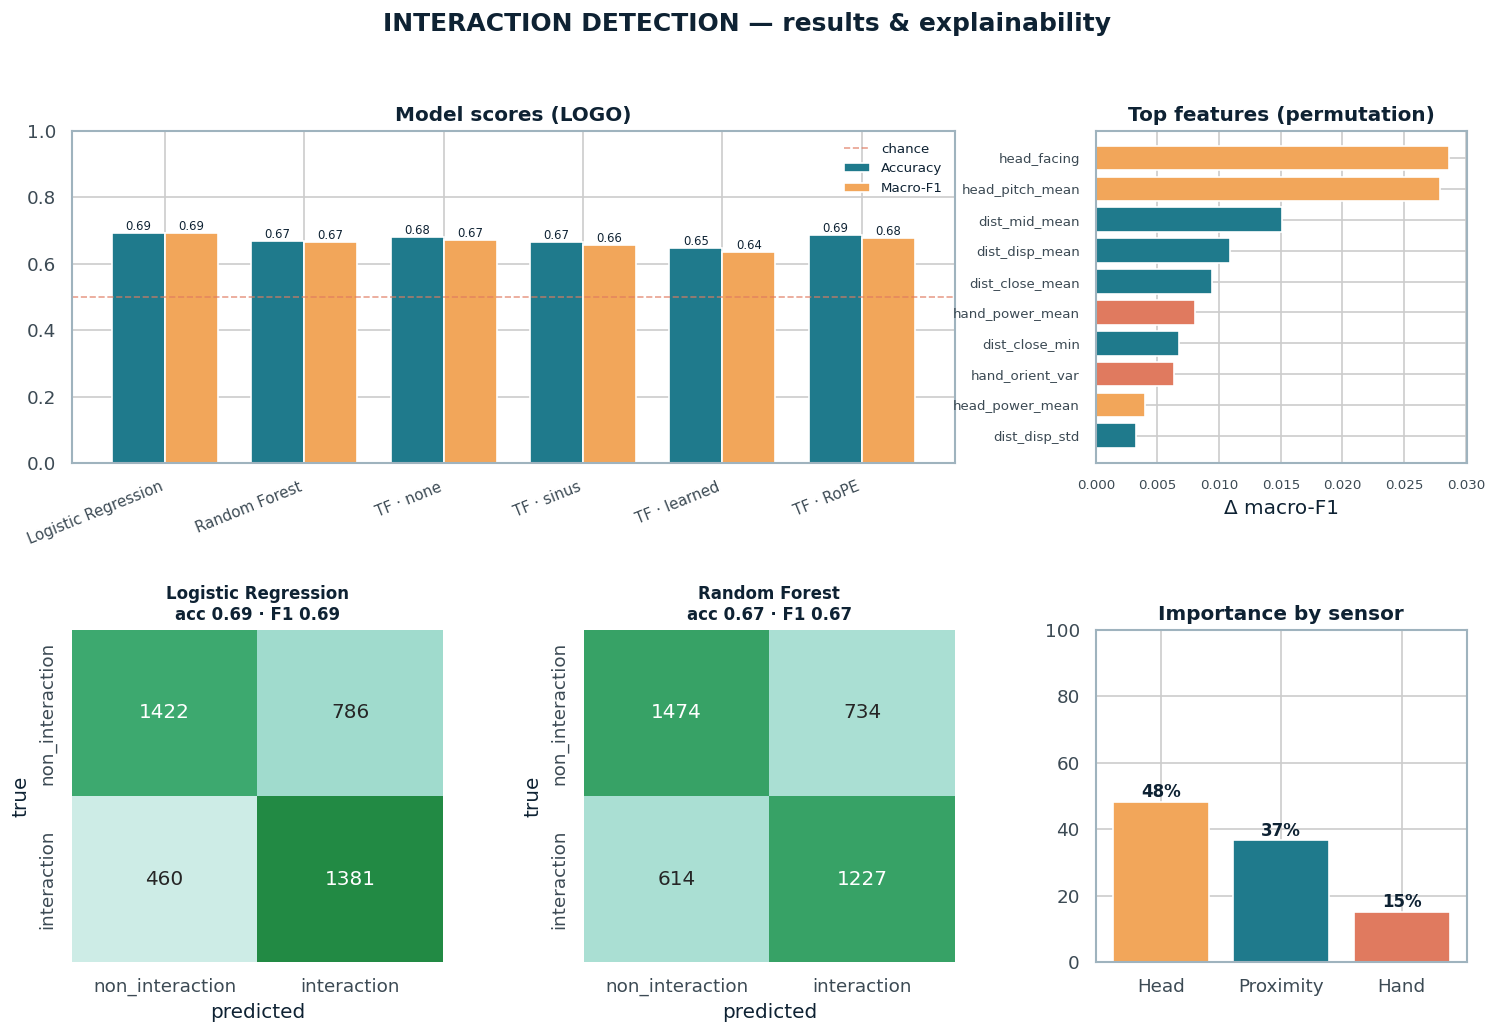


Scores (LOGO):
  Logistic Regression    acc 0.692  macroF1 0.692
  Random Forest          acc 0.667  macroF1 0.666
  TF · none              acc 0.681  macroF1 0.672
  TF · sinus             acc 0.665  macroF1 0.657
  TF · learned           acc 0.646  macroF1 0.635
  TF · RoPE              acc 0.687  macroF1 0.677


In [ ]:
# ===== INTERACTION — scores · confusion matrices · explainability =====
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance

# ---- aesthetics ----
sns.set_theme(style="whitegrid", font_scale=1.0)
TEAL, AMBER, CORAL, INK = "#1F7A8C", "#F2A65A", "#E07A5F", "#0E2233"
plt.rcParams.update({"axes.edgecolor":"#9FB3BE","axes.labelcolor":INK,"text.color":INK,
                     "xtick.color":"#3C4A54","ytick.color":"#3C4A54","figure.dpi":120,
                     "axes.titleweight":"bold"})

PATH    = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/interaction_eng_features.csv"
CLASSES = ["non_interaction", "interaction"]

F = pd.read_csv(PATH); F = F[F["label"].isin(CLASSES)].reset_index(drop=True)
feats = [c for c in F.columns if c not in ("group", "label")]
X, y, g = F[feats].fillna(0).values, F["label"].values, F["group"].values

# ---- LOGO eval (pooled predictions) for the classical models ----
def logo(make):
    yt, yp = [], []
    for tr, te in LeaveOneGroupOut().split(X, y, g):
        m = make(); m.fit(X[tr], y[tr]); yt += list(y[te]); yp += list(m.predict(X[te]))
    return np.array(yt), np.array(yp)

makers = {
    "Logistic Regression": lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")),
    "Random Forest":       lambda: make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=0)),
}
results, preds = {}, {}
for name, mk in makers.items():
    yt, yp = logo(mk)
    results[name] = (accuracy_score(yt, yp), f1_score(yt, yp, average="macro")); preds[name] = (yt, yp)

# Transformer per-encoding scores (interaction Eng·LOGO, from your notebook)
for k, v in {"TF · none":(0.681,0.672), "TF · sinus":(0.665,0.657),
             "TF · learned":(0.646,0.635), "TF · RoPE":(0.687,0.677)}.items():
    results[k] = v

# ---- permutation importance (RF) ----
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
rf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=0)).fit(Xtr, ytr)
perm = permutation_importance(rf, Xte, yte, n_repeats=10, random_state=0, scoring="f1_macro")
imp = pd.DataFrame({"feature": feats, "imp": perm.importances_mean}).sort_values("imp", ascending=False)
sensor = lambda f: "Proximity" if f.startswith(("dist_","centroid")) else ("Head" if f.startswith("head_") else "Hand")
imp["sensor"] = imp["feature"].map(sensor)
pal = {"Proximity": TEAL, "Head": AMBER, "Hand": CORAL}

# ---- dashboard ----
fig = plt.figure(figsize=(15, 9)); gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.38)

ax = fig.add_subplot(gs[0, :2])                    # scores
names = list(results); a = [results[n][0] for n in names]; f = [results[n][1] for n in names]
xp = np.arange(len(names)); w = 0.38
ax.bar(xp-w/2, a, w, label="Accuracy", color=TEAL); ax.bar(xp+w/2, f, w, label="Macro-F1", color=AMBER)
ax.axhline(0.5, ls="--", c=CORAL, lw=1, alpha=.7, label="chance")
ax.set_xticks(xp); ax.set_xticklabels(names, rotation=22, ha="right", fontsize=9)
ax.set_ylim(0, 1); ax.set_title("Model scores (LOGO)"); ax.legend(frameon=False, fontsize=8)
for i in range(len(names)):
    ax.text(i-w/2, a[i]+.01, f"{a[i]:.2f}", ha="center", fontsize=7)
    ax.text(i+w/2, f[i]+.01, f"{f[i]:.2f}", ha="center", fontsize=7)

ax = fig.add_subplot(gs[0, 2])                     # top features
top = imp.head(10)[::-1]
ax.barh(top["feature"], top["imp"], color=[pal[s] for s in top["sensor"]])
ax.set_title("Top features (permutation)"); ax.set_xlabel("Δ macro-F1"); ax.tick_params(labelsize=8)

for j, name in enumerate(["Logistic Regression", "Random Forest"]):   # confusion matrices
    ax = fig.add_subplot(gs[1, j]); yt, yp = preds[name]
    cm = confusion_matrix(yt, yp, labels=CLASSES); cmn = cm / cm.sum(1, keepdims=True)
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="BuGn", cbar=False, vmin=0, vmax=1,
                xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={"fontsize":12}, ax=ax)
    ax.set_title(f"{name}\nacc {results[name][0]:.2f} · F1 {results[name][1]:.2f}", fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")

ax = fig.add_subplot(gs[1, 2])                      # sensor rollup
roll = imp.groupby("sensor")["imp"].apply(lambda s: s[s > 0].sum()); roll = (roll/roll.sum()*100).sort_values(ascending=False)
ax.bar(roll.index, roll.values, color=[pal[s] for s in roll.index]); ax.set_ylim(0, 100)
ax.set_title("Importance by sensor");
for i, v in enumerate(roll.values): ax.text(i, v+1.5, f"{v:.0f}%", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("INTERACTION DETECTION — results & explainability", fontsize=15, fontweight="bold", y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

print("\nScores (LOGO):")
for n in results: print(f"  {n:22s} acc {results[n][0]:.3f}  macroF1 {results[n][1]:.3f}")

/tmp/ipykernel_1799/2456384929.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


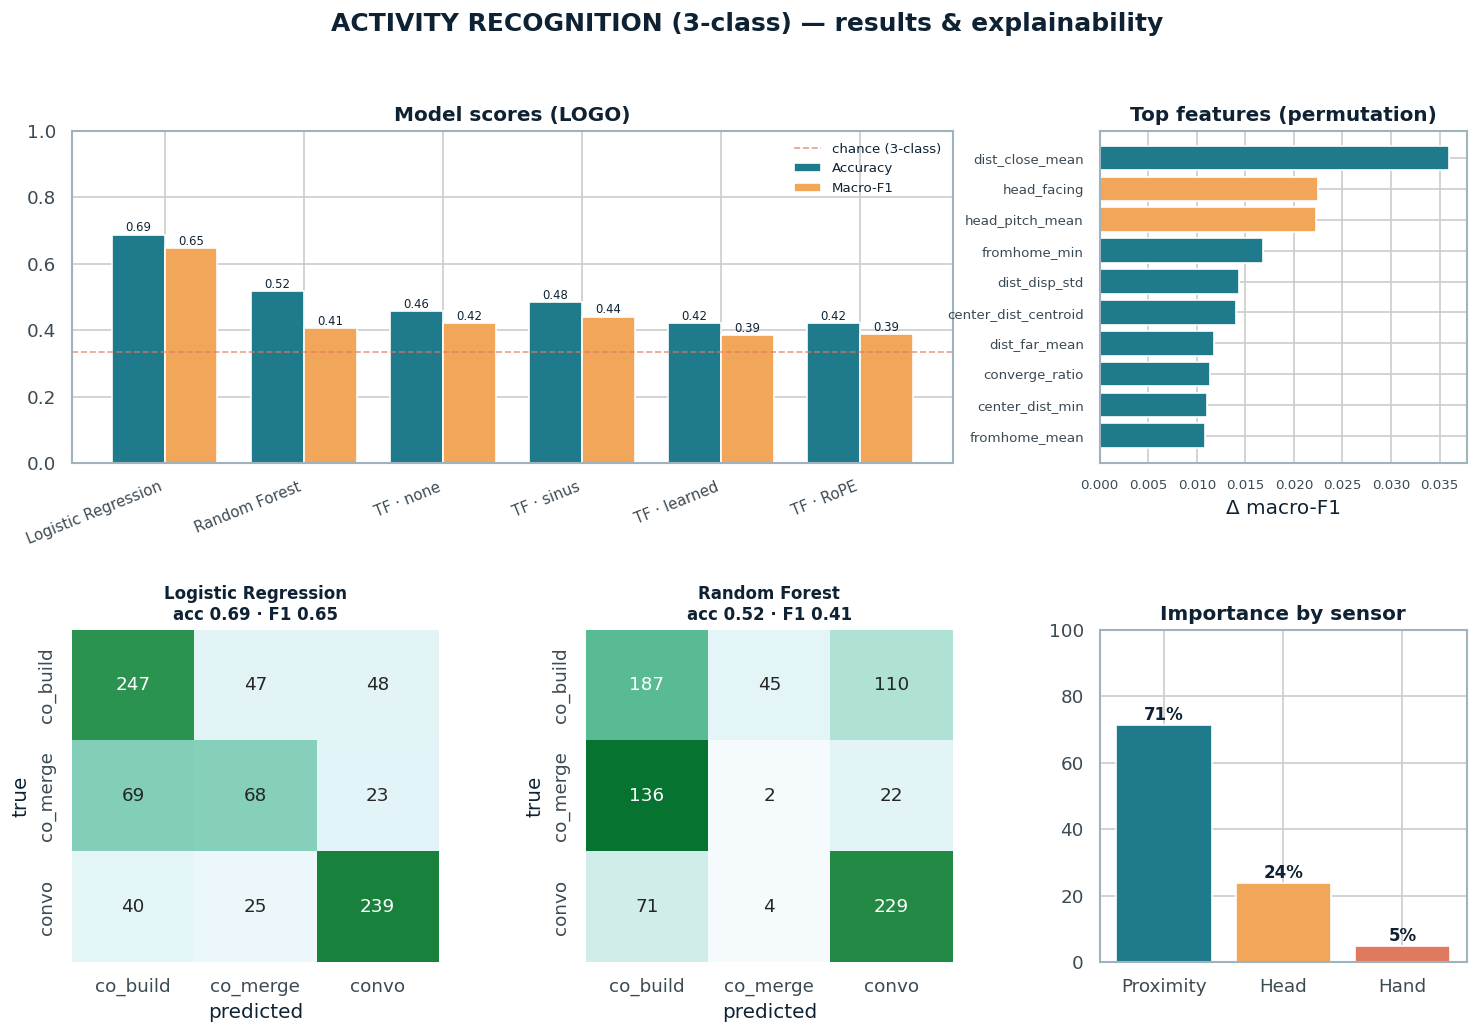


Scores (LOGO):
  Logistic Regression    acc 0.687  macroF1 0.647
  Random Forest          acc 0.519  macroF1 0.405
  TF · none              acc 0.457  macroF1 0.421
  TF · sinus             acc 0.485  macroF1 0.441
  TF · learned           acc 0.422  macroF1 0.386
  TF · RoPE              acc 0.421  macroF1 0.389

Per-class F1 (Logistic Regression, LOGO):
  co_building    0.708
  co_merging     0.453
  conversation   0.779


In [ ]:
# ===== RECOGNITION (3-class) — scores · confusion matrices · explainability =====
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid", font_scale=1.0)
TEAL, AMBER, CORAL, INK = "#1F7A8C", "#F2A65A", "#E07A5F", "#0E2233"
plt.rcParams.update({"axes.edgecolor":"#9FB3BE","axes.labelcolor":INK,"text.color":INK,
                     "xtick.color":"#3C4A54","ytick.color":"#3C4A54","figure.dpi":120,
                     "axes.titleweight":"bold"})

PATH    = "/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2/recognition_fixed_features.csv"
CLASSES = ["co_building", "co_merging", "conversation"]

F = pd.read_csv(PATH); F = F[F["label"].isin(CLASSES)].reset_index(drop=True)
feats = [c for c in F.columns if c not in ("group", "label")]
X, y, g = F[feats].fillna(0).values, F["label"].values, F["group"].values

def logo(make):
    yt, yp = [], []
    for tr, te in LeaveOneGroupOut().split(X, y, g):
        m = make(); m.fit(X[tr], y[tr]); yt += list(y[te]); yp += list(m.predict(X[te]))
    return np.array(yt), np.array(yp)

makers = {
    "Logistic Regression": lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")),
    "Random Forest":       lambda: make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=0)),
}
results, preds = {}, {}
for name, mk in makers.items():
    yt, yp = logo(mk)
    results[name] = (accuracy_score(yt, yp), f1_score(yt, yp, average="macro")); preds[name] = (yt, yp)

# Transformer per-encoding scores (recognition Eng·LOGO, from your notebook)
for k, v in {"TF · none":(0.457,0.421), "TF · sinus":(0.485,0.441),
             "TF · learned":(0.422,0.386), "TF · RoPE":(0.421,0.389)}.items():
    results[k] = v

from sklearn.inspection import permutation_importance
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
rf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=0)).fit(Xtr, ytr)
perm = permutation_importance(rf, Xte, yte, n_repeats=10, random_state=0, scoring="f1_macro")
imp = pd.DataFrame({"feature": feats, "imp": perm.importances_mean}).sort_values("imp", ascending=False)
def sensor(f):
    if f.startswith(("dist_", "centroid", "fromhome", "center_dist", "converge")): return "Proximity"
    if f.startswith("head_"): return "Head"
    return "Hand"
imp["sensor"] = imp["feature"].map(sensor)
pal = {"Proximity": TEAL, "Head": AMBER, "Hand": CORAL}

fig = plt.figure(figsize=(15, 9)); gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.4)

ax = fig.add_subplot(gs[0, :2])                          # scores
names = list(results); a = [results[n][0] for n in names]; f = [results[n][1] for n in names]
xp = np.arange(len(names)); w = 0.38
ax.bar(xp-w/2, a, w, label="Accuracy", color=TEAL); ax.bar(xp+w/2, f, w, label="Macro-F1", color=AMBER)
ax.axhline(1/3, ls="--", c=CORAL, lw=1, alpha=.7, label="chance (3-class)")
ax.set_xticks(xp); ax.set_xticklabels(names, rotation=22, ha="right", fontsize=9)
ax.set_ylim(0, 1); ax.set_title("Model scores (LOGO)"); ax.legend(frameon=False, fontsize=8)
for i in range(len(names)):
    ax.text(i-w/2, a[i]+.01, f"{a[i]:.2f}", ha="center", fontsize=7)
    ax.text(i+w/2, f[i]+.01, f"{f[i]:.2f}", ha="center", fontsize=7)

ax = fig.add_subplot(gs[0, 2])                           # top features
top = imp.head(10)[::-1]
ax.barh(top["feature"], top["imp"], color=[pal[s] for s in top["sensor"]])
ax.set_title("Top features (permutation)"); ax.set_xlabel("Δ macro-F1"); ax.tick_params(labelsize=8)

short = ["co_build", "co_merge", "convo"]
for j, name in enumerate(["Logistic Regression", "Random Forest"]):    # 3x3 confusion matrices
    ax = fig.add_subplot(gs[1, j]); yt, yp = preds[name]
    cm = confusion_matrix(yt, yp, labels=CLASSES); cmn = cm / cm.sum(1, keepdims=True)
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="BuGn", cbar=False, vmin=0, vmax=1,
                xticklabels=short, yticklabels=short, annot_kws={"fontsize":11}, ax=ax)
    ax.set_title(f"{name}\nacc {results[name][0]:.2f} · F1 {results[name][1]:.2f}", fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")

ax = fig.add_subplot(gs[1, 2])                           # sensor rollup
roll = imp.groupby("sensor")["imp"].apply(lambda s: s[s > 0].sum()); roll = (roll/roll.sum()*100).sort_values(ascending=False)
ax.bar(roll.index, roll.values, color=[pal[s] for s in roll.index]); ax.set_ylim(0, 100)
ax.set_title("Importance by sensor")
for i, v in enumerate(roll.values): ax.text(i, v+1.5, f"{v:.0f}%", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("ACTIVITY RECOGNITION (3-class) — results & explainability", fontsize=15, fontweight="bold", y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

print("\nScores (LOGO):")
for n in results: print(f"  {n:22s} acc {results[n][0]:.3f}  macroF1 {results[n][1]:.3f}")
print("\nPer-class F1 (Logistic Regression, LOGO):")
yt, yp = preds["Logistic Regression"]
for c in CLASSES: print(f"  {c:14s} {f1_score(yt, yp, labels=[c], average='macro'):.3f}")

RECOGNITION AFTER DATA BALANCING CLEANING

class balance: {'conversation': 304, 'co_merging': 160, 'co_building': 342}

=== StratifiedGroupKFold (group-safe + class-balanced) ===
             strategy   acc  macroF1  F1_cobuild  F1_comerge  F1_convo
LogReg · class_weight 0.687    0.637       0.716       0.420     0.774
       LogReg · SMOTE 0.681    0.626       0.704       0.393     0.783
  LogReg · oversample 0.685    0.634       0.711       0.416     0.773
 LogReg · undersample 0.692    0.653       0.720       0.471     0.768
    RF · class_weight 0.524    0.410       0.519       0.019     0.693
           RF · SMOTE 0.529    0.435       0.520       0.078     0.707

CV comparison — LogReg · class_weight:
  LOGO                  acc 0.687  macroF1 0.647  co_merge F1 0.453
  StratifiedGroupKFold  acc 0.687  macroF1 0.637  co_merge F1 0.420


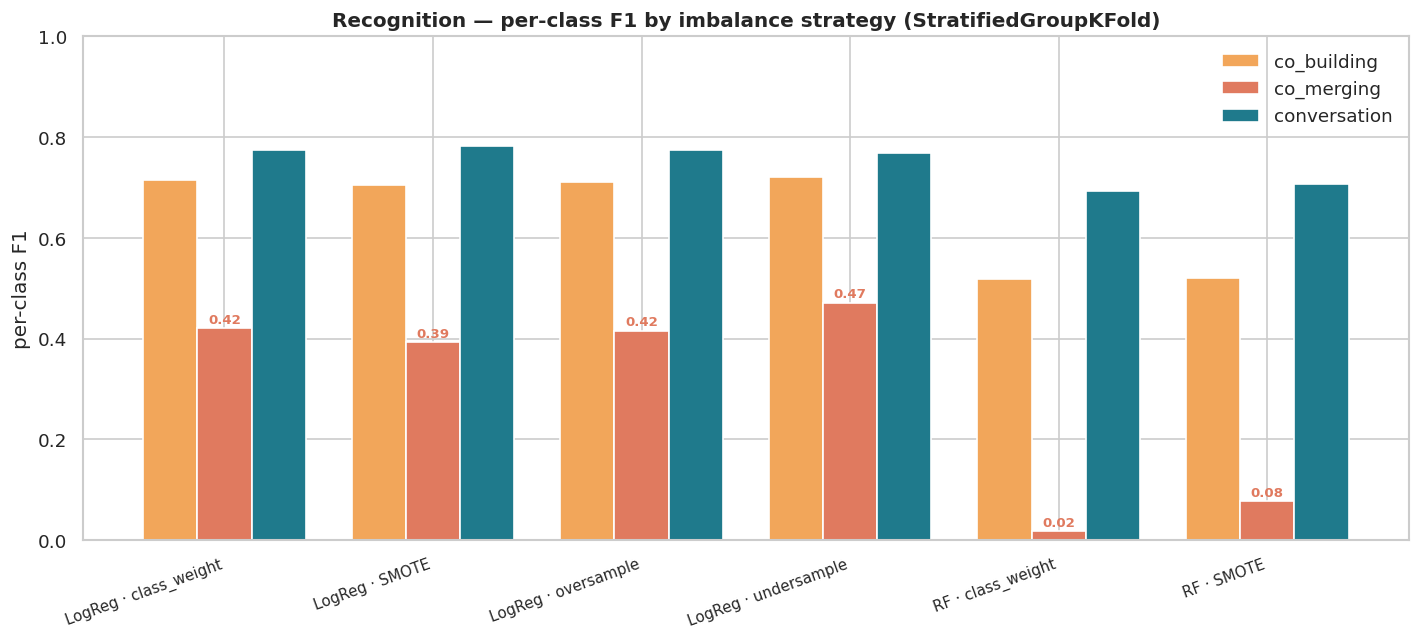

In [ ]:
# ===== RECOGNITION — imbalance (2) + stratification (4) =====
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
from collections import Counter
# imbalanced-learn is preinstalled in Colab; if not: !pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style="whitegrid", font_scale=1.0)
TEAL, AMBER, CORAL = "#1F7A8C", "#F2A65A", "#E07A5F"

PATH = "/content/drive/MyDrive/thesis/data/RECOGNITION_ENG2/recognition_fixed_features.csv"
CLASSES = ["co_building", "co_merging", "conversation"]
F = pd.read_csv(PATH); F = F[F["label"].isin(CLASSES)].reset_index(drop=True)
feats = [c for c in F.columns if c not in ("group","label")]
X, y, g = F[feats].fillna(0).values, F["label"].values, F["group"].values
print("class balance:", dict(Counter(y)))

def evaluate(pipe, splits):
    yt, yp = [], []
    for tr, te in splits:
        pipe.fit(X[tr], y[tr]); yt += list(y[te]); yp += list(pipe.predict(X[te]))
    yt, yp = np.array(yt), np.array(yp)
    pc = {c: f1_score(yt, yp, labels=[c], average="macro") for c in CLASSES}
    return accuracy_score(yt, yp), f1_score(yt, yp, average="macro"), pc

sgkf = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0).split(X, y, g))
logo = list(LeaveOneGroupOut().split(X, y, g))
LR  = lambda **k: LogisticRegression(max_iter=2000, **k)
RF  = lambda **k: RandomForestClassifier(n_estimators=500, random_state=0, **k)

strategies = {
    "LogReg · class_weight": ImbPipeline([("sc",StandardScaler()), ("clf",LR(class_weight="balanced"))]),
    "LogReg · SMOTE":        ImbPipeline([("sc",StandardScaler()), ("s",SMOTE(random_state=0)), ("clf",LR())]),
    "LogReg · oversample":   ImbPipeline([("sc",StandardScaler()), ("o",RandomOverSampler(random_state=0)), ("clf",LR())]),
    "LogReg · undersample":  ImbPipeline([("sc",StandardScaler()), ("u",RandomUnderSampler(random_state=0)), ("clf",LR())]),
    "RF · class_weight":     ImbPipeline([("sc",StandardScaler()), ("clf",RF(class_weight="balanced_subsample"))]),
    "RF · SMOTE":            ImbPipeline([("sc",StandardScaler()), ("s",SMOTE(random_state=0)), ("clf",RF())]),
}

rows = []
for name, pipe in strategies.items():
    acc, mf1, pc = evaluate(pipe, sgkf)
    rows.append((name, acc, mf1, pc["co_building"], pc["co_merging"], pc["conversation"]))
res = pd.DataFrame(rows, columns=["strategy","acc","macroF1","F1_cobuild","F1_comerge","F1_convo"])
print("\n=== StratifiedGroupKFold (group-safe + class-balanced) ===")
print(res.round(3).to_string(index=False))

# stratification effect: LOGO vs StratifiedGroupKFold on the baseline
aL, mL, pL = evaluate(strategies["LogReg · class_weight"], logo)
print("\nCV comparison — LogReg · class_weight:")
print(f"  LOGO                  acc {aL:.3f}  macroF1 {mL:.3f}  co_merge F1 {pL['co_merging']:.3f}")
print(f"  StratifiedGroupKFold  acc {res.iloc[0].acc:.3f}  macroF1 {res.iloc[0].macroF1:.3f}  co_merge F1 {res.iloc[0].F1_comerge:.3f}")

# visualize per-class F1 across strategies
fig, ax = plt.subplots(figsize=(12, 5.5)); xp = np.arange(len(res)); w = 0.26
ax.bar(xp-w, res["F1_cobuild"], w, label="co_building", color=AMBER)
ax.bar(xp,   res["F1_comerge"], w, label="co_merging",  color=CORAL)
ax.bar(xp+w, res["F1_convo"],   w, label="conversation",color=TEAL)
for i in range(len(res)):
    ax.text(i, res["F1_comerge"].iloc[i]+.01, f"{res['F1_comerge'].iloc[i]:.2f}", ha="center", fontsize=8, color=CORAL, fontweight="bold")
ax.set_xticks(xp); ax.set_xticklabels(res["strategy"], rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel("per-class F1"); ax.legend(frameon=False)
ax.set_title("Recognition — per-class F1 by imbalance strategy (StratifiedGroupKFold)", fontweight="bold")
plt.tight_layout(); plt.show()

windows: 193 | classes: {'conversation': 125, 'co_merging': 30, 'co_building': 38}

BASE         acc 0.585 F1 0.326  [('co_building', 0.03), ('co_merging', 0.03), ('conversation', 0.92)]
BASE + GAZE  acc 0.585 F1 0.326  [('co_building', 0.03), ('co_merging', 0.03), ('conversation', 0.92)]

mean gaze feature by class:
               head_antiface  head_colinear  head_facing_min
label                                                      
co_building             0.0          0.985            0.968
co_merging              0.0          0.989            0.977
conversation            0.0          0.989            0.975


/tmp/ipykernel_1799/351578512.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=D,x="label",y="head_antiface",ax=ax[1],palette=["#F2A65A","#E07A5F","#1F7A8C"])


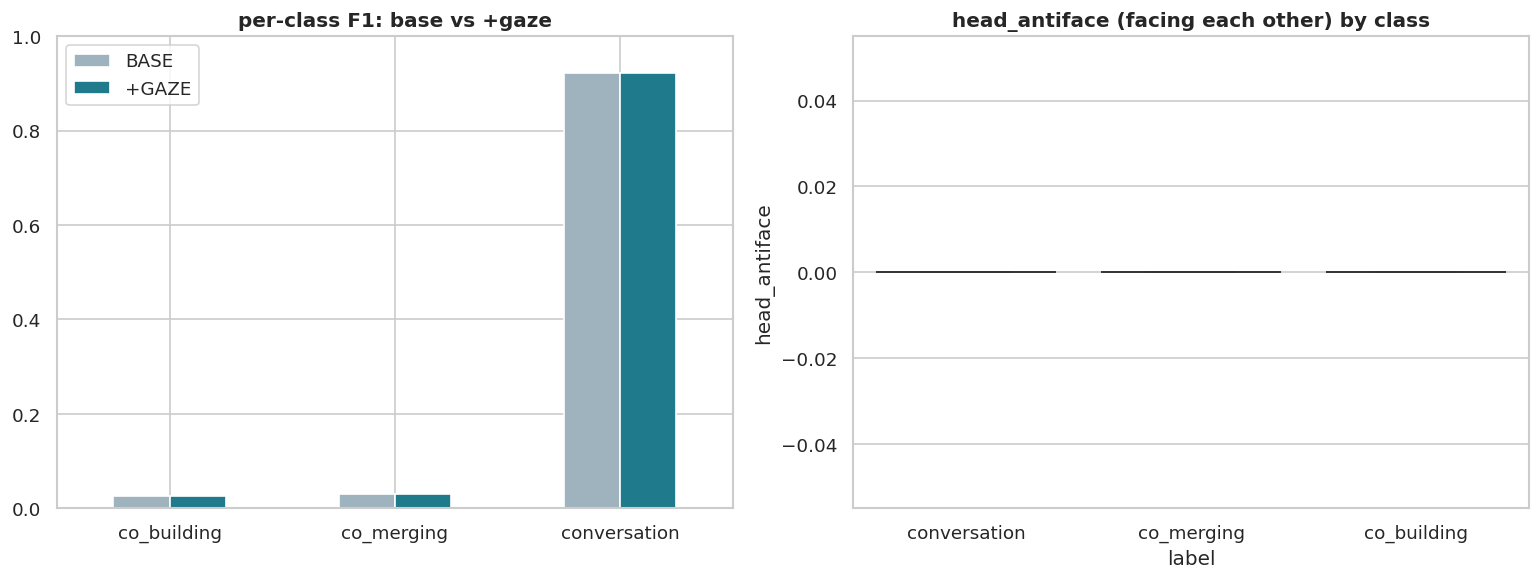

In [ ]:
import pandas as pd, numpy as np, glob, os, re
from collections import Counter
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt, seaborn as sns

DATA_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
GROUPS=[1,2,3,5,6,7,8,9,10]; WIN=5.0
CLASS_SETS={"co_building":{"co_building_subpiece","co_building_piece","building_subpiece_together","building_subpiece"},
            "co_merging":{"co_merging_subpiece","merging_subpiece"},
            "conversation":{"task_operational_convo","task_related_convo","task_social_convo","task_related_social_convo","non_task_convo"}}
TYPO={"object_handiver":"object_handover","nspecting_pieces":"inspecting_pieces","returning_target_image_tr":"returning_target_image","carriyng_thray_to_central_table":"carrying_tray_to_central_table"}
def norm(s): s=str(s).strip().lower(); return TYPO.get(s,s)
def to_class(label):
    if pd.isna(label): return None
    parts=[norm(p) for p in re.split(r"[+|/]",str(label))]
    for cls,names in CLASS_SETS.items():
        if any(p in names for p in parts): return cls
    return None
def find(g,s):
    c=glob.glob(os.path.join(DATA_DIR,f"group_{g}_{s}_model_ready.csv")); return c[0] if c else None
def heading(df,i):
    mx,my=f"p{i}_mag_x",f"p{i}_mag_y"
    return np.arctan2(df[my].values,df[mx].values) if (mx in df and my in df) else None

rows=[]
for g in GROUPS:
    oe_f,ot_f=find(g,"openearable"),find(g,"optitrack")
    if not oe_f or not ot_f: continue
    oe=pd.read_csv(oe_f,low_memory=False); ot=pd.read_csv(ot_f,low_memory=False)
    if "video_time_s" not in oe or "video_time_s" not in ot: print(f"g{g}: no video_time_s"); continue
    th={i:heading(oe,i) for i in (1,2,3)}; oe_t=oe["video_time_s"].values; ot_t=ot["video_time_s"].values
    P={i:ot[[f"Participant{i}_x",f"Participant{i}_y",f"Participant{i}_z"]].values for i in (1,2,3) if f"Participant{i}_x" in ot}
    wg=oe["label_Whole_Group"] if "label_Whole_Group" in oe else None
    t=np.nanmin(oe_t); tend=np.nanmax(oe_t)
    while t<tend:
        moe=(oe_t>=t)&(oe_t<t+WIN); mot=(ot_t>=t)&(ot_t<t+WIN)
        if moe.sum()<5 or mot.sum()<5 or len(P)<3 or wg is None: t+=WIN; continue
        lbls=[x for x in (to_class(v) for v in wg[moe].dropna()) if x]
        if not lbls: t+=WIN; continue
        lab=Counter(lbls).most_common(1)[0][0]
        pos=np.stack([P[i][mot] for i in (1,2,3)],axis=1)
        d=[np.linalg.norm(pos[:,a]-pos[:,b],axis=1) for a,b in [(0,1),(0,2),(1,2)]]
        ds=np.sort(np.stack(d,axis=1),axis=1)
        cen=pos.mean(axis=1); cs=(np.linalg.norm(np.diff(cen,axis=0),axis=1).mean()*(mot.sum()/WIN)) if len(cen)>1 else 0
        pit=[]
        for i in (1,2,3):
            ax=f"p{i}_acc_x"
            if ax in oe:
                a=oe.loc[moe,[ax,f"p{i}_acc_y",f"p{i}_acc_z"]].values
                pit.append(np.arctan2(a[:,0],np.sqrt(a[:,1]**2+a[:,2]**2)).mean())
        cv=[np.cos(th[i][moe]-th[j][moe]) for i,j in [(1,2),(1,3),(2,3)] if th[i] is not None and th[j] is not None]
        if cv:
            allc=np.concatenate(cv)
            hf,ha,hc,hm=np.nanmean(allc),np.nanmean(np.clip(-allc,0,1)),np.nanmean(np.abs(allc)),np.nanmin(allc)
        else: hf=ha=hc=hm=0
        rows.append([g,lab,ds[:,0].mean(),ds[:,1].mean(),ds[:,2].mean(),np.std(d),cs,
                     np.mean(pit) if pit else 0,hf,ha,hc,hm])
        t+=WIN

cols=["group","label","dist_close","dist_mid","dist_far","disp_std","centroid_speed","head_pitch","head_facing","head_antiface","head_colinear","head_facing_min"]
D=pd.DataFrame(rows,columns=cols).dropna()
print("windows:",len(D),"| classes:",dict(Counter(D["label"])))

BASE=["dist_close","dist_mid","dist_far","disp_std","centroid_speed","head_pitch","head_facing"]
GAZE=["head_antiface","head_colinear","head_facing_min"]; CLASSES=["co_building","co_merging","conversation"]
def cv_eval(fs):
    X=D[fs].values; y=D["label"].values; gg=D["group"].values; yt,yp=[],[]
    for tr,te in StratifiedGroupKFold(5,shuffle=True,random_state=0).split(X,y,gg):
        clf=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,class_weight="balanced"))
        clf.fit(X[tr],y[tr]); yt+=list(y[te]); yp+=list(clf.predict(X[te]))
    yt,yp=np.array(yt),np.array(yp)
    return accuracy_score(yt,yp),f1_score(yt,yp,average="macro"),{c:f1_score(yt,yp,labels=[c],average="macro") for c in CLASSES}
a0,m0,p0=cv_eval(BASE); a1,m1,p1=cv_eval(BASE+GAZE)
print(f"\nBASE         acc {a0:.3f} F1 {m0:.3f}  {[ (c,round(p0[c],2)) for c in CLASSES]}")
print(f"BASE + GAZE  acc {a1:.3f} F1 {m1:.3f}  {[ (c,round(p1[c],2)) for c in CLASSES]}")
print("\nmean gaze feature by class:\n", D.groupby("label")[GAZE].mean().round(3))

fig,ax=plt.subplots(1,2,figsize=(13,5))
pd.DataFrame({"BASE":[p0[c] for c in CLASSES],"+GAZE":[p1[c] for c in CLASSES]},index=CLASSES).plot.bar(ax=ax[0],color=["#9FB3BE","#1F7A8C"])
ax[0].set_title("per-class F1: base vs +gaze"); ax[0].set_ylim(0,1); ax[0].tick_params(axis='x',rotation=0)
sns.boxplot(data=D,x="label",y="head_antiface",ax=ax[1],palette=["#F2A65A","#E07A5F","#1F7A8C"])
ax[1].set_title("head_antiface (facing each other) by class")
plt.tight_layout(); plt.show()

## AFTER THE RESEARCH GROUP PRESENTATION

In [ ]:
# === DIAGNOSTIC: DISCOVER ALL RAW LABELS & PHYSICAL COUNTS ===
import pandas as pd
import glob
import os
from collections import Counter

DATA_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
GROUPS = [1, 2, 3, 5, 6, 7, 8, 9, 10]
HZ = 50  # Sensor sampling frequency to compute physical duration

# Annotation columns present across your study files
TIERS = [
    "label_Participant1", "label_Participant2", "label_Participant3",  # Individual actions
    "label_Participant1_Participant2", "label_Participant1_Participant3", "label_Participant2_Participant3", # Dyadic interactions
    "label_Whole_Group" # Group-wide actions
]

print("="*90)
print("              COMPREHENSIVE RAW LABEL MASTER DIRECTORY")
print("="*90)

raw_instances = Counter()
raw_timesteps = Counter()
loaded_groups = 0

# Scan raw files across all active experimental groups
for g in GROUPS:
    # Use any sensor's file from the folder since labels are mirrored across sync files
    match = glob.glob(os.path.join(DATA_DIR, f"group_{g}_openearable_model_ready.csv"))
    if not match:
        continue

    loaded_groups += 1
    # Only pull the label columns to keep processing lightning-fast
    df = pd.read_csv(match[0], usecols=lambda c: c in TIERS, low_memory=False)

    for col in [c for c in TIERS if c in df.columns]:
        series = df[col].dropna().astype(str).str.strip()
        # Drop completely blank annotation rows
        series = series[series != ""]

        # Count structural timeline duration (total ticks / 50Hz = total seconds)
        raw_timesteps.update(series.tolist())

        # Count explicit unique event instances (when a label shifts to a new state)
        instances = series[series != series.shift()].tolist()
        raw_instances.update(instances)

print(f"Scanned {loaded_groups} active groups.")
print(f"Discovered a total of {len(raw_instances)} unique raw annotation strings.\n")

# Format and display the raw leaderboard sorted by absolute time duration
print(f"   {'#':<4} | {'Raw Label Entry String':<50} | {'Instances':<10} | {'Total Duration':<12}")
print("-" * 90)

for idx, (label, tick_count) in enumerate(raw_timesteps.most_common(), 1):
    duration_mins = tick_count / HZ / 60
    instances_count = raw_instances[label]
    print(f"   {idx:<4} | {label:<50} | {instances_count:<10d} | {duration_mins:>6.2f} minutes")

print("="*90)

              COMPREHENSIVE RAW LABEL MASTER DIRECTORY
Scanned 9 active groups.
Discovered a total of 149 unique raw annotation strings.

   #    | Raw Label Entry String                             | Instances  | Total Duration
------------------------------------------------------------------------------------------
   1    | individual_build                                   | 478        | 529.45 minutes
   2    | co_building_subpiece                               | 42         |  83.19 minutes
   3    | task_operational_convo                             | 147        |  30.65 minutes
   4    | traveling_between_units                            | 367        |  27.19 minutes
   5    | merging_subpiece                                   | 14         |  23.52 minutes
   6    | matching_pieces_with_target_image                  | 22         |  18.66 minutes
   7    | co_merging_subpiece                                | 13         |  15.34 minutes
   8    | matching_pieces_to_target_image  

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

ENG_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG/interaction_eng_features.csv"
ENG2_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/interaction_eng_features.csv"

eng = pd.read_csv(ENG_PATH)
eng2 = pd.read_csv(ENG2_PATH)

old_features = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

all_eng2_features = [c for c in eng2.columns if c not in ["group", "label"]]

def logo_eval(df, features, name):
    X = df[features].values
    y = df["label"].values
    groups = df["group"].values

    logo = LeaveOneGroupOut()

    all_true = []
    all_pred = []

    fold_results = []

    for train_idx, test_idx in logo.split(X, y, groups):
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced")
        )

        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])

        acc = accuracy_score(y[test_idx], pred)
        mf1 = f1_score(y[test_idx], pred, average="macro")

        test_group = groups[test_idx][0]
        fold_results.append((test_group, acc, mf1, len(test_idx)))

        all_true.extend(y[test_idx])
        all_pred.extend(pred)

    pooled_acc = accuracy_score(all_true, all_pred)
    pooled_mf1 = f1_score(all_true, all_pred, average="macro")

    mean_acc = np.mean([x[1] for x in fold_results])
    mean_mf1 = np.mean([x[2] for x in fold_results])

    print("\n" + "="*80)
    print(name)
    print("="*80)
    print("Rows:", len(df))
    print("Features:", len(features))
    print("Pooled LOGO accuracy:", round(pooled_acc, 3))
    print("Pooled LOGO macro F1:", round(pooled_mf1, 3))
    print("Mean-per-group LOGO accuracy:", round(mean_acc, 3))
    print("Mean-per-group LOGO macro F1:", round(mean_mf1, 3))

    print("\nPer-group results:")
    for g, acc, mf1, n in fold_results:
        print(f"Group {g}: acc={acc:.3f}, macroF1={mf1:.3f}, n={n}")

logo_eval(eng, old_features, "ENG original with old 17 features")
logo_eval(eng2, old_features, "ENG2 using only old 17 features")
logo_eval(eng2, all_eng2_features, "ENG2 using all 30 features")


ENG original with old 17 features
Rows: 4372
Features: 17
Pooled LOGO accuracy: 0.74
Pooled LOGO macro F1: 0.739
Mean-per-group LOGO accuracy: 0.735
Mean-per-group LOGO macro F1: 0.728

Per-group results:
Group 1: acc=0.596, macroF1=0.587, n=366
Group 2: acc=0.735, macroF1=0.735, n=525
Group 3: acc=0.789, macroF1=0.767, n=527
Group 5: acc=0.805, macroF1=0.804, n=661
Group 6: acc=0.697, macroF1=0.694, n=274
Group 7: acc=0.712, macroF1=0.707, n=576
Group 8: acc=0.737, macroF1=0.737, n=457
Group 9: acc=0.733, macroF1=0.732, n=703
Group 10: acc=0.809, macroF1=0.786, n=283

ENG2 using only old 17 features
Rows: 4049
Features: 17
Pooled LOGO accuracy: 0.718
Pooled LOGO macro F1: 0.718
Mean-per-group LOGO accuracy: 0.712
Mean-per-group LOGO macro F1: 0.7

Per-group results:
Group 1: acc=0.557, macroF1=0.557, n=366
Group 2: acc=0.737, macroF1=0.736, n=524
Group 3: acc=0.782, macroF1=0.761, n=527
Group 5: acc=0.769, macroF1=0.768, n=661
Group 6: acc=0.679, macroF1=0.629, n=187
Group 7: acc=0.7

In [ ]:
def logo_eval(df, features, name):
    X = df[features].values
    y = df["label"].values
    groups = df["group"].values

    logo = LeaveOneGroupOut()

    all_true = []
    all_pred = []
    fold_results = []

    for train_idx, test_idx in logo.split(X, y, groups):
        model = make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced")
        )

        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])

        acc = accuracy_score(y[test_idx], pred)
        mf1 = f1_score(y[test_idx], pred, average="macro")

        test_group = groups[test_idx][0]
        fold_results.append((test_group, acc, mf1, len(test_idx)))

        all_true.extend(y[test_idx])
        all_pred.extend(pred)

    pooled_acc = accuracy_score(all_true, all_pred)
    pooled_mf1 = f1_score(all_true, all_pred, average="macro")

    mean_acc = np.mean([x[1] for x in fold_results])
    mean_mf1 = np.mean([x[2] for x in fold_results])

    print("\n" + "="*80)
    print(name)
    print("="*80)
    print("Rows:", len(df))
    print("Features:", len(features))
    print("Pooled LOGO accuracy:", round(pooled_acc, 3))
    print("Pooled LOGO macro F1:", round(pooled_mf1, 3))
    print("Mean-per-group LOGO accuracy:", round(mean_acc, 3))
    print("Mean-per-group LOGO macro F1:", round(mean_mf1, 3))

    print("\nPer-group results:")
    for g, acc, mf1, n in fold_results:
        print(f"Group {g}: acc={acc:.3f}, macroF1={mf1:.3f}, n={n}")

logo_eval(
    eng2,
    features_old_plus_xsens,
    "ENG2 with old ENG features + Xsens hand features, no head features"
)


ENG2 with old ENG features + Xsens hand features, no head features
Rows: 4049
Features: 22
Pooled LOGO accuracy: 0.712
Pooled LOGO macro F1: 0.711
Mean-per-group LOGO accuracy: 0.704
Mean-per-group LOGO macro F1: 0.69

Per-group results:
Group 1: acc=0.544, macroF1=0.543, n=366
Group 2: acc=0.721, macroF1=0.720, n=524
Group 3: acc=0.769, macroF1=0.748, n=527
Group 5: acc=0.756, macroF1=0.756, n=661
Group 6: acc=0.615, macroF1=0.579, n=187
Group 7: acc=0.722, macroF1=0.714, n=569
Group 8: acc=0.740, macroF1=0.737, n=457
Group 9: acc=0.627, macroF1=0.601, n=475
Group 10: acc=0.837, macroF1=0.814, n=283


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

ENG2_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/interaction_eng_features.csv"

eng2 = pd.read_csv(ENG2_PATH)

old_features = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

xsens_features = [
    "hand_freq_mean",
    "hand_freq_max",
    "hand_power_mean",
    "hand_orient_var",
    "hand_coord",
]

features_old_plus_xsens = old_features + xsens_features

print("Selected features:")
for f in features_old_plus_xsens:
    print(" -", f)

print("\nRemoved head-related features:")
removed = [c for c in eng2.columns if c.startswith("head_")]
for f in removed:
    print(" -", f)

print("\nDataset shape:", eng2[["group", "label"] + features_old_plus_xsens].shape)

Selected features:
 - dist_close_mean
 - dist_close_min
 - dist_mid_mean
 - dist_far_mean
 - dist_disp_mean
 - dist_disp_std
 - speed_min
 - speed_mid
 - speed_max
 - centroid_speed
 - accE_min
 - accE_mid
 - accE_max
 - gyrE_min
 - gyrE_mid
 - gyrE_max
 - move_coord
 - hand_freq_mean
 - hand_freq_max
 - hand_power_mean
 - hand_orient_var
 - hand_coord

Removed head-related features:
 - head_pitch_mean
 - head_facing
 - head_antiface
 - head_colinear
 - head_facing_min
 - head_freq_mean
 - head_freq_max
 - head_power_mean

Dataset shape: (4049, 24)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.inspection import permutation_importance

ENG2_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/interaction_eng_features.csv"

df = pd.read_csv(ENG2_PATH)

old_features = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

xsens_features = [
    "hand_freq_mean",
    "hand_freq_max",
    "hand_power_mean",
    "hand_orient_var",
    "hand_coord",
]

features = old_features + xsens_features

# Force clear binary meaning:
# beta > 0 means feature pushes toward interaction
# beta < 0 means feature pushes toward non_interaction
y = df["label"].map({
    "non_interaction": 0,
    "interaction": 1
}).values

X = df[features].values
groups = df["group"].values

logo = LeaveOneGroupOut()

coef_rows = []
perm_rows = []
fold_rows = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
    test_group = groups[test_idx][0]

    model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )

    model.fit(X[train_idx], y[train_idx])
    pred = model.predict(X[test_idx])

    acc = accuracy_score(y[test_idx], pred)
    mf1 = f1_score(y[test_idx], pred, average="macro")

    fold_rows.append({
        "test_group": test_group,
        "accuracy": acc,
        "macro_f1": mf1,
        "n_test": len(test_idx)
    })

    # Get standardized logistic regression coefficients
    lr = model.named_steps["logisticregression"]
    coefs = lr.coef_[0]

    for feat, beta in zip(features, coefs):
        coef_rows.append({
            "test_group": test_group,
            "feature": feat,
            "beta": beta,
            "abs_beta": abs(beta),
            "direction": "interaction (+)" if beta > 0 else "non_interaction (-)"
        })

    # Permutation importance on held-out group
    # This measures how much performance drops when feature is shuffled.
    perm = permutation_importance(
        model,
        X[test_idx],
        y[test_idx],
        scoring="f1_macro",
        n_repeats=20,
        random_state=42
    )

    for feat, imp_mean, imp_std in zip(features, perm.importances_mean, perm.importances_std):
        perm_rows.append({
            "test_group": test_group,
            "feature": feat,
            "perm_f1_drop_mean": imp_mean,
            "perm_f1_drop_std": imp_std
        })

coef_df = pd.DataFrame(coef_rows)
perm_df = pd.DataFrame(perm_rows)
fold_df = pd.DataFrame(fold_rows)

# Aggregate coefficient explanation across LOGO folds
coef_summary = (
    coef_df
    .groupby("feature")
    .agg(
        mean_beta=("beta", "mean"),
        std_beta=("beta", "std"),
        mean_abs_beta=("abs_beta", "mean"),
        positive_folds=("beta", lambda x: int((x > 0).sum())),
        negative_folds=("beta", lambda x: int((x < 0).sum())),
    )
    .reset_index()
)

coef_summary["effect"] = np.where(
    coef_summary["mean_beta"] > 0,
    "pushes interaction (+)",
    "pushes non_interaction (-)"
)

coef_summary["stability"] = coef_summary.apply(
    lambda r: max(r["positive_folds"], r["negative_folds"]) / (r["positive_folds"] + r["negative_folds"]),
    axis=1
)

# Aggregate permutation importance across LOGO folds
perm_summary = (
    perm_df
    .groupby("feature")
    .agg(
        mean_perm_f1_drop=("perm_f1_drop_mean", "mean"),
        std_perm_f1_drop=("perm_f1_drop_mean", "std")
    )
    .reset_index()
)

explainability = coef_summary.merge(perm_summary, on="feature", how="left")

# Sort by absolute signed effect
explainability = explainability.sort_values("mean_abs_beta", ascending=False)

print("\nLOGO fold performance:")
print(fold_df.round(3).to_string(index=False))

print("\nExplainability table:")
print(
    explainability[
        [
            "feature",
            "mean_beta",
            "std_beta",
            "mean_abs_beta",
            "effect",
            "positive_folds",
            "negative_folds",
            "stability",
            "mean_perm_f1_drop",
            "std_perm_f1_drop"
        ]
    ].round(4).to_string(index=False)
)


LOGO fold performance:
 test_group  accuracy  macro_f1  n_test
          1     0.544     0.543     366
          2     0.721     0.720     524
          3     0.769     0.748     527
          5     0.756     0.756     661
          6     0.615     0.579     187
          7     0.722     0.714     569
          8     0.740     0.737     457
          9     0.627     0.601     475
         10     0.837     0.814     283

Explainability table:
        feature  mean_beta  std_beta  mean_abs_beta                     effect  positive_folds  negative_folds  stability  mean_perm_f1_drop  std_perm_f1_drop
  dist_mid_mean    -1.0655    0.1794         1.0655 pushes non_interaction (-)               0               9     1.0000             0.1521            0.0728
dist_close_mean    -0.6989    0.1082         0.6989 pushes non_interaction (-)               0               9     1.0000             0.1341            0.0663
  dist_far_mean     0.3406    0.1202         0.3406     pushes interaction (

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.inspection import permutation_importance

ENG2_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/interaction_eng_features.csv"

df = pd.read_csv(ENG2_PATH)

features = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
    "hand_freq_mean",
    "hand_freq_max",
    "hand_power_mean",
    "hand_orient_var",
    "hand_coord",
]

X = df[features].values
y = df["label"].map({
    "non_interaction": 0,
    "interaction": 1
}).values
groups = df["group"].values

outer_logo = LeaveOneGroupOut()

all_true = []
all_pred = []
outer_rows = []
selected_rows = []

for outer_train_idx, outer_test_idx in outer_logo.split(X, y, groups):
    test_group = groups[outer_test_idx][0]

    X_outer_train = X[outer_train_idx]
    y_outer_train = y[outer_train_idx]
    groups_outer_train = groups[outer_train_idx]

    X_outer_test = X[outer_test_idx]
    y_outer_test = y[outer_test_idx]

    # Inner LOGO only on training groups
    inner_logo = LeaveOneGroupOut()
    inner_importance_rows = []

    for inner_train_idx, inner_val_idx in inner_logo.split(
        X_outer_train,
        y_outer_train,
        groups_outer_train
    ):
        model = make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced")
        )

        model.fit(X_outer_train[inner_train_idx], y_outer_train[inner_train_idx])

        perm = permutation_importance(
            model,
            X_outer_train[inner_val_idx],
            y_outer_train[inner_val_idx],
            scoring="f1_macro",
            n_repeats=10,
            random_state=42
        )

        for feat, imp in zip(features, perm.importances_mean):
            inner_importance_rows.append({
                "feature": feat,
                "importance": imp
            })

    inner_imp = pd.DataFrame(inner_importance_rows)

    feature_scores = (
        inner_imp
        .groupby("feature")["importance"]
        .mean()
        .sort_values(ascending=False)
    )

    # Choose features using only inner training groups
    selected = feature_scores[feature_scores > 0].index.tolist()

    # Safety: if too few are selected, take top 8
    if len(selected) < 5:
        selected = feature_scores.head(8).index.tolist()

    selected_indices = [features.index(f) for f in selected]

    final_model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced")
    )

    final_model.fit(
        X_outer_train[:, selected_indices],
        y_outer_train
    )

    pred = final_model.predict(X_outer_test[:, selected_indices])

    acc = accuracy_score(y_outer_test, pred)
    mf1 = f1_score(y_outer_test, pred, average="macro")

    outer_rows.append({
        "test_group": test_group,
        "accuracy": acc,
        "macro_f1": mf1,
        "n_test": len(outer_test_idx),
        "n_selected_features": len(selected),
        "selected_features": ", ".join(selected)
    })

    for f in selected:
        selected_rows.append({
            "test_group": test_group,
            "selected_feature": f
        })

    all_true.extend(y_outer_test)
    all_pred.extend(pred)

outer_results = pd.DataFrame(outer_rows)
selected_df = pd.DataFrame(selected_rows)

print("\nNested LOGO feature-selection results:")
print(outer_results[[
    "test_group",
    "accuracy",
    "macro_f1",
    "n_test",
    "n_selected_features"
]].round(3).to_string(index=False))

print("\nPooled accuracy:", round(accuracy_score(all_true, all_pred), 3))
print("Pooled macro F1:", round(f1_score(all_true, all_pred, average="macro"), 3))
print("Mean-per-group accuracy:", round(outer_results["accuracy"].mean(), 3))
print("Mean-per-group macro F1:", round(outer_results["macro_f1"].mean(), 3))

print("\nHow often each feature was selected:")
print(
    selected_df["selected_feature"]
    .value_counts()
    .to_string()
)

print("\nSelected features per outer test group:")
print(
    outer_results[[
        "test_group",
        "selected_features"
    ]].to_string(index=False)
)


Nested LOGO feature-selection results:
 test_group  accuracy  macro_f1  n_test  n_selected_features
          1     0.546     0.546     366                   19
          2     0.718     0.716     524                   16
          3     0.772     0.753     527                   14
          5     0.756     0.756     661                   18
          6     0.610     0.574     187                   20
          7     0.719     0.711     569                   16
          8     0.731     0.730     457                   10
          9     0.648     0.635     475                    9
         10     0.788     0.770     283                   14

Pooled accuracy: 0.709
Pooled macro F1: 0.709
Mean-per-group accuracy: 0.699
Mean-per-group macro F1: 0.688

How often each feature was selected:
selected_feature
dist_mid_mean      9
dist_close_mean    9
hand_freq_max      9
dist_disp_std      9
accE_min           9
dist_disp_mean     8
dist_far_mean      8
hand_power_mean    8
gyrE_mid          

In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

ENG2_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/interaction_eng_features.csv"

df = pd.read_csv(ENG2_PATH)

# -------------------------------------------------------------------
# Define sensor/modality feature groups
# -------------------------------------------------------------------

# Spatial / proximity features, probably from OptiTrack
optitrack_features = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
]

# OpenEarable motion-energy features
openearable_features = [
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

# Xsens hand features
xsens_features = [
    "hand_freq_mean",
    "hand_freq_max",
    "hand_power_mean",
    "hand_orient_var",
    "hand_coord",
]

feature_groups = {
    "OptiTrack": optitrack_features,
    "OpenEarable": openearable_features,
    "Xsens": xsens_features,
}

# Check missing columns
for group_name, feats in feature_groups.items():
    missing = [f for f in feats if f not in df.columns]
    if missing:
        print(f"Missing from {group_name}:", missing)

# -------------------------------------------------------------------
# Prepare labels
# -------------------------------------------------------------------

if df["label"].dtype == "object":
    y = df["label"].map({
        "non_interaction": 0,
        "interaction": 1
    }).values
else:
    y = df["label"].values

X_groups = df["group"].values

# -------------------------------------------------------------------
# Evaluation function
# -------------------------------------------------------------------

def evaluate_feature_set(df, features, name, model_type="logreg"):
    X = df[features].values
    groups = df["group"].values

    logo = LeaveOneGroupOut()

    all_true = []
    all_pred = []
    fold_rows = []

    for train_idx, test_idx in logo.split(X, y, groups):
        test_group = groups[test_idx][0]

        if model_type == "logreg":
            model = make_pipeline(
                SimpleImputer(strategy="median"),
                StandardScaler(),
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced"
                )
            )

        elif model_type == "rf":
            model = make_pipeline(
                SimpleImputer(strategy="median"),
                RandomForestClassifier(
                    n_estimators=300,
                    random_state=42,
                    class_weight="balanced",
                    max_depth=None
                )
            )

        else:
            raise ValueError("model_type must be 'logreg' or 'rf'")

        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])

        acc = accuracy_score(y[test_idx], pred)
        mf1 = f1_score(y[test_idx], pred, average="macro")

        fold_rows.append({
            "feature_set": name,
            "model": model_type,
            "test_group": test_group,
            "accuracy": acc,
            "macro_f1": mf1,
            "n_test": len(test_idx),
            "n_features": len(features)
        })

        all_true.extend(y[test_idx])
        all_pred.extend(pred)

    pooled_acc = accuracy_score(all_true, all_pred)
    pooled_mf1 = f1_score(all_true, all_pred, average="macro")

    mean_acc = np.mean([r["accuracy"] for r in fold_rows])
    mean_mf1 = np.mean([r["macro_f1"] for r in fold_rows])

    summary = {
        "feature_set": name,
        "model": model_type,
        "n_rows": len(df),
        "n_features": len(features),
        "pooled_accuracy": pooled_acc,
        "pooled_macro_f1": pooled_mf1,
        "mean_group_accuracy": mean_acc,
        "mean_group_macro_f1": mean_mf1,
        "features": ", ".join(features)
    }

    return summary, fold_rows

# -------------------------------------------------------------------
# Build all single, pair, and full combinations
# -------------------------------------------------------------------

experiments = []

group_names = list(feature_groups.keys())

# Single sensors
for r in [1, 2, 3]:
    for combo in combinations(group_names, r):
        combo_name = " + ".join(combo)

        combo_features = []
        for g in combo:
            combo_features.extend(feature_groups[g])

        experiments.append((combo_name, combo_features))

# -------------------------------------------------------------------
# Run models
# -------------------------------------------------------------------

all_summaries = []
all_folds = []

for model_type in ["logreg", "rf"]:
    for name, features in experiments:
        summary, folds = evaluate_feature_set(
            df=df,
            features=features,
            name=name,
            model_type=model_type
        )

        all_summaries.append(summary)
        all_folds.extend(folds)

summary_df = pd.DataFrame(all_summaries)
fold_df = pd.DataFrame(all_folds)

summary_df = summary_df.sort_values(
    ["model", "pooled_accuracy"],
    ascending=[True, False]
)

print("\nSensor / modality ablation summary:")
print(
    summary_df[
        [
            "model",
            "feature_set",
            "n_rows",
            "n_features",
            "pooled_accuracy",
            "pooled_macro_f1",
            "mean_group_accuracy",
            "mean_group_macro_f1"
        ]
    ].round(3).to_string(index=False)
)

print("\nPer-group results:")
print(
    fold_df[
        [
            "model",
            "feature_set",
            "test_group",
            "accuracy",
            "macro_f1",
            "n_test",
            "n_features"
        ]
    ].round(3).to_string(index=False)
)

# Save results
summary_df.to_csv("/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/sensor_ablation_summary.csv", index=False)
fold_df.to_csv("/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/sensor_ablation_per_group.csv", index=False)

print("\nSaved:")
print("/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/sensor_ablation_summary.csv")
print("/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/sensor_ablation_per_group.csv")


Sensor / modality ablation summary:
 model                     feature_set  n_rows  n_features  pooled_accuracy  pooled_macro_f1  mean_group_accuracy  mean_group_macro_f1
logreg         OptiTrack + OpenEarable    4049          17            0.718            0.718                0.712                0.700
logreg OptiTrack + OpenEarable + Xsens    4049          22            0.712            0.711                0.704                0.690
logreg                       OptiTrack    4049          10            0.711            0.710                0.702                0.688
logreg               OptiTrack + Xsens    4049          15            0.706            0.706                0.697                0.678
logreg                     OpenEarable    4049           7            0.549            0.532                0.551                0.523
logreg             OpenEarable + Xsens    4049          12            0.547            0.540                0.544                0.531
logreg            

In [ ]:
import pandas as pd
print(pd.read_csv("/content/drive/MyDrive/thesis/data/INTERACTION_ENG2/interaction_eng_features.csv", nrows=1).columns.tolist())

['dist_close_mean', 'dist_close_min', 'dist_mid_mean', 'dist_far_mean', 'dist_disp_mean', 'dist_disp_std', 'centroid_speed', 'speed_min', 'speed_mid', 'speed_max', 'head_pitch_mean', 'head_facing', 'head_antiface', 'head_colinear', 'head_facing_min', 'head_freq_mean', 'head_freq_max', 'head_power_mean', 'accE_min', 'accE_mid', 'accE_max', 'gyrE_min', 'gyrE_mid', 'gyrE_max', 'move_coord', 'hand_freq_mean', 'hand_freq_max', 'hand_power_mean', 'hand_orient_var', 'hand_coord', 'group', 'label']


PROPER LAST ENG CELL "ENG3"

In [ ]:
# ============================================================
# BUILD INTERACTION_ENG3
# Successful ENG window grid + old ENG features + Xsens hand features
# No head features.
# Xsens does NOT define the window range.
# ============================================================

import os, glob, re, gc, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

INPUT_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR   = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"

WINDOW_S, STRIDE_S, RESAMPLE_T = 5.0, 5.0, 64

GROUP_TIERS = [
    "label_Participant1_Participant2",
    "label_Participant1_Participant3",
    "label_Participant2_Participant3",
    "label_Whole_Group",
]

ACC = [f"p{p}_acc_{a}" for p in (1, 2, 3) for a in "xyz"]
GYR = [f"p{p}_gyro_{a}" for p in (1, 2, 3) for a in "xyz"]
POS = [f"Participant{p}_{a}" for p in (1, 2, 3) for a in "xyz"]

XS_COLS = [f"p{p}_{s}_{a}" for p in (1, 2, 3) for s in ("acc", "gyr", "euler") for a in "xyz"]

os.makedirs(OUT_DIR, exist_ok=True)


# ------------------------------------------------------------
# Discover groups
# ------------------------------------------------------------

def discover(folder):
    groups = {}

    for path in glob.glob(os.path.join(folder, "group_*_model_ready.csv")):
        m = re.search(r"group_(\d+)_([a-z]+)_model_ready", os.path.basename(path))
        if m:
            g = int(m.group(1))
            sensor = m.group(2)
            groups.setdefault(g, {})[sensor] = path

    # ENG3 needs all three files available,
    # but window range will still be based only on OE + OptiTrack.
    groups = {
        g: paths
        for g, paths in sorted(groups.items())
        if all(s in paths for s in ("openearable", "optitrack", "xsens"))
    }

    return groups


# ------------------------------------------------------------
# Load helpers
# ------------------------------------------------------------

def load(path, timecol, cols):
    df = pd.read_csv(path, low_memory=False)

    df["t"] = pd.to_numeric(df[timecol], errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

    for c in cols:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].where(df[c].abs() < 1e6, np.nan)

    return df


def sinterp(grid, t, v):
    m = np.isfinite(v)
    if m.sum() < 2:
        return np.full_like(grid, np.nan, dtype=float)
    return np.interp(grid, t[m], v[m])


# ------------------------------------------------------------
# Xsens offset helper, same idea as ENG2
# ------------------------------------------------------------

def xoff(oe, xs):
    # If labels are not available, do not offset.
    if "label_Whole_Group" not in oe.columns or "label_Whole_Group" not in xs.columns:
        return 0.0

    lo = max(oe["t"].min(), 5)
    hi = oe["t"].max() - 5

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return 0.0

    grid = np.arange(lo, hi, 0.2)
    if len(grid) == 0:
        return 0.0

    def sample_labels(df, times):
        idx = np.clip(np.searchsorted(df["t"].values, times), 0, len(df) - 1)
        return df["label_Whole_Group"].fillna("NONE").astype(str).values[idx]

    ref = sample_labels(oe, grid)

    best_offset = 0.0
    best_score = -1.0

    for off in np.arange(0, 220, 0.5):
        score = np.mean(ref == sample_labels(xs, grid + off))
        if score > best_score:
            best_score = score
            best_offset = off

    return best_offset


# ------------------------------------------------------------
# Signal helpers
# ------------------------------------------------------------

def spec(sig, fs):
    sig = sig[np.isfinite(sig)]

    if len(sig) < 8:
        return np.nan, np.nan

    sig = sig - sig.mean()
    f = np.fft.rfftfreq(len(sig), 1 / fs)
    P = np.abs(np.fft.rfft(sig)) ** 2

    if len(P) < 2 or P[1:].sum() <= 0:
        return np.nan, np.nan

    dom = f[1:][np.argmax(P[1:])]
    power = P[1:].sum()

    return float(dom), float(power)


def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.nan if len(x) == 0 else float(np.mean(x))


def safe_max(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.nan if len(x) == 0 else float(np.max(x))


# ------------------------------------------------------------
# OLD ENG features: exactly the successful ENG logic
# ------------------------------------------------------------

def old_eng_features_and_tensor(oe, ot, ws, we):
    grid = np.linspace(ws, we, RESAMPLE_T)
    fs = (RESAMPLE_T - 1) / (we - ws)

    # OptiTrack positions
    P = {
        p: np.stack([
            sinterp(grid, ot["t"].values, ot[f"Participant{p}_{a}"].values)
            for a in "xyz"
        ], axis=1)
        for p in (1, 2, 3)
    }

    # OpenEarable acceleration and gyro
    A = {
        p: np.stack([
            sinterp(grid, oe["t"].values, oe[f"p{p}_acc_{a}"].values)
            for a in "xyz"
        ], axis=1)
        for p in (1, 2, 3)
    }

    Gy = {
        p: np.stack([
            sinterp(grid, oe["t"].values, oe[f"p{p}_gyro_{a}"].values)
            for a in "xyz"
        ], axis=1)
        for p in (1, 2, 3)
    }

    # Pairwise distances
    d = {
        (a, b): np.linalg.norm(P[a] - P[b], axis=1)
        for a, b in [(1, 2), (1, 3), (2, 3)]
    }

    D = np.stack(list(d.values()), axis=1)
    Dsort = np.sort(D, axis=1)

    # Speeds
    spd = {
        p: np.linalg.norm(np.gradient(P[p], axis=0), axis=1) * fs
        for p in (1, 2, 3)
    }

    cen = (P[1] + P[2] + P[3]) / 3
    cen_spd = np.linalg.norm(np.gradient(cen, axis=0), axis=1) * fs

    # Motion energy
    amag = {
        p: np.linalg.norm(A[p], axis=1)
        for p in (1, 2, 3)
    }

    gmag = {
        p: np.linalg.norm(Gy[p], axis=1)
        for p in (1, 2, 3)
    }

    aE = np.sort([np.nanstd(amag[p]) for p in (1, 2, 3)])
    gE = np.sort([np.nanstd(gmag[p]) for p in (1, 2, 3)])
    spdm = np.sort([np.nanmean(spd[p]) for p in (1, 2, 3)])

    def corr(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        m = np.isfinite(x) & np.isfinite(y)

        if m.sum() < 3:
            return np.nan
        if np.nanstd(x[m]) < 1e-6 or np.nanstd(y[m]) < 1e-6:
            return 0.0

        return float(np.corrcoef(x[m], y[m])[0, 1])

    coord = np.nanmean([
        corr(amag[a], amag[b])
        for a, b in [(1, 2), (1, 3), (2, 3)]
    ])

    row = {
        "dist_close_mean": np.nanmean(Dsort[:, 0]),
        "dist_close_min":  np.nanmin(Dsort[:, 0]),
        "dist_mid_mean":   np.nanmean(Dsort[:, 1]),
        "dist_far_mean":   np.nanmean(Dsort[:, 2]),
        "dist_disp_mean":  np.nanmean(D),
        "dist_disp_std":   np.nanstd(D),

        "speed_min":       spdm[0],
        "speed_mid":       spdm[1],
        "speed_max":       spdm[2],
        "centroid_speed":  np.nanmean(cen_spd),

        "accE_min":        aE[0],
        "accE_mid":        aE[1],
        "accE_max":        aE[2],

        "gyrE_min":        gE[0],
        "gyrE_mid":        gE[1],
        "gyrE_max":        gE[2],

        "move_coord":      coord,
    }

    accmag_mean = np.nanmean(np.stack([amag[p] for p in (1, 2, 3)], axis=0), axis=0)
    accmag_max = np.nanmax(np.stack([amag[p] for p in (1, 2, 3)], axis=0), axis=0)
    gyromag_mean = np.nanmean(np.stack([gmag[p] for p in (1, 2, 3)], axis=0), axis=0)

    tensor = np.stack([
        Dsort[:, 0],
        Dsort[:, 1],
        Dsort[:, 2],
        cen_spd,
        accmag_mean,
        accmag_max,
        gyromag_mean,
    ], axis=1).astype(np.float32)

    return row, tensor


# ------------------------------------------------------------
# XSENS HAND FEATURES ONLY
# ------------------------------------------------------------

def xsens_hand_features(xs, ws, we):
    x = xs.iloc[
        np.searchsorted(xs["t"].values, ws):
        np.searchsorted(xs["t"].values, we)
    ]

    fx = max(len(x) / WINDOW_S, 1)
    grid = np.linspace(ws, we, RESAMPLE_T)

    xdom = []
    xpow = []
    ovar = []
    hmag = []

    for i in (1, 2, 3):
        acc_cols = [f"p{i}_acc_{a}" for a in "xyz"]
        eul_cols = [f"p{i}_euler_{a}" for a in "xyz"]

        acc = x[acc_cols].values if all(c in x.columns for c in acc_cols) else np.empty((0, 3))
        eul = x[eul_cols].values if all(c in x.columns for c in eul_cols) else np.empty((0, 3))

        if len(acc) >= 2:
            mag = np.linalg.norm(acc, axis=1)

            dom, power = spec(mag, fx)
            xdom.append(dom)
            xpow.append(power)

            if len(eul) >= 2:
                ovar.append(np.nanmean(np.nanstd(eul, axis=0)))

            valid = np.isfinite(mag) & np.isfinite(x["t"].values)
            if valid.sum() >= 2:
                hmag.append(np.interp(grid, x["t"].values[valid], mag[valid]))

    row = {
        "hand_freq_mean":  safe_mean(xdom),
        "hand_freq_max":   safe_max(xdom),
        "hand_power_mean": np.log1p(safe_mean(xpow)) if np.isfinite(safe_mean(xpow)) else np.nan,
        "hand_orient_var": safe_mean(ovar),
    }

    if len(hmag) == 3:
        def cr(a, b):
            if np.nanstd(a) < 1e-6 or np.nanstd(b) < 1e-6:
                return 0.0
            return float(np.corrcoef(a, b)[0, 1])

        row["hand_coord"] = np.nanmean([
            cr(hmag[0], hmag[1]),
            cr(hmag[0], hmag[2]),
            cr(hmag[1], hmag[2]),
        ])
    else:
        row["hand_coord"] = np.nan

    row["xsens_n_samples"] = len(x)
    row["xsens_available"] = 1 if len(x) >= 8 else 0

    return row


# ------------------------------------------------------------
# Build ENG3
# ------------------------------------------------------------

def build_eng3():
    rows = []
    tensors = []
    Y = []
    G = []

    group_counts = {}

    for group, paths in groups.items():
        print(f"\nBuilding group {group}")

        oe = load(paths["openearable"], "video_time_s", ACC + GYR)
        ot = load(paths["optitrack"], "video_time_s", POS)
        xs = load(paths["xsens"], "time_s", XS_COLS)

        # Align Xsens to video time as in ENG2.
        offset = xoff(oe, xs)
        xs["t"] = xs["t"] - offset

        print(f"  Xsens offset used: {offset:.2f}s")

        # IMPORTANT:
        # Same as original ENG.
        # Window range uses ONLY OpenEarable + OptiTrack.
        # Xsens does NOT shrink the interval.
        lo = max(oe["t"].min(), ot["t"].min())
        hi = min(oe["t"].max(), ot["t"].max())

        rt = oe["t"].values

        inter = np.zeros(len(oe), dtype=bool)

        for col in GROUP_TIERS:
            if col in oe.columns:
                inter |= (
                    oe[col].notna().values
                    & (oe[col].astype(str).str.strip() != "").values
                )

        n_before = len(Y)

        for ws in np.arange(lo, hi - WINDOW_S + 1e-9, STRIDE_S):
            we = ws + WINDOW_S

            m = (rt >= ws) & (rt < we)
            if m.sum() == 0:
                continue

            label = "interaction" if inter[m].mean() >= 0.5 else "non_interaction"

            old_row, tensor = old_eng_features_and_tensor(oe, ot, ws, we)
            hand_row = xsens_hand_features(xs, ws, we)

            row = {}
            row.update(old_row)
            row.update(hand_row)

            row["group"] = group
            row["window_start"] = ws
            row["window_end"] = we

            rows.append(row)
            tensors.append(tensor)
            Y.append(label)
            G.append(group)

        group_counts[group] = len(Y) - n_before
        print(f"  windows: {group_counts[group]}")

        del oe, ot, xs
        gc.collect()

    F = pd.DataFrame(rows)
    F["label"] = Y

    X = np.stack(tensors)
    Y = np.array(Y)
    G = np.array(G)

    return F, X, Y, G, group_counts


groups = discover(INPUT_DIR)
print("Groups:", list(groups.keys()))

F3, X3, Y3, G3, group_counts = build_eng3()

# Save
F3.to_csv(f"{OUT_DIR}/interaction_eng3_features.csv", index=False)
np.savez_compressed(
    f"{OUT_DIR}/interaction_eng3_tensors.npz",
    X=X3,
    y=Y3,
    groups=G3
)

print("\n" + "=" * 80)
print("ENG3 SAVED")
print("=" * 80)
print("Feature file:", f"{OUT_DIR}/interaction_eng3_features.csv")
print("Tensor file:", f"{OUT_DIR}/interaction_eng3_tensors.npz")
print("Shape:", F3.shape)
print("Tensor shape:", X3.shape)
print("Label counts:", pd.Series(Y3).value_counts().to_dict())
print("Group counts:", group_counts)

print("\nFeatures:")
for c in F3.columns:
    if c not in ["group", "label", "window_start", "window_end"]:
        print(" -", c)

Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Building group 1
  Xsens offset used: 153.50s
  windows: 366

Building group 2
  Xsens offset used: 0.00s
  windows: 525

Building group 3
  Xsens offset used: 0.00s
  windows: 527

Building group 5
  Xsens offset used: 0.00s
  windows: 661

Building group 6
  Xsens offset used: 41.00s
  windows: 274

Building group 7
  Xsens offset used: 0.00s
  windows: 576

Building group 8
  Xsens offset used: 18.00s
  windows: 457

Building group 9
  Xsens offset used: 0.00s
  windows: 703

Building group 10
  Xsens offset used: 0.00s
  windows: 283

ENG3 SAVED
Feature file: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_features.csv
Tensor file: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_tensors.npz
Shape: (4372, 28)
Tensor shape: (4372, 64, 7)
Label counts: {'non_interaction': 2292, 'interaction': 2080}
Group counts: {1: 366, 2: 525, 3: 527, 5: 661, 6: 274, 7: 576, 8: 457, 9: 703, 10: 283}

Features:
 - dist_cl

In [ ]:
# ============================================================
# VALIDATE ENG3 AGAINST ORIGINAL ENG
# ============================================================

import pandas as pd
import numpy as np

ENG_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG/interaction_eng_features.csv"
ENG3_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_features.csv"

eng = pd.read_csv(ENG_PATH)
eng3 = pd.read_csv(ENG3_PATH)

old_features = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

xsens_features = [
    "hand_freq_mean",
    "hand_freq_max",
    "hand_power_mean",
    "hand_orient_var",
    "hand_coord",
]

print("=" * 80)
print("ROW COUNT CHECK")
print("=" * 80)
print("ENG rows:", len(eng))
print("ENG3 rows:", len(eng3))

print("\nENG group counts:")
print(eng["group"].value_counts().sort_index())

print("\nENG3 group counts:")
print(eng3["group"].value_counts().sort_index())

print("\nGroup 9:")
print("ENG  Group 9:", int((eng["group"] == 9).sum()))
print("ENG3 Group 9:", int((eng3["group"] == 9).sum()))

print("\nLabel counts:")
print("ENG:")
print(eng["label"].value_counts())
print("\nENG3:")
print(eng3["label"].value_counts())

# Check whether old feature values are very close.
# This assumes groups/windows were generated in the same order.
if len(eng) == len(eng3):
    same_groups = np.array_equal(eng["group"].values, eng3["group"].values)
    same_labels = np.array_equal(eng["label"].values, eng3["label"].values)

    print("\nSame group order:", same_groups)
    print("Same label order:", same_labels)

    max_abs_diff = np.nanmax(
        np.abs(
            eng[old_features].astype(float).values
            - eng3[old_features].astype(float).values
        )
    )

    print("Max absolute difference in old ENG features:", max_abs_diff)

print("\nXsens missingness:")
print(eng3[["xsens_available", "xsens_n_samples"]].describe())

print("\nMissing values in Xsens features:")
print(eng3[xsens_features].isna().sum())

ROW COUNT CHECK
ENG rows: 4372
ENG3 rows: 4372

ENG group counts:
group
1     366
2     525
3     527
5     661
6     274
7     576
8     457
9     703
10    283
Name: count, dtype: int64

ENG3 group counts:
group
1     366
2     525
3     527
5     661
6     274
7     576
8     457
9     703
10    283
Name: count, dtype: int64

Group 9:
ENG  Group 9: 703
ENG3 Group 9: 703

Label counts:
ENG:
label
non_interaction    2292
interaction        2080
Name: count, dtype: int64

ENG3:
label
non_interaction    2292
interaction        2080
Name: count, dtype: int64

Same group order: True
Same label order: True
Max absolute difference in old ENG features: 0.0

Xsens missingness:
       xsens_available  xsens_n_samples
count      4372.000000      4372.000000
mean          0.915142       137.178637
std           0.278702        41.890220
min           0.000000         0.000000
25%           1.000000       150.000000
50%           1.000000       150.000000
75%           1.000000       150.000000
m

In [ ]:
# ============================================================
# EVALUATE ENG3
# Compare:
# 1. old ENG features only
# 2. Xsens only
# 3. old ENG + Xsens hand features
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

ENG3_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_features.csv"

df = pd.read_csv(ENG3_PATH)

old_features = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

xsens_features = [
    "hand_freq_mean",
    "hand_freq_max",
    "hand_power_mean",
    "hand_orient_var",
    "hand_coord",
]

feature_sets = {
    "ENG3 old features only": old_features,
    "ENG3 Xsens only": xsens_features,
    "ENG3 old + Xsens": old_features + xsens_features,
}

y = df["label"].values
groups = df["group"].values


def logo_eval(df, features, name, model_type="logreg", add_indicator=False):
    X = df[features].apply(pd.to_numeric, errors="coerce").values

    logo = LeaveOneGroupOut()

    all_true = []
    all_pred = []
    fold_rows = []

    for train_idx, test_idx in logo.split(X, y, groups):
        test_group = groups[test_idx][0]

        if model_type == "logreg":
            model = make_pipeline(
                SimpleImputer(strategy="median", add_indicator=add_indicator),
                StandardScaler(),
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced"
                )
            )

        elif model_type == "rf":
            model = make_pipeline(
                SimpleImputer(strategy="median", add_indicator=add_indicator),
                RandomForestClassifier(
                    n_estimators=500,
                    random_state=42,
                    class_weight="balanced",
                    n_jobs=-1
                )
            )

        else:
            raise ValueError("model_type must be 'logreg' or 'rf'")

        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])

        acc = accuracy_score(y[test_idx], pred)
        mf1 = f1_score(y[test_idx], pred, average="macro", zero_division=0)

        fold_rows.append({
            "model": model_type,
            "feature_set": name,
            "test_group": test_group,
            "accuracy": acc,
            "macro_f1": mf1,
            "n_test": len(test_idx),
            "n_features": len(features),
            "add_indicator": add_indicator,
        })

        all_true.extend(y[test_idx])
        all_pred.extend(pred)

    pooled_acc = accuracy_score(all_true, all_pred)
    pooled_mf1 = f1_score(all_true, all_pred, average="macro", zero_division=0)

    mean_acc = np.mean([r["accuracy"] for r in fold_rows])
    mean_mf1 = np.mean([r["macro_f1"] for r in fold_rows])

    summary = {
        "model": model_type,
        "feature_set": name,
        "n_rows": len(df),
        "n_features": len(features),
        "add_indicator": add_indicator,
        "pooled_accuracy": pooled_acc,
        "pooled_macro_f1": pooled_mf1,
        "mean_group_accuracy": mean_acc,
        "mean_group_macro_f1": mean_mf1,
    }

    return summary, fold_rows


all_summaries = []
all_folds = []

for model_type in ["logreg", "rf"]:
    for name, features in feature_sets.items():
        # normal median imputation
        summary, folds = logo_eval(
            df,
            features,
            name,
            model_type=model_type,
            add_indicator=False
        )
        all_summaries.append(summary)
        all_folds.extend(folds)

        # also test missingness indicators only for sets with Xsens
        if "Xsens" in name:
            summary, folds = logo_eval(
                df,
                features,
                name + " + missing indicators",
                model_type=model_type,
                add_indicator=True
            )
            all_summaries.append(summary)
            all_folds.extend(folds)

summary_df = pd.DataFrame(all_summaries)
fold_df = pd.DataFrame(all_folds)

summary_df = summary_df.sort_values(
    ["model", "pooled_accuracy"],
    ascending=[True, False]
)

print("\nENG3 summary:")
print(
    summary_df[
        [
            "model",
            "feature_set",
            "n_rows",
            "n_features",
            "add_indicator",
            "pooled_accuracy",
            "pooled_macro_f1",
            "mean_group_accuracy",
            "mean_group_macro_f1",
        ]
    ].round(3).to_string(index=False)
)

print("\nENG3 per-group results:")
print(
    fold_df[
        [
            "model",
            "feature_set",
            "test_group",
            "accuracy",
            "macro_f1",
            "n_test",
            "n_features",
            "add_indicator",
        ]
    ].round(3).to_string(index=False)
)

summary_df.to_csv("/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_summary.csv", index=False)
fold_df.to_csv("/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_per_group.csv", index=False)

print("\nSaved:")
print("/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_summary.csv")
print("/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_per_group.csv")


ENG3 summary:
 model                           feature_set  n_rows  n_features  add_indicator  pooled_accuracy  pooled_macro_f1  mean_group_accuracy  mean_group_macro_f1
logreg                ENG3 old features only    4372          17          False            0.740            0.739                0.735                0.728
logreg                      ENG3 old + Xsens    4372          22          False            0.735            0.735                0.733                0.726
logreg ENG3 old + Xsens + missing indicators    4372          22           True            0.734            0.734                0.727                0.715
logreg  ENG3 Xsens only + missing indicators    4372           5           True            0.556            0.537                0.543                0.522
logreg                       ENG3 Xsens only    4372           5          False            0.487            0.481                0.500                0.463
    rf ENG3 old + Xsens + missing indicators    4

In [ ]:
import pandas as pd
import numpy as np

ENG3_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_features.csv"

df = pd.read_csv(ENG3_PATH)

# Final reported feature set: successful old ENG features only
final_features = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

target_col = "label"
group_col = "group"

X = df[final_features]
y = df[target_col]
groups = df[group_col]

print("=" * 80)
print("FINAL REPORTED MODEL INPUT")
print("=" * 80)

print("\nDataset:")
print("INTERACTION_ENG3")
print("Rows/windows:", len(df))

print("\nTask:")
print("Binary interaction detection")

print("\nTarget column:")
print(target_col)

print("\nLabels fed to model:")
print(y.unique())

print("\nLabel counts:")
print(y.value_counts())

print("\nLabel counts by group:")
print(pd.crosstab(df["group"], df["label"]))

print("\nGroups used for LOGO:")
print(sorted(groups.unique()))

print("\nNumber of groups:", groups.nunique())

print("\nFeature columns fed to model:")
for i, f in enumerate(final_features, start=1):
    print(f"{i:02d}. {f}")

print("\nX shape:")
print(X.shape)

print("\ny shape:")
print(y.shape)

print("\ngroups shape:")
print(groups.shape)

print("\nMissing values in final features:")
print(X.isna().sum())

print("\nFirst 5 rows of model input:")
display(df[[group_col, target_col] + final_features].head())

FINAL REPORTED MODEL INPUT

Dataset:
INTERACTION_ENG3
Rows/windows: 4372

Task:
Binary interaction detection

Target column:
label

Labels fed to model:
['non_interaction' 'interaction']

Label counts:
label
non_interaction    2292
interaction        2080
Name: count, dtype: int64

Label counts by group:
label  interaction  non_interaction
group                              
1              213              153
2              253              272
3              199              328
5              270              391
6              152              122
7              328              248
8              241              216
9              351              352
10              73              210

Groups used for LOGO:
[np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Number of groups: 9

Feature columns fed to model:
01. dist_close_mean
02. dist_close_min
03. dist_mid_mean
04. dist_far_mean
05. dist_disp_mean
06. dist_d

,group,label,dist_close_mean,dist_close_min,dist_mid_mean,dist_far_mean,dist_disp_mean,dist_disp_std,speed_min,speed_mid,speed_max,centroid_speed,accE_min,accE_mid,accE_max,gyrE_min,gyrE_mid,gyrE_max,move_coord
0,1,non_interaction,2.237925,2.128420,2.395365,2.798094,2.477128,0.249257,0.000000,0.000000,0.094225,0.031408,0.110233,0.251778,0.433971,1.556690,2.863631,4.784014,0.120798
1,1,interaction,2.187035,2.160644,2.302986,2.712741,2.400921,0.226116,0.000000,0.050502,0.079720,0.038629,0.060338,0.314347,0.408419,0.525101,1.513231,2.621772,-0.012952
2,1,interaction,2.148885,1.937750,2.284994,2.437292,2.290390,0.174180,0.278718,0.435117,0.470838,0.328996,0.110731,0.333589,0.377978,1.403394,1.505772,7.073014,0.008885
3,1,interaction,1.916253,1.516778,2.103946,2.321733,2.113977,0.266106,0.094306,0.155581,0.341636,0.144653,0.064638,0.301486,0.336847,0.908736,1.118257,3.818702,-0.038626
4,1,interaction,1.580103,1.339644,2.065352,2.157135,1.934197,0.273628,0.044139,0.076930,0.253248,0.093974,0.158722,0.382162,1.072049,1.656710,5.441402,5.900883,-0.064109


In [ ]:
import os, glob, re
import numpy as np
import pandas as pd

INPUT_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"

WINDOW_S = 5.0
STRIDE_S = 5.0

GROUP_TIERS = [
    "label_Participant1_Participant2",
    "label_Participant1_Participant3",
    "label_Participant2_Participant3",
    "label_Whole_Group",
]

def discover(folder):
    groups = {}

    for path in glob.glob(os.path.join(folder, "group_*_model_ready.csv")):
        m = re.search(r"group_(\d+)_([a-z]+)_model_ready", os.path.basename(path))
        if m:
            g = int(m.group(1))
            sensor = m.group(2)
            groups.setdefault(g, {})[sensor] = path

    groups = {
        g: paths
        for g, paths in sorted(groups.items())
        if "openearable" in paths and "optitrack" in paths
    }

    return groups

def clean_label_value(v):
    if pd.isna(v):
        return None

    s = str(v).strip()

    if s == "" or s.lower() in ["nan", "none", "null"]:
        return None

    return s

def load_time_and_labels(path):
    df = pd.read_csv(path, low_memory=False)

    df["t"] = pd.to_numeric(df["video_time_s"], errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

    for col in GROUP_TIERS:
        if col not in df.columns:
            df[col] = np.nan

    return df[["t"] + GROUP_TIERS]

def load_time_only(path):
    df = pd.read_csv(path, low_memory=False)

    df["t"] = pd.to_numeric(df["video_time_s"], errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

    return df[["t"]]

groups = discover(INPUT_DIR)

audit_rows = []
detailed_rows = []

for group, paths in groups.items():
    print(f"Checking group {group}")

    oe = load_time_and_labels(paths["openearable"])
    ot = load_time_only(paths["optitrack"])

    # Same window range as ENG / ENG3:
    # OpenEarable + OptiTrack define the valid window grid.
    lo = max(oe["t"].min(), ot["t"].min())
    hi = min(oe["t"].max(), ot["t"].max())

    rt = oe["t"].values

    # Sample-level binary interaction mask
    # True if ANY pair/whole-group tier is non-empty.
    inter = np.zeros(len(oe), dtype=bool)

    for col in GROUP_TIERS:
        vals = oe[col].apply(clean_label_value)
        inter |= vals.notna().values

    for ws in np.arange(lo, hi - WINDOW_S + 1e-9, STRIDE_S):
        we = ws + WINDOW_S

        m = (rt >= ws) & (rt < we)

        if m.sum() == 0:
            continue

        interaction_fraction = inter[m].mean()

        binary_label = (
            "interaction"
            if interaction_fraction >= 0.5
            else "non_interaction"
        )

        source_labels = []
        source_tiers = []

        for col in GROUP_TIERS:
            vals = oe.loc[m, col].apply(clean_label_value).dropna().unique().tolist()

            for v in vals:
                source_labels.append(v)
                source_tiers.append(col)

                detailed_rows.append({
                    "group": group,
                    "window_start": ws,
                    "window_end": we,
                    "binary_label": binary_label,
                    "interaction_fraction": interaction_fraction,
                    "source_tier": col,
                    "detailed_label": v,
                })

        source_labels_unique = sorted(set(source_labels))
        source_tiers_unique = sorted(set(source_tiers))

        audit_rows.append({
            "group": group,
            "window_start": ws,
            "window_end": we,
            "binary_label": binary_label,
            "interaction_fraction": interaction_fraction,
            "source_tiers": " | ".join(source_tiers_unique),
            "source_detailed_labels": " | ".join(source_labels_unique),
            "n_source_detailed_labels": len(source_labels_unique),
        })

audit_df = pd.DataFrame(audit_rows)
detailed_df = pd.DataFrame(detailed_rows)

print("\n" + "=" * 80)
print("BINARY LABEL COUNTS")
print("=" * 80)
print(audit_df["binary_label"].value_counts())

print("\n" + "=" * 80)
print("BINARY LABEL COUNTS BY GROUP")
print("=" * 80)
print(pd.crosstab(audit_df["group"], audit_df["binary_label"]))

print("\n" + "=" * 80)
print("DETAILED LABELS THAT CONTRIBUTED TO INTERACTION WINDOWS")
print("=" * 80)

interaction_detailed = detailed_df[detailed_df["binary_label"] == "interaction"]

print(
    interaction_detailed["detailed_label"]
    .value_counts()
    .to_string()
)

print("\n" + "=" * 80)
print("SOURCE TIERS USED FOR INTERACTION WINDOWS")
print("=" * 80)

print(
    interaction_detailed["source_tier"]
    .value_counts()
    .to_string()
)

print("\n" + "=" * 80)
print("EXAMPLE INTERACTION WINDOWS")
print("=" * 80)

display(
    audit_df[audit_df["binary_label"] == "interaction"]
    .head(20)
)

print("\n" + "=" * 80)
print("EXAMPLE NON_INTERACTION WINDOWS")
print("=" * 80)

display(
    audit_df[audit_df["binary_label"] == "non_interaction"]
    .head(20)
)

print("\n" + "=" * 80)
print("NON_INTERACTION WINDOWS WITH SOME PARTIAL INTERACTION SIGNAL")
print("=" * 80)
print("These are windows where interaction_fraction is > 0 but < 0.5.")

display(
    audit_df[
        (audit_df["binary_label"] == "non_interaction")
        & (audit_df["interaction_fraction"] > 0)
    ]
    .sort_values("interaction_fraction", ascending=False)
    .head(20)
)

# Save audit files
audit_path = f"{OUT_DIR}/eng3_binary_label_audit_windows.csv"
detailed_path = f"{OUT_DIR}/eng3_binary_label_audit_detailed_labels.csv"

audit_df.to_csv(audit_path, index=False)
detailed_df.to_csv(detailed_path, index=False)

print("\nSaved:")
print(audit_path)
print(detailed_path)

Checking group 1
Checking group 2
Checking group 3
Checking group 5
Checking group 6
Checking group 7
Checking group 8
Checking group 9
Checking group 10

BINARY LABEL COUNTS
binary_label
non_interaction    2292
interaction        2080
Name: count, dtype: int64

BINARY LABEL COUNTS BY GROUP
binary_label  interaction  non_interaction
group                                     
1                     213              153
2                     253              272
3                     199              328
5                     270              391
6                     152              122
7                     328              248
8                     241              216
9                     351              352
10                     73              210

DETAILED LABELS THAT CONTRIBUTED TO INTERACTION WINDOWS
detailed_label
co_building_subpiece                                                 1043
task_operational_convo                                                437
merging_subpiec

,group,window_start,window_end,binary_label,interaction_fraction,source_tiers,source_detailed_labels,n_source_detailed_labels
1,1,5.014408,10.014408,interaction,1.000,label_Whole_Group,task_social_convo,1
2,1,10.014408,15.014408,interaction,1.000,label_Whole_Group,task_social_convo,1
3,1,15.014408,20.014408,interaction,1.000,label_Whole_Group,task_social_convo,1
4,1,20.014408,25.014408,interaction,1.000,label_Whole_Group,task_social_convo,1
5,1,25.014408,30.014408,interaction,1.000,label_Whole_Group,task_social_convo,1
6,1,30.014408,35.014408,interaction,1.000,label_Whole_Group,task_social_convo,1
7,1,35.014408,40.014408,interaction,1.000,label_Whole_Group,task_social_convo,1
8,1,40.014408,45.014408,interaction,1.000,label_Whole_Group,task_social_convo,1
13,1,65.014408,70.014408,interaction,0.832,label_Whole_Group,task_operational_convo | task_related_convo,2
14,1,70.014408,75.014408,interaction,1.000,label_Whole_Group,task_operational_convo,1



EXAMPLE NON_INTERACTION WINDOWS


,group,window_start,window_end,binary_label,interaction_fraction,source_tiers,source_detailed_labels,n_source_detailed_labels
0,1,0.014408,5.014408,non_interaction,0.088,label_Whole_Group,task_social_convo,1
9,1,45.014408,50.014408,non_interaction,0.200,label_Whole_Group,task_social_convo,1
10,1,50.014408,55.014408,non_interaction,0.000,,,0
11,1,55.014408,60.014408,non_interaction,0.000,,,0
12,1,60.014408,65.014408,non_interaction,0.000,,,0
20,1,100.014408,105.014408,non_interaction,0.000,,,0
21,1,105.014408,110.014408,non_interaction,0.000,,,0
22,1,110.014408,115.014408,non_interaction,0.000,,,0
23,1,115.014408,120.014408,non_interaction,0.000,,,0
24,1,120.014408,125.014408,non_interaction,0.000,,,0



NON_INTERACTION WINDOWS WITH SOME PARTIAL INTERACTION SIGNAL
These are windows where interaction_fraction is > 0 but < 0.5.


,group,window_start,window_end,binary_label,interaction_fraction,source_tiers,source_detailed_labels,n_source_detailed_labels
3721,9,1756.804975,1761.804975,non_interaction,0.496,label_Participant2_Participant3,task_operational_convo,1
2509,7,875.551144,880.551144,non_interaction,0.496,label_Participant2_Participant3,co_inspecting_pieces,1
629,2,1378.527853,1383.527853,non_interaction,0.496,label_Participant2_Participant3,object_handover,1
712,2,1793.527853,1798.527853,non_interaction,0.496,label_Whole_Group,task_operational_convo,1
105,1,525.014408,530.014408,non_interaction,0.496,label_Participant2_Participant3,inspecting_puzzle_pieces,1
3752,9,1911.804975,1916.804975,non_interaction,0.484,label_Whole_Group,task_social_convo,1
85,1,425.014408,430.014408,non_interaction,0.484,label_Whole_Group,task_related_social_convo,1
889,2,2678.527853,2683.527853,non_interaction,0.484,label_Participant1_Participant3,placing_subpiece_to_tray,1
1361,3,2393.268616,2398.268616,non_interaction,0.480,label_Participant1_Participant3,moving_pieces_to_tray,1
939,3,283.268616,288.268616,non_interaction,0.480,label_Participant1_Participant3,task_operational_convo,1



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_binary_label_audit_windows.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_binary_label_audit_detailed_labels.csv


In [ ]:
ENG3_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_features.csv"
eng3 = pd.read_csv(ENG3_PATH)

print("=" * 80)
print("CHECK AGAINST ENG3 MODEL FILE")
print("=" * 80)

print("ENG3 rows:", len(eng3))
print("Audit rows:", len(audit_df))

print("\nENG3 label counts:")
print(eng3["label"].value_counts())

print("\nAudit label counts:")
print(audit_df["binary_label"].value_counts())

print("\nSame label order:")
print(np.array_equal(eng3["label"].values, audit_df["binary_label"].values))

print("\nSame group order:")
print(np.array_equal(eng3["group"].values, audit_df["group"].values))

CHECK AGAINST ENG3 MODEL FILE
ENG3 rows: 4372
Audit rows: 4372

ENG3 label counts:
label
non_interaction    2292
interaction        2080
Name: count, dtype: int64

Audit label counts:
binary_label
non_interaction    2292
interaction        2080
Name: count, dtype: int64

Same label order:
True

Same group order:
True


In [ ]:
# ============================================================
# FINAL BEST MODEL: LOGREG + OLD 17 ENG FEATURES
# Confusion matrix, per-group results, predictions
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

ENG3_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_features.csv"
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/final_model_visuals"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(ENG3_PATH)

final_features = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

label_order = ["non_interaction", "interaction"]

X = df[final_features].apply(pd.to_numeric, errors="coerce").values
y = df["label"].values
groups = df["group"].values

logo = LeaveOneGroupOut()

all_true = []
all_pred = []
all_proba_interaction = []
all_test_group = []
fold_rows = []

for train_idx, test_idx in logo.split(X, y, groups):
    test_group = groups[test_idx][0]

    model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )

    model.fit(X[train_idx], y[train_idx])
    pred = model.predict(X[test_idx])

    # Probability of interaction
    class_list = list(model.named_steps["logisticregression"].classes_)
    interaction_idx = class_list.index("interaction")
    proba_interaction = model.predict_proba(X[test_idx])[:, interaction_idx]

    acc = accuracy_score(y[test_idx], pred)
    mf1 = f1_score(y[test_idx], pred, average="macro")

    fold_rows.append({
        "test_group": test_group,
        "accuracy": acc,
        "macro_f1": mf1,
        "n_test": len(test_idx),
        "n_interaction": int((y[test_idx] == "interaction").sum()),
        "n_non_interaction": int((y[test_idx] == "non_interaction").sum()),
    })

    all_true.extend(y[test_idx])
    all_pred.extend(pred)
    all_proba_interaction.extend(proba_interaction)
    all_test_group.extend(groups[test_idx])

all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_proba_interaction = np.array(all_proba_interaction)
all_test_group = np.array(all_test_group)

fold_df = pd.DataFrame(fold_rows)

overall_acc = accuracy_score(all_true, all_pred)
overall_mf1 = f1_score(all_true, all_pred, average="macro")

print("=" * 80)
print("FINAL BEST MODEL RESULTS")
print("=" * 80)
print("Model: Logistic Regression")
print("Feature set: old ENG features only")
print("Rows:", len(df))
print("Features:", len(final_features))
print("Pooled LOGO accuracy:", round(overall_acc, 3))
print("Pooled LOGO macro F1:", round(overall_mf1, 3))

print("\nClassification report:")
print(classification_report(all_true, all_pred, labels=label_order, digits=3))

print("\nPer-group results:")
print(fold_df.round(3).to_string(index=False))

# Save predictions
pred_df = pd.DataFrame({
    "group": all_test_group,
    "true_label": all_true,
    "predicted_label": all_pred,
    "probability_interaction": all_proba_interaction,
    "correct": all_true == all_pred,
})

pred_path = f"{OUT_DIR}/final_logreg_predictions.csv"
fold_path = f"{OUT_DIR}/final_logreg_per_group_results.csv"

pred_df.to_csv(pred_path, index=False)
fold_df.to_csv(fold_path, index=False)

print("\nSaved:")
print(pred_path)
print(fold_path)

FINAL BEST MODEL RESULTS
Model: Logistic Regression
Feature set: old ENG features only
Rows: 4372
Features: 17
Pooled LOGO accuracy: 0.74
Pooled LOGO macro F1: 0.739

Classification report:
                 precision    recall  f1-score   support

non_interaction      0.753     0.750     0.751      2292
    interaction      0.726     0.728     0.727      2080

       accuracy                          0.740      4372
      macro avg      0.739     0.739     0.739      4372
   weighted avg      0.740     0.740     0.740      4372


Per-group results:
 test_group  accuracy  macro_f1  n_test  n_interaction  n_non_interaction
          1     0.596     0.587     366            213                153
          2     0.735     0.735     525            253                272
          3     0.789     0.767     527            199                328
          5     0.805     0.804     661            270                391
          6     0.697     0.694     274            152                122
 

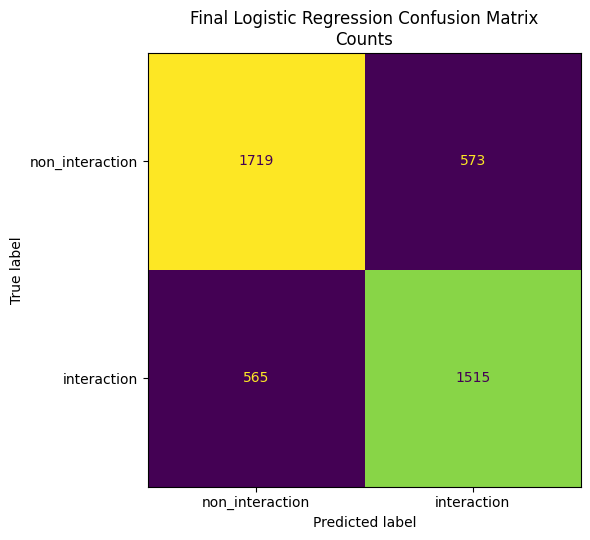

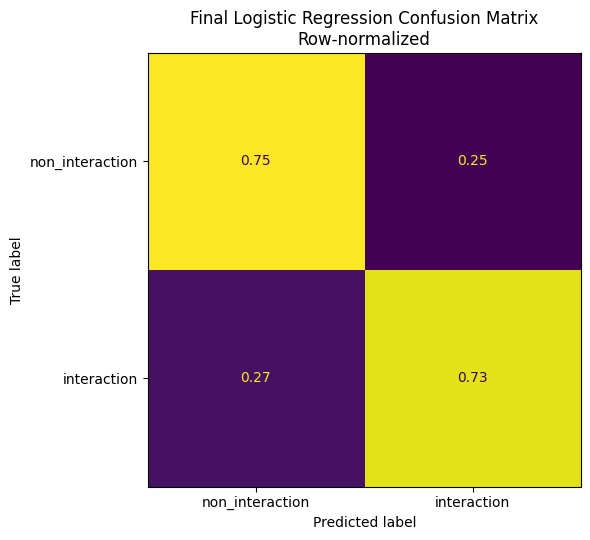

Confusion matrix counts:
                      pred_non_interaction  pred_interaction
true_non_interaction                  1719               573
true_interaction                       565              1515

Confusion matrix normalized by true label:
                      pred_non_interaction  pred_interaction
true_non_interaction                 0.750             0.250
true_interaction                     0.272             0.728


In [ ]:
# ============================================================
# CONFUSION MATRIX VISUALS
# ============================================================

cm = confusion_matrix(all_true, all_pred, labels=label_order)
cm_norm = confusion_matrix(all_true, all_pred, labels=label_order, normalize="true")

# Count confusion matrix
fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("Final Logistic Regression Confusion Matrix\nCounts")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix_counts.png", dpi=300, bbox_inches="tight")
plt.show()

# Normalized confusion matrix
fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_order)
disp.plot(ax=ax, values_format=".2f", colorbar=False)
ax.set_title("Final Logistic Regression Confusion Matrix\nRow-normalized")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix counts:")
print(pd.DataFrame(cm, index=[f"true_{x}" for x in label_order], columns=[f"pred_{x}" for x in label_order]))

print("\nConfusion matrix normalized by true label:")
print(pd.DataFrame(cm_norm, index=[f"true_{x}" for x in label_order], columns=[f"pred_{x}" for x in label_order]).round(3))

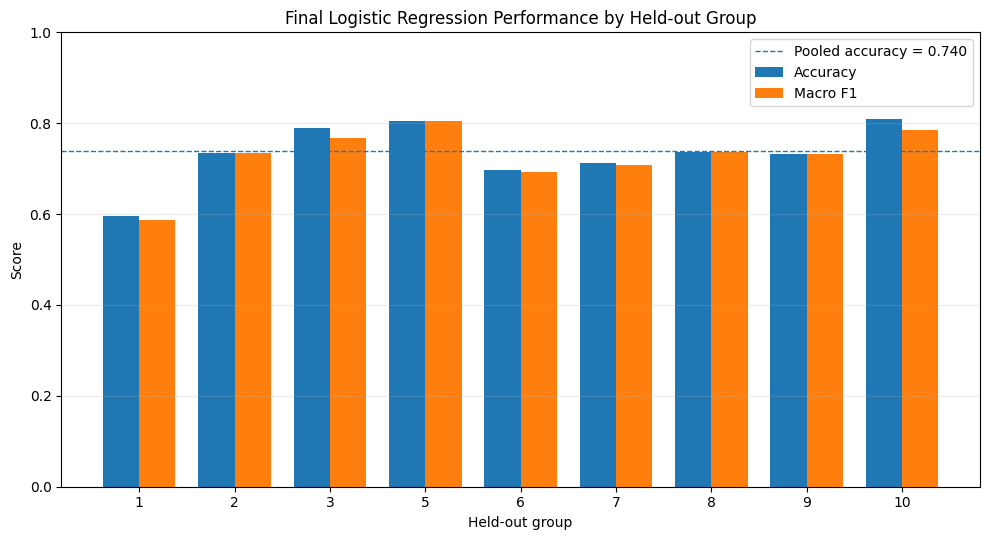

In [ ]:
# ============================================================
# PER-GROUP ACCURACY AND MACRO F1
# ============================================================

plot_df = fold_df.sort_values("test_group").copy()
plot_df["test_group"] = plot_df["test_group"].astype(str)

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(x - width/2, plot_df["accuracy"], width, label="Accuracy")
ax.bar(x + width/2, plot_df["macro_f1"], width, label="Macro F1")

ax.axhline(overall_acc, linestyle="--", linewidth=1, label=f"Pooled accuracy = {overall_acc:.3f}")
ax.set_title("Final Logistic Regression Performance by Held-out Group")
ax.set_xlabel("Held-out group")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["test_group"])
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/per_group_performance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# EXPLAINABILITY 1:
# LOGISTIC REGRESSION COEFFICIENTS ACROSS LOGO FOLDS
# ============================================================

coef_rows = []

# Use numeric labels so coefficient sign is fully clear:
# 0 = non_interaction
# 1 = interaction
y_num = pd.Series(y).map({
    "non_interaction": 0,
    "interaction": 1
}).values

for train_idx, test_idx in logo.split(X, y_num, groups):
    test_group = groups[test_idx][0]

    model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )

    model.fit(X[train_idx], y_num[train_idx])

    lr = model.named_steps["logisticregression"]
    betas = lr.coef_[0]

    for feat, beta in zip(final_features, betas):
        coef_rows.append({
            "test_group": test_group,
            "feature": feat,
            "beta": beta,
            "abs_beta": abs(beta),
            "direction": "interaction" if beta > 0 else "non_interaction"
        })

coef_df = pd.DataFrame(coef_rows)

coef_summary = (
    coef_df
    .groupby("feature")
    .agg(
        mean_beta=("beta", "mean"),
        std_beta=("beta", "std"),
        mean_abs_beta=("abs_beta", "mean"),
        positive_folds=("beta", lambda x: int((x > 0).sum())),
        negative_folds=("beta", lambda x: int((x < 0).sum())),
    )
    .reset_index()
)

coef_summary["effect"] = np.where(
    coef_summary["mean_beta"] > 0,
    "pushes interaction",
    "pushes non_interaction"
)

coef_summary["stability"] = coef_summary.apply(
    lambda r: max(r["positive_folds"], r["negative_folds"]) / (r["positive_folds"] + r["negative_folds"]),
    axis=1
)

coef_summary = coef_summary.sort_values("mean_abs_beta", ascending=False)

coef_summary_path = f"{OUT_DIR}/feature_coefficient_explainability.csv"
coef_summary.to_csv(coef_summary_path, index=False)

print("Coefficient explainability:")
print(coef_summary.round(4).to_string(index=False))
print("\nSaved:", coef_summary_path)

Coefficient explainability:
        feature  mean_beta  std_beta  mean_abs_beta  positive_folds  negative_folds                 effect  stability
dist_close_mean    -0.7693    0.2053         0.7693               0               9 pushes non_interaction     1.0000
 dist_disp_mean    -0.3573    0.0226         0.3573               0               9 pushes non_interaction     1.0000
       accE_mid     0.3153    0.0387         0.3153               9               0     pushes interaction     1.0000
  dist_mid_mean    -0.2774    0.0561         0.2774               0               9 pushes non_interaction     1.0000
 centroid_speed     0.2678    0.0786         0.2678               9               0     pushes interaction     1.0000
 dist_close_min     0.2182    0.1084         0.2182               9               0     pushes interaction     1.0000
  dist_far_mean     0.0774    0.2157         0.1824               7               2     pushes interaction     0.7778
  dist_disp_std     0.0918  

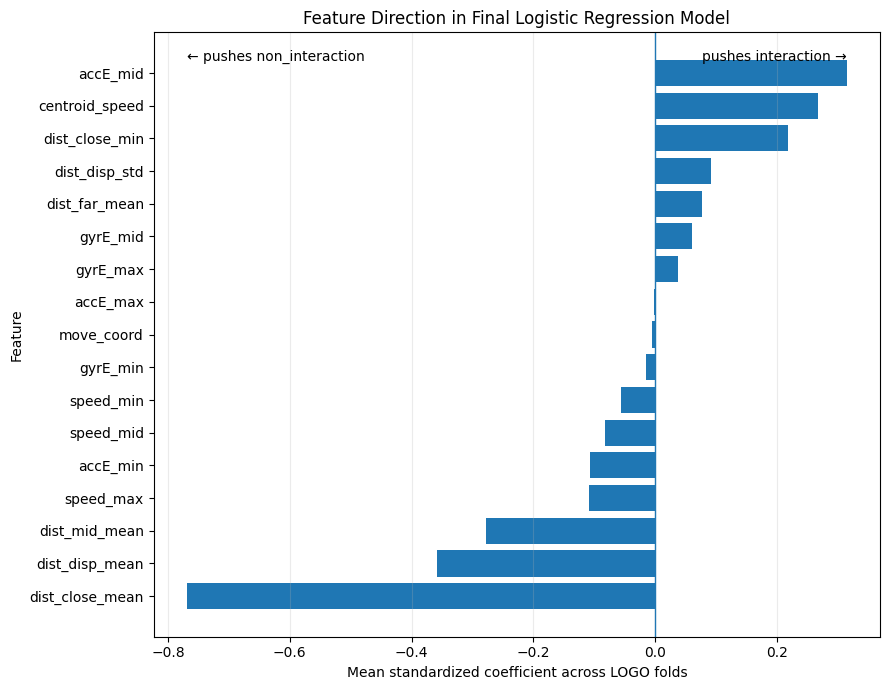

In [ ]:
# ============================================================
# COEFFICIENT PLOT
# ============================================================

coef_plot = coef_summary.sort_values("mean_beta").copy()

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(coef_plot["feature"], coef_plot["mean_beta"])
ax.axvline(0, linewidth=1)

ax.set_title("Feature Direction in Final Logistic Regression Model")
ax.set_xlabel("Mean standardized coefficient across LOGO folds")
ax.set_ylabel("Feature")

# Add labels explaining direction
ax.text(
    coef_plot["mean_beta"].min(),
    len(coef_plot) - 0.5,
    "← pushes non_interaction",
    va="center",
    ha="left"
)

ax.text(
    coef_plot["mean_beta"].max(),
    len(coef_plot) - 0.5,
    "pushes interaction →",
    va="center",
    ha="right"
)

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_coefficients_direction.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# EXPLAINABILITY 2:
# PERMUTATION IMPORTANCE ON HELD-OUT GROUPS
# ============================================================

from sklearn.inspection import permutation_importance

perm_rows = []

for train_idx, test_idx in logo.split(X, y, groups):
    test_group = groups[test_idx][0]

    model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )

    model.fit(X[train_idx], y[train_idx])

    perm = permutation_importance(
        model,
        X[test_idx],
        y[test_idx],
        scoring="f1_macro",
        n_repeats=30,
        random_state=42
    )

    for feat, mean_imp, std_imp in zip(final_features, perm.importances_mean, perm.importances_std):
        perm_rows.append({
            "test_group": test_group,
            "feature": feat,
            "perm_macro_f1_drop_mean": mean_imp,
            "perm_macro_f1_drop_std": std_imp,
        })

perm_df = pd.DataFrame(perm_rows)

perm_summary = (
    perm_df
    .groupby("feature")
    .agg(
        mean_perm_macro_f1_drop=("perm_macro_f1_drop_mean", "mean"),
        std_perm_macro_f1_drop=("perm_macro_f1_drop_mean", "std"),
    )
    .reset_index()
    .sort_values("mean_perm_macro_f1_drop", ascending=False)
)

perm_summary_path = f"{OUT_DIR}/feature_permutation_importance.csv"
perm_summary.to_csv(perm_summary_path, index=False)

print("Permutation importance:")
print(perm_summary.round(4).to_string(index=False))
print("\nSaved:", perm_summary_path)

Permutation importance:
        feature  mean_perm_macro_f1_drop  std_perm_macro_f1_drop
dist_close_mean                   0.1755                  0.0560
 dist_disp_mean                   0.0198                  0.0175
  dist_disp_std                   0.0124                  0.0412
  dist_mid_mean                   0.0095                  0.0136
       accE_mid                   0.0090                  0.0043
 centroid_speed                   0.0083                  0.0178
      speed_max                   0.0059                  0.0065
  dist_far_mean                   0.0027                  0.0096
 dist_close_min                   0.0025                  0.0060
      speed_mid                   0.0014                  0.0036
       accE_max                   0.0010                  0.0030
     move_coord                   0.0006                  0.0029
      speed_min                   0.0005                  0.0020
       gyrE_max                   0.0003                  0.0021
 

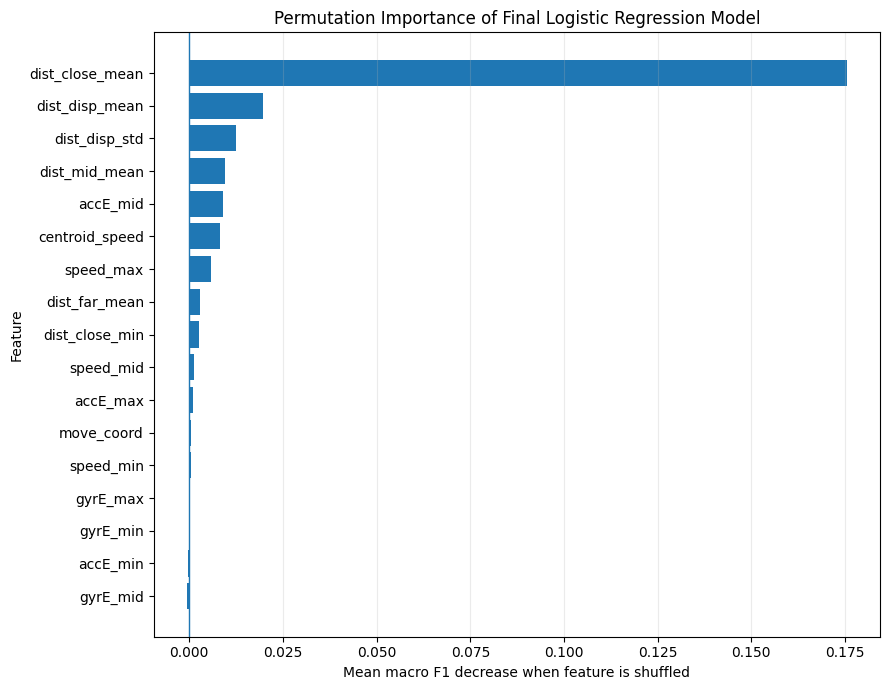

In [ ]:
# ============================================================
# PERMUTATION IMPORTANCE PLOT
# ============================================================

perm_plot = perm_summary.sort_values("mean_perm_macro_f1_drop", ascending=True).copy()

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(perm_plot["feature"], perm_plot["mean_perm_macro_f1_drop"])
ax.axvline(0, linewidth=1)

ax.set_title("Permutation Importance of Final Logistic Regression Model")
ax.set_xlabel("Mean macro F1 decrease when feature is shuffled")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# COMBINED EXPLAINABILITY TABLE
# ============================================================

explainability = coef_summary.merge(perm_summary, on="feature", how="left")

explainability = explainability[
    [
        "feature",
        "mean_beta",
        "std_beta",
        "mean_abs_beta",
        "effect",
        "positive_folds",
        "negative_folds",
        "stability",
        "mean_perm_macro_f1_drop",
        "std_perm_macro_f1_drop",
    ]
].sort_values("mean_perm_macro_f1_drop", ascending=False)

explainability_path = f"{OUT_DIR}/final_model_explainability_combined.csv"
explainability.to_csv(explainability_path, index=False)

print("Combined explainability:")
print(explainability.round(4).to_string(index=False))

print("\nSaved:")
print(explainability_path)

Combined explainability:
        feature  mean_beta  std_beta  mean_abs_beta                 effect  positive_folds  negative_folds  stability  mean_perm_macro_f1_drop  std_perm_macro_f1_drop
dist_close_mean    -0.7693    0.2053         0.7693 pushes non_interaction               0               9     1.0000                   0.1755                  0.0560
 dist_disp_mean    -0.3573    0.0226         0.3573 pushes non_interaction               0               9     1.0000                   0.0198                  0.0175
  dist_disp_std     0.0918    0.1448         0.1200     pushes interaction               6               3     0.6667                   0.0124                  0.0412
  dist_mid_mean    -0.2774    0.0561         0.2774 pushes non_interaction               0               9     1.0000                   0.0095                  0.0136
       accE_mid     0.3153    0.0387         0.3153     pushes interaction               9               0     1.0000                   0.00

Top features for distribution plots:
['dist_close_mean', 'dist_disp_mean', 'dist_disp_std', 'dist_mid_mean', 'accE_mid', 'centroid_speed']


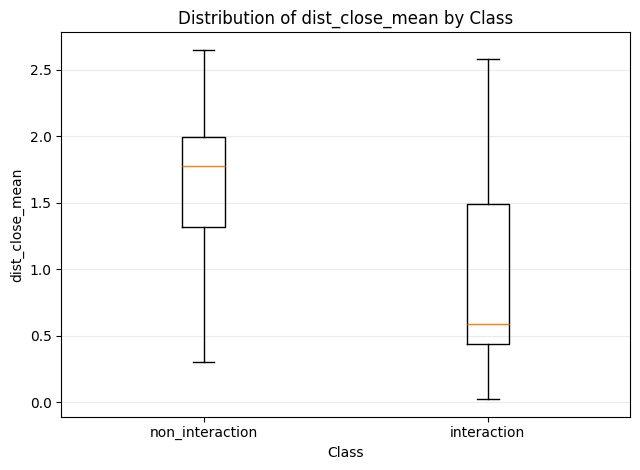

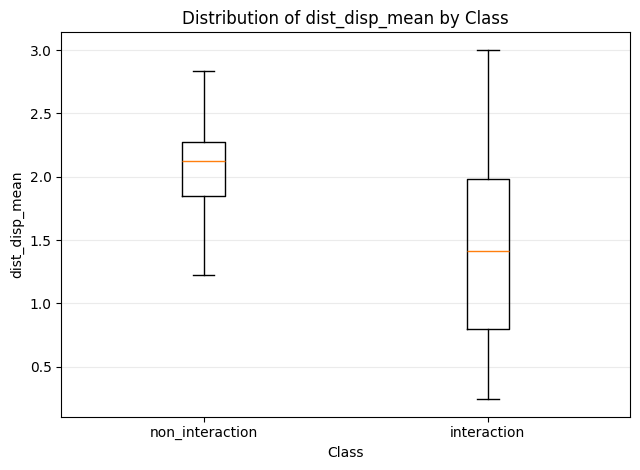

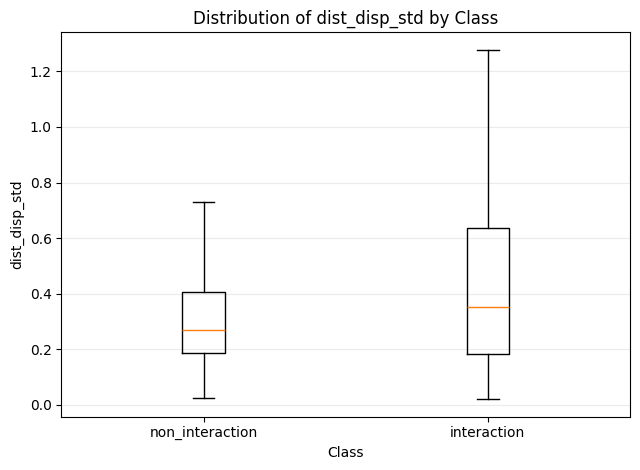

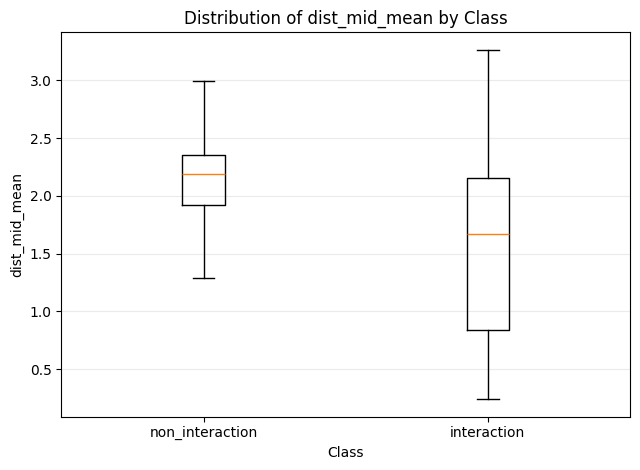

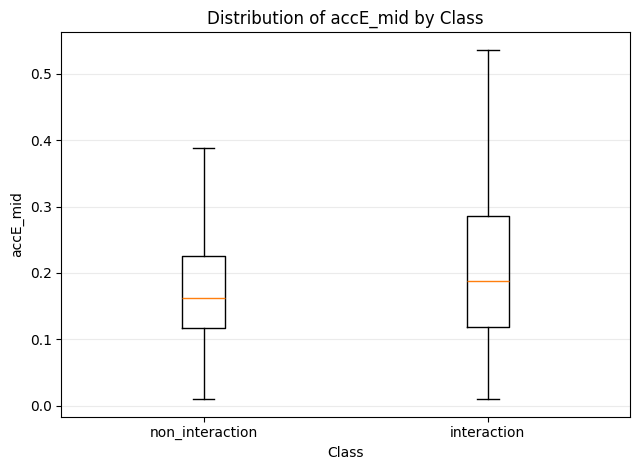

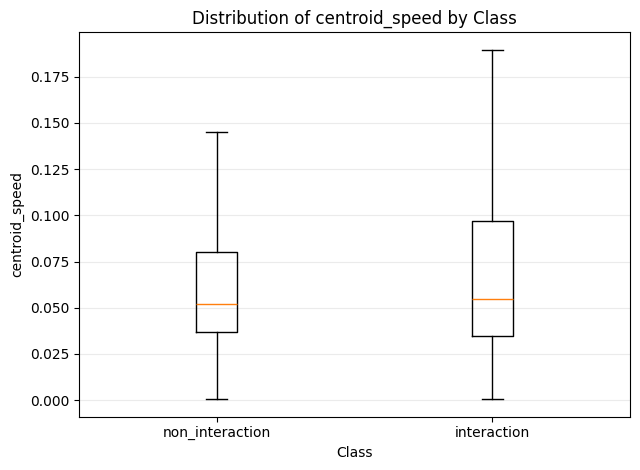

In [ ]:
# ============================================================
# FEATURE DISTRIBUTIONS FOR TOP IMPORTANT FEATURES
# ============================================================

# Select top 6 by permutation importance
top_features = (
    perm_summary
    .sort_values("mean_perm_macro_f1_drop", ascending=False)
    .head(6)["feature"]
    .tolist()
)

print("Top features for distribution plots:")
print(top_features)

for feat in top_features:
    plot_data = df[[feat, "label"]].copy()
    plot_data[feat] = pd.to_numeric(plot_data[feat], errors="coerce")
    plot_data = plot_data.dropna()

    labels = ["non_interaction", "interaction"]
    data_to_plot = [
        plot_data.loc[plot_data["label"] == lab, feat].values
        for lab in labels
    ]

    fig, ax = plt.subplots(figsize=(6.5, 4.8))

    ax.boxplot(
        data_to_plot,
        labels=labels,
        showfliers=False
    )

    ax.set_title(f"Distribution of {feat} by Class")
    ax.set_xlabel("Class")
    ax.set_ylabel(feat)
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/distribution_{feat}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
# ============================================================
# FINAL THESIS SUMMARY TABLE
# ============================================================

summary_table = pd.DataFrame([
    {
        "dataset": "ENG3",
        "task": "Binary interaction detection",
        "model": "Logistic Regression",
        "feature_set": "Old ENG features only",
        "n_windows": len(df),
        "n_features": len(final_features),
        "evaluation": "Leave-One-Group-Out",
        "pooled_accuracy": overall_acc,
        "pooled_macro_f1": overall_mf1,
        "interaction_windows": int((df["label"] == "interaction").sum()),
        "non_interaction_windows": int((df["label"] == "non_interaction").sum()),
    }
])

summary_path = f"{OUT_DIR}/final_model_summary_table.csv"
summary_table.to_csv(summary_path, index=False)

print(summary_table.round(3).to_string(index=False))
print("\nSaved:", summary_path)

dataset                         task               model           feature_set  n_windows  n_features          evaluation  pooled_accuracy  pooled_macro_f1  interaction_windows  non_interaction_windows
   ENG3 Binary interaction detection Logistic Regression Old ENG features only       4372          17 Leave-One-Group-Out             0.74            0.739                 2080                     2292

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/final_model_visuals/final_model_summary_table.csv


##DEEP LEARNING MODELS

In [ ]:
# ============================================================
# LOAD ENG3 TENSORS FOR DEEP LEARNING
# ============================================================

import os
import random
import copy
import math
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

TENSOR_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_tensors.npz"
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/dl_binary_results"
os.makedirs(OUT_DIR, exist_ok=True)

data = np.load(TENSOR_PATH, allow_pickle=True)

X = data["X"].astype(np.float32)
y_raw = data["y"]
groups = data["groups"]

# Decode labels/groups safely
y_str = np.array([
    v.decode("utf-8") if isinstance(v, bytes) else str(v)
    for v in y_raw
])

groups = np.array([
    int(v.decode("utf-8")) if isinstance(v, bytes) else int(v)
    for v in groups
])

# Binary mapping
# 0 = non_interaction
# 1 = interaction
y = (y_str == "interaction").astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

print("\nLabel counts:")
print(pd.Series(y_str).value_counts())

print("\nGroup counts:")
print(pd.Series(groups).value_counts().sort_index())

print("\nChannels in ENG3 tensor:")
print("The tensor has shape: windows × time steps × channels")
print("In your ENG3 builder, the 7 channels are:")
tensor_channels = [
    "dist_close",
    "dist_mid",
    "dist_far",
    "centroid_speed",
    "accmag_mean",
    "accmag_max",
    "gyromag_mean",
]
for i, c in enumerate(tensor_channels):
    print(f"{i}: {c}")

Device: cpu
X shape: (4372, 64, 7)
y shape: (4372,)
groups shape: (4372,)

Label counts:
non_interaction    2292
interaction        2080
Name: count, dtype: int64

Group counts:
1     366
2     525
3     527
5     661
6     274
7     576
8     457
9     703
10    283
Name: count, dtype: int64

Channels in ENG3 tensor:
The tensor has shape: windows × time steps × channels
In your ENG3 builder, the 7 channels are:
0: dist_close
1: dist_mid
2: dist_far
3: centroid_speed
4: accmag_mean
5: accmag_max
6: gyromag_mean


In [ ]:
# ============================================================
# DATASET + TRAINING HELPERS
# ============================================================

class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def standardize_train_val_test(X_train, X_val, X_test):
    """
    Fit channel-wise mean/std on training data only.
    Shape: N x T x C
    """
    mean = np.nanmean(X_train, axis=(0, 1), keepdims=True)
    std = np.nanstd(X_train, axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)

    X_train_s = (X_train - mean) / std
    X_val_s = (X_val - mean) / std
    X_test_s = (X_test - mean) / std

    X_train_s = np.nan_to_num(X_train_s, nan=0.0, posinf=0.0, neginf=0.0)
    X_val_s = np.nan_to_num(X_val_s, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_s = np.nan_to_num(X_test_s, nan=0.0, posinf=0.0, neginf=0.0)

    return X_train_s, X_val_s, X_test_s


def evaluate_loader(model, loader):
    model.eval()

    all_logits = []
    all_true = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb).detach().cpu().numpy()
            all_logits.extend(logits)
            all_true.extend(yb.numpy())

    all_logits = np.array(all_logits)
    all_true = np.array(all_true).astype(int)

    probs = 1 / (1 + np.exp(-all_logits))
    preds = (probs >= 0.5).astype(int)

    acc = accuracy_score(all_true, preds)
    mf1 = f1_score(all_true, preds, average="macro", zero_division=0)

    return acc, mf1, all_true, preds, probs


def train_one_fold(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    max_epochs=80,
    batch_size=64,
    lr=1e-3,
    patience=12,
):
    train_ds = WindowDataset(X_train, y_train)
    val_ds = WindowDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    model = model.to(DEVICE)

    n_pos = max((y_train == 1).sum(), 1)
    n_neg = max((y_train == 0).sum(), 1)
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_state = None
    best_val_f1 = -1
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

        val_acc, val_f1, _, _, _ = evaluate_loader(model, val_loader)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    model.load_state_dict(best_state)

    return model, best_epoch, best_val_f1

In [ ]:
# ============================================================
# CNN / RNN / GRU / LSTM MODELS
# ============================================================

class CNN1DClassifier(nn.Module):
    def __init__(self, n_channels, hidden=64, dropout=0.25):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(32, hidden, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden, hidden, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        # x: B x T x C
        x = x.transpose(1, 2)  # B x C x T
        h = self.net(x)
        h = self.pool(h).squeeze(-1)
        return self.head(h).squeeze(-1)


class RNNClassifier(nn.Module):
    def __init__(self, n_channels, hidden=64, num_layers=1, dropout=0.25, rnn_type="gru"):
        super().__init__()

        self.rnn_type = rnn_type.lower()

        rnn_dropout = dropout if num_layers > 1 else 0.0

        if self.rnn_type == "rnn":
            self.rnn = nn.RNN(
                input_size=n_channels,
                hidden_size=hidden,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=True
            )
        elif self.rnn_type == "gru":
            self.rnn = nn.GRU(
                input_size=n_channels,
                hidden_size=hidden,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=True
            )
        elif self.rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=n_channels,
                hidden_size=hidden,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=True
            )
        else:
            raise ValueError("rnn_type must be 'rnn', 'gru', or 'lstm'")

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, 1)
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        h = out.mean(dim=1)
        return self.head(h).squeeze(-1)

In [ ]:
# ============================================================
# TRANSFORMER WITH NONE / SINUSOIDAL / LEARNED / ROTARY
# ============================================================

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        # x: B x T x D
        T = x.size(1)
        return x + self.pe[:, :T, :]


class LearnedPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        B, T, D = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        return x + self.pos_embedding(pos)


def apply_rope(x):
    """
    Rotary positional encoding applied to Q/K.
    x shape: B x H x T x Dh
    Dh must be even.
    """
    B, H, T, Dh = x.shape

    if Dh % 2 != 0:
        raise ValueError("Head dimension must be even for RoPE.")

    half = Dh // 2

    pos = torch.arange(T, device=x.device).float()
    freq = torch.exp(
        -math.log(10000.0)
        * torch.arange(0, half, device=x.device).float()
        / half
    )

    angles = pos[:, None] * freq[None, :]
    sin = torch.sin(angles)[None, None, :, :]
    cos = torch.cos(angles)[None, None, :, :]

    x_even = x[..., 0::2]
    x_odd = x[..., 1::2]

    x_rot_even = x_even * cos - x_odd * sin
    x_rot_odd = x_even * sin + x_odd * cos

    x_out = torch.stack([x_rot_even, x_rot_odd], dim=-1)
    x_out = x_out.flatten(-2)

    return x_out


class CustomMultiHeadAttention(nn.Module):
    def __init__(self, d_model=64, n_heads=4, dropout=0.1, use_rope=False):
        super().__init__()

        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.use_rope = use_rope

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, D = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        if self.use_rope:
            q = apply_rope(q)
            k = apply_rope(k)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        out = self.out_proj(out)

        return out


class TransformerBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4, ff_dim=128, dropout=0.15, use_rope=False):
        super().__init__()

        self.attn = CustomMultiHeadAttention(
            d_model=d_model,
            n_heads=n_heads,
            dropout=dropout,
            use_rope=use_rope
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        h = self.attn(self.norm1(x))
        x = x + self.dropout(h)

        h = self.ff(self.norm2(x))
        x = x + self.dropout(h)

        return x


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        n_channels,
        seq_len=64,
        d_model=64,
        n_heads=4,
        n_layers=2,
        ff_dim=128,
        dropout=0.15,
        pos_encoding="none",
    ):
        super().__init__()

        self.pos_encoding = pos_encoding.lower()

        self.input_proj = nn.Linear(n_channels, d_model)

        if self.pos_encoding == "none":
            self.pos_layer = nn.Identity()
            use_rope = False

        elif self.pos_encoding == "sinusoidal":
            self.pos_layer = SinusoidalPositionalEncoding(d_model, max_len=seq_len + 10)
            use_rope = False

        elif self.pos_encoding == "learned":
            self.pos_layer = LearnedPositionalEncoding(d_model, max_len=seq_len + 10)
            use_rope = False

        elif self.pos_encoding in ["rotary", "rope"]:
            self.pos_layer = nn.Identity()
            use_rope = True

        else:
            raise ValueError("pos_encoding must be none, sinusoidal, learned, or rotary")

        self.blocks = nn.ModuleList([
            TransformerBlock(
                d_model=d_model,
                n_heads=n_heads,
                ff_dim=ff_dim,
                dropout=dropout,
                use_rope=use_rope
            )
            for _ in range(n_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def forward(self, x):
        # x: B x T x C
        h = self.input_proj(x)
        h = self.pos_layer(h)

        for block in self.blocks:
            h = block(h)

        h = self.norm(h)

        # Mean pooling over time
        h = h.mean(dim=1)

        return self.head(h).squeeze(-1)

In [ ]:
# ============================================================
# CELL 5 — SIMPLE LOGO DEEP LEARNING EXPERIMENTS
# No validation group.
# Each group is used as test group once.
# For each fold:
#     train on 8 groups
#     test on 1 held-out group
# ============================================================

def standardize_train_test(X_train, X_test):
    """
    Fit channel-wise mean/std on training data only.
    Shape: N x T x C
    """
    mean = np.nanmean(X_train, axis=(0, 1), keepdims=True)
    std = np.nanstd(X_train, axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)

    X_train_s = (X_train - mean) / std
    X_test_s = (X_test - mean) / std

    X_train_s = np.nan_to_num(X_train_s, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_s = np.nan_to_num(X_test_s, nan=0.0, posinf=0.0, neginf=0.0)

    return X_train_s, X_test_s


def train_fixed_epochs(
    model,
    X_train,
    y_train,
    max_epochs=30,
    batch_size=64,
    lr=1e-3,
):
    train_ds = WindowDataset(X_train, y_train)
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )

    model = model.to(DEVICE)

    n_pos = max((y_train == 1).sum(), 1)
    n_neg = max((y_train == 0).sum(), 1)
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            epoch_losses.append(loss.item())

        if epoch == 1 or epoch % 10 == 0 or epoch == max_epochs:
            print(f"    epoch {epoch:03d}/{max_epochs} | train_loss={np.mean(epoch_losses):.4f}")

    return model


def run_logo_dl_experiment_no_validation(
    X,
    y,
    groups,
    model_names,
    max_epochs=30,
    batch_size=64,
    lr=1e-3,
):
    seq_len = X.shape[1]
    n_channels = X.shape[2]

    logo = LeaveOneGroupOut()

    all_summary_rows = []
    all_fold_rows = []
    all_prediction_rows = []

    for model_name in model_names:
        print("\n" + "=" * 80)
        print("MODEL:", model_name)
        print("=" * 80)

        model_true_all = []
        model_pred_all = []
        model_prob_all = []

        for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups),
            start=1
        ):
            test_group = groups[test_idx][0]

            X_train_raw, y_train = X[train_idx], y[train_idx]
            X_test_raw, y_test = X[test_idx], y[test_idx]

            # Standardize using only the 8 training groups
            X_train, X_test = standardize_train_test(
                X_train_raw,
                X_test_raw
            )

            set_seed(SEED + fold)

            model = make_model(
                model_name,
                n_channels=n_channels,
                seq_len=seq_len
            )

            print("\n" + "-" * 80)
            print(f"Fold {fold}/9 | Test group: {test_group}")
            print(f"Train groups: {sorted(np.unique(groups[train_idx]).tolist())}")
            print(f"Test group: {test_group}")
            print(f"Train windows: {len(train_idx)} | Test windows: {len(test_idx)}")
            print("-" * 80)

            model = train_fixed_epochs(
                model=model,
                X_train=X_train,
                y_train=y_train,
                max_epochs=max_epochs,
                batch_size=batch_size,
                lr=lr,
            )

            test_loader = DataLoader(
                WindowDataset(X_test, y_test),
                batch_size=batch_size,
                shuffle=False
            )

            test_acc, test_f1, true, pred, prob = evaluate_loader(
                model,
                test_loader
            )

            print(
                f"FINAL | Test group {test_group} | "
                f"acc={test_acc:.3f} | macroF1={test_f1:.3f}"
            )

            all_fold_rows.append({
                "model": model_name,
                "fold": int(fold),
                "test_group": int(test_group),
                "accuracy": float(test_acc),
                "macro_f1": float(test_f1),
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
                "max_epochs": int(max_epochs),
            })

            for t, p, pr in zip(true, pred, prob):
                all_prediction_rows.append({
                    "model": model_name,
                    "test_group": int(test_group),
                    "true_label_num": int(t),
                    "pred_label_num": int(p),
                    "true_label": "interaction" if t == 1 else "non_interaction",
                    "predicted_label": "interaction" if p == 1 else "non_interaction",
                    "probability_interaction": float(pr),
                    "correct": bool(t == p),
                })

            model_true_all.extend(true)
            model_pred_all.extend(pred)
            model_prob_all.extend(prob)

        pooled_acc = accuracy_score(model_true_all, model_pred_all)
        pooled_mf1 = f1_score(
            model_true_all,
            model_pred_all,
            average="macro",
            zero_division=0
        )

        fold_subset = pd.DataFrame(all_fold_rows)
        fold_subset = fold_subset[fold_subset["model"] == model_name]

        mean_group_acc = fold_subset["accuracy"].mean()
        mean_group_f1 = fold_subset["macro_f1"].mean()

        all_summary_rows.append({
            "model": model_name,
            "n_rows": int(len(X)),
            "seq_len": int(seq_len),
            "n_channels": int(n_channels),
            "max_epochs": int(max_epochs),
            "pooled_accuracy": float(pooled_acc),
            "pooled_macro_f1": float(pooled_mf1),
            "mean_group_accuracy": float(mean_group_acc),
            "mean_group_macro_f1": float(mean_group_f1),
        })

        print("\n" + "=" * 80)
        print("POOLED RESULT FOR", model_name)
        print("=" * 80)
        print("Pooled accuracy:", round(pooled_acc, 3))
        print("Pooled macro F1:", round(pooled_mf1, 3))
        print("Mean-group accuracy:", round(mean_group_acc, 3))
        print("Mean-group macro F1:", round(mean_group_f1, 3))

    summary_df = pd.DataFrame(all_summary_rows)
    fold_df = pd.DataFrame(all_fold_rows)
    pred_df = pd.DataFrame(all_prediction_rows)

    return summary_df, fold_df, pred_df


# ============================================================
# RUN MODELS
# ============================================================

model_names = [
    "cnn1d",
    "rnn",
    "gru",
    "lstm",
    "tf_none",
    "tf_sinusoidal",
    "tf_learned",
    "tf_rotary",
]

print("=" * 80)
print("SIMPLE DEEP LEARNING LOGO RUN — NO VALIDATION GROUP")
print("=" * 80)
print("Models:", model_names)
print("Groups:", sorted(np.unique(groups).tolist()))
print("Total trainings:", len(model_names) * len(np.unique(groups)))
print("Training setup: 8 groups train, 1 group test, repeated for all groups")

summary_df, fold_df, pred_df = run_logo_dl_experiment_no_validation(
    X=X,
    y=y,
    groups=groups,
    model_names=model_names,
    max_epochs=30,
    batch_size=64,
    lr=1e-3,
)

summary_df = summary_df.sort_values("pooled_macro_f1", ascending=False)

print("\n" + "=" * 80)
print("DEEP LEARNING SUMMARY")
print("=" * 80)
print(summary_df.round(3).to_string(index=False))

print("\n" + "=" * 80)
print("FOLD RESULTS")
print("=" * 80)
print(fold_df.round(3).to_string(index=False))

summary_path = f"{OUT_DIR}/dl_eng3_logo_no_validation_summary.csv"
fold_path = f"{OUT_DIR}/dl_eng3_logo_no_validation_folds.csv"
pred_path = f"{OUT_DIR}/dl_eng3_logo_no_validation_predictions.csv"

summary_df.to_csv(summary_path, index=False)
fold_df.to_csv(fold_path, index=False)
pred_df.to_csv(pred_path, index=False)

print("\nSaved:")
print(summary_path)
print(fold_path)
print(pred_path)

SIMPLE DEEP LEARNING LOGO RUN — NO VALIDATION GROUP
Models: ['cnn1d', 'rnn', 'gru', 'lstm', 'tf_none', 'tf_sinusoidal', 'tf_learned', 'tf_rotary']
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]
Total trainings: 72
Training setup: 8 groups train, 1 group test, repeated for all groups

MODEL: cnn1d

--------------------------------------------------------------------------------
Fold 1/9 | Test group: 1
Train groups: [2, 3, 5, 6, 7, 8, 9, 10]
Test group: 1
Train windows: 4006 | Test windows: 366
--------------------------------------------------------------------------------
    epoch 001/30 | train_loss=0.5672
    epoch 010/30 | train_loss=0.5208
    epoch 020/30 | train_loss=0.5096
    epoch 030/30 | train_loss=0.5017
FINAL | Test group 1 | acc=0.530 | macroF1=0.529

--------------------------------------------------------------------------------
Fold 2/9 | Test group: 2
Train groups: [1, 3, 5, 6, 7, 8, 9, 10]
Test group: 2
Train windows: 3847 | Test windows: 525
--------------------------------

KeyboardInterrupt: 

In [ ]:
try:
    print("summary_df exists")
    display(summary_df)
except NameError:
    print("summary_df not found")

try:
    print("fold_df exists")
    display(fold_df)
except NameError:
    print("fold_df not found")

try:
    print("pred_df exists")
    display(pred_df.head())
except NameError:
    print("pred_df not found")

summary_df exists


,model,n_rows,seq_len,n_channels,max_epochs,pooled_accuracy,pooled_macro_f1,mean_group_accuracy,mean_group_macro_f1
1,rnn,4372,64,7,30,0.729872,0.728906,0.726229,0.719720
0,cnn1d,4372,64,7,30,0.725526,0.724597,0.716147,0.709367
2,gru,4372,64,7,30,0.720265,0.720258,0.717327,0.709683
3,lstm,4372,64,7,30,0.700366,0.700109,0.701765,0.694327
7,tf_rotary,4372,64,7,30,0.681610,0.681578,0.682507,0.668909
4,tf_none,4372,64,7,30,0.673376,0.673096,0.673873,0.663432
5,tf_sinusoidal,4372,64,7,30,0.666743,0.666290,0.671174,0.661911
6,tf_learned,4372,64,7,30,0.665599,0.665339,0.665495,0.655328


fold_df exists


,model,fold,test_group,accuracy,macro_f1,n_train,n_test,max_epochs
0,cnn1d,1,1,0.530055,0.528647,4006,366,30
1,cnn1d,2,2,0.729524,0.728909,3847,525,30
2,cnn1d,3,3,0.806452,0.788636,3845,527,30
3,cnn1d,4,5,0.821483,0.815910,3711,661,30
4,cnn1d,5,6,0.642336,0.641859,4098,274,30
...,...,...,...,...,...,...,...,...
67,tf_rotary,5,6,0.682482,0.673680,4098,274,30
68,tf_rotary,6,7,0.678819,0.672340,3796,576,30
69,tf_rotary,7,8,0.743982,0.743388,3915,457,30
70,tf_rotary,8,9,0.642959,0.638958,3669,703,30


pred_df exists


,model,test_group,true_label_num,pred_label_num,true_label,predicted_label,probability_interaction,correct
0,cnn1d,1,0,1,non_interaction,interaction,0.751848,False
1,cnn1d,1,1,1,interaction,interaction,0.564880,True
2,cnn1d,1,1,1,interaction,interaction,0.666862,True
3,cnn1d,1,1,0,interaction,non_interaction,0.326275,False
4,cnn1d,1,1,0,interaction,non_interaction,0.360838,False


In [ ]:
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/dl_binary_results"

summary_df.to_csv(f"{OUT_DIR}/dl_eng3_logo_no_validation_summary_RECOVERED.csv", index=False)
fold_df.to_csv(f"{OUT_DIR}/dl_eng3_logo_no_validation_folds_RECOVERED.csv", index=False)
pred_df.to_csv(f"{OUT_DIR}/dl_eng3_logo_no_validation_predictions_RECOVERED.csv", index=False)

print("Recovered files saved.")

Recovered files saved.


,model,n_rows,seq_len,n_channels,max_epochs,pooled_accuracy,pooled_macro_f1,mean_group_accuracy,mean_group_macro_f1
0,logreg_engineered,4372,NaN,NaN,NaN,0.740,0.739,0.735,0.728
1,rnn,4372,64.0,7.0,30.0,0.730,0.729,0.726,0.720
2,cnn1d,4372,64.0,7.0,30.0,0.726,0.725,0.716,0.709
3,gru,4372,64.0,7.0,30.0,0.720,0.720,0.717,0.710
4,lstm,4372,64.0,7.0,30.0,0.700,0.700,0.702,0.694
5,tf_rotary,4372,64.0,7.0,30.0,0.682,0.682,0.683,0.669
6,tf_none,4372,64.0,7.0,30.0,0.673,0.673,0.674,0.663
7,tf_sinusoidal,4372,64.0,7.0,30.0,0.667,0.666,0.671,0.662
8,tf_learned,4372,64.0,7.0,30.0,0.666,0.665,0.665,0.655


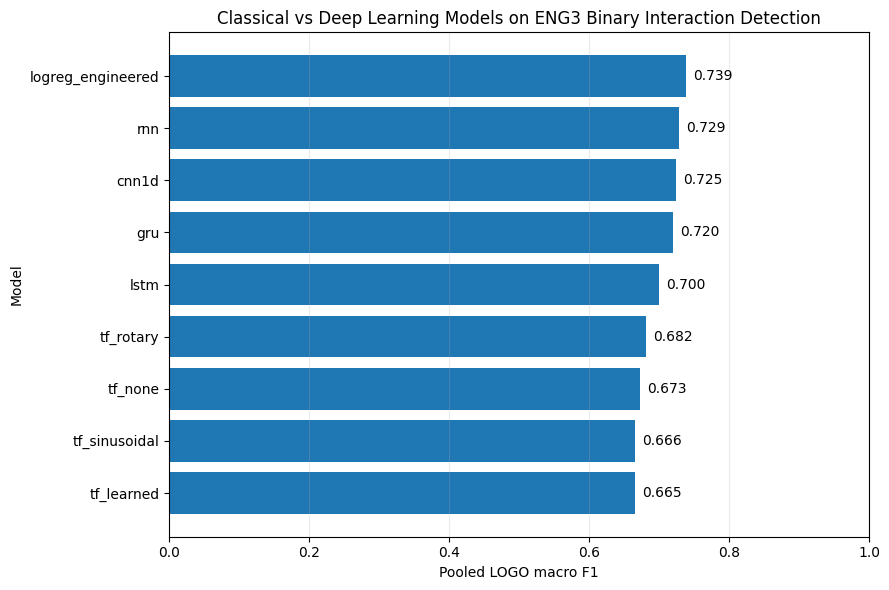

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

baseline = pd.DataFrame([
    {
        "model": "logreg_engineered",
        "n_rows": 4372,
        "seq_len": np.nan,
        "n_channels": np.nan,
        "max_epochs": np.nan,
        "pooled_accuracy": 0.740,
        "pooled_macro_f1": 0.739,
        "mean_group_accuracy": 0.735,
        "mean_group_macro_f1": 0.728,
    }
])

comparison_df = pd.concat([baseline, summary_df], ignore_index=True)
comparison_df = comparison_df.sort_values("pooled_macro_f1", ascending=False)

display(comparison_df.round(3))

comparison_df.to_csv(f"{OUT_DIR}/classical_vs_dl_comparison_RECOVERED.csv", index=False)

plot_df = comparison_df.sort_values("pooled_macro_f1", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df["model"], plot_df["pooled_macro_f1"])
plt.xlabel("Pooled LOGO macro F1")
plt.ylabel("Model")
plt.title("Classical vs Deep Learning Models on ENG3 Binary Interaction Detection")
plt.xlim(0, 1.0)
plt.grid(axis="x", alpha=0.25)

for i, v in enumerate(plot_df["pooled_macro_f1"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/classical_vs_dl_macro_f1_RECOVERED.png", dpi=300, bbox_inches="tight")
plt.show()

##RECOGITION!!!

In [ ]:
# ============================================================
# RECOGNITION TASK — LABEL INVENTORY BEFORE GROUPING
# Goal:
#   Look at all pairwise + whole-group labels first.
#   Do NOT create non_interaction recognition class yet.
#   Decide grouping after seeing real labels.
# ============================================================

import os, glob, re
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

INPUT_DIR = "/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
ENG3_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_features.csv"
OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"

GROUP_TIERS = [
    "label_Participant1_Participant2",
    "label_Participant1_Participant3",
    "label_Participant2_Participant3",
    "label_Whole_Group",
]

def discover(folder):
    groups = {}

    for path in glob.glob(os.path.join(folder, "group_*_model_ready.csv")):
        m = re.search(r"group_(\d+)_([a-z]+)_model_ready", os.path.basename(path))
        if m:
            g = int(m.group(1))
            sensor = m.group(2)
            groups.setdefault(g, {})[sensor] = path

    groups = {
        g: paths
        for g, paths in sorted(groups.items())
        if "openearable" in paths
    }

    return groups


def clean_label_value(v):
    if pd.isna(v):
        return None

    s = str(v).strip()

    if s == "" or s.lower() in ["nan", "none", "null"]:
        return None

    return s


def normalize_label(s):
    if s is None:
        return None

    s = str(s).strip().lower()
    s = s.replace("-", "_")
    s = s.replace(" ", "_")
    s = re.sub(r"_+", "_", s)

    # common typo fixes, only for analysis
    s = s.replace("mering", "merging")
    s = s.replace("synchornizaion", "synchronization")
    s = s.replace("syncornaziton", "synchronization")
    s = s.replace("erarble", "earable")

    return s


def is_technical_label(label):
    lab = normalize_label(label)

    if lab is None:
        return False

    technical_keywords = [
        "sync",
        "synchronization",
        "earable",
        "drop",
        "dropping",
        "calibration",
    ]

    return any(k in lab for k in technical_keywords)


def load_openearable_labels(path):
    df = pd.read_csv(path, low_memory=False)

    df["t"] = pd.to_numeric(df["video_time_s"], errors="coerce")
    df = df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)

    for col in GROUP_TIERS:
        if col not in df.columns:
            df[col] = np.nan

    return df[["t"] + GROUP_TIERS]


groups_paths = discover(INPUT_DIR)
eng3 = pd.read_csv(ENG3_PATH)

all_label_rows = []
window_label_rows = []

# ------------------------------------------------------------
# Part A — sample-level / duration-like inventory
# ------------------------------------------------------------

for group, paths in groups_paths.items():
    print(f"Reading group {group}")

    oe = load_openearable_labels(paths["openearable"])

    # Estimate sampling interval for approximate duration
    dt = np.nanmedian(np.diff(oe["t"].values))
    if not np.isfinite(dt) or dt <= 0:
        dt = 1 / 50

    for tier in GROUP_TIERS:
        vals = oe[tier].apply(clean_label_value)

        for raw_label, count in vals.dropna().value_counts().items():
            all_label_rows.append({
                "group": group,
                "tier": tier,
                "tier_type": "whole_group" if tier == "label_Whole_Group" else "pairwise",
                "raw_label": raw_label,
                "normalized_label": normalize_label(raw_label),
                "is_technical_or_sync": is_technical_label(raw_label),
                "sample_count": int(count),
                "approx_duration_s": float(count * dt),
            })


label_inventory = pd.DataFrame(all_label_rows)

# ------------------------------------------------------------
# Part B — window-level inventory using ENG3 interaction windows only
# This tells us which labels appear in the actual recognition candidates.
# ------------------------------------------------------------

for group in sorted(eng3["group"].unique()):
    oe = load_openearable_labels(groups_paths[group]["openearable"])
    t = oe["t"].values

    group_windows = eng3[
        (eng3["group"] == group)
        & (eng3["label"] == "interaction")
    ].copy()

    for _, win in group_windows.iterrows():
        ws = float(win["window_start"])
        we = float(win["window_end"])

        m = (t >= ws) & (t < we)

        if m.sum() == 0:
            continue

        raw_counter = Counter()
        tier_counter = Counter()

        for tier in GROUP_TIERS:
            vals = oe.loc[m, tier].apply(clean_label_value).dropna()

            for raw_label in vals:
                raw_counter[raw_label] += 1
                tier_counter[tier] += 1

        if len(raw_counter) == 0:
            continue

        dominant_raw_label = raw_counter.most_common(1)[0][0]
        dominant_count = raw_counter.most_common(1)[0][1]

        window_label_rows.append({
            "group": group,
            "window_start": ws,
            "window_end": we,
            "binary_label": win["label"],
            "dominant_raw_label": dominant_raw_label,
            "dominant_normalized_label": normalize_label(dominant_raw_label),
            "dominant_is_technical_or_sync": is_technical_label(dominant_raw_label),
            "dominant_fraction_in_window": dominant_count / max(m.sum(), 1),
            "all_raw_labels_in_window": " | ".join(sorted(raw_counter.keys())),
            "source_tiers_in_window": " | ".join(sorted(tier_counter.keys())),
            "raw_label_counts": dict(raw_counter),
        })


window_label_inventory = pd.DataFrame(window_label_rows)

# ------------------------------------------------------------
# Summary tables
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ALL RAW LABELS FROM PAIRWISE + WHOLE_GROUP TIERS")
print("=" * 80)

raw_summary = (
    label_inventory
    .groupby(["normalized_label", "raw_label", "is_technical_or_sync"])
    .agg(
        sample_count=("sample_count", "sum"),
        approx_duration_s=("approx_duration_s", "sum"),
        groups_present=("group", lambda x: sorted(set(x))),
        tiers_present=("tier", lambda x: sorted(set(x))),
    )
    .reset_index()
    .sort_values("sample_count", ascending=False)
)

display(raw_summary)

print("\n" + "=" * 80)
print("NORMALIZED LABEL SUMMARY")
print("=" * 80)

norm_summary = (
    label_inventory
    .groupby(["normalized_label", "is_technical_or_sync"])
    .agg(
        sample_count=("sample_count", "sum"),
        approx_duration_s=("approx_duration_s", "sum"),
        n_raw_variants=("raw_label", "nunique"),
        raw_variants=("raw_label", lambda x: " | ".join(sorted(set(x)))),
        groups_present=("group", lambda x: sorted(set(x))),
        tiers_present=("tier", lambda x: sorted(set(x))),
    )
    .reset_index()
    .sort_values("sample_count", ascending=False)
)

display(norm_summary)

print("\n" + "=" * 80)
print("DOMINANT LABELS IN ENG3 INTERACTION WINDOWS")
print("=" * 80)

window_summary = (
    window_label_inventory
    .groupby(["dominant_normalized_label", "dominant_raw_label", "dominant_is_technical_or_sync"])
    .agg(
        window_count=("dominant_raw_label", "count"),
        mean_dominant_fraction=("dominant_fraction_in_window", "mean"),
        groups_present=("group", lambda x: sorted(set(x))),
        source_tiers=("source_tiers_in_window", lambda x: " | ".join(sorted(set(x)))),
    )
    .reset_index()
    .sort_values("window_count", ascending=False)
)

display(window_summary)

print("\n" + "=" * 80)
print("DOMINANT LABELS BY GROUP")
print("=" * 80)

display(
    pd.crosstab(
        window_label_inventory["group"],
        window_label_inventory["dominant_normalized_label"]
    )
)

print("\n" + "=" * 80)
print("TECHNICAL / SYNC LABELS")
print("=" * 80)

technical_labels = raw_summary[raw_summary["is_technical_or_sync"] == True]

if len(technical_labels) == 0:
    print("No technical/sync labels found.")
else:
    display(technical_labels)

print("\n" + "=" * 80)
print("NON-TECHNICAL LABELS ONLY")
print("=" * 80)

nontechnical_window_summary = window_summary[
    window_summary["dominant_is_technical_or_sync"] == False
]

display(nontechnical_window_summary)

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------

label_inventory_path = f"{OUT_DIR}/recognition_all_pairwise_wholegroup_raw_label_inventory.csv"
raw_summary_path = f"{OUT_DIR}/recognition_raw_label_summary.csv"
norm_summary_path = f"{OUT_DIR}/recognition_normalized_label_summary.csv"
window_inventory_path = f"{OUT_DIR}/recognition_interaction_window_label_inventory.csv"
window_summary_path = f"{OUT_DIR}/recognition_interaction_window_label_summary.csv"

label_inventory.to_csv(label_inventory_path, index=False)
raw_summary.to_csv(raw_summary_path, index=False)
norm_summary.to_csv(norm_summary_path, index=False)
window_label_inventory.to_csv(window_inventory_path, index=False)
window_summary.to_csv(window_summary_path, index=False)

print("\nSaved:")
print(label_inventory_path)
print(raw_summary_path)
print(norm_summary_path)
print(window_inventory_path)
print(window_summary_path)

Reading group 1
Reading group 2
Reading group 3
Reading group 5
Reading group 6
Reading group 7
Reading group 8
Reading group 9
Reading group 10

ALL RAW LABELS FROM PAIRWISE + WHOLE_GROUP TIERS


,normalized_label,raw_label,is_technical_or_sync,sample_count,approx_duration_s,groups_present,tiers_present
5,co_building_subpiece,co_building_subpiece,False,249575,4991.50,"[2, 3, 5, 6, 7, 8, 9, 10]","[label_Participant1_Participant2, label_Partic..."
53,task_operational_convo,task_operational_convo,False,90420,1808.40,"[1, 2, 3, 5, 6, 7, 8, 9, 10]","[label_Participant1_Participant2, label_Partic..."
39,merging_subpiece,merging_subpiece,False,66320,1326.40,"[1, 2, 3, 5, 6]","[label_Participant1_Participant3, label_Partic..."
18,co_merging_subpiece,co_merging_subpiece,False,46015,920.30,"[5, 7, 8, 9, 10]","[label_Participant1_Participant2, label_Partic..."
62,task_social_convo,task_social_convo,False,30563,611.26,"[1, 3, 6, 7, 8, 9]","[label_Participant1_Participant2, label_Partic..."
...,...,...,...,...,...,...,...
63,traveling_between_units,traveling_between_units,False,172,3.44,[2],[label_Participant2_Participant3]
44,object_handiver_+_task_operational_convo,object_handiver + task_operational_convo,False,139,2.78,[10],[label_Participant2_Participant3]
11,co_inspecting_other_piece,co_inspecting_other_piece,False,123,2.46,[8],[label_Participant2_Participant3]
48,object_handover_target_image,object_handover_target_image,False,110,2.20,[1],[label_Participant2_Participant3]



NORMALIZED LABEL SUMMARY


,normalized_label,is_technical_or_sync,sample_count,approx_duration_s,n_raw_variants,raw_variants,groups_present,tiers_present
5,co_building_subpiece,False,249575,4991.50,1,co_building_subpiece,"[2, 3, 5, 6, 7, 8, 9, 10]","[label_Participant1_Participant2, label_Partic..."
53,task_operational_convo,False,90420,1808.40,1,task_operational_convo,"[1, 2, 3, 5, 6, 7, 8, 9, 10]","[label_Participant1_Participant2, label_Partic..."
39,merging_subpiece,False,66320,1326.40,1,merging_subpiece,"[1, 2, 3, 5, 6]","[label_Participant1_Participant3, label_Partic..."
18,co_merging_subpiece,False,46015,920.30,1,co_merging_subpiece,"[5, 7, 8, 9, 10]","[label_Participant1_Participant2, label_Partic..."
62,task_social_convo,False,30563,611.26,1,task_social_convo,"[1, 3, 6, 7, 8, 9]","[label_Participant1_Participant2, label_Partic..."
...,...,...,...,...,...,...,...,...
63,traveling_between_units,False,172,3.44,1,traveling_between_units,[2],[label_Participant2_Participant3]
44,object_handiver_+_task_operational_convo,False,139,2.78,1,object_handiver + task_operational_convo,[10],[label_Participant2_Participant3]
11,co_inspecting_other_piece,False,123,2.46,1,co_inspecting_other_piece,[8],[label_Participant2_Participant3]
48,object_handover_target_image,False,110,2.20,1,object_handover_target_image,[1],[label_Participant2_Participant3]



DOMINANT LABELS IN ENG3 INTERACTION WINDOWS


...


TECHNICAL / SYNC LABELS


,normalized_label,raw_label,is_technical_or_sync,sample_count,approx_duration_s,groups_present,tiers_present
52,synchronization_move,synchronization_move,True,1558,31.16,"[1, 3, 5, 6, 7, 8, 10]",[label_Whole_Group]
3,clap_synchronization_move,clap_synchronization_move,True,242,4.84,[5],[label_Whole_Group]



NON-TECHNICAL LABELS ONLY


,dominant_normalized_label,dominant_raw_label,dominant_is_technical_or_sync,window_count,mean_dominant_fraction,groups_present,source_tiers
4,co_building_subpiece,co_building_subpiece,False,999,0.985393,"[2, 3, 5, 6, 7, 8, 9, 10]",label_Participant1_Participant2 | label_Partic...
49,task_operational_convo,task_operational_convo,False,350,0.872640,"[1, 2, 3, 5, 6, 7, 8, 9, 10]",label_Participant1_Participant2 | label_Partic...
36,merging_subpiece,merging_subpiece,False,176,1.045455,"[1, 3, 5, 6]",label_Participant1_Participant2 | label_Partic...
57,task_social_convo,task_social_convo,False,113,0.928991,"[1, 3, 6, 7, 8, 9]",label_Participant1_Participant2 | label_Partic...
16,co_merging_subpiece,co_merging_subpiece,False,81,0.976198,"[7, 8, 9, 10]",label_Participant1_Participant3 | label_Partic...
39,moving_pieces_to_tray,moving_pieces_to_tray,False,45,0.956356,"[3, 7, 9, 10]",label_Participant1_Participant3 | label_Partic...
18,co_moving_pieces_to_tray,co_moving_pieces_to_tray,False,38,0.983789,"[5, 8, 10]",label_Participant1_Participant2 | label_Partic...
25,inspecting_pieces,inspecting_pieces,False,29,0.932552,"[2, 3]",label_Participant1_Participant2 | label_Partic...
42,object_handover,object_handover,False,24,0.570833,"[1, 2, 3, 5, 6, 7, 8, 10]",label_Participant1_Participant2 | label_Partic...
11,co_inspecting_pieces,co_inspecting_pieces,False,23,0.799826,"[7, 8, 9]",label_Participant1_Participant2 | label_Partic...



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_all_pairwise_wholegroup_raw_label_inventory.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_raw_label_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_normalized_label_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_interaction_window_label_inventory.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_interaction_window_label_summary.csv


In [ ]:
# ============================================================
# RECOGNITION TASK — CREATE FINAL 5-CLASS INTERACTION DATASET
#
# Goal:
#   Only use interaction windows.
#   Do NOT include non_interaction as a class.
#   Group raw pairwise + whole-group labels into 5 activity classes:
#       co_building
#       co_merging
#       co_inspection
#       conversation
#       object_transport
#
# Inputs expected from previous inventory step:
#   recognition_interaction_window_label_inventory.csv
#   recognition_raw_label_summary.csv
#
# Output:
#   eng3_recognition_5class_interaction_only_features.csv
#   eng3_recognition_5class_full_audit.csv
#   eng3_recognition_5class_label_mapping_audit.csv
# ============================================================

import os
import re
import numpy as np
import pandas as pd

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"

ENG3_PATH = f"{OUT_DIR}/interaction_eng3_features.csv"
WINDOW_LABEL_INVENTORY_PATH = f"{OUT_DIR}/recognition_interaction_window_label_inventory.csv"
RAW_LABEL_SUMMARY_PATH = f"{OUT_DIR}/recognition_raw_label_summary.csv"

eng3 = pd.read_csv(ENG3_PATH)
win_labels = pd.read_csv(WINDOW_LABEL_INVENTORY_PATH)

if os.path.exists(RAW_LABEL_SUMMARY_PATH):
    raw_summary = pd.read_csv(RAW_LABEL_SUMMARY_PATH)
else:
    raw_summary = None


# ------------------------------------------------------------
# Normalization
# ------------------------------------------------------------

def normalize_label(s):
    if pd.isna(s):
        return None

    s = str(s).strip().lower()
    s = s.replace("-", "_")
    s = s.replace(" ", "_")
    s = re.sub(r"_+", "_", s)

    # typo normalization
    s = s.replace("mering", "merging")
    s = s.replace("handiver", "handover")
    s = s.replace("synchornizaion", "synchronization")
    s = s.replace("syncornaziton", "synchronization")
    s = s.replace("erarble", "earable")

    return s


def is_technical_or_sync(label):
    lab = normalize_label(label)

    if lab is None:
        return False

    technical_keywords = [
        "sync",
        "synchronization",
        "earable",
        "calibration",
        "drop",
        "clap_synchronization",
    ]

    return any(k in lab for k in technical_keywords)


# ------------------------------------------------------------
# Final 5-class mapping
# ------------------------------------------------------------

def map_to_5class(label):
    """
    Map raw/dominant label to final recognition class.

    Final classes:
        co_building
        co_merging
        co_inspection
        conversation
        object_transport

    Important:
        - non_interaction is NOT used.
        - sync/calibration labels are ignored.
        - mixed labels are mapped by priority:
              collaborative physical activity
              inspection
              object transport
              conversation
        - object_handover is included inside broader object_transport.
    """

    lab = normalize_label(label)

    if lab is None:
        return "ignore", "missing_label"

    # Ignore technical labels
    if is_technical_or_sync(lab):
        return "ignore", "technical_or_synchronization_label"

    # Ignore this because it is not a stable group activity class
    if lab == "starting_individual_build":
        return "ignore", "starting_marker_not_activity_class"

    # --------------------------------------------------------
    # 1. Co-building
    # --------------------------------------------------------
    if (
        "co_building" in lab
        or "building_subpiece" in lab
        or "building_piece" in lab
        or "building" in lab
        or "assembling" in lab
        or "assembly" in lab
    ):
        return "co_building", "building_or_assembly_label"

    # --------------------------------------------------------
    # 2. Co-merging
    # --------------------------------------------------------
    if (
        "co_merging" in lab
        or "merging" in lab
        or "merge" in lab
    ):
        return "co_merging", "merging_label"

    # --------------------------------------------------------
    # 3. Co-inspection
    # Includes inspecting pieces, inspecting target image,
    # and matching pieces to/with target image.
    # --------------------------------------------------------
    if (
        "co_inspecting" in lab
        or "co_inspection" in lab
        or "inspecting" in lab
        or "inspection" in lab
        or "matching_pieces_to_target_image" in lab
        or "matching_pieces_with_target_image" in lab
        or "matching_piece_to_target_image" in lab
        or "matching_piece_with_target_image" in lab
        or ("matching" in lab and "image" in lab)
        or ("target_image" in lab and "matching" in lab)
    ):
        return "co_inspection", "inspection_or_target_image_matching_label"

    # --------------------------------------------------------
    # 4. Object transport
    # This is broader than object_handover.
    # It includes handover, moving, carrying, placing,
    # delivering, presenting, tray/piece transport.
    # --------------------------------------------------------
    if (
        "object_handover" in lab
        or "handover" in lab
        or "moving_pieces" in lab
        or "placing_subpiece" in lab
        or "placing_piece" in lab
        or "carrying_tray" in lab
        or "tray" in lab
        or "traveling_between_units" in lab
        or "approaching_to" in lab
        or "delivering_piece" in lab
        or "delivering_target_image" in lab
        or "presenting_piece" in lab
        or "presenting_target_image" in lab
        or "piece_presentation" in lab
        or "searching_for_piece" in lab
    ):
        return "object_transport", "object_or_material_transport_label"

    # --------------------------------------------------------
    # 5. Conversation
    # --------------------------------------------------------
    if (
        "convo" in lab
        or "conversation" in lab
        or "discussion" in lab
        or "talking" in lab
    ):
        return "conversation", "conversation_label"

    # Anything else is too rare/ambiguous for the main recognizer
    return "ignore", "rare_or_unmapped_label"


# ------------------------------------------------------------
# Print initial label inventory information
# ------------------------------------------------------------

print("=" * 80)
print("INITIAL LABEL INVENTORY")
print("=" * 80)

if raw_summary is not None:
    n_raw = raw_summary["raw_label"].nunique()
    n_norm = raw_summary["normalized_label"].nunique()

    raw_summary_tmp = raw_summary.copy()
    mapped = raw_summary_tmp["raw_label"].apply(map_to_5class)
    raw_summary_tmp["mapped_class"] = [x[0] for x in mapped]
    raw_summary_tmp["mapping_reason"] = [x[1] for x in mapped]

    print("Raw pairwise/whole-group labels at beginning:", n_raw)
    print("Normalized pairwise/whole-group labels at beginning:", n_norm)

    print("\nMapped sample-level/duration-level label summary:")
    display(
        raw_summary_tmp
        .groupby("mapped_class")
        .agg(
            n_raw_labels=("raw_label", "nunique"),
            sample_count=("sample_count", "sum"),
            approx_duration_s=("approx_duration_s", "sum"),
        )
        .sort_values("sample_count", ascending=False)
    )

else:
    print("Raw label summary file not found, skipping raw-level inventory summary.")

print("\nDominant raw labels in ENG3 interaction windows:", win_labels["dominant_raw_label"].nunique())
print("Dominant normalized labels in ENG3 interaction windows:", win_labels["dominant_normalized_label"].nunique())


# ------------------------------------------------------------
# Keep interaction windows only
# ------------------------------------------------------------

eng3_interaction = eng3[eng3["label"] == "interaction"].copy()

print("\n" + "=" * 80)
print("ENG3 INTERACTION WINDOWS")
print("=" * 80)
print("Total ENG3 rows:", len(eng3))
print("Interaction windows:", len(eng3_interaction))
print("Non-interaction windows excluded:", len(eng3) - len(eng3_interaction))


# ------------------------------------------------------------
# Merge dominant annotation labels onto ENG3 interaction windows
# ------------------------------------------------------------

merge_cols = ["group", "window_start", "window_end"]

needed_cols = [
    "group",
    "window_start",
    "window_end",
    "dominant_raw_label",
    "dominant_normalized_label",
    "dominant_fraction_in_window",
    "all_raw_labels_in_window",
    "source_tiers_in_window",
    "raw_label_counts",
]

missing_cols = [c for c in needed_cols if c not in win_labels.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Missing columns in window label inventory: {missing_cols}")

rec = eng3_interaction.merge(
    win_labels[needed_cols],
    on=merge_cols,
    how="left"
)

# Apply mapping
mapped = rec["dominant_raw_label"].apply(map_to_5class)
rec["recognition_label"] = [x[0] for x in mapped]
rec["mapping_reason"] = [x[1] for x in mapped]

# Full audit before filtering
rec_full = rec.copy()

# Final clean recognition dataset
rec5 = rec[rec["recognition_label"] != "ignore"].copy()

# Safety checks
assert "non_interaction" not in rec5["recognition_label"].unique()
assert set(rec5["label"].unique()) == {"interaction"}


# ------------------------------------------------------------
# Create mapping audit tables
# ------------------------------------------------------------

mapping_audit_window = (
    rec_full
    .groupby([
        "recognition_label",
        "mapping_reason",
        "dominant_normalized_label",
        "dominant_raw_label"
    ])
    .agg(
        window_count=("dominant_raw_label", "count"),
        mean_dominant_fraction=("dominant_fraction_in_window", "mean"),
        groups_present=("group", lambda x: sorted(set(x))),
        source_tiers=("source_tiers_in_window", lambda x: " | ".join(sorted(set(map(str, x)))))
    )
    .reset_index()
    .sort_values(["recognition_label", "window_count"], ascending=[True, False])
)

if raw_summary is not None:
    raw_mapping_audit = raw_summary.copy()
    mapped_raw = raw_mapping_audit["raw_label"].apply(map_to_5class)
    raw_mapping_audit["mapped_class"] = [x[0] for x in mapped_raw]
    raw_mapping_audit["mapping_reason"] = [x[1] for x in mapped_raw]
else:
    raw_mapping_audit = pd.DataFrame()


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

rec5_path = f"{OUT_DIR}/eng3_recognition_5class_interaction_only_features.csv"
rec_full_path = f"{OUT_DIR}/eng3_recognition_5class_full_audit.csv"
mapping_audit_path = f"{OUT_DIR}/eng3_recognition_5class_label_mapping_audit.csv"
raw_mapping_audit_path = f"{OUT_DIR}/eng3_recognition_5class_raw_label_mapping_audit.csv"

rec5.to_csv(rec5_path, index=False)
rec_full.to_csv(rec_full_path, index=False)
mapping_audit_window.to_csv(mapping_audit_path, index=False)

if raw_summary is not None:
    raw_mapping_audit.to_csv(raw_mapping_audit_path, index=False)


# ------------------------------------------------------------
# Print final summaries
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL 5-CLASS RECOGNITION DATASET")
print("=" * 80)

print("Interaction windows before filtering:", len(rec_full))
print("Usable recognition windows after grouping:", len(rec5))
print("Ignored windows:", len(rec_full) - len(rec5))

print("\nFinal recognition class counts:")
print(rec5["recognition_label"].value_counts())

print("\nFinal recognition class counts by group:")
display(pd.crosstab(rec5["group"], rec5["recognition_label"]))

print("\nClass percentage:")
print((rec5["recognition_label"].value_counts(normalize=True) * 100).round(2))

print("\nIgnored dominant labels:")
ignored = rec_full[rec_full["recognition_label"] == "ignore"]

if len(ignored) == 0:
    print("No ignored labels.")
else:
    print(
        ignored["dominant_raw_label"]
        .value_counts()
        .head(50)
        .to_string()
    )

print("\n" + "=" * 80)
print("WINDOW-LEVEL LABEL MAPPING AUDIT")
print("=" * 80)
display(mapping_audit_window)

print("\n" + "=" * 80)
print("RAW LABEL MAPPING AUDIT")
print("=" * 80)

if raw_summary is not None:
    display(
        raw_mapping_audit[
            [
                "raw_label",
                "normalized_label",
                "mapped_class",
                "mapping_reason",
                "sample_count",
                "approx_duration_s",
                "groups_present",
                "tiers_present",
            ]
        ].sort_values(["mapped_class", "sample_count"], ascending=[True, False])
    )
else:
    print("Raw mapping audit unavailable because recognition_raw_label_summary.csv was not found.")

print("\nSaved:")
print(rec5_path)
print(rec_full_path)
print(mapping_audit_path)

if raw_summary is not None:
    print(raw_mapping_audit_path)

INITIAL LABEL INVENTORY
Raw pairwise/whole-group labels at beginning: 64
Normalized pairwise/whole-group labels at beginning: 64

Mapped sample-level/duration-level label summary:


,n_raw_labels,sample_count,approx_duration_s
mapped_class,,,
co_building,4,259443,5188.86
conversation,5,126786,2535.72
co_merging,3,112907,2258.14
object_transport,24,46041,920.82
co_inspection,25,33890,677.80
ignore,3,1979,39.58



Dominant raw labels in ENG3 interaction windows: 59
Dominant normalized labels in ENG3 interaction windows: 59

ENG3 INTERACTION WINDOWS
Total ENG3 rows: 4372
Interaction windows: 2080
Non-interaction windows excluded: 2292

FINAL 5-CLASS RECOGNITION DATASET
Interaction windows before filtering: 2080
Usable recognition windows after grouping: 2076
Ignored windows: 4

Final recognition class counts:
recognition_label
co_building         1038
conversation         485
co_merging           259
object_transport     166
co_inspection        128
Name: count, dtype: int64

Final recognition class counts by group:


recognition_label,co_building,co_inspection,co_merging,conversation,object_transport
group,,,,,
1,18,12,86,88,9
2,157,45,0,35,16
3,74,17,14,66,27
5,166,7,57,19,21
6,80,0,19,47,5
7,213,4,48,40,23
8,105,17,6,78,34
9,201,26,21,87,15
10,24,0,8,25,16



Class percentage:
recognition_label
co_building         50.00
conversation        23.36
co_merging          12.48
object_transport     8.00
co_inspection        6.17
Name: proportion, dtype: float64

Ignored dominant labels:
dominant_raw_label
synchronization_move         3
starting_individual_build    1

WINDOW-LEVEL LABEL MAPPING AUDIT


,recognition_label,mapping_reason,dominant_normalized_label,dominant_raw_label,window_count,mean_dominant_fraction,groups_present,source_tiers
2,co_building,building_or_assembly_label,co_building_subpiece,co_building_subpiece,999,0.985393,"[2, 3, 5, 6, 7, 8, 9, 10]",label_Participant1_Participant2 | label_Partic...
0,co_building,building_or_assembly_label,building_subpiece_together,building_subpiece_together,18,0.998889,[1],label_Participant1_Participant2 | label_Partic...
1,co_building,building_or_assembly_label,co_building_piece,co_building_piece,15,0.957867,"[5, 7]",label_Participant2_Participant3
3,co_building,building_or_assembly_label,co_building_subpiece_+_task_operational_convo,co_building_subpiece + task_operational_convo,6,0.939333,[5],label_Participant2_Participant3 | label_Whole_...
13,co_inspection,inspection_or_target_image_matching_label,inspecting_pieces,inspecting_pieces,29,0.932552,"[2, 3]",label_Participant1_Participant2 | label_Partic...
7,co_inspection,inspection_or_target_image_matching_label,co_inspecting_pieces,co_inspecting_pieces,23,0.799826,"[7, 8, 9]",label_Participant1_Participant2 | label_Partic...
20,co_inspection,inspection_or_target_image_matching_label,inspecting_target_image_+_inspecting_pieces,inspecting_target_image + inspecting_pieces,9,0.892444,[2],label_Participant1_Participant3 | label_Partic...
19,co_inspection,inspection_or_target_image_matching_label,inspecting_target_image,inspecting_target_image,8,0.791000,"[1, 2, 9]",label_Participant1_Participant2 | label_Partic...
4,co_inspection,inspection_or_target_image_matching_label,co_inspecting,co_inspecting,6,1.000000,[9],label_Participant2_Participant3 | label_Partic...
16,co_inspection,inspection_or_target_image_matching_label,inspecting_puzzle_pieces,inspecting_puzzle_pieces,5,0.942400,[1],label_Participant2_Participant3



RAW LABEL MAPPING AUDIT


,raw_label,normalized_label,mapped_class,mapping_reason,sample_count,approx_duration_s,groups_present,tiers_present
0,co_building_subpiece,co_building_subpiece,co_building,building_or_assembly_label,249575,4991.50,"[2, 3, 5, 6, 7, 8, 9, 10]","['label_Participant1_Participant2', 'label_Par..."
10,building_subpiece_together,building_subpiece_together,co_building,building_or_assembly_label,4513,90.26,[1],['label_Participant2_Participant3']
11,co_building_piece,co_building_piece,co_building,building_or_assembly_label,3873,77.46,"[5, 7]",['label_Participant2_Participant3']
22,co_building_subpiece + task_operational_convo,co_building_subpiece_+_task_operational_convo,co_building,building_or_assembly_label,1482,29.64,[5],['label_Whole_Group']
7,inspecting_pieces,inspecting_pieces,co_inspection,inspection_or_target_image_matching_label,8396,167.92,"[1, 2, 3, 6, 7, 9]","['label_Participant1_Participant2', 'label_Par..."
...,...,...,...,...,...,...,...,...
57,co_traveling_between_units + task_operational_...,co_traveling_between_units_+_task_operational_...,object_transport,object_or_material_transport_label,209,4.18,[8],['label_Participant2_Participant3']
59,traveling_between_units,traveling_between_units,object_transport,object_or_material_transport_label,172,3.44,[2],['label_Participant2_Participant3']
60,object_handiver + task_operational_convo,object_handiver_+_task_operational_convo,object_transport,object_or_material_transport_label,139,2.78,[10],['label_Participant2_Participant3']
62,object_handover_target_image,object_handover_target_image,object_transport,object_or_material_transport_label,110,2.20,[1],['label_Participant2_Participant3']



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_5class_interaction_only_features.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_5class_full_audit.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_5class_label_mapping_audit.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_5class_raw_label_mapping_audit.csv


5-CLASS RECOGNITION DATASET
Rows: 2076

Class counts:
recognition_label
co_building         1038
conversation         485
co_merging           259
object_transport     166
co_inspection        128
Name: count, dtype: int64

Class counts by group:


recognition_label,co_building,co_inspection,co_merging,conversation,object_transport
group,,,,,
1,18,12,86,88,9
2,157,45,0,35,16
3,74,17,14,66,27
5,166,7,57,19,21
6,80,0,19,47,5
7,213,4,48,40,23
8,105,17,6,78,34
9,201,26,21,87,15
10,24,0,8,25,16



Classes:
['co_building', 'co_inspection', 'co_merging', 'conversation', 'object_transport']

MODEL: dummy_majority
Fold 1 | test_group=1 | acc=0.085 | macroF1=0.031 | weightedF1=0.013 | balAcc=0.200
Fold 2 | test_group=2 | acc=0.621 | macroF1=0.191 | weightedF1=0.475 | balAcc=0.250
Fold 3 | test_group=3 | acc=0.374 | macroF1=0.109 | weightedF1=0.203 | balAcc=0.200
Fold 4 | test_group=5 | acc=0.615 | macroF1=0.152 | weightedF1=0.468 | balAcc=0.200
Fold 5 | test_group=6 | acc=0.530 | macroF1=0.173 | weightedF1=0.367 | balAcc=0.250
Fold 6 | test_group=7 | acc=0.649 | macroF1=0.157 | weightedF1=0.511 | balAcc=0.200
Fold 7 | test_group=8 | acc=0.438 | macroF1=0.122 | weightedF1=0.266 | balAcc=0.200
Fold 8 | test_group=9 | acc=0.574 | macroF1=0.146 | weightedF1=0.419 | balAcc=0.200
Fold 9 | test_group=10 | acc=0.329 | macroF1=0.124 | weightedF1=0.163 | balAcc=0.250

Pooled classification report:
                  precision    recall  f1-score   support

     co_building       0.50      1.00

,model,n_rows,n_features,n_classes,pooled_accuracy,pooled_macro_f1,pooled_weighted_f1,pooled_balanced_accuracy,mean_group_accuracy,mean_group_macro_f1,mean_group_weighted_f1,mean_group_balanced_accuracy
2,random_forest,2076,17,5,0.532,0.328,0.514,0.334,0.533,0.308,0.523,0.354
1,logreg,2076,17,5,0.398,0.317,0.440,0.344,0.403,0.303,0.456,0.350
0,dummy_majority,2076,17,5,0.500,0.133,0.333,0.200,0.468,0.134,0.321,0.217



Fold results:


,model,fold,test_group,accuracy,macro_f1,weighted_f1,balanced_accuracy,n_test
0,dummy_majority,1,1,0.085,0.031,0.013,0.200,213
1,dummy_majority,2,2,0.621,0.191,0.475,0.250,253
2,dummy_majority,3,3,0.374,0.109,0.203,0.200,198
3,dummy_majority,4,5,0.615,0.152,0.468,0.200,270
4,dummy_majority,5,6,0.530,0.173,0.367,0.250,151
5,dummy_majority,6,7,0.649,0.157,0.511,0.200,328
6,dummy_majority,7,8,0.438,0.122,0.266,0.200,240
7,dummy_majority,8,9,0.574,0.146,0.419,0.200,350
8,dummy_majority,9,10,0.329,0.124,0.163,0.250,73
9,logreg,1,1,0.362,0.243,0.439,0.306,213



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_5class_classical_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_5class_classical_folds.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_5class_classical_predictions.csv


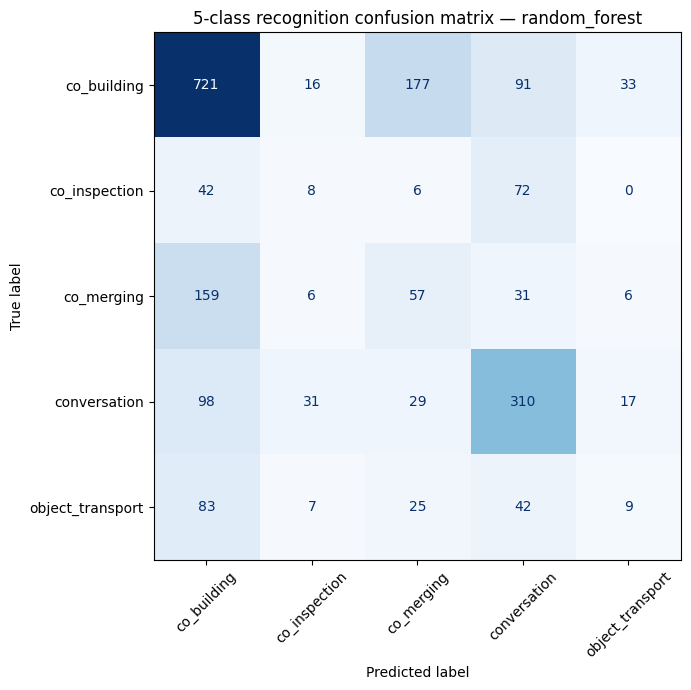

Saved confusion matrix: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_5class_best_model_confusion_matrix.png


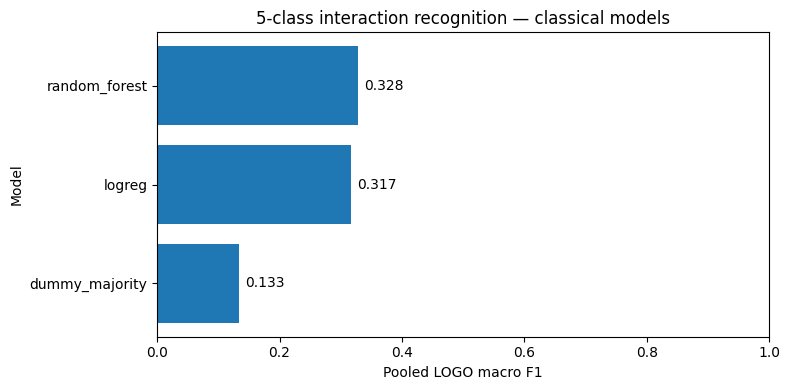

Saved macro F1 plot: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_5class_classical_macro_f1.png


In [ ]:
# ============================================================
# RECOGNITION TASK — CLASSICAL BASELINES
# 5-class interaction recognition, interaction windows only
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"
RECOG_PATH = f"{OUT_DIR}/eng3_recognition_5class_interaction_only_features.csv"

df = pd.read_csv(RECOG_PATH)

print("=" * 80)
print("5-CLASS RECOGNITION DATASET")
print("=" * 80)
print("Rows:", len(df))
print("\nClass counts:")
print(df["recognition_label"].value_counts())

print("\nClass counts by group:")
display(pd.crosstab(df["group"], df["recognition_label"]))

# Same old ENG engineered features
FEATURES = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

missing = [c for c in FEATURES if c not in df.columns]
if missing:
    raise ValueError(f"Missing feature columns: {missing}")

X = df[FEATURES].copy()
y = df["recognition_label"].copy()
groups = df["group"].values

class_names = sorted(y.unique())

print("\nClasses:")
print(class_names)

models = {
    "dummy_majority": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DummyClassifier(strategy="most_frequent")),
    ]),

    "logreg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            multi_class="auto",
            random_state=42
        )),
    ]),

    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )),
    ]),
}

logo = LeaveOneGroupOut()

summary_rows = []
fold_rows = []
pred_rows = []

for model_name, model in models.items():
    print("\n" + "=" * 80)
    print("MODEL:", model_name)
    print("=" * 80)

    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        test_group = groups[test_idx][0]

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        bal_acc = balanced_accuracy_score(y_test, y_pred)

        print(
            f"Fold {fold} | test_group={test_group} | "
            f"acc={acc:.3f} | macroF1={macro_f1:.3f} | "
            f"weightedF1={weighted_f1:.3f} | balAcc={bal_acc:.3f}"
        )

        fold_rows.append({
            "model": model_name,
            "fold": fold,
            "test_group": int(test_group),
            "accuracy": acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "balanced_accuracy": bal_acc,
            "n_test": len(test_idx),
        })

        for true_lab, pred_lab in zip(y_test, y_pred):
            pred_rows.append({
                "model": model_name,
                "test_group": int(test_group),
                "true_label": true_lab,
                "predicted_label": pred_lab,
                "correct": bool(true_lab == pred_lab),
            })

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_pred.tolist())

    pooled_acc = accuracy_score(y_true_all, y_pred_all)
    pooled_macro_f1 = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)
    pooled_weighted_f1 = f1_score(y_true_all, y_pred_all, average="weighted", zero_division=0)
    pooled_bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)

    model_fold_df = pd.DataFrame(fold_rows)
    model_fold_df = model_fold_df[model_fold_df["model"] == model_name]

    summary_rows.append({
        "model": model_name,
        "n_rows": len(df),
        "n_features": len(FEATURES),
        "n_classes": len(class_names),
        "pooled_accuracy": pooled_acc,
        "pooled_macro_f1": pooled_macro_f1,
        "pooled_weighted_f1": pooled_weighted_f1,
        "pooled_balanced_accuracy": pooled_bal_acc,
        "mean_group_accuracy": model_fold_df["accuracy"].mean(),
        "mean_group_macro_f1": model_fold_df["macro_f1"].mean(),
        "mean_group_weighted_f1": model_fold_df["weighted_f1"].mean(),
        "mean_group_balanced_accuracy": model_fold_df["balanced_accuracy"].mean(),
    })

    print("\nPooled classification report:")
    print(classification_report(
        y_true_all,
        y_pred_all,
        labels=class_names,
        zero_division=0
    ))

summary_df_rec = pd.DataFrame(summary_rows).sort_values("pooled_macro_f1", ascending=False)
fold_df_rec = pd.DataFrame(fold_rows)
pred_df_rec = pd.DataFrame(pred_rows)

print("\n" + "=" * 80)
print("RECOGNITION SUMMARY")
print("=" * 80)
display(summary_df_rec.round(3))

print("\nFold results:")
display(fold_df_rec.round(3))

# Save results
summary_path = f"{OUT_DIR}/recognition_5class_classical_summary.csv"
fold_path = f"{OUT_DIR}/recognition_5class_classical_folds.csv"
pred_path = f"{OUT_DIR}/recognition_5class_classical_predictions.csv"

summary_df_rec.to_csv(summary_path, index=False)
fold_df_rec.to_csv(fold_path, index=False)
pred_df_rec.to_csv(pred_path, index=False)

print("\nSaved:")
print(summary_path)
print(fold_path)
print(pred_path)

# Confusion matrix for best model
best_model_name = summary_df_rec.iloc[0]["model"]
best_pred = pred_df_rec[pred_df_rec["model"] == best_model_name]

cm = confusion_matrix(
    best_pred["true_label"],
    best_pred["predicted_label"],
    labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title(f"5-class recognition confusion matrix — {best_model_name}")
plt.tight_layout()

cm_path = f"{OUT_DIR}/recognition_5class_best_model_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix:", cm_path)

# Bar plot of macro F1
plot_df = summary_df_rec.sort_values("pooled_macro_f1", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df["pooled_macro_f1"])
plt.xlabel("Pooled LOGO macro F1")
plt.ylabel("Model")
plt.title("5-class interaction recognition — classical models")
plt.xlim(0, 1)

for i, v in enumerate(plot_df["pooled_macro_f1"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()

bar_path = f"{OUT_DIR}/recognition_5class_classical_macro_f1.png"
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved macro F1 plot:", bar_path)

3-CLASS CORE RECOGNITION DATASET
Original 5-class rows: 2076
3-class rows: 1782
Excluded rows: 294

Class counts:
recognition_label
co_building     1038
conversation     485
co_merging       259
Name: count, dtype: int64

Class percentages:
recognition_label
co_building     58.25
conversation    27.22
co_merging      14.53
Name: proportion, dtype: float64

Class counts by group:


recognition_label,co_building,co_merging,conversation
group,,,
1,18,86,88
2,157,0,35
3,74,14,66
5,166,57,19
6,80,19,47
7,213,48,40
8,105,6,78
9,201,21,87
10,24,8,25



Classes used:
['co_building', 'co_merging', 'conversation']

MODEL: dummy_majority
Fold 1 | test_group=1 | acc=0.094 | macroF1=0.057 | weightedF1=0.016 | balAcc=0.333
Fold 2 | test_group=2 | acc=0.818 | macroF1=0.300 | weightedF1=0.736 | balAcc=0.500
Fold 3 | test_group=3 | acc=0.481 | macroF1=0.216 | weightedF1=0.312 | balAcc=0.333
Fold 4 | test_group=5 | acc=0.686 | macroF1=0.271 | weightedF1=0.558 | balAcc=0.333
Fold 5 | test_group=6 | acc=0.548 | macroF1=0.236 | weightedF1=0.388 | balAcc=0.333
Fold 6 | test_group=7 | acc=0.708 | macroF1=0.276 | weightedF1=0.586 | balAcc=0.333
Fold 7 | test_group=8 | acc=0.556 | macroF1=0.238 | weightedF1=0.397 | balAcc=0.333
Fold 8 | test_group=9 | acc=0.650 | macroF1=0.263 | weightedF1=0.513 | balAcc=0.333
Fold 9 | test_group=10 | acc=0.421 | macroF1=0.198 | weightedF1=0.250 | balAcc=0.333

Pooled classification report:
              precision    recall  f1-score   support

 co_building       0.58      1.00      0.74      1038
  co_merging       

,model,n_rows,n_features,n_classes,pooled_accuracy,pooled_macro_f1,pooled_weighted_f1,pooled_balanced_accuracy,mean_group_accuracy,mean_group_macro_f1,mean_group_weighted_f1,mean_group_balanced_accuracy
1,logreg,1782,17,3,0.587,0.558,0.614,0.590,0.594,0.514,0.636,0.581
2,random_forest,1782,17,3,0.653,0.548,0.650,0.546,0.658,0.508,0.666,0.543
0,dummy_majority,1782,17,3,0.582,0.245,0.429,0.333,0.551,0.228,0.417,0.352



Fold results:


,model,fold,test_group,accuracy,macro_f1,weighted_f1,balanced_accuracy,n_test
0,dummy_majority,1,1,0.094,0.057,0.016,0.333,192
1,dummy_majority,2,2,0.818,0.300,0.736,0.500,192
2,dummy_majority,3,3,0.481,0.216,0.312,0.333,154
3,dummy_majority,4,5,0.686,0.271,0.558,0.333,242
4,dummy_majority,5,6,0.548,0.236,0.388,0.333,146
5,dummy_majority,6,7,0.708,0.276,0.586,0.333,301
6,dummy_majority,7,8,0.556,0.238,0.397,0.333,189
7,dummy_majority,8,9,0.650,0.263,0.513,0.333,309
8,dummy_majority,9,10,0.421,0.198,0.250,0.333,57
9,logreg,1,1,0.672,0.502,0.683,0.493,192



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_folds.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_predictions.csv


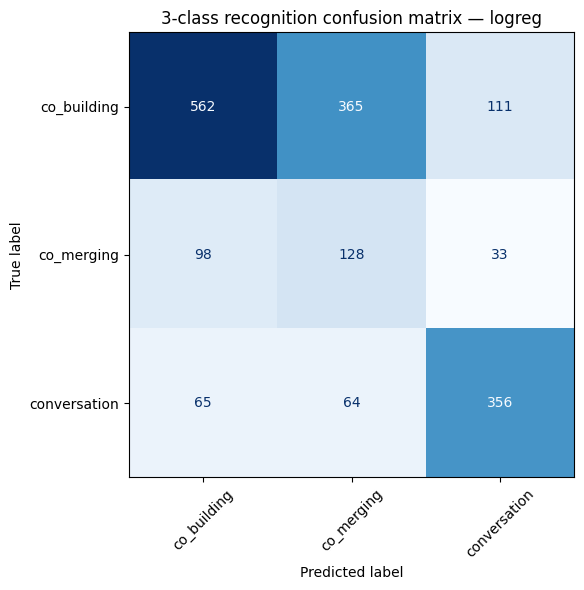

Saved confusion matrix: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_best_model_confusion_matrix.png


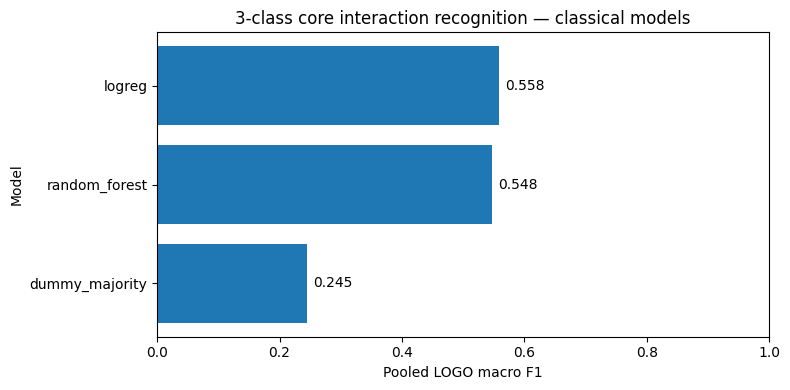

Saved macro F1 plot: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_macro_f1.png


In [ ]:
# ============================================================
# RECOGNITION TASK — 3-CLASS CORE ACTIVITY RECOGNITION
#
# Classes:
#   co_building
#   co_merging
#   conversation
#
# Excluded from this experiment:
#   co_inspection
#   object_transport
#
# Reason:
#   The 5-class task is highly imbalanced.
#   This 3-class task tests the stable core group activities.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"

INPUT_PATH = f"{OUT_DIR}/eng3_recognition_5class_interaction_only_features.csv"
df_all = pd.read_csv(INPUT_PATH)

CORE_CLASSES = [
    "co_building",
    "co_merging",
    "conversation",
]

df = df_all[df_all["recognition_label"].isin(CORE_CLASSES)].copy()
df = df.reset_index(drop=True)

CORE_PATH = f"{OUT_DIR}/eng3_recognition_3class_core_features.csv"
df.to_csv(CORE_PATH, index=False)

print("=" * 80)
print("3-CLASS CORE RECOGNITION DATASET")
print("=" * 80)

print("Original 5-class rows:", len(df_all))
print("3-class rows:", len(df))
print("Excluded rows:", len(df_all) - len(df))

print("\nClass counts:")
print(df["recognition_label"].value_counts())

print("\nClass percentages:")
print((df["recognition_label"].value_counts(normalize=True) * 100).round(2))

print("\nClass counts by group:")
display(pd.crosstab(df["group"], df["recognition_label"]))

# ------------------------------------------------------------
# Same old ENG engineered features
# ------------------------------------------------------------

FEATURES = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

missing = [c for c in FEATURES if c not in df.columns]
if missing:
    raise ValueError(f"Missing feature columns: {missing}")

X = df[FEATURES].copy()
y = df["recognition_label"].copy()
groups = df["group"].values

class_names = sorted(y.unique())

print("\nClasses used:")
print(class_names)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

models = {
    "dummy_majority": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DummyClassifier(strategy="most_frequent")),
    ]),

    "logreg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            multi_class="auto",
            random_state=42
        )),
    ]),

    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )),
    ]),
}

logo = LeaveOneGroupOut()

summary_rows = []
fold_rows = []
pred_rows = []

for model_name, model in models.items():
    print("\n" + "=" * 80)
    print("MODEL:", model_name)
    print("=" * 80)

    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups),
        start=1
    ):
        test_group = groups[test_idx][0]

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        # Fixed class labels so macro F1 is comparable across folds
        macro_f1 = f1_score(
            y_test,
            y_pred,
            labels=class_names,
            average="macro",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_test,
            y_pred,
            labels=class_names,
            average="weighted",
            zero_division=0
        )

        bal_acc = balanced_accuracy_score(y_test, y_pred)

        print(
            f"Fold {fold} | test_group={test_group} | "
            f"acc={acc:.3f} | macroF1={macro_f1:.3f} | "
            f"weightedF1={weighted_f1:.3f} | balAcc={bal_acc:.3f}"
        )

        fold_rows.append({
            "model": model_name,
            "fold": int(fold),
            "test_group": int(test_group),
            "accuracy": float(acc),
            "macro_f1": float(macro_f1),
            "weighted_f1": float(weighted_f1),
            "balanced_accuracy": float(bal_acc),
            "n_test": int(len(test_idx)),
        })

        for true_lab, pred_lab in zip(y_test, y_pred):
            pred_rows.append({
                "model": model_name,
                "test_group": int(test_group),
                "true_label": true_lab,
                "predicted_label": pred_lab,
                "correct": bool(true_lab == pred_lab),
            })

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_pred.tolist())

    pooled_acc = accuracy_score(y_true_all, y_pred_all)

    pooled_macro_f1 = f1_score(
        y_true_all,
        y_pred_all,
        labels=class_names,
        average="macro",
        zero_division=0
    )

    pooled_weighted_f1 = f1_score(
        y_true_all,
        y_pred_all,
        labels=class_names,
        average="weighted",
        zero_division=0
    )

    pooled_bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)

    model_fold_df = pd.DataFrame(fold_rows)
    model_fold_df = model_fold_df[model_fold_df["model"] == model_name]

    summary_rows.append({
        "model": model_name,
        "n_rows": int(len(df)),
        "n_features": int(len(FEATURES)),
        "n_classes": int(len(class_names)),
        "pooled_accuracy": float(pooled_acc),
        "pooled_macro_f1": float(pooled_macro_f1),
        "pooled_weighted_f1": float(pooled_weighted_f1),
        "pooled_balanced_accuracy": float(pooled_bal_acc),
        "mean_group_accuracy": float(model_fold_df["accuracy"].mean()),
        "mean_group_macro_f1": float(model_fold_df["macro_f1"].mean()),
        "mean_group_weighted_f1": float(model_fold_df["weighted_f1"].mean()),
        "mean_group_balanced_accuracy": float(model_fold_df["balanced_accuracy"].mean()),
    })

    print("\nPooled classification report:")
    print(classification_report(
        y_true_all,
        y_pred_all,
        labels=class_names,
        zero_division=0
    ))

summary_df_rec3 = pd.DataFrame(summary_rows).sort_values(
    "pooled_macro_f1",
    ascending=False
)

fold_df_rec3 = pd.DataFrame(fold_rows)
pred_df_rec3 = pd.DataFrame(pred_rows)

print("\n" + "=" * 80)
print("3-CLASS RECOGNITION SUMMARY")
print("=" * 80)
display(summary_df_rec3.round(3))

print("\nFold results:")
display(fold_df_rec3.round(3))

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

summary_path = f"{OUT_DIR}/recognition_3class_classical_summary.csv"
fold_path = f"{OUT_DIR}/recognition_3class_classical_folds.csv"
pred_path = f"{OUT_DIR}/recognition_3class_classical_predictions.csv"

summary_df_rec3.to_csv(summary_path, index=False)
fold_df_rec3.to_csv(fold_path, index=False)
pred_df_rec3.to_csv(pred_path, index=False)

print("\nSaved:")
print(CORE_PATH)
print(summary_path)
print(fold_path)
print(pred_path)

# ------------------------------------------------------------
# Confusion matrix for best model
# ------------------------------------------------------------

best_model_name = summary_df_rec3.iloc[0]["model"]
best_pred = pred_df_rec3[pred_df_rec3["model"] == best_model_name]

cm = confusion_matrix(
    best_pred["true_label"],
    best_pred["predicted_label"],
    labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title(f"3-class recognition confusion matrix — {best_model_name}")
plt.tight_layout()

cm_path = f"{OUT_DIR}/recognition_3class_best_model_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix:", cm_path)

# ------------------------------------------------------------
# Bar plot of macro F1
# ------------------------------------------------------------

plot_df = summary_df_rec3.sort_values("pooled_macro_f1", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df["pooled_macro_f1"])
plt.xlabel("Pooled LOGO macro F1")
plt.ylabel("Model")
plt.title("3-class core interaction recognition — classical models")
plt.xlim(0, 1)

for i, v in enumerate(plot_df["pooled_macro_f1"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()

bar_path = f"{OUT_DIR}/recognition_3class_classical_macro_f1.png"
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved macro F1 plot:", bar_path)

RECOGNITION MODALITY ABLATION
Task: 3class
Rows: 1782

Class counts:
recognition_label
co_building     1038
conversation     485
co_merging       259
Name: count, dtype: int64

Class counts by group:


recognition_label,co_building,co_merging,conversation
group,,,
1,18,86,88
2,157,0,35
3,74,14,66
5,166,57,19
6,80,19,47
7,213,48,40
8,105,6,78
9,201,21,87
10,24,8,25



Available Xsens features:
['hand_freq_mean', 'hand_freq_max', 'hand_power_mean', 'hand_orient_var', 'hand_coord']

Available Xsens missing indicators:
['xsens_available']

Feature set check:
OptiTrack: 10 features
OpenEarable: 7 features
Xsens: 6 features
OptiTrack + OpenEarable: 17 features
OptiTrack + Xsens: 16 features
OpenEarable + Xsens: 13 features
OptiTrack + OpenEarable + Xsens: 23 features

Final feature sets used:
OptiTrack: 10 features
OpenEarable: 7 features
Xsens: 6 features
OptiTrack + OpenEarable: 17 features
OptiTrack + Xsens: 16 features
OpenEarable + Xsens: 13 features
OptiTrack + OpenEarable + Xsens: 23 features

FEATURE SET: OptiTrack
MODEL: dummy_majority
Fold 1 | test_group=1 | acc=0.094 | macroF1=0.057 | weightedF1=0.016 | balAcc=0.333
Fold 2 | test_group=2 | acc=0.818 | macroF1=0.300 | weightedF1=0.736 | balAcc=0.500
Fold 3 | test_group=3 | acc=0.481 | macroF1=0.216 | weightedF1=0.312 | balAcc=0.333
Fold 4 | test_group=5 | acc=0.686 | macroF1=0.271 | weightedF1

,task,feature_set,model,n_rows,n_classes,n_features,pooled_accuracy,pooled_macro_f1,pooled_weighted_f1,pooled_balanced_accuracy,mean_group_accuracy,mean_group_macro_f1,mean_group_weighted_f1,mean_group_balanced_accuracy,features
2,3class,OptiTrack,random_forest,1782,3,10,0.675,0.576,0.673,0.578,0.665,0.514,0.673,0.546,"dist_close_mean, dist_close_min, dist_mid_mean..."
10,3class,OptiTrack + OpenEarable,logreg,1782,3,17,0.587,0.558,0.614,0.590,0.594,0.514,0.636,0.581,"dist_close_mean, dist_close_min, dist_mid_mean..."
19,3class,OptiTrack + OpenEarable + Xsens,logreg,1782,3,23,0.571,0.552,0.601,0.590,0.569,0.511,0.610,0.573,"dist_close_mean, dist_close_min, dist_mid_mean..."
14,3class,OptiTrack + Xsens,random_forest,1782,3,16,0.634,0.550,0.641,0.555,0.624,0.502,0.639,0.526,"dist_close_mean, dist_close_min, dist_mid_mean..."
11,3class,OptiTrack + OpenEarable,random_forest,1782,3,17,0.653,0.548,0.650,0.546,0.658,0.508,0.666,0.543,"dist_close_mean, dist_close_min, dist_mid_mean..."
1,3class,OptiTrack,logreg,1782,3,10,0.554,0.533,0.585,0.557,0.559,0.483,0.584,0.521,"dist_close_mean, dist_close_min, dist_mid_mean..."
13,3class,OptiTrack + Xsens,logreg,1782,3,16,0.548,0.530,0.581,0.558,0.536,0.471,0.563,0.514,"dist_close_mean, dist_close_min, dist_mid_mean..."
20,3class,OptiTrack + OpenEarable + Xsens,random_forest,1782,3,23,0.627,0.527,0.630,0.526,0.632,0.491,0.643,0.526,"dist_close_mean, dist_close_min, dist_mid_mean..."
4,3class,OpenEarable,logreg,1782,3,7,0.497,0.443,0.523,0.460,0.493,0.392,0.521,0.458,"accE_min, accE_mid, accE_max, gyrE_min, gyrE_m..."
5,3class,OpenEarable,random_forest,1782,3,7,0.548,0.441,0.543,0.441,0.539,0.410,0.546,0.479,"accE_min, accE_mid, accE_max, gyrE_min, gyrE_m..."



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_modality_ablation_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_modality_ablation_folds.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_modality_ablation_predictions.csv


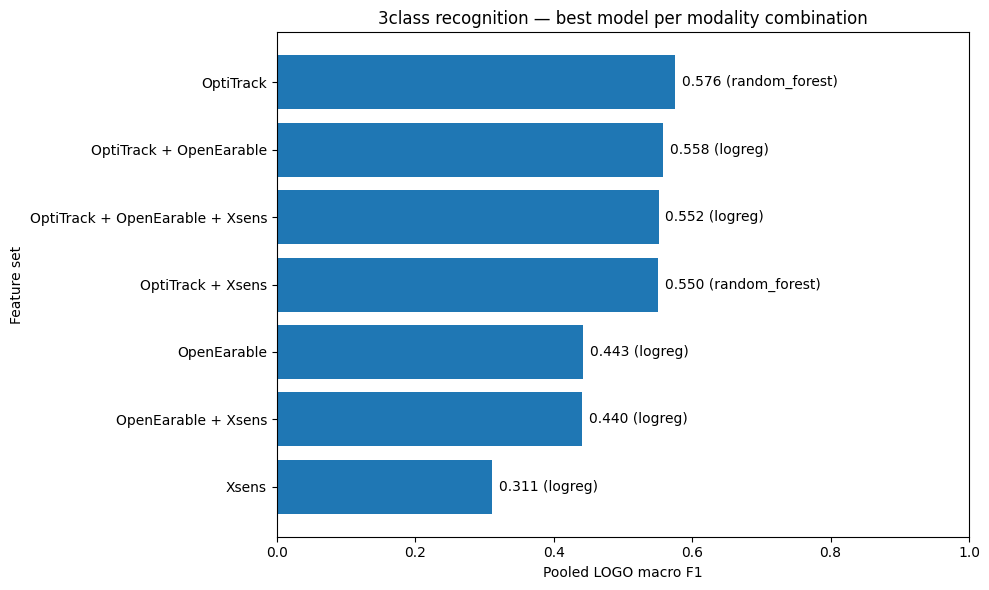

Saved plot: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_modality_ablation_best_per_feature_set_macro_f1.png

Pooled macro F1 pivot:


model,dummy_majority,logreg,random_forest
feature_set,,,
OpenEarable,0.245,0.443,0.441
OpenEarable + Xsens,0.245,0.440,0.407
OptiTrack,0.245,0.533,0.576
OptiTrack + OpenEarable,0.245,0.558,0.548
OptiTrack + OpenEarable + Xsens,0.245,0.552,0.527
OptiTrack + Xsens,0.245,0.530,0.550
Xsens,0.245,0.311,0.309


Saved pivot: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_modality_ablation_macro_f1_pivot.csv


In [ ]:
# ============================================================
# RECOGNITION TASK — MODALITY / SENSOR COMBINATION ABLATION
#
# Compares:
#   OptiTrack
#   OpenEarable
#   Xsens
#   OptiTrack + OpenEarable
#   OptiTrack + Xsens
#   OpenEarable + Xsens
#   OptiTrack + OpenEarable + Xsens
#
# Works for:
#   5-class recognition
#   3-class core recognition
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"

# ============================================================
# Choose task here
# ============================================================

TASK = "3class"   # choose: "3class" or "5class"

if TASK == "5class":
    DATA_PATH = f"{OUT_DIR}/eng3_recognition_5class_interaction_only_features.csv"
    RESULT_PREFIX = "recognition_5class_modality_ablation"

elif TASK == "3class":
    DATA_PATH = f"{OUT_DIR}/eng3_recognition_5class_interaction_only_features.csv"
    RESULT_PREFIX = "recognition_3class_modality_ablation"

else:
    raise ValueError("TASK must be either '3class' or '5class'")

df = pd.read_csv(DATA_PATH)

if TASK == "3class":
    CORE_CLASSES = [
        "co_building",
        "co_merging",
        "conversation",
    ]
    df = df[df["recognition_label"].isin(CORE_CLASSES)].copy()
    df = df.reset_index(drop=True)

print("=" * 80)
print("RECOGNITION MODALITY ABLATION")
print("=" * 80)
print("Task:", TASK)
print("Rows:", len(df))

print("\nClass counts:")
print(df["recognition_label"].value_counts())

print("\nClass counts by group:")
display(pd.crosstab(df["group"], df["recognition_label"]))


# ============================================================
# Feature groups
# ============================================================

OPTITRACK_FEATURES = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
]

OPENEAREABLE_FEATURES = [
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

XSENS_FEATURES = [
    "hand_freq_mean",
    "hand_freq_max",
    "hand_power_mean",
    "hand_orient_var",
    "hand_coord",
]

# Optional missingness indicators, only used if present
XSENS_MISSING_INDICATORS = [
    "hand_freq_mean_missing",
    "hand_freq_max_missing",
    "hand_power_mean_missing",
    "hand_orient_var_missing",
    "hand_coord_missing",
    "xsens_available",
]

XSENS_FEATURES_AVAILABLE = [c for c in XSENS_FEATURES if c in df.columns]
XSENS_MISSING_AVAILABLE = [c for c in XSENS_MISSING_INDICATORS if c in df.columns]

print("\nAvailable Xsens features:")
print(XSENS_FEATURES_AVAILABLE)

print("\nAvailable Xsens missing indicators:")
print(XSENS_MISSING_AVAILABLE)

# Use Xsens features + indicators if available
XSENS_FULL_FEATURES = XSENS_FEATURES_AVAILABLE + XSENS_MISSING_AVAILABLE

feature_sets = {
    "OptiTrack": OPTITRACK_FEATURES,
    "OpenEarable": OPENEAREABLE_FEATURES,
    "Xsens": XSENS_FULL_FEATURES,

    "OptiTrack + OpenEarable": OPTITRACK_FEATURES + OPENEAREABLE_FEATURES,
    "OptiTrack + Xsens": OPTITRACK_FEATURES + XSENS_FULL_FEATURES,
    "OpenEarable + Xsens": OPENEAREABLE_FEATURES + XSENS_FULL_FEATURES,

    "OptiTrack + OpenEarable + Xsens": (
        OPTITRACK_FEATURES + OPENEAREABLE_FEATURES + XSENS_FULL_FEATURES
    ),
}

# Remove feature sets with no usable features
feature_sets = {
    name: feats
    for name, feats in feature_sets.items()
    if len(feats) > 0
}

# Check missing columns
print("\nFeature set check:")
for name, feats in feature_sets.items():
    missing = [c for c in feats if c not in df.columns]
    if missing:
        print(f"{name}: MISSING {missing}")
    else:
        print(f"{name}: {len(feats)} features")

# Keep only feature sets with all columns available
feature_sets = {
    name: feats
    for name, feats in feature_sets.items()
    if all(c in df.columns for c in feats)
}

print("\nFinal feature sets used:")
for name, feats in feature_sets.items():
    print(f"{name}: {len(feats)} features")


# ============================================================
# Models
# ============================================================

models = {
    "dummy_majority": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DummyClassifier(strategy="most_frequent")),
    ]),

    "logreg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            multi_class="auto",
            random_state=42
        )),
    ]),

    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )),
    ]),
}


# ============================================================
# LOGO evaluation
# ============================================================

y = df["recognition_label"].copy()
groups = df["group"].values
class_names = sorted(y.unique())

logo = LeaveOneGroupOut()

summary_rows = []
fold_rows = []
pred_rows = []

for feature_set_name, features in feature_sets.items():

    X = df[features].copy()

    for model_name, model in models.items():

        print("\n" + "=" * 80)
        print("FEATURE SET:", feature_set_name)
        print("MODEL:", model_name)
        print("=" * 80)

        y_true_all = []
        y_pred_all = []

        for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups),
            start=1
        ):
            test_group = groups[test_idx][0]

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)

            macro_f1 = f1_score(
                y_test,
                y_pred,
                labels=class_names,
                average="macro",
                zero_division=0
            )

            weighted_f1 = f1_score(
                y_test,
                y_pred,
                labels=class_names,
                average="weighted",
                zero_division=0
            )

            bal_acc = balanced_accuracy_score(y_test, y_pred)

            print(
                f"Fold {fold} | test_group={test_group} | "
                f"acc={acc:.3f} | macroF1={macro_f1:.3f} | "
                f"weightedF1={weighted_f1:.3f} | balAcc={bal_acc:.3f}"
            )

            fold_rows.append({
                "task": TASK,
                "feature_set": feature_set_name,
                "model": model_name,
                "fold": int(fold),
                "test_group": int(test_group),
                "accuracy": float(acc),
                "macro_f1": float(macro_f1),
                "weighted_f1": float(weighted_f1),
                "balanced_accuracy": float(bal_acc),
                "n_test": int(len(test_idx)),
                "n_features": int(len(features)),
                "features": ", ".join(features),
            })

            for true_lab, pred_lab in zip(y_test, y_pred):
                pred_rows.append({
                    "task": TASK,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "test_group": int(test_group),
                    "true_label": true_lab,
                    "predicted_label": pred_lab,
                    "correct": bool(true_lab == pred_lab),
                })

            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

        pooled_acc = accuracy_score(y_true_all, y_pred_all)

        pooled_macro_f1 = f1_score(
            y_true_all,
            y_pred_all,
            labels=class_names,
            average="macro",
            zero_division=0
        )

        pooled_weighted_f1 = f1_score(
            y_true_all,
            y_pred_all,
            labels=class_names,
            average="weighted",
            zero_division=0
        )

        pooled_bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)

        fold_df_tmp = pd.DataFrame(fold_rows)
        fold_df_tmp = fold_df_tmp[
            (fold_df_tmp["feature_set"] == feature_set_name)
            & (fold_df_tmp["model"] == model_name)
        ]

        summary_rows.append({
            "task": TASK,
            "feature_set": feature_set_name,
            "model": model_name,
            "n_rows": int(len(df)),
            "n_classes": int(len(class_names)),
            "n_features": int(len(features)),
            "pooled_accuracy": float(pooled_acc),
            "pooled_macro_f1": float(pooled_macro_f1),
            "pooled_weighted_f1": float(pooled_weighted_f1),
            "pooled_balanced_accuracy": float(pooled_bal_acc),
            "mean_group_accuracy": float(fold_df_tmp["accuracy"].mean()),
            "mean_group_macro_f1": float(fold_df_tmp["macro_f1"].mean()),
            "mean_group_weighted_f1": float(fold_df_tmp["weighted_f1"].mean()),
            "mean_group_balanced_accuracy": float(fold_df_tmp["balanced_accuracy"].mean()),
            "features": ", ".join(features),
        })

        print("\nPooled result:")
        print("Accuracy:", round(pooled_acc, 3))
        print("Macro F1:", round(pooled_macro_f1, 3))
        print("Weighted F1:", round(pooled_weighted_f1, 3))
        print("Balanced accuracy:", round(pooled_bal_acc, 3))


summary_df_modality = pd.DataFrame(summary_rows).sort_values(
    "pooled_macro_f1",
    ascending=False
)

fold_df_modality = pd.DataFrame(fold_rows)
pred_df_modality = pd.DataFrame(pred_rows)

print("\n" + "=" * 80)
print("MODALITY ABLATION SUMMARY")
print("=" * 80)
display(summary_df_modality.round(3))

# Save
summary_path = f"{OUT_DIR}/{RESULT_PREFIX}_summary.csv"
fold_path = f"{OUT_DIR}/{RESULT_PREFIX}_folds.csv"
pred_path = f"{OUT_DIR}/{RESULT_PREFIX}_predictions.csv"

summary_df_modality.to_csv(summary_path, index=False)
fold_df_modality.to_csv(fold_path, index=False)
pred_df_modality.to_csv(pred_path, index=False)

print("\nSaved:")
print(summary_path)
print(fold_path)
print(pred_path)


# ============================================================
# Plot best result per feature set
# ============================================================

best_per_feature_set = (
    summary_df_modality
    .sort_values("pooled_macro_f1", ascending=False)
    .groupby("feature_set", as_index=False)
    .first()
    .sort_values("pooled_macro_f1", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(best_per_feature_set["feature_set"], best_per_feature_set["pooled_macro_f1"])
plt.xlabel("Pooled LOGO macro F1")
plt.ylabel("Feature set")
plt.title(f"{TASK} recognition — best model per modality combination")
plt.xlim(0, 1)

for i, row in enumerate(best_per_feature_set.itertuples()):
    plt.text(
        row.pooled_macro_f1 + 0.01,
        i,
        f"{row.pooled_macro_f1:.3f} ({row.model})",
        va="center"
    )

plt.tight_layout()

plot_path = f"{OUT_DIR}/{RESULT_PREFIX}_best_per_feature_set_macro_f1.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)


# ============================================================
# Pivot table: feature set x model
# ============================================================

pivot_macro = summary_df_modality.pivot_table(
    index="feature_set",
    columns="model",
    values="pooled_macro_f1"
)

print("\nPooled macro F1 pivot:")
display(pivot_macro.round(3))

pivot_path = f"{OUT_DIR}/{RESULT_PREFIX}_macro_f1_pivot.csv"
pivot_macro.to_csv(pivot_path)

print("Saved pivot:", pivot_path)

3-CLASS RECOGNITION EXPLAINABILITY
Rows: 1782

Class counts:
recognition_label
co_building     1038
conversation     485
co_merging       259
Name: count, dtype: int64

Class counts by group:


recognition_label,co_building,co_merging,conversation
group,,,
1,18,86,88
2,157,0,35
3,74,14,66
5,166,57,19
6,80,19,47
7,213,48,40
8,105,6,78
9,201,21,87
10,24,8,25



Classes:
['co_building', 'co_merging', 'conversation']
Fold 1 | test_group=1 | acc=0.474 | macroF1=0.310 | weightedF1=0.425 | balAcc=0.345
Fold 2 | test_group=2 | acc=0.771 | macroF1=0.523 | weightedF1=0.836 | balAcc=0.682
Fold 3 | test_group=3 | acc=0.708 | macroF1=0.567 | weightedF1=0.728 | balAcc=0.556
Fold 4 | test_group=5 | acc=0.731 | macroF1=0.596 | weightedF1=0.720 | balAcc=0.587
Fold 5 | test_group=6 | acc=0.788 | macroF1=0.583 | weightedF1=0.758 | balAcc=0.587
Fold 6 | test_group=7 | acc=0.641 | macroF1=0.547 | weightedF1=0.663 | balAcc=0.602
Fold 7 | test_group=8 | acc=0.646 | macroF1=0.497 | weightedF1=0.710 | balAcc=0.455
Fold 8 | test_group=9 | acc=0.702 | macroF1=0.595 | weightedF1=0.737 | balAcc=0.659
Fold 9 | test_group=10 | acc=0.526 | macroF1=0.410 | weightedF1=0.482 | balAcc=0.441

POOLED PERFORMANCE
Accuracy: 0.675
Macro F1: 0.576
Weighted F1: 0.673
Balanced accuracy: 0.578

Classification report:
              precision    recall  f1-score   support

 co_building

,feature,mean_gini_importance,std_gini_importance,mean_permutation_importance,std_permutation_importance
2,dist_close_min,0.1564,0.0110,0.0510,0.0655
1,dist_close_mean,0.1708,0.0083,0.0361,0.0370
3,dist_disp_mean,0.1506,0.0098,0.0192,0.0396
6,dist_mid_mean,0.1185,0.0062,0.0131,0.0124
5,dist_far_mean,0.0920,0.0049,0.0069,0.0161
0,centroid_speed,0.0570,0.0029,0.0057,0.0240
8,speed_mid,0.0621,0.0037,0.0031,0.0129
4,dist_disp_std,0.0706,0.0040,0.0021,0.0175
7,speed_max,0.0533,0.0037,0.0007,0.0070
9,speed_min,0.0687,0.0067,-0.0321,0.0607



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_explainability_folds.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_explainability_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_feature_importance.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_permutation_importance.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_explainability_combined.csv


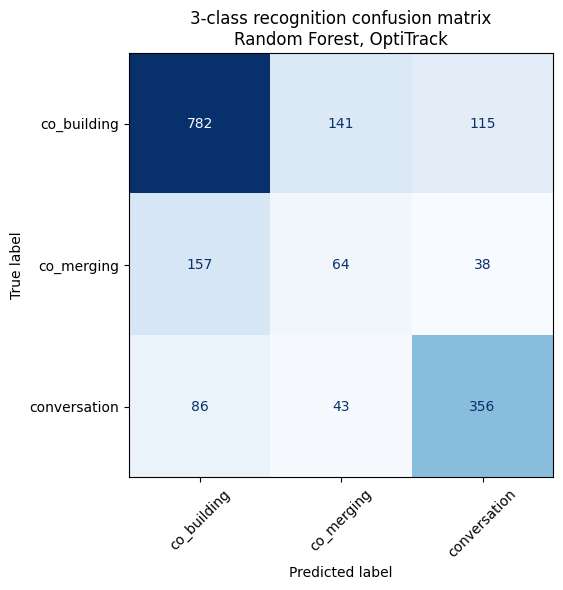

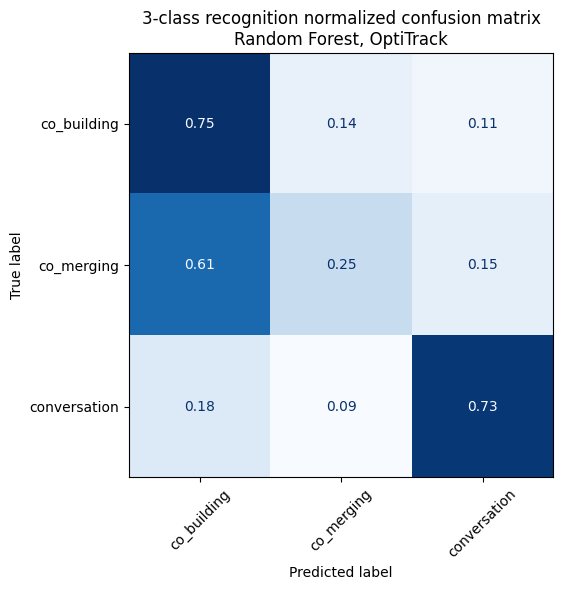

Saved confusion matrices:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_confusion_matrix.png
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_normalized_confusion_matrix.png


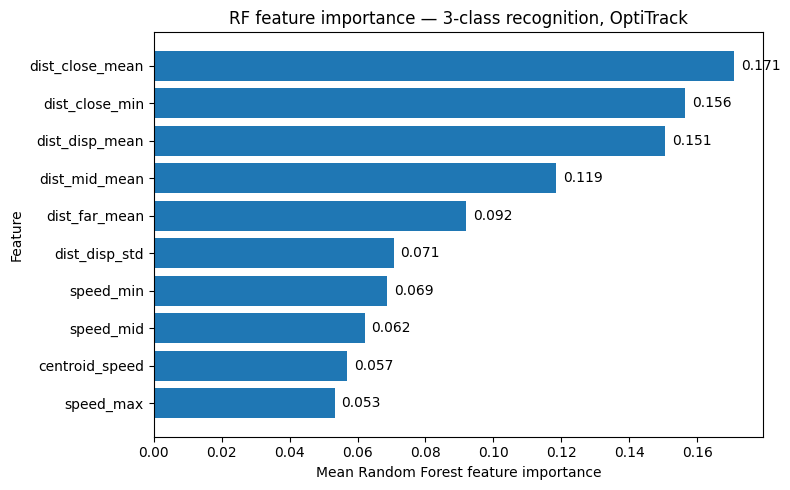

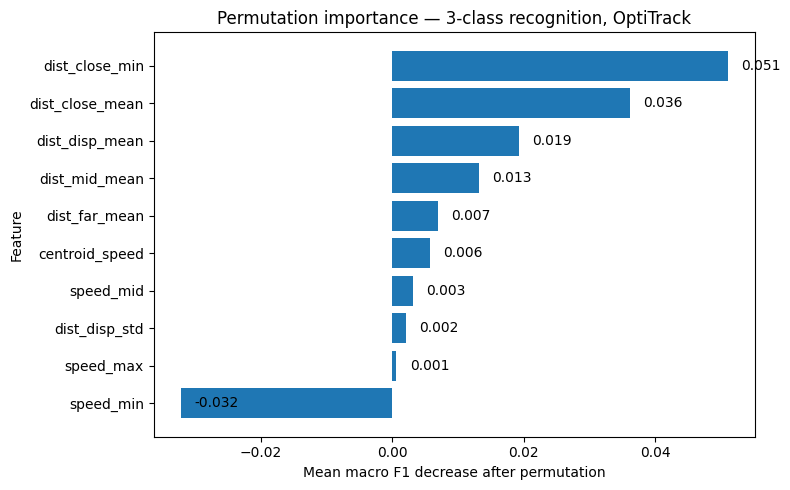

Saved importance plots:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_feature_importance.png
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_permutation_importance.png


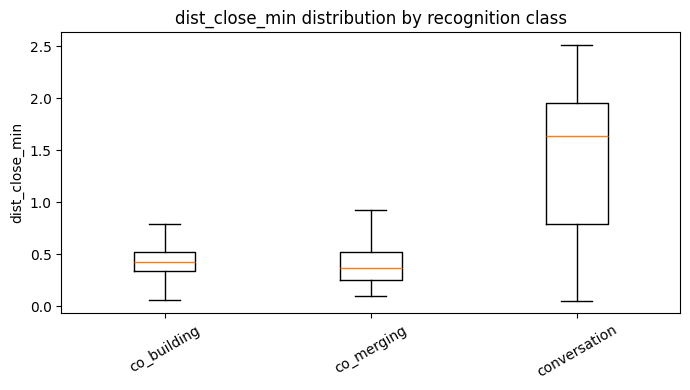

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_boxplot_dist_close_min.png


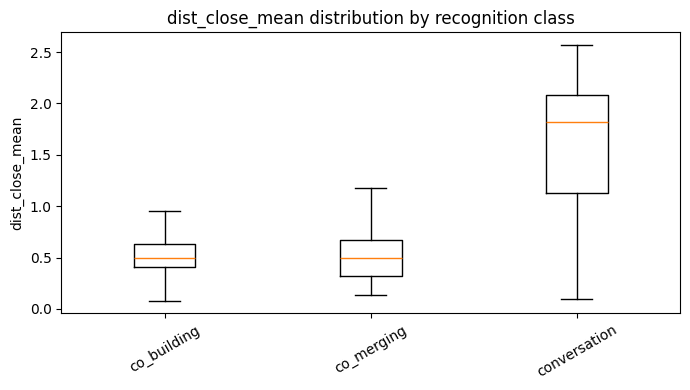

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_boxplot_dist_close_mean.png


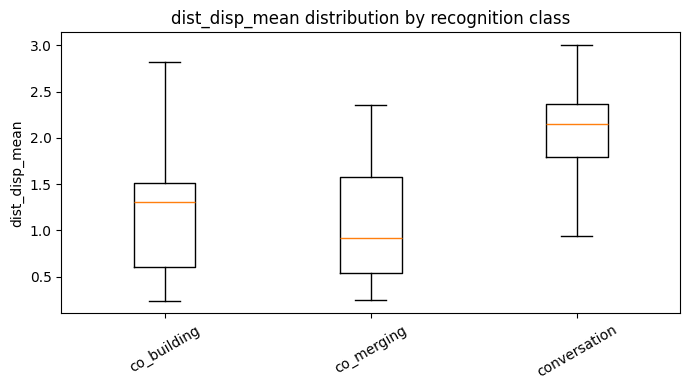

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_boxplot_dist_disp_mean.png


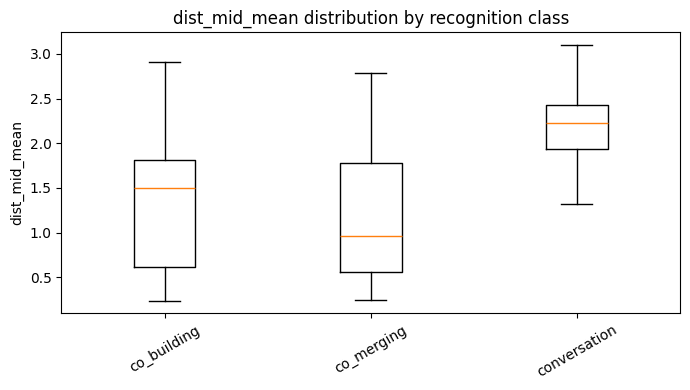

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_boxplot_dist_mid_mean.png


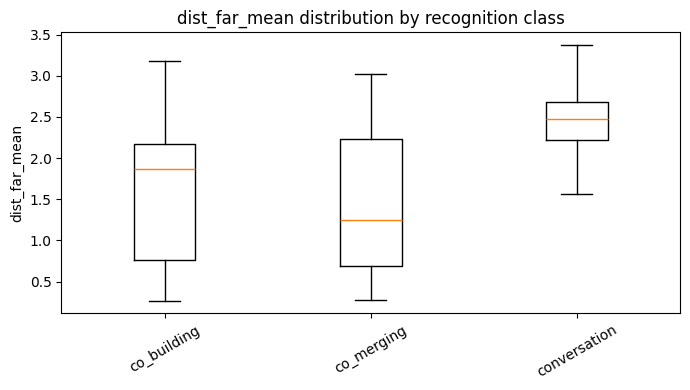

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_boxplot_dist_far_mean.png


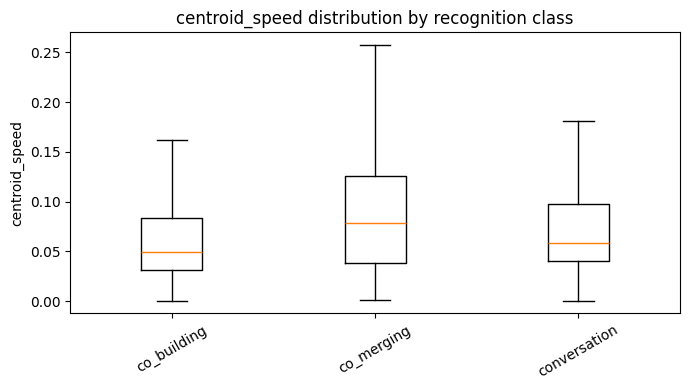

Saved: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_rf_optitrack_boxplot_centroid_speed.png


In [ ]:
# ============================================================
# RECOGNITION TASK — EXPLAINABILITY
# Best model:
#   3-class recognition
#   OptiTrack-only features
#   Random Forest
#
# Corrected version:
#   - Uses custom macro F1 scorer for string multiclass labels
#   - Fixes the previous pos_label=1 scorer error
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"

DATA_PATH = f"{OUT_DIR}/eng3_recognition_3class_core_features.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 80)
print("3-CLASS RECOGNITION EXPLAINABILITY")
print("=" * 80)

print("Rows:", len(df))
print("\nClass counts:")
print(df["recognition_label"].value_counts())

print("\nClass counts by group:")
display(pd.crosstab(df["group"], df["recognition_label"]))


# ------------------------------------------------------------
# Best modality from ablation: OptiTrack only
# ------------------------------------------------------------

OPTITRACK_FEATURES = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
]

missing = [c for c in OPTITRACK_FEATURES if c not in df.columns]
if missing:
    raise ValueError(f"Missing OptiTrack feature columns: {missing}")

X = df[OPTITRACK_FEATURES].copy()
y = df["recognition_label"].copy()
groups = df["group"].values

class_names = sorted(y.unique())

print("\nClasses:")
print(class_names)


# ------------------------------------------------------------
# Custom scorer for permutation importance
# Important:
#   make_scorer can cause pos_label=1 errors with string labels.
#   This custom scorer avoids that problem.
# ------------------------------------------------------------

def macro_f1_scorer(estimator, X_eval, y_eval):
    y_pred_eval = estimator.predict(X_eval)
    return f1_score(
        y_eval,
        y_pred_eval,
        labels=class_names,
        average="macro",
        zero_division=0
    )


logo = LeaveOneGroupOut()

fold_rows = []
pred_rows = []
gini_importance_rows = []
permutation_rows = []

y_true_all = []
y_pred_all = []


# ============================================================
# LOGO evaluation + feature importance per fold
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    logo.split(X, y, groups),
    start=1
):
    test_group = groups[test_idx][0]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )),
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    macro_f1 = f1_score(
        y_test,
        y_pred,
        labels=class_names,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        labels=class_names,
        average="weighted",
        zero_division=0
    )

    bal_acc = balanced_accuracy_score(y_test, y_pred)

    print(
        f"Fold {fold} | test_group={test_group} | "
        f"acc={acc:.3f} | macroF1={macro_f1:.3f} | "
        f"weightedF1={weighted_f1:.3f} | balAcc={bal_acc:.3f}"
    )

    fold_rows.append({
        "fold": int(fold),
        "test_group": int(test_group),
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "balanced_accuracy": float(bal_acc),
        "n_test": int(len(test_idx)),
    })

    for true_lab, pred_lab in zip(y_test, y_pred):
        pred_rows.append({
            "fold": int(fold),
            "test_group": int(test_group),
            "true_label": true_lab,
            "predicted_label": pred_lab,
            "correct": bool(true_lab == pred_lab),
        })

    y_true_all.extend(y_test.tolist())
    y_pred_all.extend(y_pred.tolist())

    # --------------------------------------------------------
    # Random Forest built-in feature importance
    # --------------------------------------------------------

    rf = model.named_steps["clf"]

    for feat, imp in zip(OPTITRACK_FEATURES, rf.feature_importances_):
        gini_importance_rows.append({
            "fold": int(fold),
            "test_group": int(test_group),
            "feature": feat,
            "gini_importance": float(imp),
        })

    # --------------------------------------------------------
    # Permutation importance on held-out group
    # --------------------------------------------------------

    perm = permutation_importance(
        model,
        X_test,
        y_test,
        scoring=macro_f1_scorer,
        n_repeats=10,
        random_state=42 + fold,
        n_jobs=-1
    )

    for i, feat in enumerate(OPTITRACK_FEATURES):
        permutation_rows.append({
            "fold": int(fold),
            "test_group": int(test_group),
            "feature": feat,
            "permutation_importance_mean": float(perm.importances_mean[i]),
            "permutation_importance_std": float(perm.importances_std[i]),
        })


# ============================================================
# Aggregate results
# ============================================================

fold_df_exp = pd.DataFrame(fold_rows)
pred_df_exp = pd.DataFrame(pred_rows)
gini_df = pd.DataFrame(gini_importance_rows)
perm_df = pd.DataFrame(permutation_rows)

pooled_acc = accuracy_score(y_true_all, y_pred_all)

pooled_macro_f1 = f1_score(
    y_true_all,
    y_pred_all,
    labels=class_names,
    average="macro",
    zero_division=0
)

pooled_weighted_f1 = f1_score(
    y_true_all,
    y_pred_all,
    labels=class_names,
    average="weighted",
    zero_division=0
)

pooled_bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)

print("\n" + "=" * 80)
print("POOLED PERFORMANCE")
print("=" * 80)
print("Accuracy:", round(pooled_acc, 3))
print("Macro F1:", round(pooled_macro_f1, 3))
print("Weighted F1:", round(pooled_weighted_f1, 3))
print("Balanced accuracy:", round(pooled_bal_acc, 3))

print("\nClassification report:")
print(classification_report(
    y_true_all,
    y_pred_all,
    labels=class_names,
    zero_division=0
))


# ------------------------------------------------------------
# Aggregate feature importance
# ------------------------------------------------------------

gini_summary = (
    gini_df
    .groupby("feature")
    .agg(
        mean_gini_importance=("gini_importance", "mean"),
        std_gini_importance=("gini_importance", "std"),
    )
    .reset_index()
    .sort_values("mean_gini_importance", ascending=False)
)

perm_summary = (
    perm_df
    .groupby("feature")
    .agg(
        mean_permutation_importance=("permutation_importance_mean", "mean"),
        std_permutation_importance=("permutation_importance_mean", "std"),
    )
    .reset_index()
    .sort_values("mean_permutation_importance", ascending=False)
)

explainability_combined = gini_summary.merge(
    perm_summary,
    on="feature",
    how="outer"
).sort_values("mean_permutation_importance", ascending=False)

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 80)
display(explainability_combined.round(4))


# ============================================================
# Save CSVs
# ============================================================

fold_path = f"{OUT_DIR}/recognition_3class_rf_optitrack_explainability_folds.csv"
pred_path = f"{OUT_DIR}/recognition_3class_rf_optitrack_explainability_predictions.csv"
gini_path = f"{OUT_DIR}/recognition_3class_rf_optitrack_feature_importance.csv"
perm_path = f"{OUT_DIR}/recognition_3class_rf_optitrack_permutation_importance.csv"
combined_path = f"{OUT_DIR}/recognition_3class_rf_optitrack_explainability_combined.csv"

fold_df_exp.to_csv(fold_path, index=False)
pred_df_exp.to_csv(pred_path, index=False)
gini_summary.to_csv(gini_path, index=False)
perm_summary.to_csv(perm_path, index=False)
explainability_combined.to_csv(combined_path, index=False)

print("\nSaved:")
print(fold_path)
print(pred_path)
print(gini_path)
print(perm_path)
print(combined_path)


# ============================================================
# Confusion matrices
# ============================================================

cm = confusion_matrix(
    pred_df_exp["true_label"],
    pred_df_exp["predicted_label"],
    labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("3-class recognition confusion matrix\nRandom Forest, OptiTrack")
plt.tight_layout()

cm_path = f"{OUT_DIR}/recognition_3class_rf_optitrack_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

cm_norm = confusion_matrix(
    pred_df_exp["true_label"],
    pred_df_exp["predicted_label"],
    labels=class_names,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
    values_format=".2f"
)
plt.title("3-class recognition normalized confusion matrix\nRandom Forest, OptiTrack")
plt.tight_layout()

cm_norm_path = f"{OUT_DIR}/recognition_3class_rf_optitrack_normalized_confusion_matrix.png"
plt.savefig(cm_norm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrices:")
print(cm_path)
print(cm_norm_path)


# ============================================================
# Feature importance plots
# ============================================================

plot_gini = gini_summary.sort_values("mean_gini_importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_gini["feature"], plot_gini["mean_gini_importance"])
plt.xlabel("Mean Random Forest feature importance")
plt.ylabel("Feature")
plt.title("RF feature importance — 3-class recognition, OptiTrack")

for i, v in enumerate(plot_gini["mean_gini_importance"]):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center")

plt.tight_layout()

gini_plot_path = f"{OUT_DIR}/recognition_3class_rf_optitrack_feature_importance.png"
plt.savefig(gini_plot_path, dpi=300, bbox_inches="tight")
plt.show()

plot_perm = perm_summary.sort_values("mean_permutation_importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_perm["feature"], plot_perm["mean_permutation_importance"])
plt.xlabel("Mean macro F1 decrease after permutation")
plt.ylabel("Feature")
plt.title("Permutation importance — 3-class recognition, OptiTrack")

for i, v in enumerate(plot_perm["mean_permutation_importance"]):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center")

plt.tight_layout()

perm_plot_path = f"{OUT_DIR}/recognition_3class_rf_optitrack_permutation_importance.png"
plt.savefig(perm_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved importance plots:")
print(gini_plot_path)
print(perm_plot_path)


# ============================================================
# Feature distributions for top permutation features
# ============================================================

top_features = perm_summary.head(6)["feature"].tolist()

for feat in top_features:
    plt.figure(figsize=(7, 4))

    data = [
        df[df["recognition_label"] == cls][feat].dropna().values
        for cls in class_names
    ]

    plt.boxplot(data, labels=class_names, showfliers=False)
    plt.ylabel(feat)
    plt.title(f"{feat} distribution by recognition class")
    plt.xticks(rotation=30)
    plt.tight_layout()

    box_path = f"{OUT_DIR}/recognition_3class_rf_optitrack_boxplot_{feat}.png"
    plt.savefig(box_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", box_path)

DEVICE: cpu

Tensor keys:
['X', 'y', 'groups']

Full tensor shape: (4372, 64, 7)
ENG3 full rows: 4372
3-class recognition rows: 1782

Recognition classes:
{'co_building': 0, 'co_merging': 1, 'conversation': 2}

Aligned recognition tensor shape: (1782, 64, 7)
Labels shape: (1782,)
Groups: [1, 2, 3, 5, 6, 7, 8, 9, 10]

Class counts:
recognition_label
co_building     1038
conversation     485
co_merging       259
Name: count, dtype: int64

Class counts by group:


recognition_label,co_building,co_merging,conversation
group,,,
1,18,86,88
2,157,0,35
3,74,14,66
5,166,57,19
6,80,19,47
7,213,48,40
8,105,6,78
9,201,21,87
10,24,8,25


DL 3-CLASS RECOGNITION LOGO RUN
Models: ['cnn1d', 'rnn', 'gru', 'lstm', 'tf_none', 'tf_sinusoidal', 'tf_learned']
Total trainings: 63
Training setup: 8 groups train, 1 group test, no validation
Max epochs: 30

MODEL: cnn1d

--------------------------------------------------------------------------------
Fold 1/9 | Test group: 1
Train groups: [2, 3, 5, 6, 7, 8, 9, 10]
Test group: 1
Train windows: 1590 | Test windows: 192
--------------------------------------------------------------------------------
    epoch 001/30 | train_loss=0.7832
    epoch 010/30 | train_loss=0.5015
    epoch 020/30 | train_loss=0.4511
    epoch 030/30 | train_loss=0.3874
FINAL | Test group 1 | acc=0.516 | macroF1=0.337 | weightedF1=0.461 | balAcc=0.376

--------------------------------------------------------------------------------
Fold 2/9 | Test group: 2
Train groups: [1, 3, 5, 6, 7, 8, 9, 10]
Test group: 2
Train windows: 1590 | Test windows: 192
---------------------------------------------------------------

,model,n_rows,seq_len,n_channels,n_classes,max_epochs,pooled_accuracy,pooled_macro_f1,pooled_weighted_f1,pooled_balanced_accuracy,mean_group_accuracy,mean_group_macro_f1,mean_group_weighted_f1,mean_group_balanced_accuracy
6,tf_learned,1782,64,7,3,30,0.655,0.593,0.662,0.614,0.638,0.519,0.655,0.567
1,rnn,1782,64,7,3,30,0.604,0.574,0.625,0.613,0.596,0.511,0.625,0.584
3,lstm,1782,64,7,3,30,0.623,0.571,0.634,0.599,0.623,0.524,0.645,0.571
5,tf_sinusoidal,1782,64,7,3,30,0.629,0.562,0.638,0.582,0.621,0.513,0.649,0.557
0,cnn1d,1782,64,7,3,30,0.618,0.561,0.632,0.588,0.611,0.497,0.618,0.549
4,tf_none,1782,64,7,3,30,0.629,0.560,0.640,0.580,0.615,0.493,0.633,0.564
2,gru,1782,64,7,3,30,0.607,0.555,0.621,0.583,0.602,0.512,0.620,0.561



Fold results:


,model,fold,test_group,accuracy,macro_f1,weighted_f1,balanced_accuracy,n_train,n_test,max_epochs
0,cnn1d,1,1,0.516,0.337,0.461,0.376,1590,192,30
1,cnn1d,2,2,0.271,0.342,0.392,0.388,1590,192,30
2,cnn1d,3,3,0.643,0.543,0.672,0.549,1628,154,30
3,cnn1d,4,5,0.711,0.603,0.736,0.673,1540,242,30
4,cnn1d,5,6,0.781,0.575,0.741,0.604,1636,146,30
...,...,...,...,...,...,...,...,...,...,...
58,tf_learned,5,6,0.733,0.685,0.751,0.722,1636,146,30
59,tf_learned,6,7,0.698,0.593,0.713,0.633,1481,301,30
60,tf_learned,7,8,0.778,0.563,0.816,0.535,1593,189,30
61,tf_learned,8,9,0.631,0.486,0.641,0.518,1473,309,30



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_dl_logo_no_validation_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_dl_logo_no_validation_folds.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_dl_logo_no_validation_predictions.csv

DL VS CLASSICAL COMPARISON


,model,n_rows,seq_len,n_channels,n_classes,max_epochs,pooled_accuracy,pooled_macro_f1,pooled_weighted_f1,pooled_balanced_accuracy,mean_group_accuracy,mean_group_macro_f1,mean_group_weighted_f1,mean_group_balanced_accuracy
1,tf_learned,1782,64.0,7.0,3,30.0,0.655,0.593,0.662,0.614,0.638,0.519,0.655,0.567
0,classical_RF_OptiTrack,1782,NaN,NaN,3,NaN,0.675,0.576,0.673,0.578,NaN,NaN,NaN,NaN
2,rnn,1782,64.0,7.0,3,30.0,0.604,0.574,0.625,0.613,0.596,0.511,0.625,0.584
3,lstm,1782,64.0,7.0,3,30.0,0.623,0.571,0.634,0.599,0.623,0.524,0.645,0.571
4,tf_sinusoidal,1782,64.0,7.0,3,30.0,0.629,0.562,0.638,0.582,0.621,0.513,0.649,0.557
5,cnn1d,1782,64.0,7.0,3,30.0,0.618,0.561,0.632,0.588,0.611,0.497,0.618,0.549
6,tf_none,1782,64.0,7.0,3,30.0,0.629,0.560,0.640,0.580,0.615,0.493,0.633,0.564
7,gru,1782,64.0,7.0,3,30.0,0.607,0.555,0.621,0.583,0.602,0.512,0.620,0.561


Saved comparison: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_dl_logo_no_validation_vs_classical_comparison.csv


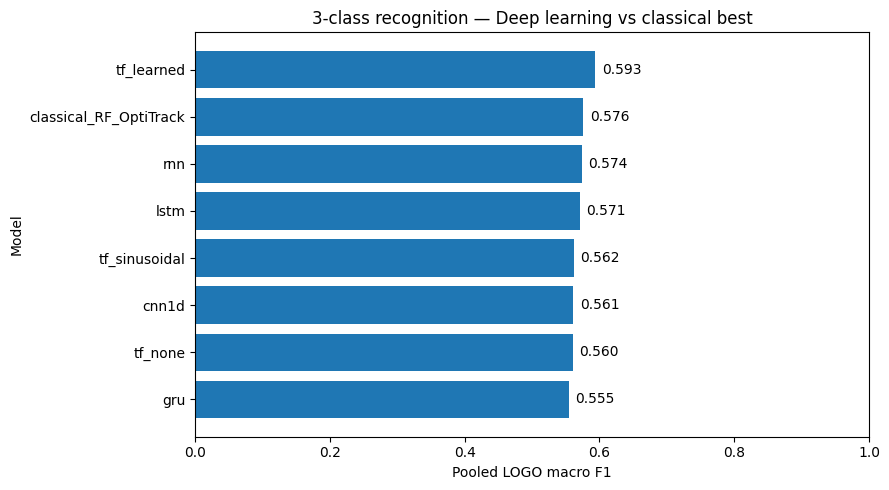

Saved plot: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_dl_logo_no_validation_vs_classical_macro_f1.png


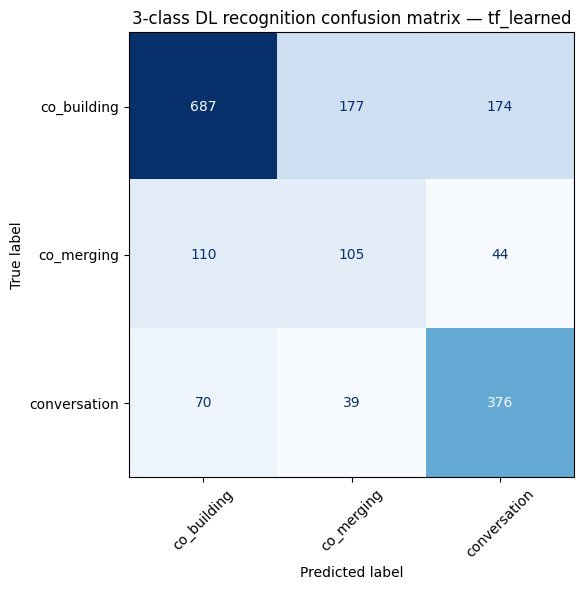

Saved confusion matrix: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_dl_logo_no_validation_best_dl_confusion_matrix.png


In [ ]:
# ============================================================
# DEEP LEARNING — 3-CLASS CORE RECOGNITION
#
# Task:
#   co_building / co_merging / conversation
#
# Evaluation:
#   Leave-One-Group-Out
#   Train on 8 groups
#   Test on 1 held-out group
#   No validation group
#
# Input:
#   ENG3 temporal tensor
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# Paths
# ============================================================

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"

TENSOR_PATH = f"{OUT_DIR}/interaction_eng3_tensors.npz"
ENG3_FEATURES_PATH = f"{OUT_DIR}/interaction_eng3_features.csv"
RECOG_3CLASS_PATH = f"{OUT_DIR}/eng3_recognition_3class_core_features.csv"

RESULT_PREFIX = "recognition_3class_dl_logo_no_validation"


# ============================================================
# Reproducibility
# ============================================================

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


# ============================================================
# Load temporal tensor + recognition labels
# ============================================================

tensor_data = np.load(TENSOR_PATH, allow_pickle=True)

print("\nTensor keys:")
print(tensor_data.files)

# Try common key names
if "X" in tensor_data.files:
    X_all_seq = tensor_data["X"]
elif "X_seq" in tensor_data.files:
    X_all_seq = tensor_data["X_seq"]
elif "features" in tensor_data.files:
    X_all_seq = tensor_data["features"]
else:
    raise ValueError("Could not find X tensor in npz. Available keys: " + str(tensor_data.files))

eng3_full = pd.read_csv(ENG3_FEATURES_PATH)
rec3 = pd.read_csv(RECOG_3CLASS_PATH)

print("\nFull tensor shape:", X_all_seq.shape)
print("ENG3 full rows:", len(eng3_full))
print("3-class recognition rows:", len(rec3))

if len(X_all_seq) != len(eng3_full):
    raise ValueError(
        f"Tensor rows ({len(X_all_seq)}) do not match ENG3 feature rows ({len(eng3_full)})."
    )


# ------------------------------------------------------------
# Align 3-class recognition rows to tensor rows
# using group + window_start + window_end
# ------------------------------------------------------------

def make_key_df(df):
    return list(
        zip(
            df["group"].astype(int),
            np.round(df["window_start"].astype(float), 6),
            np.round(df["window_end"].astype(float), 6),
        )
    )

full_keys = make_key_df(eng3_full)
rec_keys = make_key_df(rec3)

key_to_idx = {k: i for i, k in enumerate(full_keys)}

missing_keys = [k for k in rec_keys if k not in key_to_idx]
if len(missing_keys) > 0:
    print("Example missing keys:", missing_keys[:5])
    raise ValueError(f"{len(missing_keys)} recognition windows could not be aligned to tensor rows.")

rec_indices = np.array([key_to_idx[k] for k in rec_keys], dtype=int)

X = X_all_seq[rec_indices].astype(np.float32)

label_names = sorted(rec3["recognition_label"].unique())
label_to_id = {lab: i for i, lab in enumerate(label_names)}
id_to_label = {i: lab for lab, i in label_to_id.items()}

y = rec3["recognition_label"].map(label_to_id).values.astype(np.int64)
groups = rec3["group"].values.astype(int)

print("\nRecognition classes:")
print(label_to_id)

print("\nAligned recognition tensor shape:", X.shape)
print("Labels shape:", y.shape)
print("Groups:", sorted(np.unique(groups).tolist()))

print("\nClass counts:")
print(rec3["recognition_label"].value_counts())

print("\nClass counts by group:")
display(pd.crosstab(rec3["group"], rec3["recognition_label"]))


# ============================================================
# Dataset and preprocessing
# ============================================================

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def standardize_train_test(X_train, X_test):
    """
    Channel-wise standardization.
    Fit mean/std only on training data.
    Shape: N x T x C
    """
    mean = np.nanmean(X_train, axis=(0, 1), keepdims=True)
    std = np.nanstd(X_train, axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)

    X_train_s = (X_train - mean) / std
    X_test_s = (X_test - mean) / std

    X_train_s = np.nan_to_num(X_train_s, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_s = np.nan_to_num(X_test_s, nan=0.0, posinf=0.0, neginf=0.0)

    return X_train_s.astype(np.float32), X_test_s.astype(np.float32)


def make_class_weights(y_train, n_classes):
    counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (n_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


# ============================================================
# Models
# ============================================================

class CNN1DClassifier(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.head = nn.Linear(128, n_classes)

    def forward(self, x):
        # x: B x T x C
        x = x.transpose(1, 2)  # B x C x T
        x = self.net(x).squeeze(-1)
        return self.head(x)


class RNNClassifier(nn.Module):
    def __init__(
        self,
        n_channels,
        n_classes,
        rnn_type="gru",
        hidden_size=64,
        num_layers=1,
        bidirectional=True,
        dropout=0.2,
    ):
        super().__init__()

        self.rnn_type = rnn_type.lower()
        self.bidirectional = bidirectional

        rnn_cls = {
            "rnn": nn.RNN,
            "gru": nn.GRU,
            "lstm": nn.LSTM,
        }[self.rnn_type]

        self.rnn = rnn_cls(
            input_size=n_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.0 if num_layers == 1 else dropout,
        )

        out_dim = hidden_size * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(out_dim, n_classes),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        pooled = out.mean(dim=1)
        return self.head(pooled)


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        n_channels,
        n_classes,
        seq_len,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2,
        pos_encoding="none",
    ):
        super().__init__()

        self.pos_encoding = pos_encoding

        self.input_proj = nn.Linear(n_channels, d_model)

        if pos_encoding == "sinusoidal":
            self.pos = SinusoidalPositionalEncoding(d_model, max_len=seq_len + 10)
        elif pos_encoding == "learned":
            self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))
            nn.init.normal_(self.pos_embedding, mean=0.0, std=0.02)
        elif pos_encoding == "none":
            pass
        else:
            raise ValueError("pos_encoding must be one of: none, sinusoidal, learned")

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        x = self.input_proj(x)

        if self.pos_encoding == "sinusoidal":
            x = self.pos(x)
        elif self.pos_encoding == "learned":
            x = x + self.pos_embedding[:, :x.size(1), :]

        x = self.encoder(x)
        pooled = x.mean(dim=1)
        return self.head(pooled)


def make_model(model_name, n_channels, n_classes, seq_len):
    model_name = model_name.lower()

    if model_name == "cnn1d":
        return CNN1DClassifier(
            n_channels=n_channels,
            n_classes=n_classes,
        )

    if model_name == "rnn":
        return RNNClassifier(
            n_channels=n_channels,
            n_classes=n_classes,
            rnn_type="rnn",
        )

    if model_name == "gru":
        return RNNClassifier(
            n_channels=n_channels,
            n_classes=n_classes,
            rnn_type="gru",
        )

    if model_name == "lstm":
        return RNNClassifier(
            n_channels=n_channels,
            n_classes=n_classes,
            rnn_type="lstm",
        )

    if model_name == "tf_none":
        return TransformerClassifier(
            n_channels=n_channels,
            n_classes=n_classes,
            seq_len=seq_len,
            pos_encoding="none",
        )

    if model_name == "tf_sinusoidal":
        return TransformerClassifier(
            n_channels=n_channels,
            n_classes=n_classes,
            seq_len=seq_len,
            pos_encoding="sinusoidal",
        )

    if model_name == "tf_learned":
        return TransformerClassifier(
            n_channels=n_channels,
            n_classes=n_classes,
            seq_len=seq_len,
            pos_encoding="learned",
        )

    raise ValueError(f"Unknown model name: {model_name}")


# ============================================================
# Training and evaluation
# ============================================================

def train_fixed_epochs_multiclass(
    model,
    X_train,
    y_train,
    n_classes,
    max_epochs=30,
    batch_size=64,
    lr=1e-3,
):
    train_ds = SequenceDataset(X_train, y_train)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    model = model.to(DEVICE)

    class_weights = make_class_weights(y_train, n_classes).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4,
    )

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            losses.append(loss.item())

        if epoch == 1 or epoch % 10 == 0 or epoch == max_epochs:
            print(
                f"    epoch {epoch:03d}/{max_epochs} | "
                f"train_loss={np.mean(losses):.4f}"
            )

    return model


@torch.no_grad()
def evaluate_multiclass(model, X_test, y_test, batch_size=64):
    test_ds = SequenceDataset(X_test, y_test)

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    model.eval()

    all_true = []
    all_pred = []
    all_prob = []

    for xb, yb in test_loader:
        xb = xb.to(DEVICE)

        logits = model(xb)
        probs = torch.softmax(logits, dim=1)

        pred = torch.argmax(probs, dim=1).cpu().numpy()

        all_pred.extend(pred.tolist())
        all_true.extend(yb.numpy().tolist())
        all_prob.extend(probs.cpu().numpy().tolist())

    return (
        np.array(all_true),
        np.array(all_pred),
        np.array(all_prob),
    )


# ============================================================
# LOGO experiment
# ============================================================

def run_logo_dl_recognition(
    X,
    y,
    groups,
    model_names,
    label_names,
    max_epochs=30,
    batch_size=64,
    lr=1e-3,
):
    seq_len = X.shape[1]
    n_channels = X.shape[2]
    n_classes = len(label_names)

    logo = LeaveOneGroupOut()

    summary_rows = []
    fold_rows = []
    pred_rows = []

    for model_name in model_names:
        print("\n" + "=" * 80)
        print("MODEL:", model_name)
        print("=" * 80)

        y_true_all = []
        y_pred_all = []

        for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups),
            start=1
        ):
            test_group = groups[test_idx][0]

            X_train_raw, y_train = X[train_idx], y[train_idx]
            X_test_raw, y_test = X[test_idx], y[test_idx]

            X_train, X_test = standardize_train_test(
                X_train_raw,
                X_test_raw,
            )

            set_seed(SEED + fold)

            model = make_model(
                model_name=model_name,
                n_channels=n_channels,
                n_classes=n_classes,
                seq_len=seq_len,
            )

            print("\n" + "-" * 80)
            print(f"Fold {fold}/9 | Test group: {test_group}")
            print(f"Train groups: {sorted(np.unique(groups[train_idx]).tolist())}")
            print(f"Test group: {test_group}")
            print(f"Train windows: {len(train_idx)} | Test windows: {len(test_idx)}")
            print("-" * 80)

            model = train_fixed_epochs_multiclass(
                model=model,
                X_train=X_train,
                y_train=y_train,
                n_classes=n_classes,
                max_epochs=max_epochs,
                batch_size=batch_size,
                lr=lr,
            )

            true, pred, prob = evaluate_multiclass(
                model,
                X_test,
                y_test,
                batch_size=batch_size,
            )

            acc = accuracy_score(true, pred)

            macro_f1 = f1_score(
                true,
                pred,
                labels=list(range(n_classes)),
                average="macro",
                zero_division=0,
            )

            weighted_f1 = f1_score(
                true,
                pred,
                labels=list(range(n_classes)),
                average="weighted",
                zero_division=0,
            )

            bal_acc = balanced_accuracy_score(true, pred)

            print(
                f"FINAL | Test group {test_group} | "
                f"acc={acc:.3f} | macroF1={macro_f1:.3f} | "
                f"weightedF1={weighted_f1:.3f} | balAcc={bal_acc:.3f}"
            )

            fold_rows.append({
                "model": model_name,
                "fold": int(fold),
                "test_group": int(test_group),
                "accuracy": float(acc),
                "macro_f1": float(macro_f1),
                "weighted_f1": float(weighted_f1),
                "balanced_accuracy": float(bal_acc),
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
                "max_epochs": int(max_epochs),
            })

            for t, p, pr in zip(true, pred, prob):
                row = {
                    "model": model_name,
                    "test_group": int(test_group),
                    "true_label_num": int(t),
                    "pred_label_num": int(p),
                    "true_label": id_to_label[int(t)],
                    "predicted_label": id_to_label[int(p)],
                    "correct": bool(t == p),
                }

                for class_id, class_name in id_to_label.items():
                    row[f"prob_{class_name}"] = float(pr[class_id])

                pred_rows.append(row)

            y_true_all.extend(true.tolist())
            y_pred_all.extend(pred.tolist())

        pooled_acc = accuracy_score(y_true_all, y_pred_all)

        pooled_macro_f1 = f1_score(
            y_true_all,
            y_pred_all,
            labels=list(range(n_classes)),
            average="macro",
            zero_division=0,
        )

        pooled_weighted_f1 = f1_score(
            y_true_all,
            y_pred_all,
            labels=list(range(n_classes)),
            average="weighted",
            zero_division=0,
        )

        pooled_bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)

        model_fold_df = pd.DataFrame(fold_rows)
        model_fold_df = model_fold_df[model_fold_df["model"] == model_name]

        summary_rows.append({
            "model": model_name,
            "n_rows": int(len(X)),
            "seq_len": int(seq_len),
            "n_channels": int(n_channels),
            "n_classes": int(n_classes),
            "max_epochs": int(max_epochs),
            "pooled_accuracy": float(pooled_acc),
            "pooled_macro_f1": float(pooled_macro_f1),
            "pooled_weighted_f1": float(pooled_weighted_f1),
            "pooled_balanced_accuracy": float(pooled_bal_acc),
            "mean_group_accuracy": float(model_fold_df["accuracy"].mean()),
            "mean_group_macro_f1": float(model_fold_df["macro_f1"].mean()),
            "mean_group_weighted_f1": float(model_fold_df["weighted_f1"].mean()),
            "mean_group_balanced_accuracy": float(model_fold_df["balanced_accuracy"].mean()),
        })

        print("\n" + "=" * 80)
        print("POOLED RESULT FOR", model_name)
        print("=" * 80)
        print("Accuracy:", round(pooled_acc, 3))
        print("Macro F1:", round(pooled_macro_f1, 3))
        print("Weighted F1:", round(pooled_weighted_f1, 3))
        print("Balanced accuracy:", round(pooled_bal_acc, 3))

        print("\nClassification report:")
        print(classification_report(
            y_true_all,
            y_pred_all,
            labels=list(range(n_classes)),
            target_names=label_names,
            zero_division=0,
        ))

    summary_df = pd.DataFrame(summary_rows).sort_values(
        "pooled_macro_f1",
        ascending=False,
    )

    fold_df = pd.DataFrame(fold_rows)
    pred_df = pd.DataFrame(pred_rows)

    return summary_df, fold_df, pred_df


# ============================================================
# Run models
# ============================================================

model_names = [
    "cnn1d",
    "rnn",
    "gru",
    "lstm",
    "tf_none",
    "tf_sinusoidal",
    "tf_learned",
]

print("=" * 80)
print("DL 3-CLASS RECOGNITION LOGO RUN")
print("=" * 80)
print("Models:", model_names)
print("Total trainings:", len(model_names) * len(np.unique(groups)))
print("Training setup: 8 groups train, 1 group test, no validation")
print("Max epochs:", 30)

summary_df_dl_rec3, fold_df_dl_rec3, pred_df_dl_rec3 = run_logo_dl_recognition(
    X=X,
    y=y,
    groups=groups,
    model_names=model_names,
    label_names=label_names,
    max_epochs=30,
    batch_size=64,
    lr=1e-3,
)

print("\n" + "=" * 80)
print("DL 3-CLASS RECOGNITION SUMMARY")
print("=" * 80)
display(summary_df_dl_rec3.round(3))

print("\nFold results:")
display(fold_df_dl_rec3.round(3))


# ============================================================
# Save results
# ============================================================

summary_path = f"{OUT_DIR}/{RESULT_PREFIX}_summary.csv"
fold_path = f"{OUT_DIR}/{RESULT_PREFIX}_folds.csv"
pred_path = f"{OUT_DIR}/{RESULT_PREFIX}_predictions.csv"

summary_df_dl_rec3.to_csv(summary_path, index=False)
fold_df_dl_rec3.to_csv(fold_path, index=False)
pred_df_dl_rec3.to_csv(pred_path, index=False)

print("\nSaved:")
print(summary_path)
print(fold_path)
print(pred_path)


# ============================================================
# Compare with classical best
# ============================================================

classical_baseline = pd.DataFrame([
    {
        "model": "classical_RF_OptiTrack",
        "n_rows": len(X),
        "seq_len": np.nan,
        "n_channels": np.nan,
        "n_classes": len(label_names),
        "max_epochs": np.nan,
        "pooled_accuracy": 0.675,
        "pooled_macro_f1": 0.576,
        "pooled_weighted_f1": 0.673,
        "pooled_balanced_accuracy": 0.578,
        "mean_group_accuracy": np.nan,
        "mean_group_macro_f1": np.nan,
        "mean_group_weighted_f1": np.nan,
        "mean_group_balanced_accuracy": np.nan,
    }
])

comparison_df = pd.concat(
    [classical_baseline, summary_df_dl_rec3],
    ignore_index=True,
).sort_values("pooled_macro_f1", ascending=False)

comparison_path = f"{OUT_DIR}/{RESULT_PREFIX}_vs_classical_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print("\n" + "=" * 80)
print("DL VS CLASSICAL COMPARISON")
print("=" * 80)
display(comparison_df.round(3))

print("Saved comparison:", comparison_path)


# ============================================================
# Plot comparison
# ============================================================

plot_df = comparison_df.sort_values("pooled_macro_f1", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["model"], plot_df["pooled_macro_f1"])
plt.xlabel("Pooled LOGO macro F1")
plt.ylabel("Model")
plt.title("3-class recognition — Deep learning vs classical best")
plt.xlim(0, 1)

for i, v in enumerate(plot_df["pooled_macro_f1"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()

plot_path = f"{OUT_DIR}/{RESULT_PREFIX}_vs_classical_macro_f1.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)


# ============================================================
# Confusion matrix for best DL model
# ============================================================

best_dl_model = summary_df_dl_rec3.iloc[0]["model"]
best_pred = pred_df_dl_rec3[pred_df_dl_rec3["model"] == best_dl_model]

cm = confusion_matrix(
    best_pred["true_label"],
    best_pred["predicted_label"],
    labels=label_names,
)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names,
)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title(f"3-class DL recognition confusion matrix — {best_dl_model}")
plt.tight_layout()

cm_path = f"{OUT_DIR}/{RESULT_PREFIX}_best_dl_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix:", cm_path)

3-CLASS CLASSICAL RECOGNITION WITH SIMPLE TIME FEATURE
Rows: 1782

Class counts:
recognition_label
co_building     1038
conversation     485
co_merging       259
Name: count, dtype: int64

Class counts by group:


recognition_label,co_building,co_merging,conversation
group,,,
1,18,86,88
2,157,0,35
3,74,14,66
5,166,57,19
6,80,19,47
7,213,48,40
8,105,6,78
9,201,21,87
10,24,8,25



Added simple time feature.

Example rows:


,group,window_start,window_end,recognition_label,elapsed_time_s,time
0,1,5.014408,10.014408,conversation,5.0,0.001852
1,1,10.014408,15.014408,conversation,10.0,0.003704
2,1,15.014408,20.014408,conversation,15.0,0.005556
3,1,20.014408,25.014408,conversation,20.0,0.007407
4,1,25.014408,30.014408,conversation,25.0,0.009259
5,1,30.014408,35.014408,conversation,30.0,0.011111
6,1,35.014408,40.014408,conversation,35.0,0.012963
7,1,40.014408,45.014408,conversation,40.0,0.014815
8,1,65.014408,70.014408,conversation,65.0,0.024074
9,1,70.014408,75.014408,conversation,70.0,0.025926



Time feature summary by class:


...


Macro F1 pivot:


model,dummy_majority,logreg,random_forest
feature_set,,,
No features / dummy,0.245,NaN,NaN
OptiTrack,NaN,0.533,0.576
OptiTrack + OpenEarable,NaN,0.558,0.548
OptiTrack + OpenEarable + Xsens,NaN,0.552,0.527
OptiTrack + OpenEarable + Xsens + time,NaN,0.553,0.514
OptiTrack + OpenEarable + time,NaN,0.533,0.516
OptiTrack + Xsens,NaN,0.530,0.550
OptiTrack + Xsens + time,NaN,0.516,0.545
OptiTrack + time,NaN,0.503,0.528



CO_BUILDING / CO_MERGING CONFUSION ANALYSIS


,feature_set,model,true_co_merging,co_merging_correct,co_merging_recall,co_merging_predicted_as_co_building,co_merging_as_co_building_rate,true_co_building,co_building_correct,co_building_recall,co_building_predicted_as_co_merging,co_building_as_co_merging_rate
17,Time only,logreg,259,143,0.552,76,0.293,1038,356,0.343,489,0.471
5,OptiTrack + OpenEarable + Xsens,logreg,259,137,0.529,86,0.332,1038,523,0.504,411,0.396
7,OptiTrack + OpenEarable + Xsens + time,logreg,259,131,0.506,95,0.367,1038,507,0.488,400,0.385
3,OptiTrack + OpenEarable,logreg,259,128,0.494,98,0.378,1038,562,0.541,365,0.352
13,OptiTrack + Xsens + time,logreg,259,124,0.479,103,0.398,1038,440,0.424,465,0.448
11,OptiTrack + Xsens,logreg,259,119,0.459,103,0.398,1038,504,0.486,443,0.427
1,OptiTrack,logreg,259,114,0.440,114,0.440,1038,521,0.502,431,0.415
9,OptiTrack + OpenEarable + time,logreg,259,115,0.444,118,0.456,1038,497,0.479,396,0.382
15,OptiTrack + time,logreg,259,102,0.394,139,0.537,1038,435,0.419,452,0.435
2,OptiTrack,random_forest,259,64,0.247,157,0.606,1038,782,0.753,141,0.136



Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_summary.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_folds.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_predictions.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_comerging_cobuilding_confusion_analysis.csv
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_macro_f1_pivot.csv

Best overall:
OptiTrack | random_forest


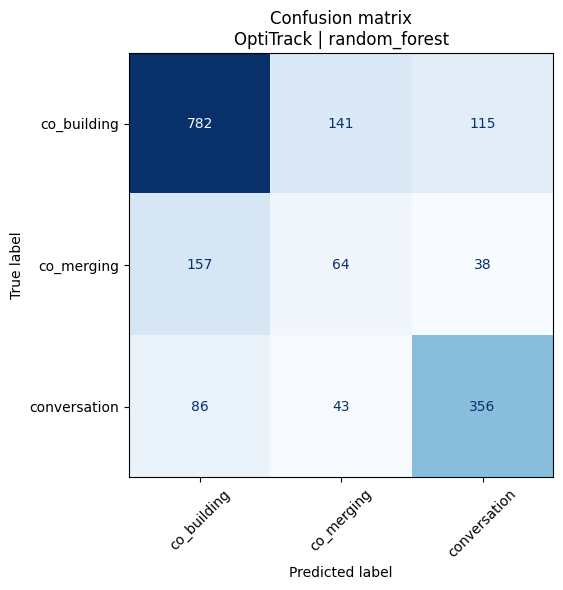

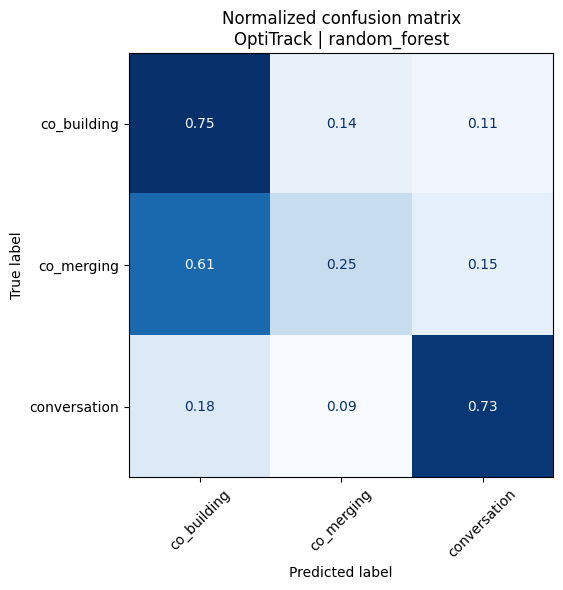

Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_best_overall_confusion_matrix.png
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_best_overall_normalized_confusion_matrix.png


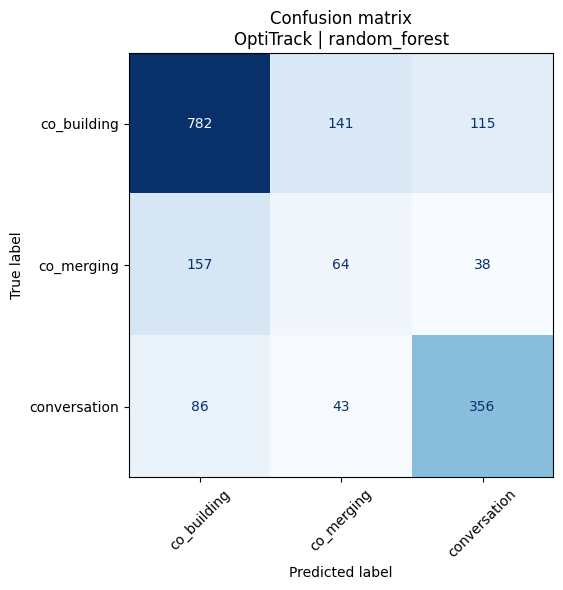

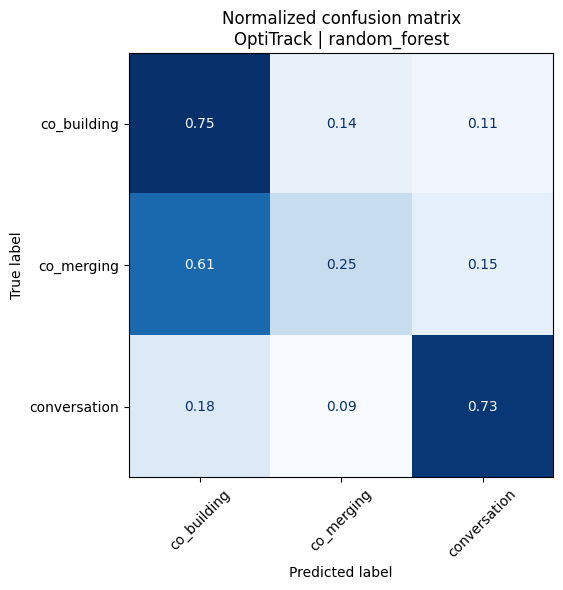

Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_optitrack_rf_confusion_matrix.png
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_optitrack_rf_normalized_confusion_matrix.png


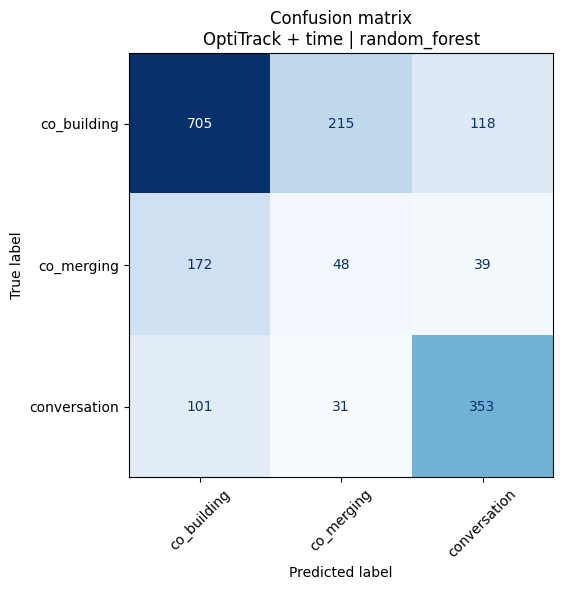

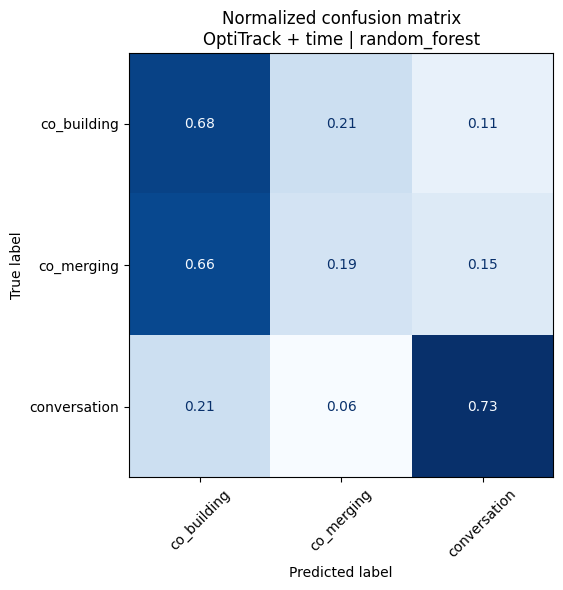

Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_optitrack_time_rf_confusion_matrix.png
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_optitrack_time_rf_normalized_confusion_matrix.png


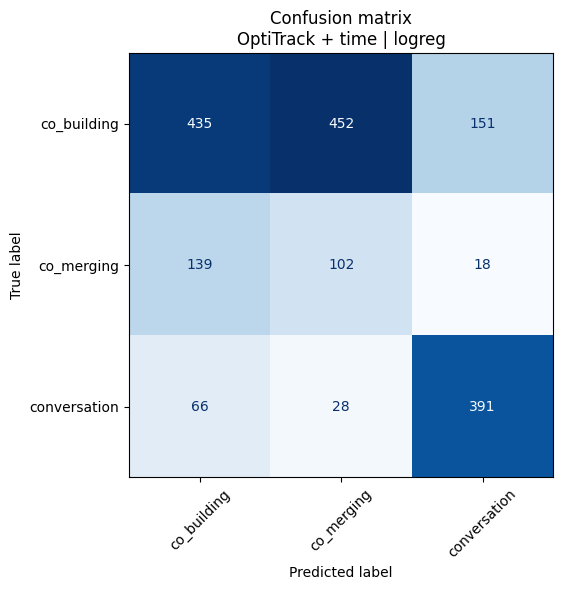

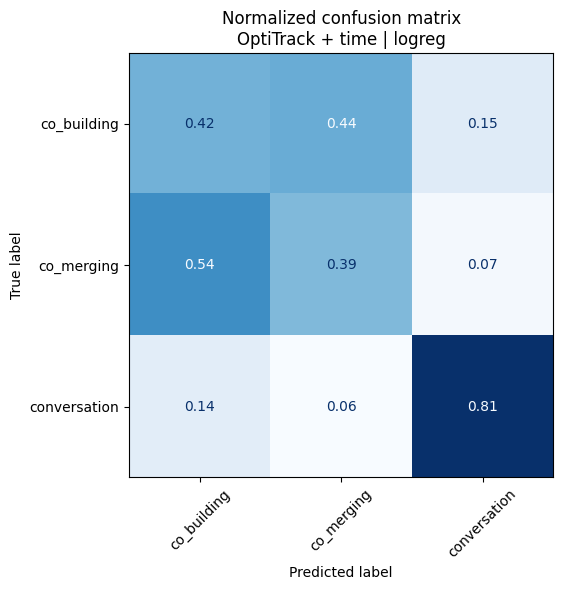

Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_optitrack_time_logreg_confusion_matrix.png
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_optitrack_time_logreg_normalized_confusion_matrix.png


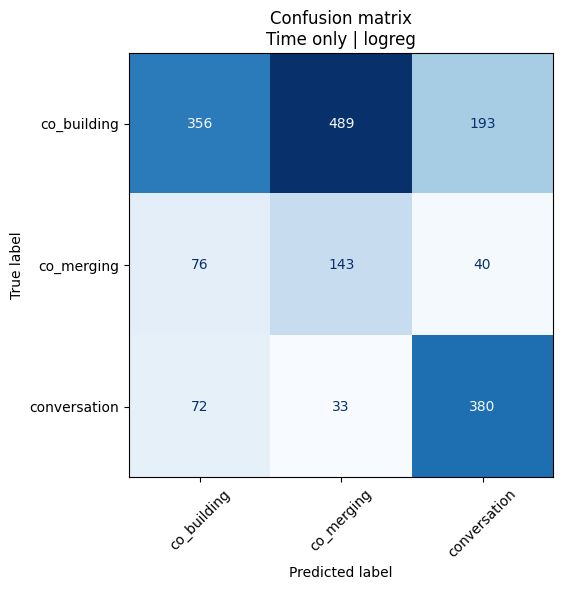

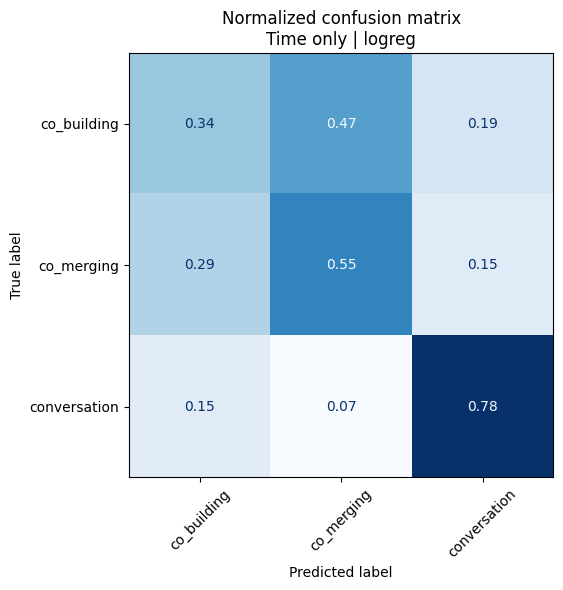

Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_time_only_logreg_confusion_matrix.png
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_time_only_logreg_normalized_confusion_matrix.png


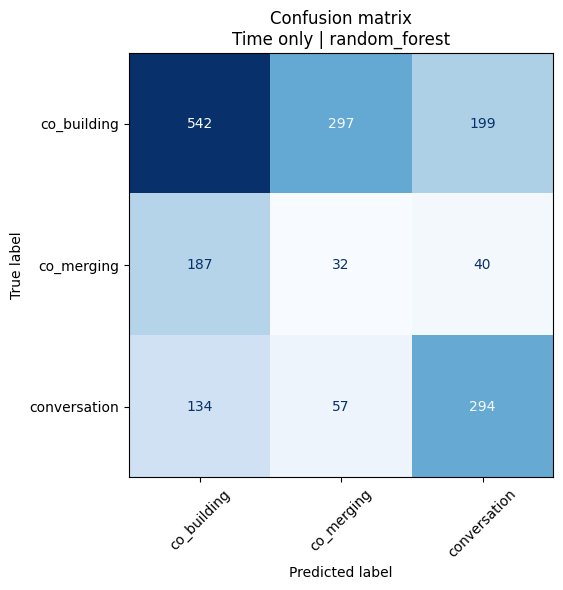

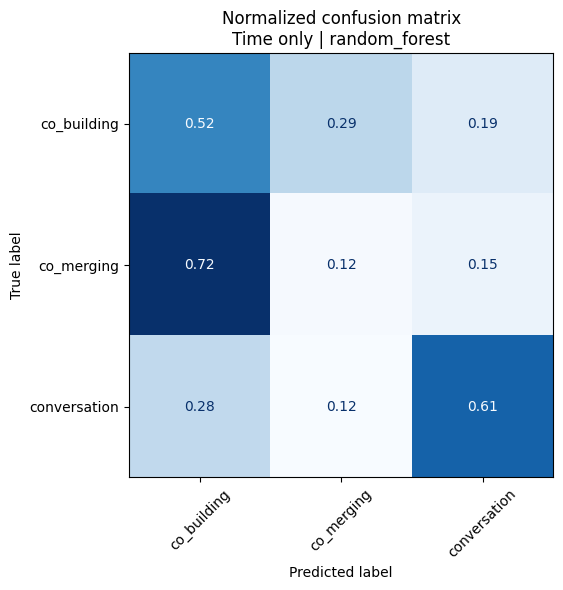

Saved:
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_time_only_rf_confusion_matrix.png
/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_time_only_rf_normalized_confusion_matrix.png


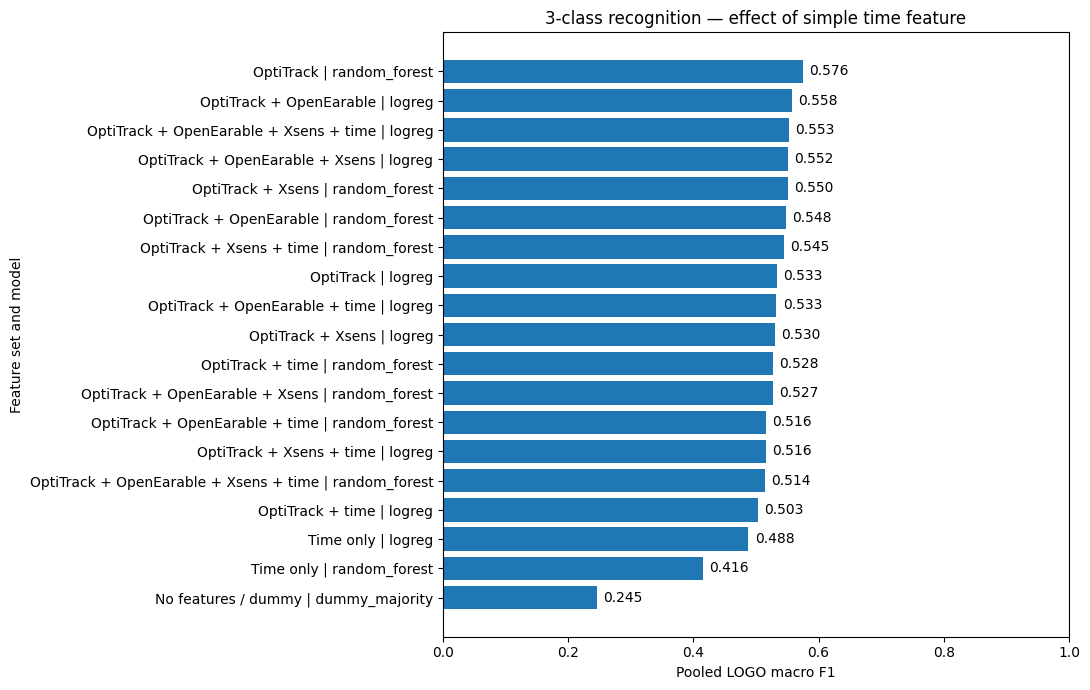

Saved plot: /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/recognition_3class_classical_simple_time_macro_f1_comparison.png


In [ ]:
# ============================================================
# CLASSICAL 3-CLASS RECOGNITION WITH SIMPLE TIME FEATURE
#
# Goal:
#   Test whether one simple time feature helps distinguish:
#       co_building vs co_merging vs conversation
#
# time:
#   early session -> low value
#   later session -> high value
#
# Models:
#   Dummy majority
#   Logistic Regression
#   Random Forest
#
# Evaluation:
#   Leave-One-Group-Out
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"

FULL_ENG3_PATH = f"{OUT_DIR}/interaction_eng3_features.csv"
REC3_PATH = f"{OUT_DIR}/eng3_recognition_3class_core_features.csv"

full_df = pd.read_csv(FULL_ENG3_PATH)
df = pd.read_csv(REC3_PATH)

print("=" * 80)
print("3-CLASS CLASSICAL RECOGNITION WITH SIMPLE TIME FEATURE")
print("=" * 80)

print("Rows:", len(df))
print("\nClass counts:")
print(df["recognition_label"].value_counts())

print("\nClass counts by group:")
display(pd.crosstab(df["group"], df["recognition_label"]))


# ============================================================
# Add simple time feature
# ============================================================

def add_key_columns(d):
    d = d.copy()
    d["group_key"] = d["group"].astype(int)
    d["window_start_key"] = np.round(d["window_start"].astype(float), 6)
    d["window_end_key"] = np.round(d["window_end"].astype(float), 6)
    return d

full_df = add_key_columns(full_df)
df = add_key_columns(df)

full_df["window_mid"] = (
    full_df["window_start"].astype(float)
    + full_df["window_end"].astype(float)
) / 2.0

full_df["group_start_time"] = full_df.groupby("group")["window_mid"].transform("min")

full_df["elapsed_time_s"] = full_df["window_mid"] - full_df["group_start_time"]

# Simple time feature:
# later windows have higher values
full_df["time"] = full_df["elapsed_time_s"] / 2700.0
full_df["time"] = full_df["time"].clip(0, 1.5)

df = df.merge(
    full_df[
        [
            "group_key",
            "window_start_key",
            "window_end_key",
            "elapsed_time_s",
            "time",
        ]
    ],
    on=["group_key", "window_start_key", "window_end_key"],
    how="left",
    validate="one_to_one",
)

if df["time"].isna().any():
    missing_n = df["time"].isna().sum()
    raise ValueError(f"{missing_n} rows did not receive a time feature.")

print("\nAdded simple time feature.")
print("\nExample rows:")
display(
    df[
        [
            "group",
            "window_start",
            "window_end",
            "recognition_label",
            "elapsed_time_s",
            "time",
        ]
    ].head(20)
)

print("\nTime feature summary by class:")
display(
    df
    .groupby("recognition_label")[["elapsed_time_s", "time"]]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)


# ============================================================
# Feature groups
# ============================================================

OPTITRACK_FEATURES = [
    "dist_close_mean",
    "dist_close_min",
    "dist_mid_mean",
    "dist_far_mean",
    "dist_disp_mean",
    "dist_disp_std",
    "speed_min",
    "speed_mid",
    "speed_max",
    "centroid_speed",
]

OPENEAREABLE_FEATURES = [
    "accE_min",
    "accE_mid",
    "accE_max",
    "gyrE_min",
    "gyrE_mid",
    "gyrE_max",
    "move_coord",
]

XSENS_FEATURES = [
    "hand_freq_mean",
    "hand_freq_max",
    "hand_power_mean",
    "hand_orient_var",
    "hand_coord",
    "xsens_available",
]

XSENS_FEATURES = [c for c in XSENS_FEATURES if c in df.columns]

TIME_FEATURES = ["time"]

feature_sets = {
    "No features / dummy": [],
    "Time only": TIME_FEATURES,

    "OptiTrack": OPTITRACK_FEATURES,
    "OptiTrack + time": OPTITRACK_FEATURES + TIME_FEATURES,

    "OptiTrack + OpenEarable": OPTITRACK_FEATURES + OPENEAREABLE_FEATURES,
    "OptiTrack + OpenEarable + time": OPTITRACK_FEATURES + OPENEAREABLE_FEATURES + TIME_FEATURES,
}

if len(XSENS_FEATURES) > 0:
    feature_sets.update({
        "OptiTrack + Xsens": OPTITRACK_FEATURES + XSENS_FEATURES,
        "OptiTrack + Xsens + time": OPTITRACK_FEATURES + XSENS_FEATURES + TIME_FEATURES,

        "OptiTrack + OpenEarable + Xsens": OPTITRACK_FEATURES + OPENEAREABLE_FEATURES + XSENS_FEATURES,
        "OptiTrack + OpenEarable + Xsens + time": OPTITRACK_FEATURES + OPENEAREABLE_FEATURES + XSENS_FEATURES + TIME_FEATURES,
    })

print("\nFeature sets:")
for name, feats in feature_sets.items():
    missing = [c for c in feats if c not in df.columns]
    if missing:
        raise ValueError(f"{name} has missing columns: {missing}")
    print(f"{name}: {len(feats)} features")


# ============================================================
# Models
# ============================================================

models = {
    "dummy_majority": Pipeline([
        ("clf", DummyClassifier(strategy="most_frequent")),
    ]),

    "logreg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42
        )),
    ]),

    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )),
    ]),
}


# ============================================================
# LOGO evaluation
# ============================================================

y = df["recognition_label"].copy()
groups = df["group"].values
class_names = sorted(y.unique())

logo = LeaveOneGroupOut()

summary_rows = []
fold_rows = []
pred_rows = []

for feature_set_name, features in feature_sets.items():

    if feature_set_name == "No features / dummy":
        model_items = [("dummy_majority", models["dummy_majority"])]
        X = pd.DataFrame({"constant": np.ones(len(df))})
    else:
        model_items = [
            ("logreg", models["logreg"]),
            ("random_forest", models["random_forest"]),
        ]
        X = df[features].copy()

    for model_name, base_model in model_items:

        print("\n" + "=" * 80)
        print("FEATURE SET:", feature_set_name)
        print("MODEL:", model_name)
        print("=" * 80)

        y_true_all = []
        y_pred_all = []

        for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups),
            start=1
        ):
            test_group = groups[test_idx][0]

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model = clone(base_model)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(y_test, y_pred)

            macro_f1 = f1_score(
                y_test,
                y_pred,
                labels=class_names,
                average="macro",
                zero_division=0
            )

            weighted_f1 = f1_score(
                y_test,
                y_pred,
                labels=class_names,
                average="weighted",
                zero_division=0
            )

            bal_acc = balanced_accuracy_score(y_test, y_pred)

            print(
                f"Fold {fold} | test_group={test_group} | "
                f"acc={acc:.3f} | macroF1={macro_f1:.3f} | "
                f"weightedF1={weighted_f1:.3f} | balAcc={bal_acc:.3f}"
            )

            fold_rows.append({
                "feature_set": feature_set_name,
                "model": model_name,
                "fold": int(fold),
                "test_group": int(test_group),
                "accuracy": float(acc),
                "macro_f1": float(macro_f1),
                "weighted_f1": float(weighted_f1),
                "balanced_accuracy": float(bal_acc),
                "n_test": int(len(test_idx)),
                "n_features": int(len(features)),
                "features": ", ".join(features),
            })

            for true_lab, pred_lab in zip(y_test, y_pred):
                pred_rows.append({
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "fold": int(fold),
                    "test_group": int(test_group),
                    "true_label": true_lab,
                    "predicted_label": pred_lab,
                    "correct": bool(true_lab == pred_lab),
                })

            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

        pooled_acc = accuracy_score(y_true_all, y_pred_all)

        pooled_macro_f1 = f1_score(
            y_true_all,
            y_pred_all,
            labels=class_names,
            average="macro",
            zero_division=0
        )

        pooled_weighted_f1 = f1_score(
            y_true_all,
            y_pred_all,
            labels=class_names,
            average="weighted",
            zero_division=0
        )

        pooled_bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)

        fold_df_tmp = pd.DataFrame(fold_rows)
        fold_df_tmp = fold_df_tmp[
            (fold_df_tmp["feature_set"] == feature_set_name)
            & (fold_df_tmp["model"] == model_name)
        ]

        summary_rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "n_rows": int(len(df)),
            "n_classes": int(len(class_names)),
            "n_features": int(len(features)),
            "pooled_accuracy": float(pooled_acc),
            "pooled_macro_f1": float(pooled_macro_f1),
            "pooled_weighted_f1": float(pooled_weighted_f1),
            "pooled_balanced_accuracy": float(pooled_bal_acc),
            "mean_group_accuracy": float(fold_df_tmp["accuracy"].mean()),
            "mean_group_macro_f1": float(fold_df_tmp["macro_f1"].mean()),
            "mean_group_weighted_f1": float(fold_df_tmp["weighted_f1"].mean()),
            "mean_group_balanced_accuracy": float(fold_df_tmp["balanced_accuracy"].mean()),
            "features": ", ".join(features),
        })

        print("\nPooled result:")
        print("Accuracy:", round(pooled_acc, 3))
        print("Macro F1:", round(pooled_macro_f1, 3))
        print("Weighted F1:", round(pooled_weighted_f1, 3))
        print("Balanced accuracy:", round(pooled_bal_acc, 3))

        print("\nClassification report:")
        print(classification_report(
            y_true_all,
            y_pred_all,
            labels=class_names,
            zero_division=0
        ))


summary_df_time = pd.DataFrame(summary_rows).sort_values(
    "pooled_macro_f1",
    ascending=False
)

fold_df_time = pd.DataFrame(fold_rows)
pred_df_time = pd.DataFrame(pred_rows)

print("\n" + "=" * 80)
print("CLASSICAL SIMPLE-TIME SUMMARY")
print("=" * 80)
display(summary_df_time.round(3))

print("\nMacro F1 pivot:")
pivot_macro = summary_df_time.pivot_table(
    index="feature_set",
    columns="model",
    values="pooled_macro_f1"
)
display(pivot_macro.round(3))


# ============================================================
# Co-building / co-merging confusion analysis
# ============================================================

confusion_rows = []

for (feature_set_name, model_name), sub in pred_df_time.groupby(["feature_set", "model"]):

    true_merging = (sub["true_label"] == "co_merging").sum()
    true_building = (sub["true_label"] == "co_building").sum()

    merging_as_building = (
        (sub["true_label"] == "co_merging")
        & (sub["predicted_label"] == "co_building")
    ).sum()

    building_as_merging = (
        (sub["true_label"] == "co_building")
        & (sub["predicted_label"] == "co_merging")
    ).sum()

    merging_correct = (
        (sub["true_label"] == "co_merging")
        & (sub["predicted_label"] == "co_merging")
    ).sum()

    building_correct = (
        (sub["true_label"] == "co_building")
        & (sub["predicted_label"] == "co_building")
    ).sum()

    confusion_rows.append({
        "feature_set": feature_set_name,
        "model": model_name,

        "true_co_merging": int(true_merging),
        "co_merging_correct": int(merging_correct),
        "co_merging_recall": float(merging_correct / true_merging) if true_merging > 0 else np.nan,

        "co_merging_predicted_as_co_building": int(merging_as_building),
        "co_merging_as_co_building_rate": float(merging_as_building / true_merging) if true_merging > 0 else np.nan,

        "true_co_building": int(true_building),
        "co_building_correct": int(building_correct),
        "co_building_recall": float(building_correct / true_building) if true_building > 0 else np.nan,

        "co_building_predicted_as_co_merging": int(building_as_merging),
        "co_building_as_co_merging_rate": float(building_as_merging / true_building) if true_building > 0 else np.nan,
    })

confusion_analysis_df = pd.DataFrame(confusion_rows).sort_values(
    "co_merging_as_co_building_rate",
    ascending=True
)

print("\n" + "=" * 80)
print("CO_BUILDING / CO_MERGING CONFUSION ANALYSIS")
print("=" * 80)
display(confusion_analysis_df.round(3))


# ============================================================
# Save outputs
# ============================================================

RESULT_PREFIX = "recognition_3class_classical_simple_time"

summary_path = f"{OUT_DIR}/{RESULT_PREFIX}_summary.csv"
fold_path = f"{OUT_DIR}/{RESULT_PREFIX}_folds.csv"
pred_path = f"{OUT_DIR}/{RESULT_PREFIX}_predictions.csv"
confusion_analysis_path = f"{OUT_DIR}/{RESULT_PREFIX}_comerging_cobuilding_confusion_analysis.csv"
pivot_path = f"{OUT_DIR}/{RESULT_PREFIX}_macro_f1_pivot.csv"

summary_df_time.to_csv(summary_path, index=False)
fold_df_time.to_csv(fold_path, index=False)
pred_df_time.to_csv(pred_path, index=False)
confusion_analysis_df.to_csv(confusion_analysis_path, index=False)
pivot_macro.to_csv(pivot_path)

print("\nSaved:")
print(summary_path)
print(fold_path)
print(pred_path)
print(confusion_analysis_path)
print(pivot_path)


# ============================================================
# Confusion matrices
# ============================================================

def save_confusion_for(feature_set_name, model_name, suffix):
    sub = pred_df_time[
        (pred_df_time["feature_set"] == feature_set_name)
        & (pred_df_time["model"] == model_name)
    ].copy()

    if len(sub) == 0:
        print(f"Skipping missing combo: {feature_set_name} / {model_name}")
        return

    cm = confusion_matrix(
        sub["true_label"],
        sub["predicted_label"],
        labels=class_names,
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    plt.title(f"Confusion matrix\n{feature_set_name} | {model_name}")
    plt.tight_layout()

    cm_path = f"{OUT_DIR}/{RESULT_PREFIX}_{suffix}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.show()

    cm_norm = confusion_matrix(
        sub["true_label"],
        sub["predicted_label"],
        labels=class_names,
        normalize="true",
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=class_names,
    )
    disp.plot(
        ax=ax,
        xticks_rotation=45,
        cmap="Blues",
        colorbar=False,
        values_format=".2f",
    )
    plt.title(f"Normalized confusion matrix\n{feature_set_name} | {model_name}")
    plt.tight_layout()

    cm_norm_path = f"{OUT_DIR}/{RESULT_PREFIX}_{suffix}_normalized_confusion_matrix.png"
    plt.savefig(cm_norm_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(cm_path)
    print(cm_norm_path)


# Best overall
best_row = summary_df_time.iloc[0]
best_feature_set = best_row["feature_set"]
best_model = best_row["model"]

print("\nBest overall:")
print(best_feature_set, "|", best_model)

save_confusion_for(
    best_feature_set,
    best_model,
    "best_overall"
)

# Key comparisons
save_confusion_for(
    "OptiTrack",
    "random_forest",
    "optitrack_rf"
)

save_confusion_for(
    "OptiTrack + time",
    "random_forest",
    "optitrack_time_rf"
)

save_confusion_for(
    "OptiTrack + time",
    "logreg",
    "optitrack_time_logreg"
)

save_confusion_for(
    "Time only",
    "logreg",
    "time_only_logreg"
)

save_confusion_for(
    "Time only",
    "random_forest",
    "time_only_rf"
)


# ============================================================
# Plot macro F1 comparison
# ============================================================

plot_df = summary_df_time.copy()
plot_df["label"] = plot_df["feature_set"] + " | " + plot_df["model"]
plot_df = plot_df.sort_values("pooled_macro_f1", ascending=True)

plt.figure(figsize=(11, 7))
plt.barh(plot_df["label"], plot_df["pooled_macro_f1"])
plt.xlabel("Pooled LOGO macro F1")
plt.ylabel("Feature set and model")
plt.title("3-class recognition — effect of simple time feature")
plt.xlim(0, 1)

for i, v in enumerate(plot_df["pooled_macro_f1"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()

plot_path = f"{OUT_DIR}/{RESULT_PREFIX}_macro_f1_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

3-CLASS RECOGNITION WITH SESSION-RELATIVE TIME
Rows: 1782

Class counts:
recognition_label
co_building     1038
conversation     485
co_merging       259
Name: count, dtype: int64

Class counts by group:


recognition_label,co_building,co_merging,conversation
group,,,
1,18,86,88
2,157,0,35
3,74,14,66
5,166,57,19
6,80,19,47
7,213,48,40
8,105,6,78
9,201,21,87
10,24,8,25



Time feature summary by class (mean ~ position in session):


elapsed_time_s                            time         \
                            mean      std     min     max   mean    std   
recognition_label                                                         
co_building             2026.378  622.450   595.0  3290.0  0.731  0.148   
co_merging              2329.479  752.577  1245.0  3510.0  0.929  0.057   
conversation             836.959  739.717     0.0  3475.0  0.348  0.270   

                                 
                     min    max  
recognition_label                
co_building        0.170  0.987  
co_merging         0.762  1.000  
conversation       0.000  1.000


Feature sets:
No features / dummy: 0 features
Time only: 1 features
OptiTrack: 10 features
OptiTrack + time: 11 features
OptiTrack + OpenEarable: 17 features
OptiTrack + OpenEarable + time: 18 features
OptiTrack + Xsens: 16 features
OptiTrack + Xsens + time: 17 features
OptiTrack + OpenEarable + Xsens: 23 features
OptiTrack + OpenEarable + Xsens + time: 24 features

No features / dummy                        dummy_majority pooledF1=0.245  meanGrpF1=0.228  meanGrpAcc=0.551


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



OptiTrack + OpenEarable + Xsens + time     random_forest  pooledF1=0.728  meanGrpF1=0.689  meanGrpAcc=0.771

SUMMARY (sorted by mean-over-groups macro-F1)


,feature_set,model,n_features,pooled_accuracy,pooled_macro_f1,mean_group_accuracy,mean_group_macro_f1,mean_group_balanced_accuracy
10,OptiTrack + OpenEarable + time,random_forest,18,0.773,0.741,0.779,0.706,0.769
2,Time only,random_forest,1,0.754,0.736,0.755,0.706,0.794
14,OptiTrack + Xsens + time,random_forest,17,0.779,0.752,0.772,0.702,0.763
6,OptiTrack + time,random_forest,11,0.772,0.746,0.761,0.692,0.760
18,OptiTrack + OpenEarable + Xsens + time,random_forest,24,0.769,0.728,0.771,0.689,0.740
9,OptiTrack + OpenEarable + time,logreg,18,0.758,0.737,0.747,0.674,0.757
1,Time only,logreg,1,0.736,0.715,0.723,0.668,0.779
5,OptiTrack + time,logreg,11,0.755,0.733,0.731,0.662,0.754
17,OptiTrack + OpenEarable + Xsens + time,logreg,24,0.768,0.742,0.739,0.657,0.729
13,OptiTrack + Xsens + time,logreg,17,0.753,0.727,0.721,0.642,0.717



co_merging recovery by config:


,feature_set,model,co_merging_recall,co_merging_as_co_building_rate
15,OptiTrack + time,logreg,0.822,0.166
17,Time only,logreg,0.811,0.189
9,OptiTrack + OpenEarable + time,logreg,0.807,0.166
18,Time only,random_forest,0.768,0.220
7,OptiTrack + OpenEarable + Xsens + time,logreg,0.768,0.174
13,OptiTrack + Xsens + time,logreg,0.764,0.212
16,OptiTrack + time,random_forest,0.730,0.220
14,OptiTrack + Xsens + time,random_forest,0.730,0.228
10,OptiTrack + OpenEarable + time,random_forest,0.707,0.251
8,OptiTrack + OpenEarable + Xsens + time,random_forest,0.633,0.309


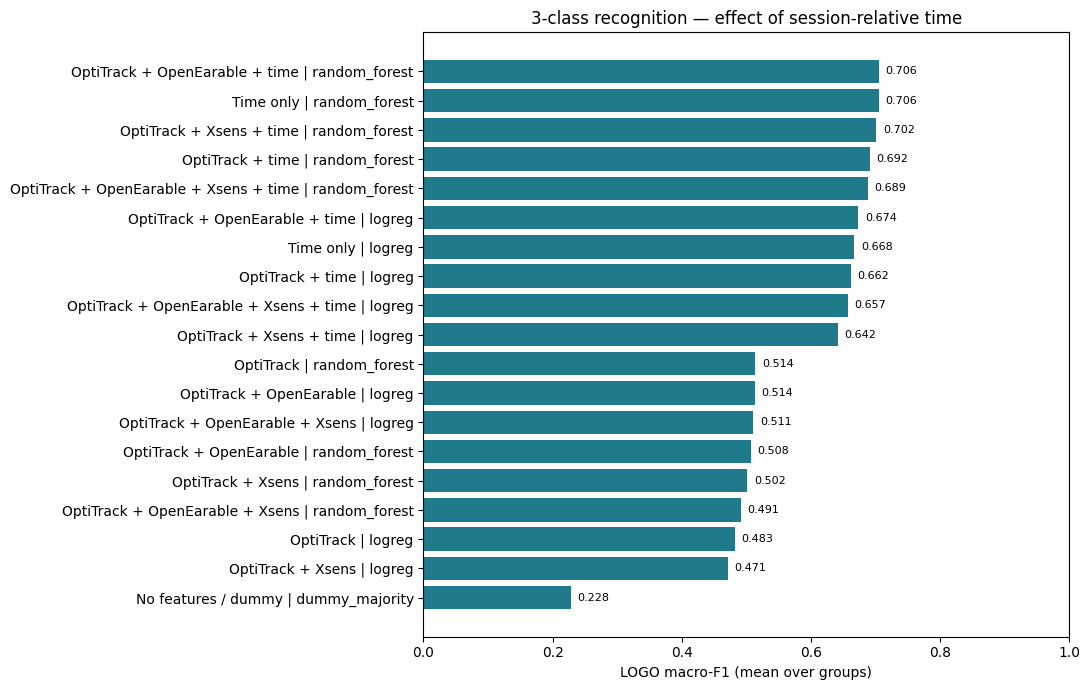

In [ ]:
# ============================================================
# CLASSICAL 3-CLASS RECOGNITION WITH SESSION-RELATIVE TIME FEATURE
#   time = position within each session, 0 (start) -> 1 (end), per group
# Eval: Leave-One-Group-Out
# ============================================================
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay)

OUT_DIR = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"
FULL_ENG3_PATH = f"{OUT_DIR}/interaction_eng3_features.csv"
REC3_PATH = f"{OUT_DIR}/eng3_recognition_3class_core_features.csv"

full_df = pd.read_csv(FULL_ENG3_PATH)
df = pd.read_csv(REC3_PATH)

print("="*80); print("3-CLASS RECOGNITION WITH SESSION-RELATIVE TIME"); print("="*80)
print("Rows:", len(df)); print("\nClass counts:"); print(df["recognition_label"].value_counts())
print("\nClass counts by group:"); display(pd.crosstab(df["group"], df["recognition_label"]))

# ---------- session-relative time feature ----------
def add_key_columns(d):
    d = d.copy()
    d["group_key"] = d["group"].astype(int)
    d["window_start_key"] = np.round(d["window_start"].astype(float), 6)
    d["window_end_key"]   = np.round(d["window_end"].astype(float), 6)
    return d

full_df = add_key_columns(full_df); df = add_key_columns(df)
full_df["window_mid"] = (full_df["window_start"].astype(float) + full_df["window_end"].astype(float)) / 2.0
full_df["group_start_time"] = full_df.groupby("group")["window_mid"].transform("min")
full_df["group_end_time"]   = full_df.groupby("group")["window_mid"].transform("max")
full_df["elapsed_time_s"]   = full_df["window_mid"] - full_df["group_start_time"]
# FIX: normalize by each session's OWN duration -> true 0..1 position
dur = (full_df["group_end_time"] - full_df["group_start_time"]).clip(lower=1e-9)
full_df["time"] = (full_df["elapsed_time_s"] / dur).clip(0, 1)

df = df.merge(
    full_df[["group_key","window_start_key","window_end_key","elapsed_time_s","time"]],
    on=["group_key","window_start_key","window_end_key"], how="left", validate="one_to_one")
if df["time"].isna().any():
    raise ValueError(f"{df['time'].isna().sum()} rows did not receive a time feature.")

print("\nTime feature summary by class (mean ~ position in session):")
display(df.groupby("recognition_label")[["elapsed_time_s","time"]].agg(["mean","std","min","max"]).round(3))

# ---------- feature groups ----------
OPTITRACK_FEATURES = ["dist_close_mean","dist_close_min","dist_mid_mean","dist_far_mean",
    "dist_disp_mean","dist_disp_std","speed_min","speed_mid","speed_max","centroid_speed"]
OPENEAREABLE_FEATURES = ["accE_min","accE_mid","accE_max","gyrE_min","gyrE_mid","gyrE_max","move_coord"]
XSENS_FEATURES = [c for c in ["hand_freq_mean","hand_freq_max","hand_power_mean","hand_orient_var","hand_coord","xsens_available"] if c in df.columns]
TIME_FEATURES = ["time"]

feature_sets = {
    "No features / dummy": [],
    "Time only": TIME_FEATURES,
    "OptiTrack": OPTITRACK_FEATURES,
    "OptiTrack + time": OPTITRACK_FEATURES + TIME_FEATURES,
    "OptiTrack + OpenEarable": OPTITRACK_FEATURES + OPENEAREABLE_FEATURES,
    "OptiTrack + OpenEarable + time": OPTITRACK_FEATURES + OPENEAREABLE_FEATURES + TIME_FEATURES,
}
if len(XSENS_FEATURES) > 0:
    feature_sets.update({
        "OptiTrack + Xsens": OPTITRACK_FEATURES + XSENS_FEATURES,
        "OptiTrack + Xsens + time": OPTITRACK_FEATURES + XSENS_FEATURES + TIME_FEATURES,
        "OptiTrack + OpenEarable + Xsens": OPTITRACK_FEATURES + OPENEAREABLE_FEATURES + XSENS_FEATURES,
        "OptiTrack + OpenEarable + Xsens + time": OPTITRACK_FEATURES + OPENEAREABLE_FEATURES + XSENS_FEATURES + TIME_FEATURES,
    })
print("\nFeature sets:")
for name, feats in feature_sets.items():
    missing = [c for c in feats if c not in df.columns]
    if missing: raise ValueError(f"{name} has missing columns: {missing}")
    print(f"{name}: {len(feats)} features")

# ---------- models ----------
models = {
    "dummy_majority": Pipeline([("clf", DummyClassifier(strategy="most_frequent"))]),
    "logreg": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs", random_state=42))]),
    "random_forest": Pipeline([("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1))]),
}

# ---------- LOGO ----------
y = df["recognition_label"].copy(); groups = df["group"].values
class_names = sorted(y.unique()); logo = LeaveOneGroupOut()
summary_rows, fold_rows, pred_rows = [], [], []

for feature_set_name, features in feature_sets.items():
    if feature_set_name == "No features / dummy":
        model_items = [("dummy_majority", models["dummy_majority"])]; X = pd.DataFrame({"constant": np.ones(len(df))})
    else:
        model_items = [("logreg", models["logreg"]), ("random_forest", models["random_forest"])]; X = df[features].copy()
    for model_name, base_model in model_items:
        y_true_all, y_pred_all = [], []
        for fold,(tr,te) in enumerate(logo.split(X,y,groups), start=1):
            tg = groups[te][0]
            model = clone(base_model); model.fit(X.iloc[tr], y.iloc[tr]); yp = model.predict(X.iloc[te])
            yt = y.iloc[te]
            fold_rows.append({"feature_set":feature_set_name,"model":model_name,"fold":int(fold),"test_group":int(tg),
                "accuracy":float(accuracy_score(yt,yp)),
                "macro_f1":float(f1_score(yt,yp,labels=class_names,average="macro",zero_division=0)),
                "weighted_f1":float(f1_score(yt,yp,labels=class_names,average="weighted",zero_division=0)),
                "balanced_accuracy":float(balanced_accuracy_score(yt,yp)),
                "n_features":int(len(features))})
            for tl,pl in zip(yt,yp):
                pred_rows.append({"feature_set":feature_set_name,"model":model_name,"test_group":int(tg),
                    "true_label":tl,"predicted_label":pl})
            y_true_all += list(yt); y_pred_all += list(yp)
        ft = pd.DataFrame(fold_rows); ft = ft[(ft.feature_set==feature_set_name)&(ft.model==model_name)]
        summary_rows.append({"feature_set":feature_set_name,"model":model_name,"n_features":int(len(features)),
            "pooled_accuracy":float(accuracy_score(y_true_all,y_pred_all)),
            "pooled_macro_f1":float(f1_score(y_true_all,y_pred_all,labels=class_names,average="macro",zero_division=0)),
            "mean_group_accuracy":float(ft["accuracy"].mean()),
            "mean_group_macro_f1":float(ft["macro_f1"].mean()),
            "mean_group_balanced_accuracy":float(ft["balanced_accuracy"].mean())})
        print(f"\n{feature_set_name:42s} {model_name:14s} "
              f"pooledF1={summary_rows[-1]['pooled_macro_f1']:.3f}  meanGrpF1={summary_rows[-1]['mean_group_macro_f1']:.3f}  "
              f"meanGrpAcc={summary_rows[-1]['mean_group_accuracy']:.3f}")

summary_df_time = pd.DataFrame(summary_rows).sort_values("mean_group_macro_f1", ascending=False)
pred_df_time = pd.DataFrame(pred_rows)
print("\n"+"="*80); print("SUMMARY (sorted by mean-over-groups macro-F1)"); print("="*80)
display(summary_df_time.round(3))

# ---------- co_building / co_merging confusion ----------
rows=[]
for (fs,mn),sub in pred_df_time.groupby(["feature_set","model"]):
    tm=(sub.true_label=="co_merging").sum(); tb=(sub.true_label=="co_building").sum()
    m_ok=((sub.true_label=="co_merging")&(sub.predicted_label=="co_merging")).sum()
    m_as_b=((sub.true_label=="co_merging")&(sub.predicted_label=="co_building")).sum()
    rows.append({"feature_set":fs,"model":mn,"co_merging_recall":(m_ok/tm) if tm else np.nan,
                 "co_merging_as_co_building_rate":(m_as_b/tm) if tm else np.nan})
conf=pd.DataFrame(rows).sort_values("co_merging_recall",ascending=False)
print("\nco_merging recovery by config:"); display(conf.round(3))

# ---------- macro-F1 bar ----------
p=summary_df_time.copy(); p["label"]=p["feature_set"]+" | "+p["model"]; p=p.sort_values("mean_group_macro_f1")
plt.figure(figsize=(11,7)); plt.barh(p["label"],p["mean_group_macro_f1"],color="#1F7A8C")
plt.xlabel("LOGO macro-F1 (mean over groups)"); plt.xlim(0,1); plt.title("3-class recognition — effect of session-relative time")
for i,v in enumerate(p["mean_group_macro_f1"]): plt.text(v+0.01,i,f"{v:.3f}",va="center",fontsize=8)
plt.tight_layout(); plt.show()

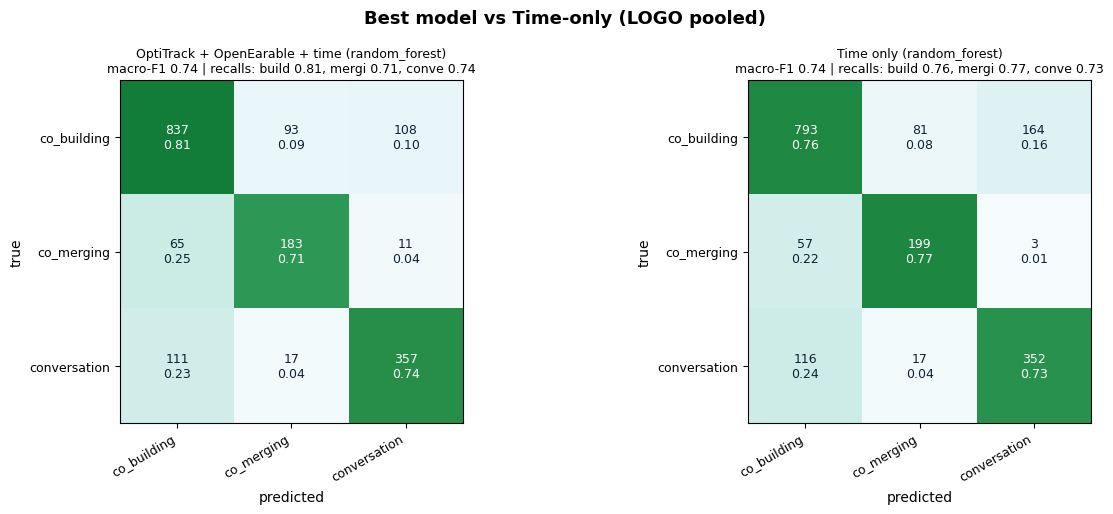

In [ ]:
# === Confusion matrix: best model (OptiTrack+OpenEarable+time, RF) vs Time-only ===
import numpy as np, matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, f1_score

def logo_preds(features, model_name):
    X=df[features].copy()
    yt_all,yp_all=[],[]
    for tr,te in logo.split(X,y,groups):
        m=clone(models[model_name]); m.fit(X.iloc[tr],y.iloc[tr])
        yt_all+=list(y.iloc[te]); yp_all+=list(m.predict(X.iloc[te]))
    return np.array(yt_all),np.array(yp_all)

configs=[("OptiTrack + OpenEarable + time", OPTITRACK_FEATURES+OPENEAREABLE_FEATURES+TIME_FEATURES, "random_forest"),
         ("Time only", TIME_FEATURES, "random_forest")]

fig,axes=plt.subplots(1,2,figsize=(13,5.2))
for ax,(name,feats,mdl) in zip(axes,configs):
    yt,yp=logo_preds(feats,mdl)
    cm=confusion_matrix(yt,yp,labels=class_names); cmn=cm/cm.sum(1,keepdims=True)
    f1=f1_score(yt,yp,labels=class_names,average="macro",zero_division=0)
    rec={c:cm[i,i]/cm[i].sum() for i,c in enumerate(class_names)}
    ax.imshow(cmn,cmap="BuGn",vmin=0,vmax=1)
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names,rotation=30,ha="right",fontsize=9); ax.set_yticklabels(class_names,fontsize=9)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j,i,f"{cm[i,j]}\n{cmn[i,j]:.2f}",ha="center",va="center",
                    fontsize=9,color="white" if cmn[i,j]>0.5 else "#0E2233")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{name} ({mdl})\nmacro-F1 {f1:.2f} | recalls: "
                 + ", ".join(f"{c.split('_')[-1][:5]} {rec[c]:.2f}" for c in class_names), fontsize=9)
plt.suptitle("Best model vs Time-only (LOGO pooled)",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.show()
plt.show()

BEST MODEL set (OptiTrack + OpenEarable + time, 18 feats) | LOGO pooled

        model        strategy  accuracy  balanced_acc  macro_F1  recall_co_merging
       logreg none (baseline)     0.769         0.700     0.713              0.517
       logreg    class_weight     0.758         0.777     0.737              0.807
       logreg           SMOTE     0.760         0.774     0.737              0.792
       logreg     random over     0.756         0.774     0.734              0.799
       logreg    random under     0.760         0.787     0.738              0.830
random_forest none (baseline)     0.770         0.726     0.729              0.614
random_forest    class_weight     0.773         0.750     0.741              0.707
random_forest           SMOTE     0.763         0.756     0.735              0.741
random_forest     random over     0.769         0.755     0.739              0.718
random_forest    random under     0.765         0.778     0.739              0.788


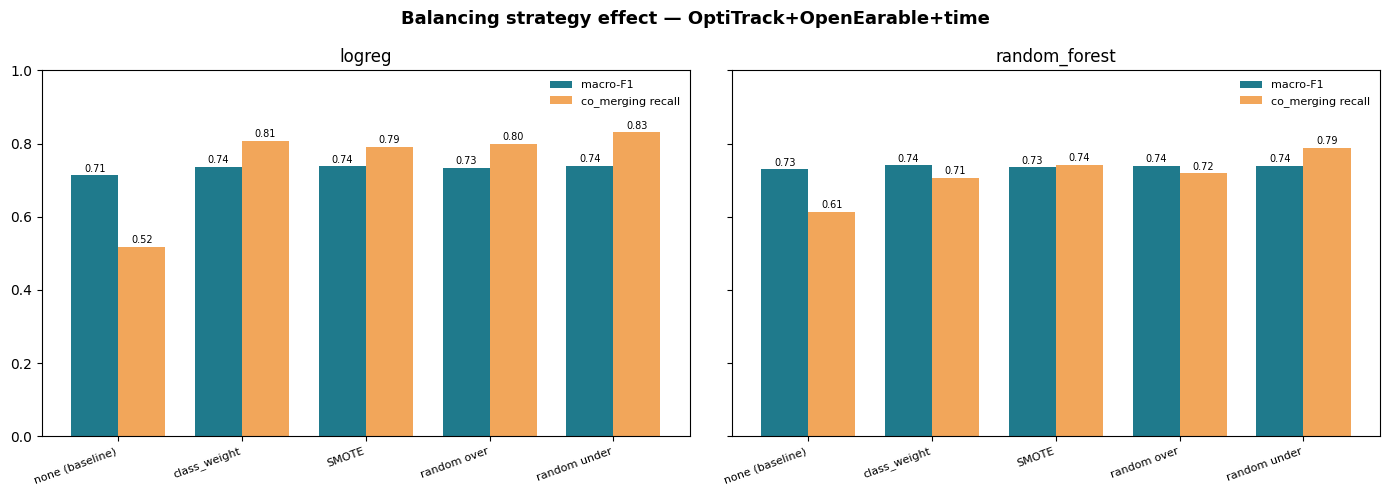

In [ ]:
# === BALANCING STRATEGIES on BEST MODEL set: OptiTrack + OpenEarable + time ===
# Both LogReg and RandomForest; resampling done INSIDE each LOGO fold (leak-free).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
except ImportError:
    import subprocess,sys; subprocess.run([sys.executable,"-m","pip","install","-q","imbalanced-learn"])
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler

FEATURES = OPTITRACK_FEATURES + OPENEAREABLE_FEATURES + TIME_FEATURES   # 18 = best model
X=df[FEATURES].copy(); y=df["recognition_label"].values; groups=df["group"].values
class_names=sorted(np.unique(y)); k=max(1,min(5,pd.Series(y).value_counts().min()-1))
logo=LeaveOneGroupOut()

def clf(kind,balanced=False):
    if kind=="logreg":
        return LogisticRegression(max_iter=5000,solver="lbfgs",random_state=42,
                                  class_weight="balanced" if balanced else None)
    return RandomForestClassifier(n_estimators=500,min_samples_leaf=3,random_state=42,n_jobs=-1,
                                  class_weight="balanced" if balanced else None)

def pipe_for(kind,strategy):
    pre=[("imp",SimpleImputer(strategy="median"))]
    if kind=="logreg": pre+=[("sc",StandardScaler())]
    res={"SMOTE":SMOTE(random_state=42,k_neighbors=k),
         "random over":RandomOverSampler(random_state=42),
         "random under":RandomUnderSampler(random_state=42)}.get(strategy)
    steps=pre+([("res",res)] if res else [])+[("clf",clf(kind,balanced=(strategy=="class_weight")))]
    return ImbPipeline(steps)

STRATS=["none (baseline)","class_weight","SMOTE","random over","random under"]
rows=[]
for kind in ["logreg","random_forest"]:
    for s in STRATS:
        yt,yp=[],[]
        for tr,te in logo.split(X,y,groups):
            m=clone(pipe_for(kind,s)); m.fit(X.iloc[tr],y[tr]); yt+=list(y[te]); yp+=list(m.predict(X.iloc[te]))
        yt,yp=np.array(yt),np.array(yp)
        rec=np.sum((yt=="co_merging")&(yp=="co_merging"))/np.sum(yt=="co_merging")
        rows.append({"model":kind,"strategy":s,
                     "accuracy":accuracy_score(yt,yp),
                     "balanced_acc":balanced_accuracy_score(yt,yp),
                     "macro_F1":f1_score(yt,yp,average="macro",zero_division=0),
                     "recall_co_merging":rec})
res=pd.DataFrame(rows)
print("BEST MODEL set (OptiTrack + OpenEarable + time, 18 feats) | LOGO pooled\n")
print(res.round(3).to_string(index=False))

fig,axes=plt.subplots(1,2,figsize=(14,5),sharey=True)
for ax,kind in zip(axes,["logreg","random_forest"]):
    sub=res[res.model==kind]; xp=np.arange(len(sub)); w=0.38
    ax.bar(xp-w/2,sub["macro_F1"],w,label="macro-F1",color="#1F7A8C")
    ax.bar(xp+w/2,sub["recall_co_merging"],w,label="co_merging recall",color="#F2A65A")
    ax.set_xticks(xp); ax.set_xticklabels(sub["strategy"],rotation=20,ha="right",fontsize=8)
    ax.set_ylim(0,1); ax.set_title(kind); ax.legend(frameon=False,fontsize=8)
    for i,v in enumerate(sub["macro_F1"]): ax.text(i-w/2,v+.01,f"{v:.2f}",ha="center",fontsize=7)
    for i,v in enumerate(sub["recall_co_merging"]): ax.text(i+w/2,v+.01,f"{v:.2f}",ha="center",fontsize=7)
plt.suptitle("Balancing strategy effect — OptiTrack+OpenEarable+time",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.show()

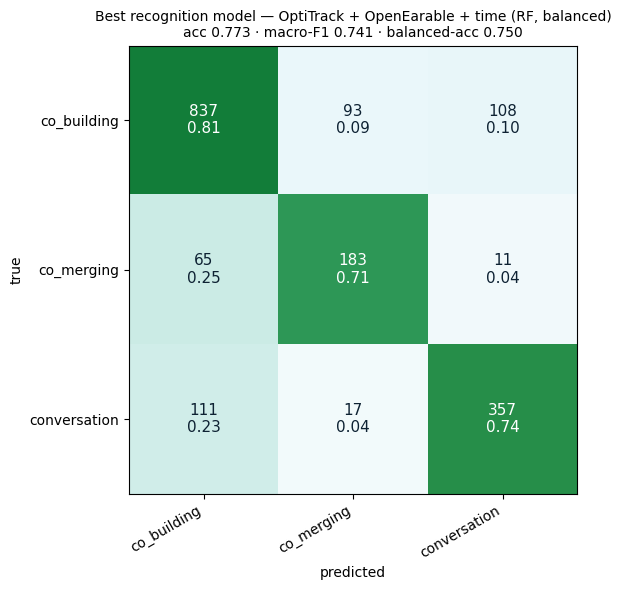

per-class recall: {'co_building': np.float64(0.806), 'co_merging': np.float64(0.707), 'conversation': np.float64(0.736)}
per-class F1: {'co_building': 0.816, 'co_merging': 0.663, 'conversation': 0.743}


In [ ]:
# === Confusion matrix: BEST recognition model ===
# OptiTrack + OpenEarable + time | RandomForest | class_weight="balanced" | LOGO pooled
import numpy as np, matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score, accuracy_score

FEATURES = OPTITRACK_FEATURES + OPENEAREABLE_FEATURES + TIME_FEATURES
X = df[FEATURES].copy(); y = df["recognition_label"].values; groups = df["group"].values
class_names = sorted(np.unique(y))
logo = LeaveOneGroupOut()

best = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                   class_weight="balanced", random_state=42, n_jobs=-1)),
])

yt, yp = [], []
for tr, te in logo.split(X, y, groups):
    m = clone(best); m.fit(X.iloc[tr], y[tr]); yt += list(y[te]); yp += list(m.predict(X.iloc[te]))
yt, yp = np.array(yt), np.array(yp)

cm  = confusion_matrix(yt, yp, labels=class_names)
cmn = cm / cm.sum(1, keepdims=True)
acc = accuracy_score(yt, yp); mf = f1_score(yt, yp, average="macro", zero_division=0)
bal = balanced_accuracy_score(yt, yp)
rec = {c: cm[i,i]/cm[i].sum() for i,c in enumerate(class_names)}

fig, ax = plt.subplots(figsize=(6.8, 6))
ax.imshow(cmn, cmap="BuGn", vmin=0, vmax=1)
ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=30, ha="right"); ax.set_yticklabels(class_names)
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, f"{cm[i,j]}\n{cmn[i,j]:.2f}", ha="center", va="center",
                fontsize=11, color="white" if cmn[i,j] > 0.5 else "#0E2233")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Best recognition model — OptiTrack + OpenEarable + time (RF, balanced)\n"
             f"acc {acc:.3f} · macro-F1 {mf:.3f} · balanced-acc {bal:.3f}", fontsize=10)
plt.tight_layout(); plt.show()

print("per-class recall:", {c: round(rec[c],3) for c in class_names})
print("per-class F1:", {c: round(f1_score(yt,yp,labels=[c],average='macro',zero_division=0),3) for c in class_names})

=== MLP on engineered+time (18 feats, LOGO pooled) ===
accuracy 0.735 | balanced_acc 0.727 | macro_F1 0.703 | co_merging recall 0.687
vs your classical best (RF class_weight): acc 0.773 | macro_F1 0.741

per-class F1: {'co_building': 0.772, 'co_merging': 0.589, 'conversation': 0.748}


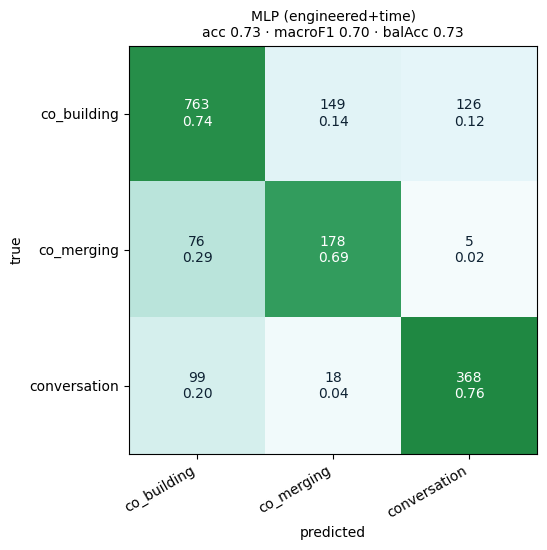

In [ ]:
# === DL COMPARISON 1: MLP on engineered features + time (fair neural test) ===
# Same 18 features, class_weight, LOGO — directly comparable to your LogReg/RF table.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, confusion_matrix
dev="cuda" if torch.cuda.is_available() else "cpu"

FEATURES = OPTITRACK_FEATURES + OPENEAREABLE_FEATURES + TIME_FEATURES
X = df[FEATURES].copy(); y = df["recognition_label"].values; groups = df["group"].values
class_names = sorted(np.unique(y)); c2i={c:i for i,c in enumerate(class_names)}
logo = LeaveOneGroupOut()

class MLP(nn.Module):
    def __init__(s,d,nc,h=64):
        super().__init__()
        s.net=nn.Sequential(nn.Linear(d,h),nn.ReLU(),nn.Dropout(0.3),
                            nn.Linear(h,h),nn.ReLU(),nn.Dropout(0.3),nn.Linear(h,nc))
    def forward(s,x): return s.net(x)

yt_all,yp_all=[],[]
for tr,te in logo.split(X,y,groups):
    imp=SimpleImputer(strategy="median").fit(X.iloc[tr]); sc=StandardScaler().fit(imp.transform(X.iloc[tr]))
    Xtr=sc.transform(imp.transform(X.iloc[tr])); Xte=sc.transform(imp.transform(X.iloc[te]))
    ytr=np.array([c2i[v] for v in y[tr]])
    cw=torch.tensor([len(ytr)/(len(class_names)*max(1,(ytr==i).sum())) for i in range(len(class_names))],
                    dtype=torch.float32,device=dev)
    net=MLP(Xtr.shape[1],len(class_names)).to(dev)
    opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=nn.CrossEntropyLoss(weight=cw)
    Xt=torch.tensor(Xtr,dtype=torch.float32); yt=torch.tensor(ytr)
    net.train()
    for _ in range(120):
        perm=torch.randperm(len(Xt))
        for i in range(0,len(Xt),64):
            b=perm[i:i+64]; opt.zero_grad(); lf(net(Xt[b].to(dev)),yt[b].to(dev)).backward(); opt.step()
    net.eval()
    with torch.no_grad(): p=net(torch.tensor(Xte,dtype=torch.float32).to(dev)).argmax(1).cpu().numpy()
    yt_all+=list(y[te]); yp_all+=[class_names[i] for i in p]
yt_all,yp_all=np.array(yt_all),np.array(yp_all)

acc=accuracy_score(yt_all,yp_all); mf=f1_score(yt_all,yp_all,average="macro",zero_division=0)
bal=balanced_accuracy_score(yt_all,yp_all)
rec_m=np.sum((yt_all=="co_merging")&(yp_all=="co_merging"))/np.sum(yt_all=="co_merging")
print("=== MLP on engineered+time (18 feats, LOGO pooled) ===")
print(f"accuracy {acc:.3f} | balanced_acc {bal:.3f} | macro_F1 {mf:.3f} | co_merging recall {rec_m:.3f}")
print("vs your classical best (RF class_weight): acc 0.773 | macro_F1 0.741")
print("\nper-class F1:", {c:round(f1_score(yt_all,yp_all,labels=[c],average='macro',zero_division=0),3) for c in class_names})

cm=confusion_matrix(yt_all,yp_all,labels=class_names); cmn=cm/cm.sum(1,keepdims=True)
fig,ax=plt.subplots(figsize=(6.4,5.6)); ax.imshow(cmn,cmap="BuGn",vmin=0,vmax=1)
ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names,rotation=30,ha="right"); ax.set_yticklabels(class_names)
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j,i,f"{cm[i,j]}\n{cmn[i,j]:.2f}",ha="center",va="center",color="white" if cmn[i,j]>0.5 else "#0E2233")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"MLP (engineered+time)\nacc {acc:.2f} · macroF1 {mf:.2f} · balAcc {bal:.2f}",fontsize=10)
plt.tight_layout(); plt.show()

device: cpu
tensor keys: ['X', 'y', 'groups', 'window_start', 'window_end']
tensor: (1782, 64, 7)
tensor has window_start/end keys: True
time matched on 100.0% of tensor windows

USE_TIME=True

cnn1d          acc 0.658 balAcc 0.637 macroF1 0.607 co_merging_recall 0.467
rnn            acc 0.598 balAcc 0.620 macroF1 0.575 co_merging_recall 0.552
gru            acc 0.621 balAcc 0.598 macroF1 0.573 co_merging_recall 0.425
lstm           acc 0.669 balAcc 0.670 macroF1 0.633 co_merging_recall 0.587
tf_none        acc 0.556 balAcc 0.545 macroF1 0.511 co_merging_recall 0.359
tf_sinusoidal  acc 0.643 balAcc 0.572 macroF1 0.555 co_merging_recall 0.255
tf_learned     acc 0.604 balAcc 0.568 macroF1 0.543 co_merging_recall 0.347
tf_rope        acc 0.590 balAcc 0.551 macroF1 0.526 co_merging_recall 0.309

         model  accuracy  balanced_acc  macro_F1  recall_co_merging
         lstm     0.669         0.670     0.633              0.587
        cnn1d     0.658         0.637     0.607              0

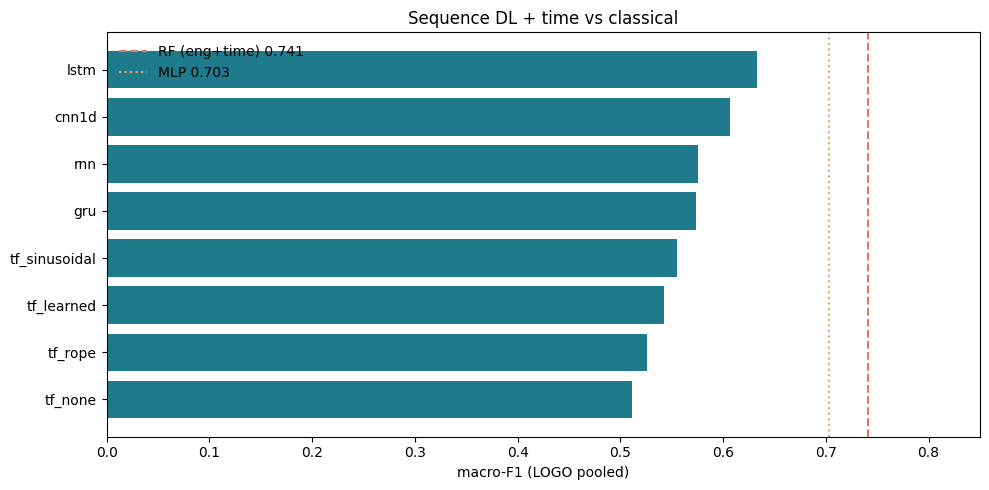

In [ ]:
# === SEQUENCE DL + TIME (fair rematch): CNN1D / RNN / GRU / LSTM / Transformer(none,sinusoidal,learned,rope) ===
# Uses the recognition tensors, aligns the session-time scalar by window keys, LOGO, class-weighted.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
dev="cuda" if torch.cuda.is_available() else "cpu"; print("device:",dev)

# ---- 1. locate a recognition tensor that carries window keys ----
TENSOR_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_tensors.npz"
z = np.load(TENSOR_PATH, allow_pickle=True)
print("tensor keys:", list(z.keys()))
Xs = np.nan_to_num(z["X"]).astype(np.float32); ys = z["y"].astype(str); gs = z["groups"]
N,T,C = Xs.shape; print("tensor:", Xs.shape)

# ---- 2. build a time lookup from df (group,start,end -> time) and map onto tensor rows ----
have_keys = ("window_start" in z) and ("window_end" in z)
print("tensor has window_start/end keys:", have_keys)
if have_keys:
    ts_start=np.round(z["window_start"].astype(float),6); ts_end=np.round(z["window_end"].astype(float),6)
    look={(int(r.group),round(float(r.window_start),6),round(float(r.window_end),6)):float(r.time) for r in df.itertuples()}
    time_arr=np.array([look.get((int(gs[i]),ts_start[i],ts_end[i]),np.nan) for i in range(N)],dtype=np.float32)
    matched=np.isfinite(time_arr).mean()
    print(f"time matched on {matched*100:.1f}% of tensor windows")
    time_arr=np.nan_to_num(time_arr, nan=float(np.nanmedian(time_arr)))
else:
    print("!! tensor has no window keys -> cannot align time by key. Falling back to row-order IF lengths match.")
    time_arr = df["time"].values.astype(np.float32) if len(df)==N else None
    print("row-order fallback usable:", time_arr is not None)

USE_TIME = time_arr is not None
class_names=sorted(np.unique(ys)); c2i={c:i for i,c in enumerate(class_names)}; logo=LeaveOneGroupOut()

# ---- 3. models ----
def rope_cs(T,hd):
    pos=torch.arange(T).float()[:,None]; inv=1/(10000**(torch.arange(0,hd,2).float()/hd))
    e=torch.cat([pos*inv,pos*inv],-1); return e.cos()[None,None],e.sin()[None,None]
def rope(x,cos,sin):
    x1,x2=x[...,:x.shape[-1]//2],x[...,x.shape[-1]//2:]; return x*cos+torch.cat([-x2,x1],-1)*sin
class TF(nn.Module):
    def __init__(s,C,nc,enc,d=64,h=4,L=2,use_t=True):
        super().__init__(); s.enc=enc; s.use_t=use_t; s.proj=nn.Linear(C,d); s.d=d; s.h=h
        if enc=="sinusoidal":
            pe=torch.zeros(T,d); pos=torch.arange(T)[:,None].float(); dv=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000)/d))
            pe[:,0::2]=torch.sin(pos*dv); pe[:,1::2]=torch.cos(pos*dv); s.register_buffer("pe",pe[None])
        elif enc=="learned": s.pe=nn.Parameter(torch.zeros(1,T,d))
        if enc=="rope":
            cos,sin=rope_cs(T,d//h); s.register_buffer("rc",cos); s.register_buffer("rs",sin)
        s.layers=nn.ModuleList([nn.ModuleDict({
            "q":nn.Linear(d,d),"k":nn.Linear(d,d),"v":nn.Linear(d,d),"o":nn.Linear(d,d),
            "n1":nn.LayerNorm(d),"n2":nn.LayerNorm(d),
            "ff":nn.Sequential(nn.Linear(d,2*d),nn.GELU(),nn.Linear(2*d,d))}) for _ in range(L)])
        s.nm=nn.LayerNorm(d); s.head=nn.Linear(d+(1 if use_t else 0),nc)
    def attn(s,l,x):
        B,T_,_=x.shape; q,k,v=[l[m](x).view(B,T_,s.h,s.d//s.h).transpose(1,2) for m in("q","k","v")]
        if s.enc=="rope": q,k=rope(q,s.rc,s.rs),rope(k,s.rc,s.rs)
        a=(q@k.transpose(-2,-1)/(s.d//s.h)**0.5).softmax(-1)
        return l["o"]((a@v).transpose(1,2).reshape(B,T_,s.d))
    def forward(s,x,t):
        x=s.proj(x)
        if s.enc in("sinusoidal","learned"): x=x+s.pe
        for l in s.layers:
            x=x+s.attn(l,l["n1"](x)); x=x+l["ff"](l["n2"](x))
        h=s.nm(x).mean(1)
        if s.use_t: h=torch.cat([h,t[:,None]],1)
        return s.head(h)
class Seq(nn.Module):
    def __init__(s,kind,C,nc,use_t=True):
        super().__init__(); s.kind=kind; s.use_t=use_t
        if kind=="cnn1d": s.body=nn.Sequential(nn.Conv1d(C,64,5,padding=2),nn.ReLU(),
                                               nn.Conv1d(64,64,3,padding=1),nn.ReLU(),nn.AdaptiveAvgPool1d(1)); f=64
        else: s.body=(nn.RNN if kind=="rnn" else nn.GRU if kind=="gru" else nn.LSTM)(C,64,batch_first=True); f=64
        s.head=nn.Sequential(nn.Linear(f+(1 if use_t else 0),64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,nc))
    def forward(s,x,t):
        if s.kind=="cnn1d": h=s.body(x.transpose(1,2)).squeeze(-1)
        else: o,_=s.body(x); h=o[:,-1,:]
        if s.use_t: h=torch.cat([h,t[:,None]],1)
        return s.head(h)

def build(kind):
    if kind.startswith("tf_"): return TF(C,len(class_names),kind[3:],use_t=USE_TIME).to(dev)
    return Seq(kind,C,len(class_names),use_t=USE_TIME).to(dev)

def run(kind,epochs=50):
    yt_all,yp_all=[],[]
    for tr,te in logo.split(Xs,ys,gs):
        sc=StandardScaler().fit(Xs[tr].reshape(-1,C))
        Xtr=sc.transform(Xs[tr].reshape(-1,C)).reshape(-1,T,C); Xte=sc.transform(Xs[te].reshape(-1,C)).reshape(-1,T,C)
        tt=(time_arr[tr] if USE_TIME else np.zeros(len(tr),np.float32))
        te_t=(time_arr[te] if USE_TIME else np.zeros(len(te),np.float32))
        yi=np.array([c2i[v] for v in ys[tr]])
        cw=torch.tensor([len(yi)/(len(class_names)*max(1,(yi==i).sum())) for i in range(len(class_names))],dtype=torch.float32,device=dev)
        net=build(kind); opt=torch.optim.AdamW(net.parameters(),1e-3,weight_decay=1e-4); lf=nn.CrossEntropyLoss(weight=cw)
        Xt=torch.tensor(Xtr); T_t=torch.tensor(tt); Y=torch.tensor(yi); net.train()
        for _ in range(epochs):
            pm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),64):
                b=pm[i:i+64]; opt.zero_grad()
                lf(net(Xt[b].to(dev),T_t[b].to(dev)),Y[b].to(dev)).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            p=net(torch.tensor(Xte).to(dev),torch.tensor(te_t).to(dev)).argmax(1).cpu().numpy()
        yt_all+=list(ys[te]); yp_all+=[class_names[i] for i in p]
    yt_all,yp_all=np.array(yt_all),np.array(yp_all)
    return (accuracy_score(yt_all,yp_all),balanced_accuracy_score(yt_all,yp_all),
            f1_score(yt_all,yp_all,average="macro",zero_division=0),
            np.sum((yt_all=="co_merging")&(yp_all=="co_merging"))/max(1,np.sum(yt_all=="co_merging")))

MODELS=["cnn1d","rnn","gru","lstm","tf_none","tf_sinusoidal","tf_learned","tf_rope"]
print(f"\nUSE_TIME={USE_TIME}\n")
rows=[]
for m in MODELS:
    a,b,f,r=run(m); rows.append([m,a,b,f,r]); print(f"{m:14s} acc {a:.3f} balAcc {b:.3f} macroF1 {f:.3f} co_merging_recall {r:.3f}")
res=pd.DataFrame(rows,columns=["model","accuracy","balanced_acc","macro_F1","recall_co_merging"]).sort_values("macro_F1",ascending=False)
print("\n",res.round(3).to_string(index=False))
print("\nclassical RF (eng+time): macroF1 0.741  |  MLP (eng+time): 0.703")
plt.figure(figsize=(10,5)); r2=res.sort_values("macro_F1")
plt.barh(r2["model"],r2["macro_F1"],color="#1F7A8C")
plt.axvline(0.741,ls="--",c="#E07A5F",label="RF (eng+time) 0.741"); plt.axvline(0.703,ls=":",c="#F2A65A",label="MLP 0.703")
plt.xlabel("macro-F1 (LOGO pooled)"); plt.xlim(0,0.85); plt.legend(frameon=False)
plt.title(f"Sequence DL {'+ time' if USE_TIME else '(no time)'} vs classical"); plt.tight_layout(); plt.show()

In [ ]:
# === BUILD KEYED RECOGNITION TENSOR (aligned to eng3 core CSV windows) ===
# Recreates the 7-channel 64-step tensor for each window in your recognition CSV,
# and stores group/window_start/window_end so the time feature can be aligned by key.
import os, glob, re, gc
import numpy as np, pandas as pd

INPUT_DIR="/content/drive/MyDrive/thesis/data/ALL_MODEL_READY_FILES_IDENTITY_FIXED"
OUT_DIR  ="/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"
REC3_PATH=f"{OUT_DIR}/eng3_recognition_3class_core_features.csv"
RESAMPLE_T=64

rec=pd.read_csv(REC3_PATH)
for col in ("group","window_start","window_end","recognition_label"):
    assert col in rec.columns, f"missing {col} in recognition CSV"
rec["group"]=rec["group"].astype(int)
print("recognition windows:", len(rec), "| groups:", sorted(rec["group"].unique()))

ACC=[f"p{p}_acc_{a}" for p in(1,2,3) for a in "xyz"]
GYR=[f"p{p}_gyro_{a}" for p in(1,2,3) for a in "xyz"]
POS=[f"Participant{p}_{a}" for p in(1,2,3) for a in "xyz"]

def discover(folder):
    g={}
    for p in glob.glob(os.path.join(folder,"group_*_model_ready.csv")):
        m=re.search(r"group_(\d+)_([a-z]+)_model_ready",os.path.basename(p))
        if m: g.setdefault(int(m.group(1)),{})[m.group(2)]=p
    return {k:v for k,v in sorted(g.items()) if "openearable" in v and "optitrack" in v}

def load(path,cols):
    df=pd.read_csv(path,low_memory=False)
    df["t"]=pd.to_numeric(df["video_time_s"],errors="coerce")
    df=df.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    for c in cols:
        if c not in df.columns: df[c]=np.nan
        df[c]=pd.to_numeric(df[c],errors="coerce")
    return df

def sinterp(grid,t,v):
    m=np.isfinite(v)
    if m.sum()<2: return np.zeros_like(grid)
    return np.interp(grid,t[m],v[m])

def tensor_for(oe,ot,ws,we):
    grid=np.linspace(ws,we,RESAMPLE_T); fs=(RESAMPLE_T-1)/max(we-ws,1e-9)
    P={p:np.stack([sinterp(grid,ot["t"].values,ot[f"Participant{p}_{a}"].values) for a in "xyz"],1) for p in(1,2,3)}
    A={p:np.stack([sinterp(grid,oe["t"].values,oe[f"p{p}_acc_{a}"].values) for a in "xyz"],1) for p in(1,2,3)}
    Gy={p:np.stack([sinterp(grid,oe["t"].values,oe[f"p{p}_gyro_{a}"].values) for a in "xyz"],1) for p in(1,2,3)}
    d=[np.linalg.norm(P[a]-P[b],axis=1) for a,b in[(1,2),(1,3),(2,3)]]
    Dsort=np.sort(np.stack(d,1),1)
    cen=(P[1]+P[2]+P[3])/3; cen_spd=np.linalg.norm(np.gradient(cen,axis=0),axis=1)*fs
    amag=[np.linalg.norm(A[p],axis=1) for p in(1,2,3)]; gmag=[np.linalg.norm(Gy[p],axis=1) for p in(1,2,3)]
    accmag_mean=np.mean(amag,0); accmag_max=np.max(amag,0); gyromag_mean=np.mean(gmag,0)
    return np.stack([Dsort[:,0],Dsort[:,1],Dsort[:,2],cen_spd,accmag_mean,accmag_max,gyromag_mean],1).astype(np.float32)

groups=discover(INPUT_DIR)
X,Y,G,WS,WE=[],[],[],[],[]
for g in sorted(rec["group"].unique()):
    if g not in groups: print(f"  group {g}: NO model_ready, skipped"); continue
    oe=load(groups[g]["openearable"],ACC+GYR); ot=load(groups[g]["optitrack"],POS)
    sub=rec[rec["group"]==g]
    for r in sub.itertuples():
        X.append(tensor_for(oe,ot,float(r.window_start),float(r.window_end)))
        Y.append(r.recognition_label); G.append(g)
        WS.append(round(float(r.window_start),6)); WE.append(round(float(r.window_end),6))
    print(f"  group {g}: {len(sub)} windows")
    del oe,ot; gc.collect()

X=np.stack(X); Y=np.array(Y); G=np.array(G); WS=np.array(WS); WE=np.array(WE)
out=f"{OUT_DIR}/eng3_recognition_3class_core_tensors.npz"
np.savez_compressed(out, X=X, y=Y, groups=G, window_start=WS, window_end=WE)
print(f"\nsaved {out}")
print("tensor:", X.shape, "| classes:", pd.Series(Y).value_counts().to_dict())
print("rows match CSV:", len(X)==len(rec))

recognition windows: 1782 | groups: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  group 1: 192 windows
  group 2: 192 windows
  group 3: 154 windows
  group 5: 242 windows
  group 6: 146 windows
  group 7: 301 windows
  group 8: 189 windows
  group 9: 309 windows
  group 10: 57 windows

saved /content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_tensors.npz
tensor: (1782, 64, 7) | classes: {'co_building': 1038, 'conversation': 485, 'co_merging': 259}
rows match CSV: True


3-CLASS RECOGNITION — ALL SENSOR SETS x session-time
Rows: 1782

Class counts:
recognition_label
co_building     1038
conversation     485
co_merging       259
Name: count, dtype: int64

Feature sets to evaluate:
  No features / dummy                        0 features
  Time only                                  1 features
  OptiTrack                                  10 features
  OptiTrack + time                           11 features
  OpenEarable                                7 features
  OpenEarable + time                         8 features
  OptiTrack + OpenEarable                    17 features
  OptiTrack + OpenEarable + time             18 features
  Xsens                                      6 features
  Xsens + time                               7 features
  OptiTrack + Xsens                          16 features
  OptiTrack + Xsens + time                   17 features
  OpenEarable + Xsens                        13 features
  OpenEarable + Xsens + time                 14 feat

,feature_set,model,n_features,pooled_macro_f1,mean_group_macro_f1,pooled_accuracy,mean_group_accuracy
0,OptiTrack + Xsens + time,random_forest,17,0.752,0.702,0.779,0.772
1,OptiTrack + time,random_forest,11,0.746,0.692,0.772,0.761
2,OptiTrack + OpenEarable + Xsens + time,logreg,24,0.742,0.657,0.768,0.739
3,OptiTrack + OpenEarable + time,random_forest,18,0.741,0.706,0.773,0.779
4,OptiTrack + OpenEarable + time,logreg,18,0.737,0.674,0.758,0.747
5,Time only,random_forest,1,0.736,0.706,0.754,0.755
6,OptiTrack + time,logreg,11,0.733,0.662,0.755,0.731
7,OpenEarable + Xsens + time,random_forest,14,0.732,0.696,0.765,0.757
8,OpenEarable + time,random_forest,8,0.732,0.702,0.770,0.765
9,OptiTrack + OpenEarable + Xsens + time,random_forest,24,0.728,0.689,0.769,0.771



>>> Non-OptiTrack combos (the ones cell 91 had skipped):
               feature_set         model  n_features  pooled_macro_f1  mean_group_macro_f1  pooled_accuracy  mean_group_accuracy
OpenEarable + Xsens + time random_forest          14            0.732                0.696            0.765                0.757
        OpenEarable + time random_forest           8            0.732                0.702            0.770                0.765
              Xsens + time random_forest           7            0.724                0.682            0.747                0.736
OpenEarable + Xsens + time        logreg          14            0.723                0.664            0.745                0.721
        OpenEarable + time        logreg           8            0.716                0.674            0.737                0.735
              Xsens + time        logreg           7            0.707                0.641            0.727                0.696
               OpenEarable        logre

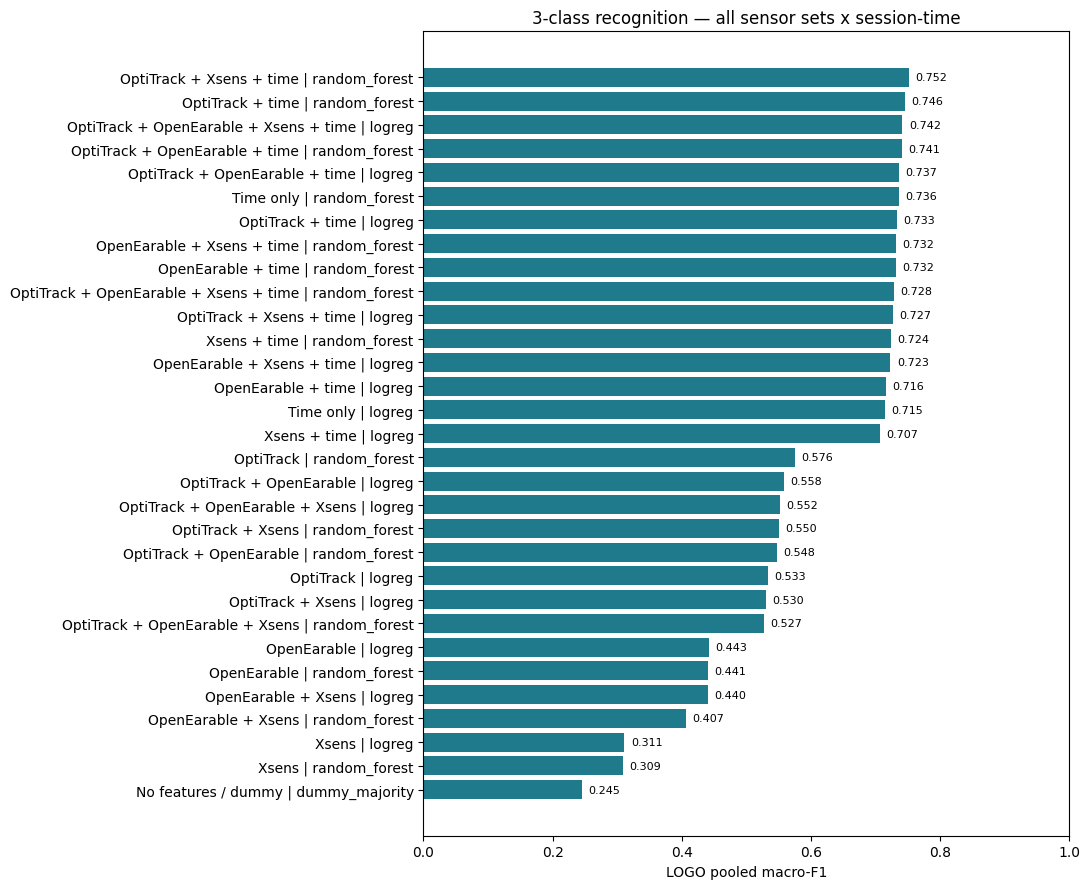

In [3]:
# ============================================================
# SELF-CONTAINED — 3-CLASS RECOGNITION, ALL SENSOR SETS x (+/- session-time)
#   Includes the non-OptiTrack combos cell 91 skipped
#   (OpenEarable, Xsens, OpenEarable + Xsens, each with/without time)
#   Eval: Leave-One-Group-Out. Metrics: pooled & mean-over-groups macro-F1.
# ============================================================
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
import IPython.display as ipd

# ---------- paths (same as cell 91) ----------
OUT_DIR        = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"
FULL_ENG3_PATH = f"{OUT_DIR}/interaction_eng3_features.csv"
REC3_PATH      = f"{OUT_DIR}/eng3_recognition_3class_core_features.csv"

full_df = pd.read_csv(FULL_ENG3_PATH)
df      = pd.read_csv(REC3_PATH)

print("="*80); print("3-CLASS RECOGNITION — ALL SENSOR SETS x session-time"); print("="*80)
print("Rows:", len(df))
print("\nClass counts:"); print(df["recognition_label"].value_counts())

# ---------- session-relative time feature (0=start -> 1=end, per group) ----------
def add_key_columns(d):
    d = d.copy()
    d["group_key"]        = d["group"].astype(int)
    d["window_start_key"] = np.round(d["window_start"].astype(float), 6)
    d["window_end_key"]   = np.round(d["window_end"].astype(float), 6)
    return d

full_df = add_key_columns(full_df); df = add_key_columns(df)
full_df["window_mid"]       = (full_df["window_start"].astype(float) + full_df["window_end"].astype(float)) / 2.0
full_df["group_start_time"] = full_df.groupby("group")["window_mid"].transform("min")
full_df["group_end_time"]   = full_df.groupby("group")["window_mid"].transform("max")
full_df["elapsed_time_s"]   = full_df["window_mid"] - full_df["group_start_time"]
dur = (full_df["group_end_time"] - full_df["group_start_time"]).clip(lower=1e-9)
full_df["time"] = (full_df["elapsed_time_s"] / dur).clip(0, 1)

df = df.merge(
    full_df[["group_key","window_start_key","window_end_key","elapsed_time_s","time"]],
    on=["group_key","window_start_key","window_end_key"], how="left", validate="one_to_one")
if df["time"].isna().any():
    raise ValueError(f"{df['time'].isna().sum()} rows did not receive a time feature.")

# ---------- feature groups ----------
OPTITRACK_FEATURES  = ["dist_close_mean","dist_close_min","dist_mid_mean","dist_far_mean",
    "dist_disp_mean","dist_disp_std","speed_min","speed_mid","speed_max","centroid_speed"]
OPENEARABLE_FEATURES = ["accE_min","accE_mid","accE_max","gyrE_min","gyrE_mid","gyrE_max","move_coord"]
XSENS_FEATURES = [c for c in ["hand_freq_mean","hand_freq_max","hand_power_mean",
    "hand_orient_var","hand_coord","xsens_available"] if c in df.columns]
TIME_FEATURES = ["time"]

# keep only feature columns that actually exist
OPTITRACK_FEATURES  = [c for c in OPTITRACK_FEATURES  if c in df.columns]
OPENEARABLE_FEATURES = [c for c in OPENEARABLE_FEATURES if c in df.columns]

OT, OE, XS, T = OPTITRACK_FEATURES, OPENEARABLE_FEATURES, XSENS_FEATURES, TIME_FEATURES

# ---------- ALL feature sets (every sensor combo, with & without time) ----------
feature_sets = {
    "No features / dummy":                    [],
    "Time only":                              T,
    "OptiTrack":                              OT,
    "OptiTrack + time":                       OT + T,
    "OpenEarable":                            OE,
    "OpenEarable + time":                     OE + T,
    "OptiTrack + OpenEarable":                OT + OE,
    "OptiTrack + OpenEarable + time":         OT + OE + T,
}
if len(XS) > 0:
    feature_sets.update({
        "Xsens":                                  XS,
        "Xsens + time":                           XS + T,
        "OptiTrack + Xsens":                      OT + XS,
        "OptiTrack + Xsens + time":               OT + XS + T,
        "OpenEarable + Xsens":                    OE + XS,
        "OpenEarable + Xsens + time":             OE + XS + T,
        "OptiTrack + OpenEarable + Xsens":        OT + OE + XS,
        "OptiTrack + OpenEarable + Xsens + time": OT + OE + XS + T,
    })
else:
    print("\n[note] no Xsens columns found in this CSV -> Xsens sets skipped")

print("\nFeature sets to evaluate:")
for name, feats in feature_sets.items():
    missing = [c for c in feats if c not in df.columns]
    if missing: raise ValueError(f"{name} has missing columns: {missing}")
    print(f"  {name:42s} {len(feats)} features")

# ---------- models (identical to cell 91) ----------
models = {
    "dummy_majority": Pipeline([("clf", DummyClassifier(strategy="most_frequent"))]),
    "logreg": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs", random_state=42))]),
    "random_forest": Pipeline([("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                       class_weight="balanced", random_state=42, n_jobs=-1))]),
}

# ---------- LOGO evaluation ----------
y = df["recognition_label"].copy(); groups = df["group"].values
class_names = sorted(y.unique()); logo = LeaveOneGroupOut()
summary_rows = []

print("\n" + "-"*80)
for name, features in feature_sets.items():
    if name == "No features / dummy":
        model_items = ["dummy_majority"]; X = pd.DataFrame({"constant": np.ones(len(df))})
    else:
        model_items = ["logreg", "random_forest"]; X = df[features].copy()
    for mdl in model_items:
        yt_all, yp_all, grp_f1, grp_acc = [], [], [], []
        for tr, te in logo.split(X, y, groups):
            m = clone(models[mdl]); m.fit(X.iloc[tr], y.iloc[tr])
            yp = m.predict(X.iloc[te]); yt = y.iloc[te]
            grp_f1.append(f1_score(yt, yp, labels=class_names, average="macro", zero_division=0))
            grp_acc.append(accuracy_score(yt, yp))
            yt_all += list(yt); yp_all += list(yp)
        summary_rows.append({
            "feature_set": name, "model": mdl, "n_features": len(features) if name!="No features / dummy" else 0,
            "pooled_macro_f1":     f1_score(yt_all, yp_all, labels=class_names, average="macro", zero_division=0),
            "mean_group_macro_f1": float(np.mean(grp_f1)),
            "pooled_accuracy":     accuracy_score(yt_all, yp_all),
            "mean_group_accuracy": float(np.mean(grp_acc)),
        })
        print(f"{name:42s} {mdl:14s} "
              f"pooledF1={summary_rows[-1]['pooled_macro_f1']:.3f}  "
              f"meanGrpF1={summary_rows[-1]['mean_group_macro_f1']:.3f}  "
              f"pooledAcc={summary_rows[-1]['pooled_accuracy']:.3f}")

summary_df = pd.DataFrame(summary_rows).sort_values("pooled_macro_f1", ascending=False).reset_index(drop=True)
print("\n" + "="*80); print("SUMMARY — sorted by pooled macro-F1 (LOGO)"); print("="*80)
ipd.display(summary_df.round(3))

# the combos you specifically asked about
print("\n>>> Non-OptiTrack combos (the ones cell 91 had skipped):")
mask = summary_df["feature_set"].isin([
    "OpenEarable","OpenEarable + time","Xsens","Xsens + time",
    "OpenEarable + Xsens","OpenEarable + Xsens + time"])
print(summary_df[mask].round(3).to_string(index=False))

# ---------- bar chart ----------
p = summary_df.copy(); p["label"] = p["feature_set"] + " | " + p["model"]
p = p.sort_values("pooled_macro_f1")
plt.figure(figsize=(11, 9))
plt.barh(p["label"], p["pooled_macro_f1"], color="#1F7A8C")
plt.xlabel("LOGO pooled macro-F1"); plt.xlim(0, 1)
plt.title("3-class recognition — all sensor sets x session-time")
for i, v in enumerate(p["pooled_macro_f1"]): plt.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

Feature set: 18 features (incl. time)
Model: RandomForest (engineered + time) | pooled macro-F1 (LOGO) = 0.741

FEATURE IMPORTANCE *WITH* TIME  (RandomForest, LOGO)


,feature,gini_mean,gini_std,perm_macro_f1_drop_mean,perm_macro_f1_drop_std
0,time,0.3453,0.0090,0.2736,0.1110
1,dist_close_min,0.0854,0.0074,0.0115,0.0245
2,accE_min,0.0325,0.0046,0.0085,0.0336
3,gyrE_min,0.0320,0.0046,0.0064,0.0200
4,dist_disp_mean,0.0869,0.0068,0.0056,0.0222
5,dist_close_mean,0.0948,0.0060,0.0016,0.0221
6,gyrE_mid,0.0320,0.0055,0.0014,0.0106
7,dist_mid_mean,0.0589,0.0047,0.0011,0.0123
8,accE_max,0.0201,0.0022,0.0009,0.0092
9,speed_min,0.0202,0.0015,0.0004,0.0039



>>> 'time' ranks #1 of 18 by permutation importance (macro-F1 drop = 0.2736, gini = 0.3453).


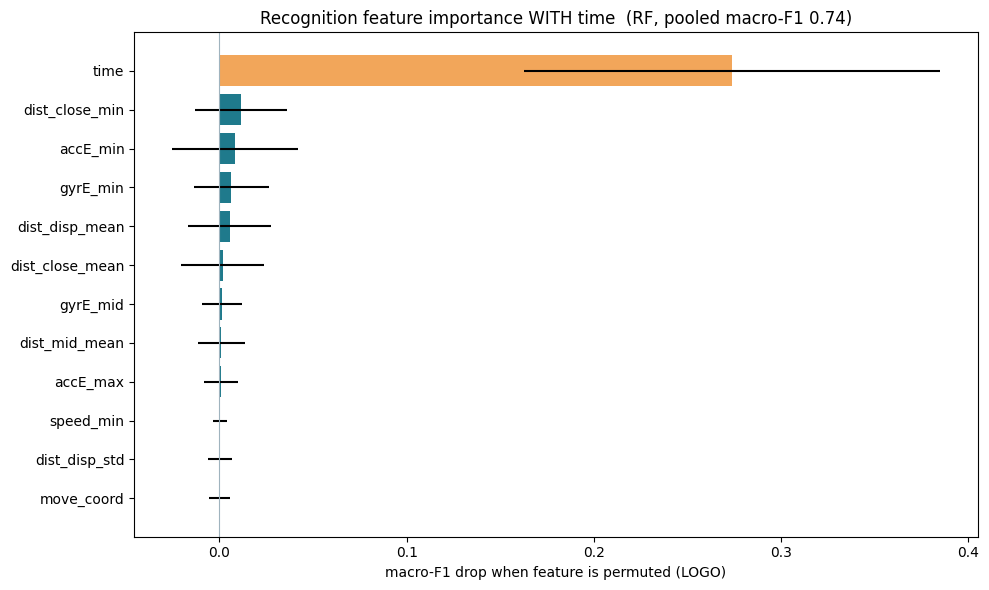

In [1]:
# ============================================================
# SELF-CONTAINED — RECOGNITION FEATURE IMPORTANCE *WITH* SESSION-TIME
#   Best/headline model: Random Forest on engineered features + time
#   Two honest views, both Leave-One-Group-Out:
#     (1) RF gini importance  (mean over LOGO folds)
#     (2) permutation importance = macro-F1 drop on the HELD-OUT group
#   Shows where the `time` feature ranks vs the proximity features.
# ============================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score
import IPython.display as ipd

# ---------- paths (same as cell 91) ----------
OUT_DIR        = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3"
FULL_ENG3_PATH = f"{OUT_DIR}/interaction_eng3_features.csv"
REC3_PATH      = f"{OUT_DIR}/eng3_recognition_3class_core_features.csv"

full_df = pd.read_csv(FULL_ENG3_PATH)
df      = pd.read_csv(REC3_PATH)

# ---------- session-relative time feature (0=start -> 1=end, per group) ----------
def add_key_columns(d):
    d = d.copy()
    d["group_key"]        = d["group"].astype(int)
    d["window_start_key"] = np.round(d["window_start"].astype(float), 6)
    d["window_end_key"]   = np.round(d["window_end"].astype(float), 6)
    return d

full_df = add_key_columns(full_df); df = add_key_columns(df)
full_df["window_mid"]       = (full_df["window_start"].astype(float) + full_df["window_end"].astype(float)) / 2.0
full_df["group_start_time"] = full_df.groupby("group")["window_mid"].transform("min")
full_df["group_end_time"]   = full_df.groupby("group")["window_mid"].transform("max")
full_df["elapsed_time_s"]   = full_df["window_mid"] - full_df["group_start_time"]
dur = (full_df["group_end_time"] - full_df["group_start_time"]).clip(lower=1e-9)
full_df["time"] = (full_df["elapsed_time_s"] / dur).clip(0, 1)

df = df.merge(
    full_df[["group_key","window_start_key","window_end_key","time"]],
    on=["group_key","window_start_key","window_end_key"], how="left", validate="one_to_one")
if df["time"].isna().any():
    raise ValueError(f"{df['time'].isna().sum()} rows did not receive a time feature.")

# ---------- feature set: headline model = engineered + time ----------
OPTITRACK_FEATURES  = ["dist_close_mean","dist_close_min","dist_mid_mean","dist_far_mean",
    "dist_disp_mean","dist_disp_std","speed_min","speed_mid","speed_max","centroid_speed"]
OPENEARABLE_FEATURES = ["accE_min","accE_mid","accE_max","gyrE_min","gyrE_mid","gyrE_max","move_coord"]
TIME_FEATURES = ["time"]
# ---> switch here if you want a different set (e.g. OptiTrack + Xsens + time) <---
FEATURES = [c for c in OPTITRACK_FEATURES + OPENEARABLE_FEATURES + TIME_FEATURES if c in df.columns]
print("Feature set:", len(FEATURES), "features (incl. time)")

X = df[FEATURES].copy()
y = df["recognition_label"].copy()
groups = df["group"].values
class_names = sorted(y.unique())
logo = LeaveOneGroupOut()

def make_rf():
    return Pipeline([("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                       class_weight="balanced", random_state=42, n_jobs=-1))])

# ---------- LOGO: gini + permutation importance, plus pooled macro-F1 ----------
gini_per_fold, perm_per_fold, fold_f1 = [], [], []
yt_all, yp_all = [], []
for tr, te in logo.split(X, y, groups):
    pipe = make_rf(); pipe.fit(X.iloc[tr], y.iloc[tr])
    yp = pipe.predict(X.iloc[te]); yt = y.iloc[te]
    fold_f1.append(f1_score(yt, yp, labels=class_names, average="macro", zero_division=0))
    yt_all += list(yt); yp_all += list(yp)
    # gini (from the RF inside the pipeline)
    gini_per_fold.append(pipe.named_steps["clf"].feature_importances_)
    # permutation importance on the held-out group (honest), scored by macro-F1
    pi = permutation_importance(pipe, X.iloc[te], y.iloc[te],
                                scoring="f1_macro", n_repeats=10, random_state=42, n_jobs=-1)
    perm_per_fold.append(pi.importances_mean)

pooled_macro_f1 = f1_score(yt_all, yp_all, labels=class_names, average="macro", zero_division=0)
print(f"Model: RandomForest (engineered + time) | pooled macro-F1 (LOGO) = {pooled_macro_f1:.3f}")

gini = np.vstack(gini_per_fold); perm = np.vstack(perm_per_fold)
imp = pd.DataFrame({
    "feature": FEATURES,
    "gini_mean": gini.mean(0), "gini_std": gini.std(0),
    "perm_macro_f1_drop_mean": perm.mean(0), "perm_macro_f1_drop_std": perm.std(0),
}).sort_values("perm_macro_f1_drop_mean", ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("FEATURE IMPORTANCE *WITH* TIME  (RandomForest, LOGO)")
print("="*80)
ipd.display(imp.round(4))

rank_time = imp.index[imp["feature"] == "time"].tolist()
if rank_time:
    r = rank_time[0] + 1
    print(f"\n>>> 'time' ranks #{r} of {len(FEATURES)} by permutation importance "
          f"(macro-F1 drop = {imp.loc[imp.feature=='time','perm_macro_f1_drop_mean'].values[0]:.4f}, "
          f"gini = {imp.loc[imp.feature=='time','gini_mean'].values[0]:.4f}).")

# ---------- bar chart: permutation importance ----------
top = imp.head(12).iloc[::-1]
colors = ["#F2A65A" if f == "time" else "#1F7A8C" for f in top["feature"]]
plt.figure(figsize=(10, 6))
plt.barh(top["feature"], top["perm_macro_f1_drop_mean"],
         xerr=top["perm_macro_f1_drop_std"], color=colors)
plt.axvline(0, color="#9FB3BE", lw=0.8)
plt.xlabel("macro-F1 drop when feature is permuted (LOGO)")
plt.title(f"Recognition feature importance WITH time  (RF, pooled macro-F1 {pooled_macro_f1:.2f})")
plt.tight_layout(); plt.show()

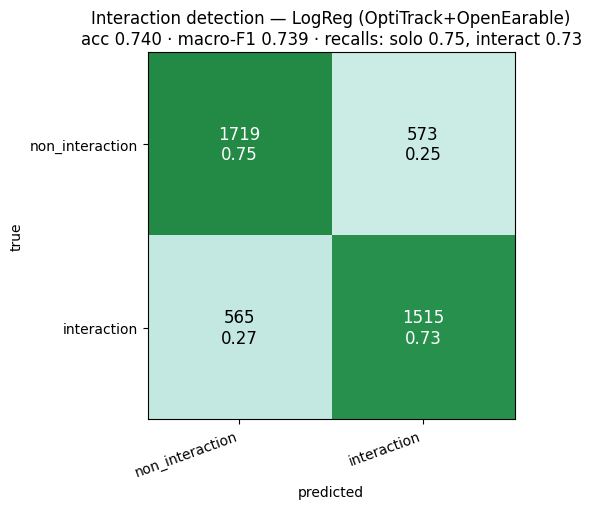

In [1]:
# === INTERACTION confusion matrix — headline model (LogReg, 17 ENG features, LOGO pooled) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

ENG3_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/interaction_eng3_features.csv"
df = pd.read_csv(ENG3_PATH)
final_features = ["dist_close_mean","dist_close_min","dist_mid_mean","dist_far_mean",
    "dist_disp_mean","dist_disp_std","speed_min","speed_mid","speed_max","centroid_speed",
    "accE_min","accE_mid","accE_max","gyrE_min","gyrE_mid","gyrE_max","move_coord"]
labels = ["non_interaction","interaction"]
X = df[final_features].apply(pd.to_numeric, errors="coerce").values
y = df["label"].values; groups = df["group"].values

yt, yp = [], []
for tr, te in LeaveOneGroupOut().split(X, y, groups):
    m = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                      LogisticRegression(max_iter=2000, class_weight="balanced"))
    m.fit(X[tr], y[tr]); yt += list(y[te]); yp += list(m.predict(X[te]))
yt, yp = np.array(yt), np.array(yp)

cm  = confusion_matrix(yt, yp, labels=labels)
cmn = cm / cm.sum(1, keepdims=True)
acc = accuracy_score(yt, yp); mf = f1_score(yt, yp, average="macro", zero_division=0)
rec = {c: cm[i,i]/cm[i].sum() for i,c in enumerate(labels)}

fig, ax = plt.subplots(figsize=(5.4,5.2))
ax.imshow(cmn, cmap="BuGn", vmin=0, vmax=1)
ax.set_xticks(range(2)); ax.set_yticks(range(2))
ax.set_xticklabels(labels, rotation=20, ha="right"); ax.set_yticklabels(labels)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}\n{cmn[i,j]:.2f}", ha="center", va="center",
                color="white" if cmn[i,j] > .5 else "black", fontsize=12)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Interaction detection — LogReg (OptiTrack+OpenEarable)\n"
             f"acc {acc:.3f} · macro-F1 {mf:.3f} · "
             f"recalls: solo {rec['non_interaction']:.2f}, interact {rec['interaction']:.2f}")
plt.tight_layout(); plt.savefig("interaction_confusion.png", dpi=160, bbox_inches="tight"); plt.show()

Using 23 features: ['dist_close_mean', 'dist_close_min', 'dist_mid_mean', 'dist_far_mean', 'dist_disp_mean', 'dist_disp_std', 'speed_min', 'speed_mid', 'speed_max', 'centroid_speed', 'accE_min', 'accE_mid', 'accE_max', 'gyrE_min', 'gyrE_mid', 'gyrE_max', 'move_coord', 'hand_freq_mean', 'hand_freq_max', 'hand_power_mean', 'hand_orient_var', 'hand_coord', 'time']


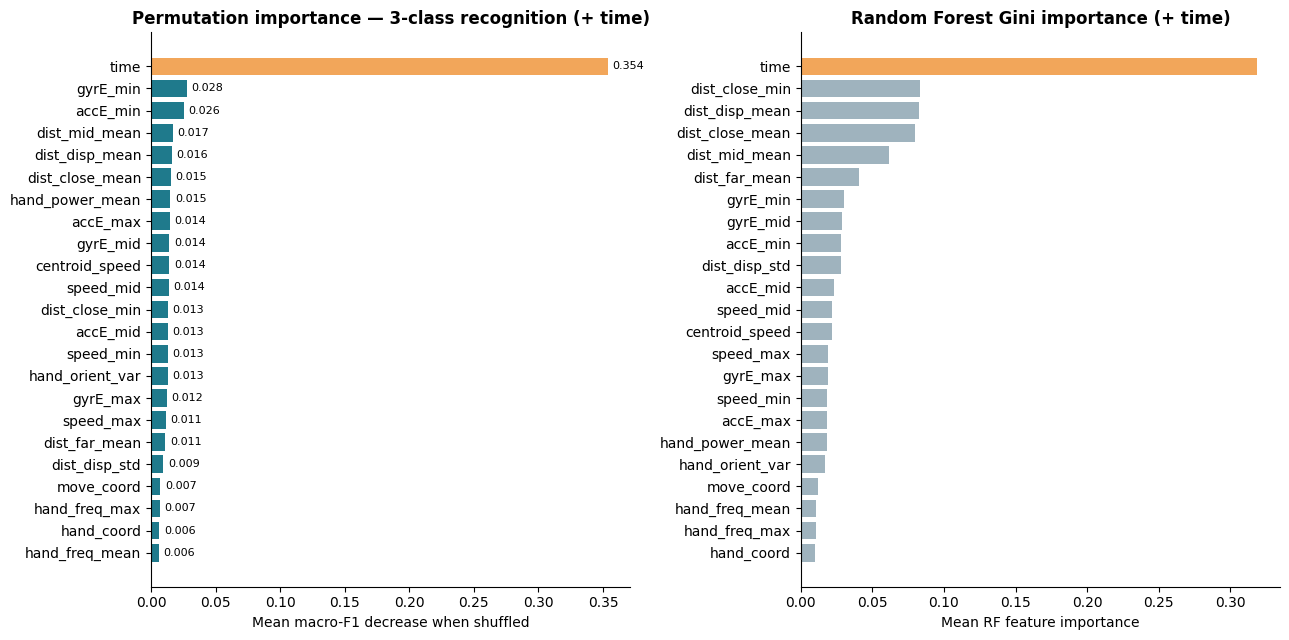

        feature  permutation   gini
           time       0.3535 0.3186
       gyrE_min       0.0275 0.0302
       accE_min       0.0255 0.0282
  dist_mid_mean       0.0167 0.0616
 dist_disp_mean       0.0162 0.0828
dist_close_mean       0.0153 0.0798
hand_power_mean       0.0148 0.0181
       accE_max       0.0145 0.0181
       gyrE_mid       0.0142 0.0285
 centroid_speed       0.0140 0.0215
      speed_mid       0.0136 0.0220
 dist_close_min       0.0132 0.0830
       accE_mid       0.0132 0.0229
      speed_min       0.0129 0.0181
hand_orient_var       0.0127 0.0172
       gyrE_max       0.0123 0.0188
      speed_max       0.0114 0.0190
  dist_far_mean       0.0111 0.0409
  dist_disp_std       0.0094 0.0281
     move_coord       0.0072 0.0118
  hand_freq_max       0.0067 0.0105
     hand_coord       0.0063 0.0098
 hand_freq_mean       0.0059 0.0105


In [4]:
# === RECOGNITION EXPLAINABILITY (with session-time) — permutation + Gini importance ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score

DATA_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"
df = pd.read_csv(DATA_PATH)

# session-relative time feature — build window_mid from window_start/window_end (same as your sweep)
df["window_mid"] = (df["window_start"].astype(float) + df["window_end"].astype(float)) / 2.0
df["group_start_time"] = df.groupby("group")["window_mid"].transform("min")
df["group_end_time"]   = df.groupby("group")["window_mid"].transform("max")
dur = (df["group_end_time"] - df["group_start_time"]).clip(lower=1e-9)
df["time"] = ((df["window_mid"] - df["group_start_time"]) / dur).clip(0, 1)

OPTITRACK   = ["dist_close_mean","dist_close_min","dist_mid_mean","dist_far_mean",
               "dist_disp_mean","dist_disp_std","speed_min","speed_mid","speed_max","centroid_speed"]
OPENEARABLE = ["accE_min","accE_mid","accE_max","gyrE_min","gyrE_mid","gyrE_max","move_coord"]
XSENS       = ["hand_freq_mean","hand_freq_max","hand_power_mean","hand_orient_var","hand_coord"]
# full engineered set + time, keeping only columns that exist
FEATURES = [c for c in (OPTITRACK + OPENEARABLE + XSENS + ["time"]) if c in df.columns]
print("Using", len(FEATURES), "features:", FEATURES)

X = df[FEATURES].apply(pd.to_numeric, errors="coerce").values
y = df["recognition_label"].values

model = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("rf",  RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                   class_weight="balanced", random_state=0)),
]).fit(X, y)

def macro_f1_score(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")
macro = make_scorer(macro_f1_score)
perm = permutation_importance(model, X, y, scoring=macro, n_repeats=20, random_state=0)
gini = model.named_steps["rf"].feature_importances_

imp = (pd.DataFrame({"feature": FEATURES,
                     "permutation": perm.importances_mean,
                     "gini": gini})
         .sort_values("permutation"))

fig, ax = plt.subplots(1, 2, figsize=(13, 6.5))
colors = ["#F2A65A" if f == "time" else "#1F7A8C" for f in imp["feature"]]
ax[0].barh(imp["feature"], imp["permutation"], color=colors)
for y_, v in zip(range(len(imp)), imp["permutation"]):
    ax[0].text(v + max(imp["permutation"])*0.01, y_, f"{v:.3f}", va="center", fontsize=8)
ax[0].set_title("Permutation importance — 3-class recognition (+ time)", fontweight="bold")
ax[0].set_xlabel("Mean macro-F1 decrease when shuffled")

imp2 = imp.sort_values("gini")
ax[1].barh(imp2["feature"], imp2["gini"],
           color=["#F2A65A" if f=="time" else "#9FB3BE" for f in imp2["feature"]])
ax[1].set_title("Random Forest Gini importance (+ time)", fontweight="bold")
ax[1].set_xlabel("Mean RF feature importance")
for a in ax:
    for s in ("top","right"): a.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("recognition_importance.png", dpi=160, bbox_inches="tight")
plt.show()

print(imp.sort_values("permutation", ascending=False).round(4).to_string(index=False))

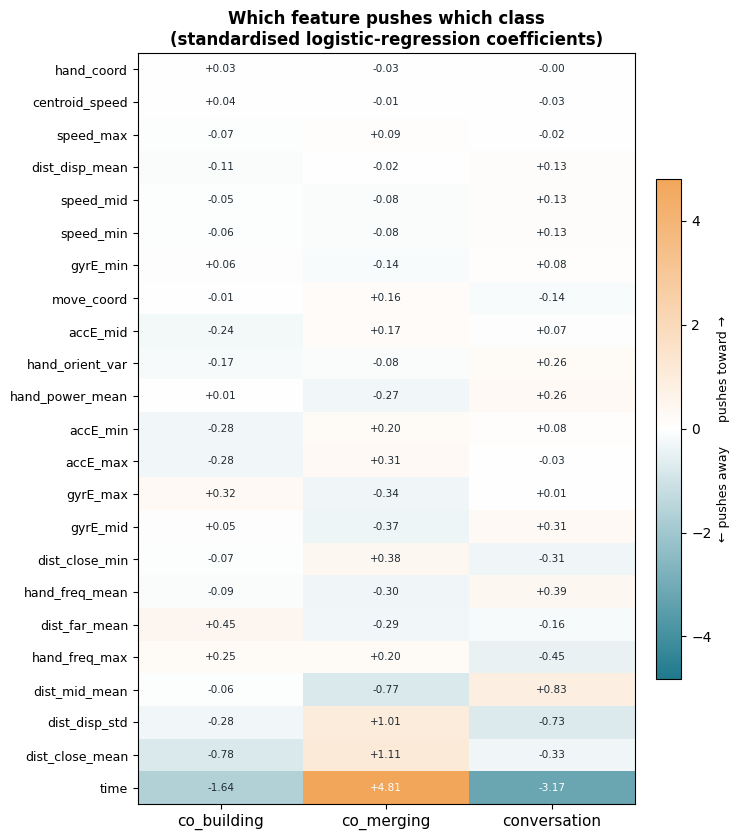

                 co_building  co_merging  conversation
hand_coord              0.03       -0.03         -0.00
centroid_speed          0.04       -0.01         -0.03
speed_max              -0.07        0.09         -0.02
dist_disp_mean         -0.11       -0.02          0.13
speed_mid              -0.05       -0.08          0.13
speed_min              -0.06       -0.08          0.13
gyrE_min                0.06       -0.14          0.08
move_coord             -0.01        0.16         -0.14
accE_mid               -0.24        0.17          0.07
hand_orient_var        -0.17       -0.08          0.26
hand_power_mean         0.01       -0.27          0.26
accE_min               -0.28        0.20          0.08
accE_max               -0.28        0.31         -0.03
gyrE_max                0.32       -0.34          0.01
gyrE_mid                0.05       -0.37          0.31
dist_close_min         -0.07        0.38         -0.31
hand_freq_mean         -0.09       -0.30          0.39
dist_far_m

In [5]:
# === RECOGNITION — which feature pushes which class (multinomial logreg coefficients) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

DATA_PATH = "/content/drive/MyDrive/thesis/data/INTERACTION_ENG3/eng3_recognition_3class_core_features.csv"
df = pd.read_csv(DATA_PATH)

df["window_mid"] = (df["window_start"].astype(float) + df["window_end"].astype(float)) / 2.0
df["group_start_time"] = df.groupby("group")["window_mid"].transform("min")
df["group_end_time"]   = df.groupby("group")["window_mid"].transform("max")
dur = (df["group_end_time"] - df["group_start_time"]).clip(lower=1e-9)
df["time"] = ((df["window_mid"] - df["group_start_time"]) / dur).clip(0, 1)

OPTITRACK   = ["dist_close_mean","dist_close_min","dist_mid_mean","dist_far_mean",
               "dist_disp_mean","dist_disp_std","speed_min","speed_mid","speed_max","centroid_speed"]
OPENEARABLE = ["accE_min","accE_mid","accE_max","gyrE_min","gyrE_mid","gyrE_max","move_coord"]
XSENS       = ["hand_freq_mean","hand_freq_max","hand_power_mean","hand_orient_var","hand_coord"]
FEATURES = [c for c in (OPTITRACK + OPENEARABLE + XSENS + ["time"]) if c in df.columns]

X = df[FEATURES].apply(pd.to_numeric, errors="coerce").values
y = df["recognition_label"].values

clf = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc",  StandardScaler()),
    ("lr",  LogisticRegression(max_iter=4000, class_weight="balanced")),
]).fit(X, y)

classes = list(clf.named_steps["lr"].classes_)          # ['co_building','co_merging','conversation']
coef = clf.named_steps["lr"].coef_                       # shape (3, n_features)
C = pd.DataFrame(coef.T, index=FEATURES, columns=classes)
C = C.reindex(C.abs().max(axis=1).sort_values(ascending=True).index)   # most influential at top

# deck-colored diverging map: teal (pushes away) -> white -> orange (pushes toward)
cmap = LinearSegmentedColormap.from_list("deck", ["#1F7A8C", "#FFFFFF", "#F2A65A"])
vmax = np.abs(C.values).max()
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(7.5, 8.5))
im = ax.imshow(C.values, cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, fontsize=11)
ax.set_yticks(range(len(C)));       ax.set_yticklabels(C.index, fontsize=9)
for i in range(len(C)):
    for j in range(len(classes)):
        v = C.values[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=7.5,
                color="#1E2A33" if abs(v) < vmax*0.6 else "white")
ax.set_title("Which feature pushes which class\n(standardised logistic-regression coefficients)",
             fontweight="bold", fontsize=12)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("← pushes away      pushes toward →", fontsize=9)
plt.tight_layout()
plt.savefig("recognition_class_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()

print(C.round(2).to_string())